In [1]:
import uproot
import matplotlib.pyplot as plt
import ROOT
from IPython.display import Image, display
import numpy as np
import mplhep as hep
import awkward as ak
hep.style.use("CMS")
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from hist import intervals

Welcome to JupyROOT 6.30/03


/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-pac

In [1]:
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/filelist.txt") as f:
    fileList_QCD1000to1200 = f.read().splitlines()
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Reco/250304_225952/filelist.txt") as f:
    fileList_QCD1200to1500 = f.read().splitlines()
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Reco/250304_230000/filelist.txt") as f:
    fileList_QCD1500to2000 = f.read().splitlines()
with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v10Reco/250304_230008/filelist.txt") as f:
    fileList_QCD2000 = f.read().splitlines()
    

processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Reco/250304_225932/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Reco/250304_225938/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Reco/250304_230017/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Reco/250304_230025/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Reco/250304_230032/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Reco/250304_230040/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": fileList_QCD1000to1200,
               "QCD1200to1500": fileList_QCD1200to1500,
               "QCD1500to2000": fileList_QCD1500to2000,
               "QCD2000": fileList_QCD2000}
                #"QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/QCD-4Jets_Bin-HT-1000to1200.root"],
                #"QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Reco/250304_225952/QCD-4Jets_Bin-HT-1200to1500.root"],
                #"QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Reco/250304_230000/QCD-4Jets_Bin-HT-1500to2000.root"],
                #"QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v10Reco/250304_230008/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v10Reco/250304_225828/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v10Reco/250304_225846/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v10Reco/250304_225903/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v10Reco/250304_225920/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v10Reco/250304_225834/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v10Reco/250304_225852/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v10Reco/250304_225909/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v10Reco/250304_225926/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v10Reco/250304_225822/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v10Reco/250304_225839/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v10Reco/250304_225857/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v10Reco/250304_225915/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v10Scouting/250304_164853/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v10Scouting/250304_164901/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v10Scouting/250304_164943/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v10Scouting/250304_164952/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v10Scouting/250304_165000/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v10Scouting/250304_165009/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Scouting/250304_164909/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v10Scouting/250304_164917/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v10Scouting/250304_164926/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v10Scouting/250304_164935/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v10Scouting/250304_164731/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v10Scouting/250304_164754/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v10Scouting/250304_164816/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v10Scouting/250304_164838/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v10Scouting/250304_164738/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v10Scouting/250304_164802/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v10Scouting/250304_164823/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v10Scouting/250304_164845/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v10Scouting/250304_164722/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v10Scouting/250304_164746/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v10Scouting/250304_164809/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v10Scouting/250304_164830/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
#Global Tag 140X Loose Cut Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140/250406_182644/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140/250406_182649/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140/250406_182723/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140/250406_182729/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-Resubmit/250407_082848/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140/250406_182744/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140/250406_182656/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-Resubmit/250407_090131/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140/250406_182709/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140/250406_182716/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140/250406_182531/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140/250406_182553/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140/250406_182614/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140/250406_182631/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140/250406_182539/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140/250406_182559/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140/250406_182620/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140/250406_182637/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140/250406_182523/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140/250406_182545/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140/250406_182607/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140/250406_182626/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [4]:
#Global Tag 140X 10% FPR Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140-10TrackFPR/250408_093049/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-10TrackFPR/250408_093100/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-10TrackFPR/250408_093201/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-10TrackFPR/250408_093218/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-10TrackFPR/250408_093235/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-10TrackFPR/250408_093251/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140-10TrackFPR/250408_093114/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-10TrackFPR/250408_093126/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140-10TrackFPR/250408_093137/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140-10TrackFPR/250408_093149/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140-10TrackFPR/250408_092825/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140-10TrackFPR/250408_092911/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140-10TrackFPR/250408_092950/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140-10TrackFPR/250408_093025/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140-10TrackFPR/250408_092839/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140-10TrackFPR/250408_092924/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140-10TrackFPR/250408_093002/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140-10TrackFPR/250408_093036/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140-10TrackFPR/250408_092811/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140-10TrackFPR/250408_092854/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140-10TrackFPR/250408_092937/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140-10TrackFPR/250408_093014/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [24]:
#Global Tag 140X 5% FPR Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140-5TrackFPR/250410_114224/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-5TrackFPR/250410_114232/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-5TrackFPR/250410_114330/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-5TrackFPR/250410_114341/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-5TrackFPR/250410_114351/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-5TrackFPR/250410_114402/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140-5TrackFPR/250410_114243/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-5TrackFPR/250410_114253/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140-5TrackFPR/250410_114309/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140-5TrackFPR/250410_114320/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140-5TrackFPR/250410_114040/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140-5TrackFPR/250410_114108/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140-5TrackFPR/250410_114137/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140-5TrackFPR/250410_114205/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140-5TrackFPR/250410_114049/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140-5TrackFPR/250410_114117/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140-5TrackFPR/250410_114146/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140-5TrackFPR/250410_114214/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140-5TrackFPR/250410_114031/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140-5TrackFPR/250410_114058/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140-5TrackFPR/250410_114127/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140-5TrackFPR/250410_114156/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [26]:
#Global Tag 140X 1% FPR Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140-1TrackFPR/250413_102147/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-1TrackFPR/250413_102153/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-1TrackFPR/250413_102228/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-1TrackFPR/250413_102235/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-1TrackFPR/250413_102242/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-1TrackFPR/250413_102249/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140-1TrackFPR/250413_102200/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-1TrackFPR/250413_102207/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140-1TrackFPR/250413_102214/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140-1TrackFPR/250413_102221/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140-1TrackFPR/250413_102043/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140-1TrackFPR/250413_102100/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140-1TrackFPR/250413_102117/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140-1TrackFPR/250413_102135/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140-1TrackFPR/250413_102049/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140-1TrackFPR/250413_102106/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140-1TrackFPR/250413_102123/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140-1TrackFPR/250413_102140/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140-1TrackFPR/250413_102037/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140-1TrackFPR/250413_102055/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140-1TrackFPR/250413_102112/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140-1TrackFPR/250413_102129/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [9]:
#Global Tag 140X 15% FPR Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140-15TrackFPR/250412_104115/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-15TrackFPR/250412_104122/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-15TrackFPR/250412_104158/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-15TrackFPR/250412_104206/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-15TrackFPR/250412_104213/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-15TrackFPR/250412_104220/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140-15TrackFPR/250412_104129/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-15TrackFPR/250412_104136/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140-15TrackFPR/250412_104144/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140-15TrackFPR/250412_104151/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104007/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104025/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104045/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104102/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104013/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104031/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104050/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104108/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104001/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104019/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104038/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104056/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
#Global Tag 140X 15% FPR More BG Stats Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082216/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082305/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082341/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082348/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082355/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082402/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082312/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082319/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082326/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140-15TrackFPRMoreStats/250502_082334/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104007/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104025/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104045/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140-15TrackFPR/250412_104102/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104013/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104031/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104050/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140-15TrackFPR/250412_104108/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104001/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104019/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104038/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140-15TrackFPR/250412_104056/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [91]:
#Global Tag 140X 15% FPR v13
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR/250506_174000/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR/250506_174012/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR/250506_174200/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR/250506_174211/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR/250506_174223/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR/250506_174256/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR/250506_174025/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR/250506_174038/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR/250506_174126/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR/250506_174147/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR/250506_173811/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR/250506_173840/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR/250506_173908/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR/250506_173938/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR/250506_173821/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR/250506_173850/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR/250506_173919/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR/250506_173949/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR/250506_173800/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR/250506_173830/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR/250506_173859/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR/250506_173928/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [4]:
#Global Tag 140X 15% FPR v13 MaxTrackVertSig4
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101308/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101316/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101404/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101414/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101423/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101432/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101326/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101335/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101344/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101353/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101135/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101200/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101225/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101249/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101143/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101209/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101233/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101258/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101126/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101152/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101217/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig4/250510_101241/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [6]:
#Global Tag 140X 15% FPR v13 MaxTrackVertSig6
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163650/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163658/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163756/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163804/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163813/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163821/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163707/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163715/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163739/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163747/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163525/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163548/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163610/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163633/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163533/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163555/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163617/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163641/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163518/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163541/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163603/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MaxTrackVertSig6/250510_163625/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [8]:
#Global Tag 140X 15% FPR v13 MergeShared3
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MergeShared3/250509_075901/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MergeShared3/250509_075909/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MergeShared3/250509_075954/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MergeShared3/250509_080003/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MergeShared3/250509_080012/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MergeShared3/250509_080021/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MergeShared3/250509_075918/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MergeShared3/250509_075927/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MergeShared3/250509_075936/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MergeShared3/250509_075945/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MergeShared3/250509_075727/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MergeShared3/250509_075751/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MergeShared3/250509_075815/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MergeShared3/250509_075843/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MergeShared3/250509_075736/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MergeShared3/250509_075759/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MergeShared3/250509_075825/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MergeShared3/250509_075851/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MergeShared3/250509_075716/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MergeShared3/250509_075743/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MergeShared3/250509_075807/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MergeShared3/250509_075835/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [10]:
#Global Tag 140X 15% FPR v13 MergeShared5
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MergeShared5/250508_092625/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MergeShared5/250508_092632/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MergeShared5/250508_092717/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MergeShared5/250508_092725/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MergeShared5/250508_092733/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MergeShared5/250508_092742/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MergeShared5/250508_092641/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MergeShared5/250508_092649/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MergeShared5/250508_092700/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MergeShared5/250508_092709/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MergeShared5/250508_092502/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MergeShared5/250508_092524/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MergeShared5/250508_092545/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MergeShared5/250508_092609/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MergeShared5/250508_092510/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MergeShared5/250508_092531/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MergeShared5/250508_092554/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MergeShared5/250508_092616/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MergeShared5/250508_092455/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MergeShared5/250508_092517/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MergeShared5/250508_092538/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MergeShared5/250508_092602/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [12]:
#Global Tag 140X 15% FPR v13 MinTrackVertSig1
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090833/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090840/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090923/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090931/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090939/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090948/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090849/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090857/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090905/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090914/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090709/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090732/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090755/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090817/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090716/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090739/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090802/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090824/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090657/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090724/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090747/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig1/250511_090809/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [14]:
#Global Tag 140X 15% FPR v13 MinTrackVertSig2
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071336/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071344/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071437/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071447/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071457/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071507/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071354/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071404/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071415/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071426/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071153/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071221/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071249/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071316/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071202/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071231/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071258/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071325/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071144/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071212/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071239/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig2/250512_071307/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [17]:
#Global Tag 140X 15% FPR v13 MinTrackVertSig3
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071448/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071456/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071539/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071548/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071556/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071624/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071505/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071513/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071522/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071531/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071324/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071346/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071409/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071432/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071332/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071354/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071416/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071440/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071259/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071339/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071401/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v13-15TrackFPR-MinTrackVertSig3/250513_071424/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [53]:
#Global Tag 140X 15% FPR v14
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR/250516_195527/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR/250516_195535/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR/250516_195617/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR/250516_195626/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR/250516_195634/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR/250516_195643/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR/250516_195543/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR/250516_195552/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR/250516_195600/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR/250516_195609/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR/250516_195403/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR/250516_195426/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR/250516_195449/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR/250516_195511/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR/250516_195411/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR/250516_195433/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR/250516_195456/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR/250516_195518/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR/250516_195355/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR/250516_195418/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR/250516_195441/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR/250516_195503/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [57]:
#Global Tag 140X 15% FPR v14 3DErr0p005
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-3DErr0p005/250517_153544/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-3DErr0p005/250517_153552/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-3DErr0p005/250517_153635/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-3DErr0p005/250517_153644/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-3DErr0p005/250517_153653/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-3DErr0p005/250517_153701/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-3DErr0p005/250517_153601/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-3DErr0p005/250517_153609/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-3DErr0p005/250517_153618/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-3DErr0p005/250517_153626/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153412/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153435/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153501/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153528/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153420/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153443/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153509/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153535/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153405/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153428/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153451/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-3DErr0p005/250517_153516/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
#Global Tag 140X 15% FPR v14 Remove All at Once
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160640/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160651/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160751/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160803/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160815/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160828/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160703/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160716/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160728/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160739/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160436/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160510/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160545/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160618/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160446/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160521/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160556/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160629/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160426/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160456/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160534/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce/250518_160607/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [1]:
#Global Tag 140X 15% FPR v14 Remove All at Once No Chi2
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192305/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192313/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192404/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192414/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192424/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192433/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192323/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192333/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192343/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192353/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192113/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192152/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192219/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192246/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192123/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192201/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192227/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192255/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192101/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192143/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192210/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-NoChi2/250518_192236/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [65]:
#Global Tag 140X 15% FPR v14 Remove All at Once 3DErr0p005
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084637/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084646/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084741/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084757/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084809/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084824/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084659/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084709/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084720/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084730/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084447/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084515/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084542/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084610/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084456/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084523/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084551/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084619/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084438/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084505/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084533/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-3DErr0p005/250519_084600/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [37]:
#Global Tag 140X 20% FPR Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140-20TrackFPR/250414_085758/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-20TrackFPR/250414_085806/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-20TrackFPR/250414_085851/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-20TrackFPR/250414_085859/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-20TrackFPR/250414_085907/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-20TrackFPR/250414_085915/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140-20TrackFPR/250414_085814/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-20TrackFPR/250414_085823/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v12GlobalTag140-20TrackFPR/250414_085833/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v12GlobalTag140-20TrackFPR/250414_085842/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v12GlobalTag140-20TrackFPR/250414_085637/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v12GlobalTag140-20TrackFPR/250414_085659/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v12GlobalTag140-20TrackFPR/250414_085719/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v12GlobalTag140-20TrackFPR/250414_085741/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v12GlobalTag140-20TrackFPR/250414_085644/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v12GlobalTag140-20TrackFPR/250414_085706/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v12GlobalTag140-20TrackFPR/250414_085727/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v12GlobalTag140-20TrackFPR/250414_085749/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v12GlobalTag140-20TrackFPR/250414_085555/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v12GlobalTag140-20TrackFPR/250414_085652/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v12GlobalTag140-20TrackFPR/250414_085713/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v12GlobalTag140-20TrackFPR/250414_085734/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"],
              "Hto2Sto4D-cT1-MS1": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-1_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-1_Tree_v12GlobalTag140-20TrackFPR/250414_184354/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-1.root"],
              "Hto2Sto4D-cT1-MS7": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-7_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-7_Tree_v12GlobalTag140-20TrackFPR/250414_184317/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-7.root"],
              "Hto2Sto4D-cT1-MS15": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-15_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-15_Tree_v12GlobalTag140-20TrackFPR/250414_184402/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-15.root"],
              "Hto2Sto4D-cT1-MS23": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-23_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-23_Tree_v12GlobalTag140-20TrackFPR/250414_184347/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-23.root"],
              "Hto2Sto4D-cT1-MS30": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-30_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-30_Tree_v12GlobalTag140-20TrackFPR/250414_184339/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-30.root"],
              "Hto2Sto4D-cT1-MS40": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-40_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-40_Tree_v12GlobalTag140-20TrackFPR/250415_201029/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-40.root"],
              "Hto2Sto4D-cT1-MS55": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-55_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-55_Tree_v12GlobalTag140-20TrackFPR/250414_184325/GluGluH-Hto2Sto4D_Par-ctauS-1-MH-125-MS-55.root"],
              "Hto2Sto4D-cT10-MS1": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-1_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-1_Tree_v12GlobalTag140-20TrackFPR/250414_184300/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-1.root"],
              "Hto2Sto4D-cT10-MS7": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-7_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-7_Tree_v12GlobalTag140-20TrackFPR/250414_184222/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-7.root"],
              "Hto2Sto4D-cT10-MS15": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-15_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-15_Tree_v12GlobalTag140-20TrackFPR/250414_184308/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-15.root"],
              "Hto2Sto4D-cT10-MS23": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-23_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-23_Tree_v12GlobalTag140-20TrackFPR/250414_184252/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-23.root"],
              "Hto2Sto4D-cT10-MS30": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-30_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-30_Tree_v12GlobalTag140-20TrackFPR/250414_184244/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-30.root"],
              "Hto2Sto4D-cT10-MS40": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-40_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-40_Tree_v12GlobalTag140-20TrackFPR/250414_184237/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-40.root"],
              "Hto2Sto4D-cT10-MS55": ["/eos/cms/store/group/phys_exotica/DVScouting/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-55_TuneCP5_13p6TeV_powheg-pythia8/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-55_Tree_v12GlobalTag140-20TrackFPR/250414_184229/GluGluH-Hto2Sto4D_Par-ctauS-10-MH-125-MS-55.root"]
             }

In [35]:
#20 % FPR Track Selection Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout20TrackFPR/250321_155620/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout20TrackFPR/250321_155626/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout20TrackFPR/250321_155706/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout20TrackFPR/250321_155714/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout20TrackFPR/250321_155723/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout20TrackFPR/250321_155731/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout20TrackFPR/250321_155634/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout20TrackFPR/250321_155641/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v11Scout20TrackFPR/250321_155649/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v11Scout20TrackFPR/250321_155657/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155503/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155523/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155543/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout20TrackFPR/250321_155604/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155510/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155529/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155550/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v11Scout20TrackFPR/250321_155611/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155456/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155517/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155536/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v11Scout20TrackFPR/250321_155556/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [4]:
#30 % FPR Track Selection Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout30TrackFPR/250323_123549/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout30TrackFPR/250323_123555/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout30TrackFPR/250323_123630/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout30TrackFPR/250323_123637/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout30TrackFPR/250323_123645/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout30TrackFPR/250323_123652/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout30TrackFPR/250323_123602/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout30TrackFPR/250323_123609/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v11Scout30TrackFPR/250323_123615/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v11Scout30TrackFPR/250323_123623/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123442/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123459/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123518/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout30TrackFPR/250323_123536/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123448/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123505/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123523/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v11Scout30TrackFPR/250323_123542/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123435/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123454/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123512/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v11Scout30TrackFPR/250323_123530/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [5]:
#10 % FPR Track Selection Samples
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v11Scout10TrackFPR/250323_200428/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v11Scout10TrackFPR/250323_200434/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v11Scout10TrackFPR/250323_200507/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v11Scout10TrackFPR/250323_200513/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v11Scout10TrackFPR/250323_200520/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v11Scout10TrackFPR/250323_200527/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v11Scout10TrackFPR/250323_200441/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v11Scout10TrackFPR/250323_200447/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v11Scout10TrackFPR/250323_200454/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v11Scout10TrackFPR/250323_200500/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200326/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200343/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200400/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v11Scout10TrackFPR/250323_200416/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200332/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200349/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200405/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v11Scout10TrackFPR/250323_200422/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200320/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200338/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200355/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v11Scout10TrackFPR/250323_200411/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
#Global Tag 140X 15% FPR v14 Remove All at Once More Stats
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150843/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150852/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150945/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150956/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_151006/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_151018/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150903/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150914/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150924/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150934/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150654/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150725/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150754/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150823/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150703/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150735/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150804/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150832/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150645/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150713/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150745/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats/250520_150813/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [24]:
#Global Tag 140X 15% FPR v14 Remove All at Once Next 25 Million Events
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134624/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134643/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134808/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134823/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134839/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134855/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134659/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134715/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134734/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134751/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134317/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134401/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134451/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134551/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134330/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134416/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134508/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134608/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134305/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134344/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134433/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-Next25M/250623_134524/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [6]:
#Global Tag 140X 15% FPR v14 Remove All at Once Min dBV 0.01 cm
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123837/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123852/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124011/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124025/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124042/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124057/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123909/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123925/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123939/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123955/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123515/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123602/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123658/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123804/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123530/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123619/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123720/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123821/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123458/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123546/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123638/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123740/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [7]:
#v15 More Stats
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v15-MoreStats/250703_093551/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v15-MoreStats/250703_093607/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v15-MoreStats/250703_093717/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v15-MoreStats/250703_093733/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v15-MoreStats/250703_093747/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v15-MoreStats/250703_093915/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v15-MoreStats/250703_093623/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v15-MoreStats/250703_093637/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v15-MoreStats/250703_093651/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v15-MoreStats/250703_093704/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v15-MoreStats/250703_093238/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v15-MoreStats/250703_093335/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v15-MoreStats/250703_093444/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v15-MoreStats/250703_093520/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v15-MoreStats/250703_093254/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v15-MoreStats/250703_093414/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v15-MoreStats/250703_093455/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v15-MoreStats/250703_093536/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v15-MoreStats/250703_093220/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v15-MoreStats/250703_093310/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v15-MoreStats/250703_093430/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v15-MoreStats/250703_093505/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [13]:
#v15 Next 25M
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v15-Next25M/250708_123434/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v15-Next25M/250708_123447/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v15-Next25M/250708_123603/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v15-Next25M/250708_123616/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v15-Next25M/250708_123628/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v15-Next25M/250708_123640/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v15-Next25M/250708_123502/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v15-Next25M/250708_123518/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v15-Next25M/250708_123537/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v15-Next25M/250708_123550/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v15-Next25M/250708_123224/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v15-Next25M/250708_123257/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v15-Next25M/250708_123329/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v15-Next25M/250708_123409/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v15-Next25M/250708_123235/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v15-Next25M/250708_123307/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v15-Next25M/250708_123340/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v15-Next25M/250708_123422/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v15-Next25M/250708_123214/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v15-Next25M/250708_123245/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v15-Next25M/250708_123318/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v15-Next25M/250708_123354/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [9]:
#v15 Re HLT ptMin 0.8
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v15_ReHLT_ptMin0p8/250722_161043/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v15_ReHLT_ptMin0p8/250722_161123/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v15_ReHLT_ptMin0p8/250722_161201/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v15_ReHLT_ptMin0p8/250722_161238/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v15_ReHLT_ptMin0p8/250722_161101/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v15_ReHLT_ptMin0p8/250722_161136/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v15_ReHLT_ptMin0p8/250722_161214/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v15_ReHLT_ptMin0p8/250722_161249/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v15_ReHLT_ptMin0p8/250722_161015/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v15_ReHLT_ptMin0p8/250722_161112/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v15_ReHLT_ptMin0p8/250722_161148/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v15_ReHLT_ptMin0p8/250722_161226/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [4]:
#v15 125M
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v15-125M/250723_150653/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v15-125M/250723_150707/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v15-125M/250723_150910/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v15-125M/250723_150926/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v15-125M/250723_150941/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v15-125M/250723_150957/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v15-125M/250723_150723/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v15-125M/250723_150738/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v15-125M/250723_150834/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v15-125M/250723_150853/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v15-125M/250723_150354/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v15-125M/250723_150436/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v15-125M/250723_150521/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v15-125M/250723_150622/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v15-125M/250723_150407/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v15-125M/250723_150455/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v15-125M/250723_150539/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v15-125M/250723_150638/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v15-125M/250723_150341/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v15-125M/250723_150420/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v15-125M/250723_150507/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v15-125M/250723_150608/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [4]:
#Data v9
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v9/250714_175617/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v9/250714_175719/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v9/250714_175135/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v9/250714_175143/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_30Mevts_v9/250714_175150/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_800to1000_30Mevts_v9/250714_175158/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1000to1200_30Mevts_v9/250714_175206/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1200to1500_30Mevts_v9/250714_175214/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1500to2000_30Mevts_v9/250714_175221/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_2000_30Mevts_v9/250714_175228/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024H_30Mevts_v9/250714_184505/ScoutingData_2024H.root"]
             }

In [2]:
#v16-30M 2.5 to 5 Dxy
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v16-30M-2p5To5Dxy/250730_094820/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v16-30M-2p5To5Dxy/250730_094832/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v16-30M-2p5To5Dxy/250730_094953/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v16-30M-2p5To5Dxy/250730_095009/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v16-30M-2p5To5Dxy/250730_095023/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v16-30M-2p5To5Dxy/250730_095037/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v16-30M-2p5To5Dxy/250730_094845/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v16-30M-2p5To5Dxy/250730_094909/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v16-30M-2p5To5Dxy/250730_094923/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v16-30M-2p5To5Dxy/250730_094939/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v16-30M-2p5To5Dxy/250730_095218/Run2024C.root"],
              "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v16-30M-2p5To5Dxy/250730_095204/Run2024D.root"],
              "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v16-30M-2p5To5Dxy/250730_095152/Run2024E.root"],
              "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v16-30M-2p5To5Dxy/250730_095138/Run2024F.root"],
              "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v16-30M-2p5To5Dxy/250730_095123/Run2024G.root"],
              "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v16-30M-2p5To5Dxy/250730_095106/Run2024H.root"],
              "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v16-30M-2p5To5Dxy/250730_095053/Run2024I.root"]
             }

In [2]:
#v16-30M 2.5 to 5 Dxy Golden
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v16-30M-2p5To5Dxy/250730_094820/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v16-30M-2p5To5Dxy/250730_094832/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v16-30M-2p5To5Dxy/250730_094953/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v16-30M-2p5To5Dxy/250730_095009/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v16-30M-2p5To5Dxy/250730_095023/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v16-30M-2p5To5Dxy/250730_095037/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v16-30M-2p5To5Dxy/250730_094845/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v16-30M-2p5To5Dxy/250730_094909/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v16-30M-2p5To5Dxy/250730_094923/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v16-30M-2p5To5Dxy/250730_094939/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v16-30M-2p5To5Dxy-Golden/250804_130305/Run2024C.root"],
              "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v16-30M-2p5To5Dxy-Golden/250804_130248/Run2024D.root"],
              "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v16-30M-2p5To5Dxy-Golden/250804_130236/Run2024E.root"],
              "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v16-30M-2p5To5Dxy-Golden/250804_130224/Run2024F.root"],
              "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v16-30M-2p5To5Dxy-Golden/250804_130211/Run2024G.root"],
              "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v16-30M-2p5To5Dxy-Golden/250804_130158/Run2024H.root"],
              "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v16-30M-2p5To5Dxy-Golden/250804_130146/Run2024I.root"]
             }

In [6]:
#v17-4TrackMin
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v17-4TrackMin/250807_110806/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v17-4TrackMin/250807_110817/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v17-4TrackMin/250807_110921/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v17-4TrackMin/250807_110933/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v17-4TrackMin/250807_110944/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v17-4TrackMin/250807_110955/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v17-4TrackMin/250807_110834/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v17-4TrackMin/250807_110846/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v17-4TrackMin/250807_110858/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v17-4TrackMin/250807_110909/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
              "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v17-4TrackMin/250807_111100/Run2024D.root"],
              "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v17-4TrackMin/250807_111040/Run2024F.root"]
             }

In [3]:
#v18-4TrackMin 125M 2.5 to 5.0 dxy significance
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v18-4TrackMin/250819_185502/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v18-4TrackMin/250819_185512/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v18-4TrackMin/250901_194204/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v18-4TrackMin/250901_194538/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v18-4TrackMin/250901_194556/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v18-4TrackMin/250819_185604/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v18-4TrackMin/250819_185615/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v18-4TrackMin/250819_185626/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v18-4TrackMin/250819_185636/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v18-4TrackMin/250819_185522/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v18-4TrackMin/250819_185533/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v18-4TrackMin/250819_185543/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v18-4TrackMin/250819_185554/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
              "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v18-4TrackMin/250819_185725/Run2024E.root"]
             }

In [2]:
#v18-PileupNoSelection
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v18-PileupNoSelection/250822_151731 /TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v18-PileupNoSelection/250822_151807/TTtoLNu2Q.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v18-PileupNoSelection/250822_150640/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v18-PileupNoSelection/250822_163307/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v18-PileupNoSelection/250822_151400/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v18-PileupNoSelection/250822_163324/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v18-PileupNoSelection/250822_163339/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v18-PileupNoSelection/250822_151442/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v18-PileupNoSelection/250822_163355/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v18-PileupNoSelection/250822_151523/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
             }

In [4]:
#v20 
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v20/250917_155114/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v20/250917_155103/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v20/250917_155051/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v20/250917_155040/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v20/250917_155028/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v20/250917_155009/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v20/250917_154945/Run2024I.root"]
}

In [2]:
#v21 2.5 to 5.0 dxy significance, 300 M events per era, 125 M events per MC sample
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v21-2p5to5Dxy/251016_182416/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v21-2p5to5Dxy/251016_182421/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v21-2p5to5Dxy/251016_182532/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v21-2p5to5Dxy/251016_182539/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v21-2p5to5Dxy/251016_182546/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v21-2p5to5Dxy/251016_182501/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v21-2p5to5Dxy/251016_182510/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v21-2p5to5Dxy/251016_182517/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v21-2p5to5Dxy/251016_182524/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v21-2p5to5Dxy/251016_182429/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v21-2p5to5Dxy/251016_182436/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v21-2p5to5Dxy/251016_182444/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v21-2p5to5Dxy/251016_182452/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
              "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v21-2p5to5Dxy-Resubmit/251017_133902/Run2024C.root"],
              "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v21-2p5to5Dxy/251016_182632/Run2024D.root"],
              "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v21-2p5to5Dxy/251016_182627/Run2024E.root"],
              "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v21-2p5to5Dxy-Resubmit/251017_133942/Run2024F.root"],
              "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v21-2p5to5Dxy/251016_182617/Run2024G.root"],
              "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v21-2p5to5Dxy/251016_182612/Run2024H.root"],
              "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v21-2p5to5Dxy/251016_182607/Run2024I.root"]
             }

In [22]:
#v22 2 to 4 Dxy
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2to4Dxy/251207_164955/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2to4Dxy/251205_200945/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2to4Dxy/251207_165040/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2to4Dxy/251205_200929/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v22-2to4Dxy/251205_200921/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v22-2to4Dxy/251205_200913/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2to4Dxy/251205_200904/Run2024I.root"]
}

In [2]:
#v22 2.5 to 4 Dxy
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2p5to4Dxy/251208_193414/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2p5to4Dxy/251208_172551/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2p5to4Dxy/251208_172354/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2p5to4Dxy/251208_172154/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v22-2p5to4Dxy/251208_172002/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v22-2p5to4Dxy/251208_171829/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2p5to4Dxy/251208_171648/Run2024I.root"]
}

In [14]:
#v22 2.5 to 4 Dxy 900 million events per era
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v22-2p5to4Dxy/251208_165029/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v22-2p5to4Dxy/251208_165228/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v22-2p5to4Dxy/251208_171116/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v22-2p5to4Dxy/251208_171311/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v22-2p5to4Dxy/251208_171449/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v22-2p5to4Dxy/251208_170356/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v22-2p5to4Dxy/251208_170559/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v22-2p5to4Dxy/251208_170748/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v22-2p5to4Dxy/251208_170933/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v22-2p5to4Dxy/251208_165411/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v22-2p5to4Dxy/251208_165556/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v22-2p5to4Dxy/251208_165833/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v22-2p5to4Dxy/251208_170200/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2p5to4Dxy-900M/251212_045033/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2p5to4Dxy-900M/251212_045044/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2p5to4Dxy-900M/251212_045057/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2p5to4Dxy-900M/251212_045111/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v22-2p5to4Dxy-900M/251212_045123/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v22-2p5to4Dxy-900M/251212_045135/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2p5to4Dxy-900M/251212_045152/Run2024I.root"]
}

In [13]:
#v23 2.5 to 4 Dxy Run 384323
processDict = {}
signalDict = {
    #"2024G": ["/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/tree_run385986_LS79.root"],
    "2024G": ["/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/tree_run384323_LS8.root"],
    #"2024E": ["/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/tree_run381053_LS74.root"]
    #"2024F": ["/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/tree_Run382255_LS79.root"]
    #"2024G": ["/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/tree_run384323_onlineBeamspot.root"],
}

In [17]:
#v24 2.5 to 4 Dxy 900 million events per era (using v22 data since they should be identical (pileup changes are only for MC) and v24 isn't done yet)
#make sure to only plot vertices with ntracks>3 and events with at least once vertex with ntracks>3 since v22 stores ntracks=3 vertices and v24 samples don't
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v24-2p5To4Dxy/260206_195126/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v24-2p5To4Dxy/260206_195133/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v24-2p5To4Dxy/260206_195253/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v24-2p5To4Dxy/260206_195306/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v24-2p5To4Dxy/260206_195315/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v24-2p5To4Dxy/260206_195217/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v24-2p5To4Dxy/260206_195226/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v24-2p5To4Dxy/260206_195235/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v24-2p5To4Dxy/260206_195245/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v24-2p5To4Dxy/260206_195141/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v24-2p5To4Dxy/260206_195150/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v24-2p5To4Dxy/260206_195159/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v24-2p5To4Dxy/260206_195208/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2p5to4Dxy-900M/251212_045033/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2p5to4Dxy-900M/251212_045044/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2p5to4Dxy-900M/251212_045057/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2p5to4Dxy-900M/251212_045111/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v22-2p5to4Dxy-900M/251212_045123/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v22-2p5to4Dxy-900M/251212_045135/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2p5to4Dxy-900M/251212_045152/Run2024I.root"]
}

In [2]:
#v24 2.5 to 4 3 Track Min (using v22 data since they should be identical (pileup changes are only for MC) and v24 isn't done yet)
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v24-2p5To4Dxy-3TrackMin/260211_005430/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v24-2p5To4Dxy-3TrackMin/260211_005437/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v24-2p5To4Dxy-3TrackMin/260211_005600/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v24-2p5To4Dxy-3TrackMin/260211_005610/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v24-2p5To4Dxy-3TrackMin/260211_005619/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v24-2p5To4Dxy-3TrackMin/260211_005523/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v24-2p5To4Dxy-3TrackMin/260211_005532/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v24-2p5To4Dxy-3TrackMin/260211_005541/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v24-2p5To4Dxy-3TrackMin/260211_005550/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v24-2p5To4Dxy-3TrackMin/260211_005446/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v24-2p5To4Dxy-3TrackMin/260211_005455/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v24-2p5To4Dxy-3TrackMin/260211_005505/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v24-2p5To4Dxy-3TrackMin/260211_005514/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2p5to4Dxy-900M/251212_045033/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2p5to4Dxy-900M/251212_045044/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2p5to4Dxy-900M/251212_045057/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2p5to4Dxy-900M/251212_045111/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v22-2p5to4Dxy-900M/251212_045123/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v22-2p5to4Dxy-900M/251212_045135/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2p5to4Dxy-900M/251212_045152/Run2024I.root"]
}

In [2]:
#v24 4 Dxy Min (Be careful to blind ntrack>7 vertices)
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v24-4DxyMin-3TrackMin/260219_191849/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v24-4DxyMin-3TrackMin/260219_191902/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v24-4DxyMin-3TrackMin/260219_191910/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v24-4DxyMin-3TrackMin/260219_191946/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v24-4DxyMin-3TrackMin/260219_192031/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v24-4DxyMin-3TrackMin/260219_192042/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v24-4DxyMin-3TrackMin/260219_192051/Run2024I.root"]
}

In [2]:
#v24 3 to 4 Dxy
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v24-3to4Dxy/260303_042852/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v24-3to4Dxy/260303_042904/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v24-3to4Dxy/260303_042918/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v24-3to4Dxy/260303_042931/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v24-3to4Dxy/260303_042943/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v24-3to4Dxy/260303_042956/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v24-3to4Dxy/260303_043009/Run2024I.root"]
}

In [6]:
#v24 3 to 4 Dxy Online BS
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v24-3to4Dxy-OnlineBS/260305_211345/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v24-3to4Dxy-OnlineBS/260305_211352/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v24-3to4Dxy-OnlineBS/260305_211359/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v24-3to4Dxy-OnlineBS/260305_211407/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v24-3to4Dxy-OnlineBS/260305_211415/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v24-3to4Dxy-OnlineBS/260305_211423/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v24-3to4Dxy-OnlineBS/260305_211430/Run2024I.root"]
}

In [9]:
#v25 3 to 4 Dxy
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v25-3to4Dxy/260309_233058/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v25-3to4Dxy/260309_233104/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v25-3to4Dxy/260309_233221/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v25-3to4Dxy/260309_233229/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v25-3to4Dxy/260309_233237/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v25-3to4Dxy/260309_233146/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v25-3to4Dxy/260309_233156/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v25-3to4Dxy/260309_233204/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v25-3to4Dxy/260309_233213/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v25-3to4Dxy/260309_233113/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v25-3to4Dxy/260309_233121/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v25-3to4Dxy/260309_233129/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v25-3to4Dxy/260309_233138/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v25-3to4Dxy/260309_233246/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v25-3to4Dxy/260309_233252/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v25-3to4Dxy/260309_233258/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v25-3to4Dxy/260309_233309/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v25-3to4Dxy/260309_233315/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v25-3to4Dxy/260309_233321/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v25-3to4Dxy/260309_233327/Run2024I.root"]
}

In [8]:
#v26 3 to 4 dxy (using v25 data since only difference is MC track uncertainty correction)

processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v26-3to4Dxy/260312_001837/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v26-3to4Dxy/260312_001846/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v26-3to4Dxy/260312_002026/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v26-3to4Dxy/260312_002036/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v26-3to4Dxy/260312_002047/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v26-3to4Dxy/260312_001937/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v26-3to4Dxy/260312_001949/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v26-3to4Dxy/260312_001959/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v26-3to4Dxy/260312_002013/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v26-3to4Dxy/260312_001856/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v26-3to4Dxy/260312_001906/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v26-3to4Dxy/260312_001917/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v26-3to4Dxy/260312_001927/QCD-4Jets_Bin-HT-2000.root"]}

signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v25-3to4Dxy/260309_233246/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v25-3to4Dxy/260309_233252/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v25-3to4Dxy/260309_233258/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v25-3to4Dxy/260309_233309/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v25-3to4Dxy/260309_233315/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v25-3to4Dxy/260309_233321/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v25-3to4Dxy/260309_233327/Run2024I.root"]
}

In [20]:
#v27 3 to 4 dxy

processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v27-3to4Dxy/260317_174920/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v27-3to4Dxy/260317_174930/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v27-3to4Dxy/260317_175147/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v27-3to4Dxy/260317_175200/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v27-3to4Dxy/260317_175213/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v27-3to4Dxy/260317_175037/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v27-3to4Dxy/260317_175050/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v27-3to4Dxy/260317_175103/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v27-3to4Dxy/260317_175117/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v27-3to4Dxy/260317_174942/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v27-3to4Dxy/260317_174954/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v27-3to4Dxy/260317_175008/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v27-3to4Dxy/260317_175021/QCD-4Jets_Bin-HT-2000.root"]}

signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v27-3to4Dxy/260317_175226/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v27-3to4Dxy/260317_175238/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v27-3to4Dxy/260317_175248/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v27-3to4Dxy/260317_175300/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v27-3to4Dxy/260317_175312/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v27-3to4Dxy/260317_175322/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v27-3to4Dxy/260317_175333/Run2024I.root"]
}

In [2]:
#v27 4 dxy Min (Be careful to blind)

processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v27-4DxyMin/260317_181112/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v27-4DxyMin/260317_181124/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v27-4DxyMin/260317_180324/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v27-4DxyMin/260317_180350/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v27-4DxyMin/260317_180205/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v27-4DxyMin/260317_180259/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v27-4DxyMin/260317_180311/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v27-4DxyMin/260317_180337/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v27-4DxyMin/260317_180405/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v27-4DxyMin/260317_180152/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v27-4DxyMin/260317_180218/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v27-4DxyMin/260317_180231/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v27-4DxyMin/260317_180245/QCD-4Jets_Bin-HT-2000.root"]}

signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v27-4DxyMin/260317_180418/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v27-4DxyMin/260317_180429/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v27-4DxyMin/260317_180442/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v27-4DxyMin/260317_180451/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v27-4DxyMin/260317_180507/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v27-4DxyMin/260317_180518/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v27-4DxyMin/260317_180533/Run2024I.root"]
}

In [2]:
#v28 4 Dxy Min (Be careful to blind ntrack>7 vertices)
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v28-4DxyMin/260406_193751/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v28-4DxyMin/260406_193758/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v28-4DxyMin/260406_193259/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v28-4DxyMin/260406_193319/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v28-4DxyMin/260406_193206/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v28-4DxyMin/260406_193241/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v28-4DxyMin/260406_193250/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v28-4DxyMin/260406_193310/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v28-4DxyMin/260406_193328/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v28-4DxyMin/260406_193157/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v28-4DxyMin/260406_193214/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v28-4DxyMin/260406_193223/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v28-4DxyMin/260406_193232/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-4DxyMin/260409_153724/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-4DxyMin/260409_153742/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-4DxyMin/260409_153818/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-4DxyMin/260409_153833/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-4DxyMin/260409_153846/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-4DxyMin/260409_153901/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-4DxyMin/260409_153919/Run2024I.root"]
}

In [11]:
#v28 3 to 4 Dxy Min
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v28-3to4Dxy-Resubmit/260414_180051/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v28-3to4Dxy-Resubmit/260414_180059/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v28-3to4Dxy-Resubmit/260414_174825/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v28-3to4Dxy-Resubmit/260414_174839/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v28-3to4Dxy-Resubmit/260414_174742/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v28-3to4Dxy-Resubmit/260414_174811/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v28-3to4Dxy-Resubmit/260414_174818/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v28-3to4Dxy-Resubmit/260414_174832/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v28-3to4Dxy-Resubmit/260414_174847/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v28-3to4Dxy-Resubmit/260414_174734/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v28-3to4Dxy-Resubmit/260414_174749/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v28-3to4Dxy-Resubmit/260414_174756/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v28-3to4Dxy-Resubmit/260414_174804/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-3to4Dxy-Resubmit/260414_173013/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-3to4Dxy-Resubmit/260414_173952/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-3to4Dxy-Resubmit/260414_174858/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-3to4Dxy-Resubmit/260414_174906/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-3to4Dxy-Resubmit/260414_174913/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-3to4Dxy-Resubmit/260414_174920/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-3to4Dxy-Resubmit/260414_174928/Run2024I.root"]
}

In [7]:
#v28 4 Dxy Min Data (Be careful to blind ntrack>7 vertices) with v29 MC (track uncertainty corrections applied)
processDict = {"TTTo4Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v29-4DxyMin/260427_205200/TTto4Q.root"],
               "TTToLNu2Q": ["/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v29-4DxyMin/260427_205207/TTtoLNu2Q.root"],
               "QCD40to70": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v29-4DxyMin/260427_204759/QCD-4Jets_Bin-HT-40to70.root"],
               "QCD70to100": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v29-4DxyMin/260427_204817/QCD-4Jets_Bin-HT-70to100.root"],
               "QCD100to200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v29-4DxyMin/260427_204700/QCD-4Jets_Bin-HT-100to200.root"],
               "QCD200to400": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v29-4DxyMin/260427_204738/QCD-4Jets_Bin-HT-200to400.root"],
               "QCD400to600": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v29-4DxyMin/260427_204750/QCD-4Jets_Bin-HT-400to600.root"],
               "QCD600to800": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v29-4DxyMin/260427_204808/QCD-4Jets_Bin-HT-600to800.root"],
               "QCD800to1000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v29-4DxyMin/260427_204827/QCD-4Jets_Bin-HT-800to1000.root"],
               "QCD1000to1200": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v29-4DxyMin/260427_204650/QCD-4Jets_Bin-HT-1000to1200.root"],
               "QCD1200to1500": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v29-4DxyMin/260427_204710/QCD-4Jets_Bin-HT-1200to1500.root"],
               "QCD1500to2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v29-4DxyMin/260427_204719/QCD-4Jets_Bin-HT-1500to2000.root"],
               "QCD2000": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v29-4DxyMin/260427_204729/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-4DxyMin/260409_153724/Run2024C.root"],
    "2024D": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-4DxyMin/260409_153742/Run2024D.root"],
    "2024E": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-4DxyMin/260409_153818/Run2024E.root"],
    "2024F": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-4DxyMin/260409_153833/Run2024F.root"],
    "2024G": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-4DxyMin/260409_153846/Run2024G.root"],
    "2024H": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-4DxyMin/260409_153901/Run2024H.root"],
    "2024I": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-4DxyMin/260409_153919/Run2024I.root"]
}

In [2]:
#v1 K0
processDict = {}
signalDict = {
    "2024C": ["/eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v1-K0/260507_001129/Run2024C.root"],
}

In [3]:
#Branch plotting script

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "vertTrack_pt": [0,5,101]#, "vertTrack_eta": [-3,3,101], "vertTrack_phi": [-3.142,3.142,101],
    #"vertTrack_reducedChi2": [0,7,51], "vertTrack_dxy": [0,0.3,51], "vertTrack_dxyErr": [0,0.05,51], "vertTrack_dxySig": [0,0.05,101],
    #"vertTrack_nValidPixelHits": [0,13,14], #"vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    #"vertTrack_shiftZErr": [0,0.05,51], "vertTrack_shiftZValue": [0,0.05,101],
    #"vertTrack_shift3DErr": [0,0.05,51], "vertTrack_shift3DValue": [0,0.1,101],
    #"scoutVert_dBV": [0,3,101],# "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    #"scoutVert_nTracks": [0,40,41], "scoutVert_chi2": [0,5,50],
    #"scoutVert_dT": [0,0.5,101], "scoutVert_cosT": [-1,1,101], "scoutVert_pMag": [0,500,101],
    #"scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxySig": [0,50,101], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"scoutTrack_pt": [0,200,201],#, "scoutTrack_nValidPixelHits": [0,13,14]
    #"jet_pt": [0,100,101]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open("/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/Summer24Prompt24_RunBCDEFGHI.root") as file:
        jetVetoMap = file["jetvetomap"]
        jetVetoMapXBins = jetVetoMap.to_numpy()[1]
        jetVetoMapYBins = jetVetoMap.to_numpy()[2]
        jetVetoMap = jetVetoMap.to_numpy()[0]
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight", "jet_eta","jet_phi","jet_passJetIdTight","jet_pt","jet_chEmEF","jet_neEmEF"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum
                
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                # Apply displacement cut
                if "vertTrack_shift" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
                elif "vertTrack" in plot:
                    #mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)  & (batch["vertTrack_dxySig"] > 5) & (batch["vertTrack_pt"] > 1.0) & (batch["vertTrack_nValidPixelHits"] > 1)
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01)
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01)
                elif "scoutTrack" in plot:
                    #mask = (batch["scoutTrack_dxySig"] > 5) & (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
                    mask = ak.ones_like(data, dtype=bool)
                elif "jet" in plot:
                    jetEta = batch["jet_eta"]
                    jetPhi = batch["jet_phi"]
                    jetPt = batch["jet_pt"]
                    jetId = batch["jet_passJetIdTight"]
                    jetChargedEMFrac = batch["jet_chEmEF"]
                    jetNeutralEMFrac = batch["jet_neEmEF"]
                    ptMask = (((jetPt>15) & ((abs(jetEta)<=2.5) | (abs(jetEta)>=3))) | ((jetPt>50) & ((abs(jetEta)>2.5) & (abs(jetEta)<3))))
                    selectionMask = ptMask & jetId & ((jetChargedEMFrac+jetNeutralEMFrac)<0.9)
                    jetEta_n = ak.num(jetEta)
                    jetEta = ak.flatten(jetEta)
                    jetPhi_n = ak.num(jetPhi)
                    jetPhi = ak.flatten(jetPhi)
                    jetEta_binned = np.digitize(jetEta,jetVetoMapXBins)
                    jetEta_binned = np.clip(jetEta_binned,1,82)
                    jetEta_binned = jetEta_binned - 1
                    jetPhi_binned = np.digitize(jetPhi,jetVetoMapYBins)
                    jetPhi_binned = np.clip(jetPhi_binned,1,72)
                    jetPhi_binned = jetPhi_binned - 1
                    mask = jetVetoMap[jetEta_binned,jetPhi_binned]
                    mask = (mask == 0)
                    mask = ak.unflatten(mask,jetEta_n)
                    mask = mask & selectionMask
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                data = ak.num(data,axis=1)
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD40to70"]+bgPlotWeights[plot]["QCD70to100"]+bgPlotWeights[plot]["QCD100to200"]+bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD40to70"]+bgPlotWeights[f"{plot}_squared"]["QCD70to100"]+bgPlotWeights[f"{plot}_squared"]["QCD100to200"]+bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"2024E": "black"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    #rax.set_ylim(0,2)
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v1-K0/260507_001129/Run2024C.root


KeyInFileError: not found: 'triggerFilter' (with any cycle number)

    Available keys: 'K0Filter;1', 'K0Tree;1', 'p;1', 'K0Filter/filterTree;1', 'K0Tree/tree;1', 'K0Tree/weights;1', 'K0Tree/genVert_z;1', 'K0Tree/resVert_x;1', 'K0Tree/resVert_y;1', 'K0Tree/resVert_z;1', 'K0Tree/genWeights;1'...

in file /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v1-K0/260507_001129/Run2024C.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v18-4TrackMin/250819_185502/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v18-4TrackMin/250901_194556/QCD-4Jets_Bin-HT-100to200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v18-4TrackMin/250819_185615/QCD-4Jets_Bin-HT-400to600.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v18-4TrackMin/250819_185626/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v18-4TrackMin/250901_194204/QCD-4Jets_Bin-HT-40to70.rootProcessing /eos/cms/store/group/

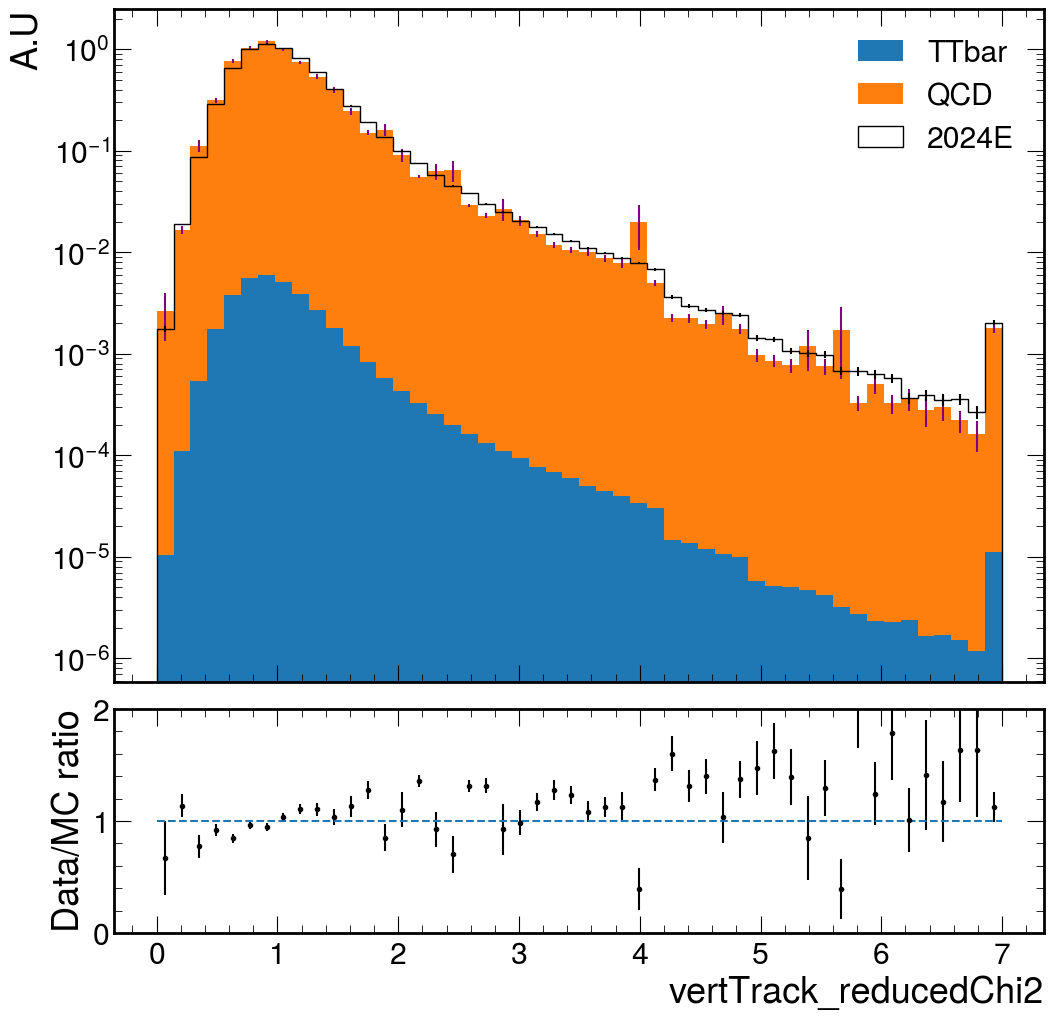

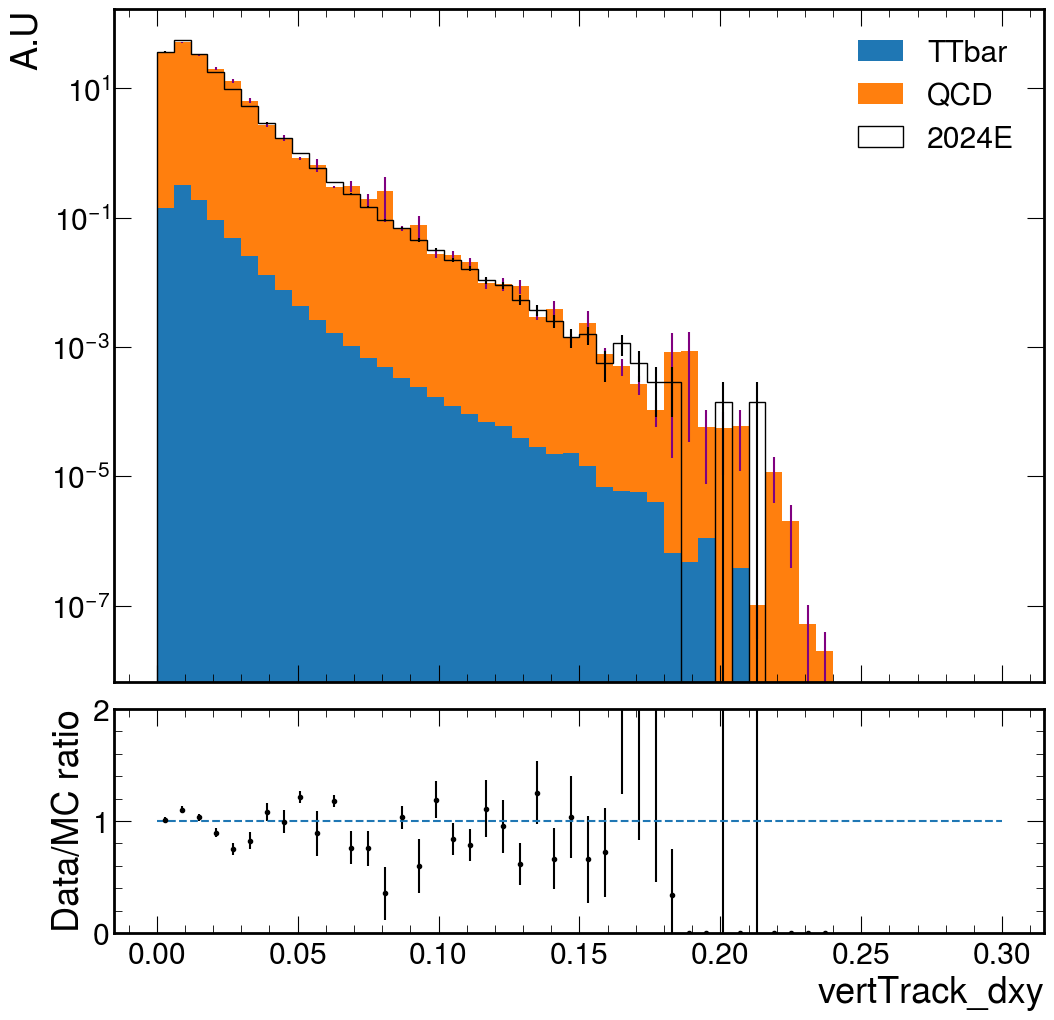

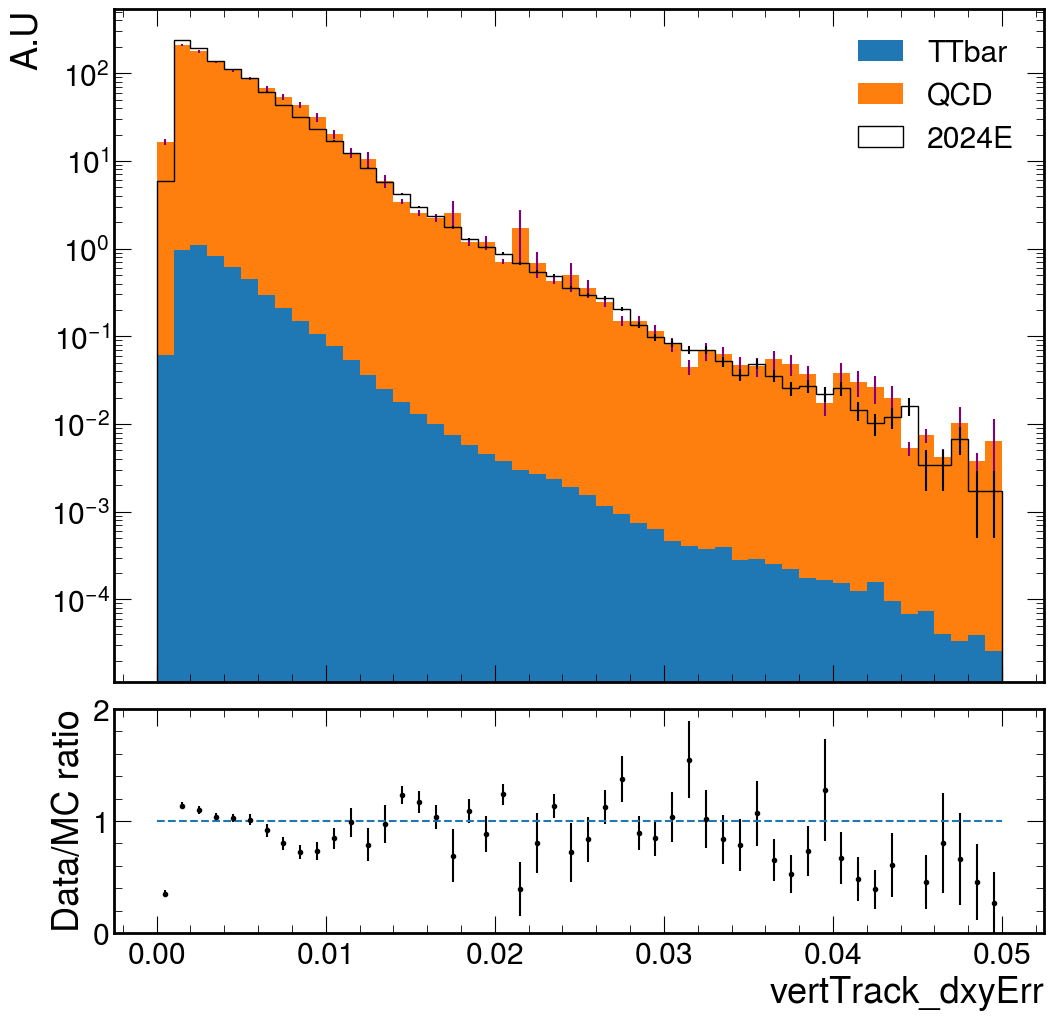

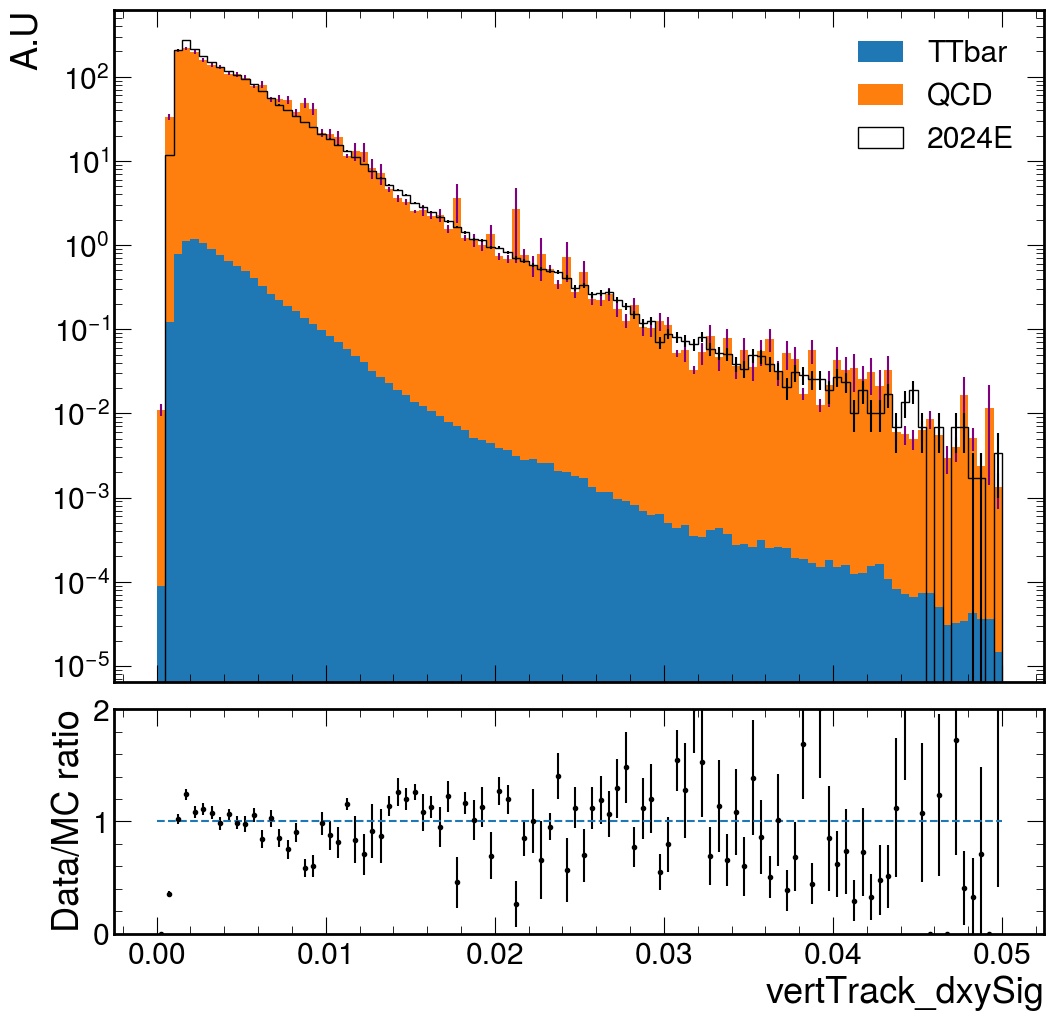

Total runtime: 58.41 seconds


In [5]:
#Branch plotting script with pileupReweighting

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    #"vertTrack_pt": [0,25,26], "vertTrack_eta": [-3,3,101], "vertTrack_phi": [-3.142,3.142,101],
    "vertTrack_reducedChi2": [0,7,51], "vertTrack_dxy": [0,0.3,51], "vertTrack_dxyErr": [0,0.05,51], "vertTrack_dxySig": [0,0.05,101],
    #"vertTrack_nValidPixelHits": [0,13,14], #"vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    #"vertTrack_shiftZErr": [0,0.05,51], "vertTrack_shiftZValue": [0,0.05,101],
    #"vertTrack_shift3DErr": [0,0.05,51], "vertTrack_shift3DValue": [0,0.1,101],
    #"scoutVert_dBV": [0,3,101],# "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    #"scoutVert_nTracks": [0,40,41], "scoutVert_chi2": [0,5,50],
    #"scoutVert_dT": [0,0.5,101], "scoutVert_cosT": [-1,1,101], "scoutVert_pMag": [0,500,101],
    #"scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxySig": [0,50,101], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"scoutTrack_pt": [0,200,101],#, "scoutTrack_nValidPixelHits": [0,13,14]
    #"jet_pt": [30,200,51], "jet_eta": [-3,3,51], "jet_phi": [-3.142,3.142,51],
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open("/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/Summer24Prompt24_RunBCDEFGHI.root") as file:
        jetVetoMap = file["jetvetomap"]
        jetVetoMapXBins = jetVetoMap.to_numpy()[1]
        jetVetoMapYBins = jetVetoMap.to_numpy()[2]
        jetVetoMap = jetVetoMap.to_numpy()[0]
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx","vertTrack_iJet", "weight", "truePU","jet_eta","jet_phi","jet_passJetIdTight","jet_pt","jet_chEmEF","jet_neEmEF","scoutVert_dBV"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        correctionArray = np.load("PURatio_LowHT.npy")
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum
            if(process in processDict):
                PU = batch["truePU"]
                PU_binned = np.digitize(PU,np.linspace(0,100,101))
                PU_binned = PU_binned - 1
                correction = correctionArray[PU_binned]
                weights = weights * correction
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                if "Sig" in plot:
                    data = batch["vertTrack_dxy"] / batch["vertTrack_dxySig"]
                # Apply displacement cut
                if "vertTrack_shift" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
                elif "vertTrack" in plot:
                    #mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)  & (batch["vertTrack_dxySig"] > 5) & (batch["vertTrack_pt"] > 1.0) & (batch["vertTrack_nValidPixelHits"] > 1)
                    jetEta = batch["jet_eta"]
                    jetPhi = batch["jet_phi"]
                    jetPt = batch["jet_pt"]
                    jetId = batch["jet_passJetIdTight"]
                    jetChargedEMFrac = batch["jet_chEmEF"]
                    jetNeutralEMFrac = batch["jet_neEmEF"]
                    ivtx = batch["vertTrack_iVtx"]
                    ijet = batch["vertTrack_iJet"]
                    ptMask = (((jetPt>15) & ((abs(jetEta)<=2.5) | (abs(jetEta)>=3))) | ((jetPt>50) & ((abs(jetEta)>2.5) & (abs(jetEta)<3))))
                    selectionMask = ptMask & jetId & ((jetChargedEMFrac+jetNeutralEMFrac)<0.9) & (abs(jetEta)<2.5) & (jetPt>30)
                    #Apply jet veto
                    x_bins = jetVetoMapXBins
                    y_bins = jetVetoMapYBins
                    jetEta_n = ak.num(jetEta)
                    jetEta = ak.flatten(jetEta)
                    jetPhi_n = ak.num(jetPhi)
                    jetPhi = ak.flatten(jetPhi)
                    jetEta_binned = np.digitize(jetEta,x_bins)
                    jetEta_binned = np.clip(jetEta_binned,1,82)
                    jetEta_binned = jetEta_binned - 1
                    jetPhi_binned = np.digitize(jetPhi,y_bins)
                    jetPhi_binned = np.clip(jetPhi_binned,1,72)
                    jetPhi_binned = jetPhi_binned - 1
                    mask = jetVetoMap[jetEta_binned,jetPhi_binned]
                    mask = (mask == 0)
                    mask = ak.unflatten(mask,jetEta_n)
                    mask = mask & selectionMask
                    trackVeto = (mask[ijet]) | (ijet==-1)
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01) & (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] < 2) & trackVeto
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2)
                elif "scoutTrack" in plot:
                    #mask = (batch["scoutTrack_dxySig"] > 5) & (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
                    mask = ak.ones_like(data, dtype=bool)
                elif "jet" in plot:
                    jetEta = batch["jet_eta"]
                    jetPhi = batch["jet_phi"]
                    jetPt = batch["jet_pt"]
                    jetId = batch["jet_passJetIdTight"]
                    jetChargedEMFrac = batch["jet_chEmEF"]
                    jetNeutralEMFrac = batch["jet_neEmEF"]
                    ptMask = (((jetPt>15) & ((abs(jetEta)<=2.5) | (abs(jetEta)>=3))) | ((jetPt>50) & ((abs(jetEta)>2.5) & (abs(jetEta)<3))))
                    selectionMask = ptMask & jetId & ((jetChargedEMFrac+jetNeutralEMFrac)<0.9) & (abs(jetEta)<2.5) & (jetPt>30)
                    jetEta_n = ak.num(jetEta)
                    jetEta = ak.flatten(jetEta)
                    jetPhi_n = ak.num(jetPhi)
                    jetPhi = ak.flatten(jetPhi)
                    jetEta_binned = np.digitize(jetEta,jetVetoMapXBins)
                    jetEta_binned = np.clip(jetEta_binned,1,82)
                    jetEta_binned = jetEta_binned - 1
                    jetPhi_binned = np.digitize(jetPhi,jetVetoMapYBins)
                    jetPhi_binned = np.clip(jetPhi_binned,1,72)
                    jetPhi_binned = jetPhi_binned - 1
                    mask = jetVetoMap[jetEta_binned,jetPhi_binned]
                    mask = (mask == 0)
                    mask = ak.unflatten(mask,jetEta_n)
                    mask = mask & selectionMask
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #data = ak.num(data,axis=1)
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD40to70"]+bgPlotWeights[plot]["QCD70to100"]+bgPlotWeights[plot]["QCD100to200"]+bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD40to70"]+bgPlotWeights[f"{plot}_squared"]["QCD70to100"]+bgPlotWeights[f"{plot}_squared"]["QCD100to200"]+bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"2024E": "black"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("Data/MC ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_ylim(0,2)
    #rax.set_yscale("log")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [7]:
#Cutflow table script 
doPercents = False
bin_namesCustom = ["8Tracks"]

def process_cutflows(args):
    """ Process a single ROOT file in chunks using uproot.iterate() """
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_cosT","scoutVert_chi2"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            data = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            cosT = batch["scoutVert_cosT"]
            dBVErr = batch["scoutVert_dBVErr"] 
            chi2 = batch["scoutVert_chi2"]
            mask = (data<2.0) & (cosT>0) & (dBVErr<0.005) & (chi2<3) 
            data = data[mask]
            ntracks = ntracks[mask]
            mask = ak.sum(data>=0.01,axis=1)>0
            weights = weights[mask]
            data = data[mask]
            ntracks = ntracks[mask]
            #weightSum[0] += ak.sum(weights)
            #weightSumSquared[0] += ak.sum(weights**2)
            
            # Apply displacement error cut
            #mask = batch["scoutVert_dBVErr"][mask] < 999.9
            #data = data[mask]
            #ntracks = ntracks[mask]
            
            #mask = ak.sum(data>=0.01,axis=1)>0
            #weights = weights[mask]
            #data = data[mask]
            #ntracks = ntracks[mask]
            #weightSum[0] += ak.sum(weights)
            #weightSumSquared[0] += ak.sum(weights**2)
            #numEvents[0] += ak.num(weights,axis=0)
            
            mask = ntracks > 7
            data = data[mask]
            mask = ak.sum(data>=0.01,axis=1)>0
            weights = weights[mask]
            weightSum[0] += ak.sum(weights)
            weightSumSquared[0] += ak.sum(weights**2)
            numEvents[0] += ak.num(weights,axis=0)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    """ Process all ROOT files in parallel and aggregate results """
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results


# Define LaTeX table header
latex_table = "\\begin{table}[htbp]\n"
latex_table += "\\centering\n"

dict = signalDict | processDict
customWeights = parallel_processing(dict)

firstProcess = True
weightSumDict = {}
weightSquaredSumDict = {}
genWeightSumDict = {}
for process, rootFiles in dict.items():
    firstFile = True
    weightSum = []
    weightSquaredSum = []
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_weightsSkim = f.Get("triggerFilter/weightsSkim")
        h_weightsSquaredSkim = f.Get("triggerFilter/weightsSquaredSkim")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        h_weights = f.Get("scoutingTree/weights")
        h_weightsSquared = f.Get("scoutingTree/weightsSquared")
        
        # Extract content
        n_bins = h_weights.GetNbinsX()
        weights = np.array([h_weights.GetBinContent(i) for i in range(3, n_bins)]) #temp since there are redundant cuts in tree maker, normally would go from 1 to n_bins+1
        bin_names = np.array([h_weights.GetXaxis().GetLabels().At(i-1).GetName() for i in range(3, n_bins)])
        weightsSquared = np.array([h_weightsSquared.GetBinContent(i) for i in range(3, n_bins)])
        
        n_binsSkim = h_weightsSkim.GetNbinsX() 
        weightsSkim = np.array([h_weightsSkim.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        bin_namesSkim = np.array([h_weightsSkim.GetXaxis().GetLabels().At(i-1).GetName() for i in range(1, n_binsSkim + 1)])
        weightsSquaredSkim = np.array([h_weightsSquaredSkim.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        
        if(firstFile and firstProcess):
            latex_table += "\\resizebox{\\textwidth}{!}{\\begin{tabular}{|l|"+(len(bin_names)+len(bin_namesSkim)+len(bin_namesCustom)+2)*"c|"+"}\n"
            latex_table += "\\hline\n"
            latex_table += "Process "
            for name in np.concatenate((bin_namesSkim,bin_names)):
                latex_table += "& {} ".format(name)
                weightSum.append(0)
                weightSquaredSum.append(0)
            for name in bin_namesCustom:
                latex_table += "& {} ".format(name)
            latex_table += "& {} & {} ".format("s/sqrt(s+b)","$\epsilon/(1+\sqrt{B})$")
            latex_table += "\\\\\n"
            latex_table += "\\hline\n"
            firstFile = False
        elif(firstFile):
            for name in np.concatenate((bin_namesSkim,bin_names)):
                weightSum.append(0)
                weightSquaredSum.append(0)
            firstFile = False

        genWeightSum += genWeights[0]
        for i in range(len(weightsSkim)):
            weightSum[i] += weightsSkim[i]
            weightSquaredSum[i] += weightsSquaredSkim[i]
        for i in range(len(weights)):
            weightSum[i+len(weightsSkim)] += weights[i]
            weightSquaredSum[i+len(weightsSkim)] += weightsSquared[i]
    firstProcess = False
    weightSumDict[process] = weightSum
    weightSquaredSumDict[process] = weightSquaredSum
    genWeightSumDict[process] = genWeightSum
'''      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for i in range(len(weightSumDict[process])):
        weightSumDict[process][i] = weightSumDict[process][i] / genWeightSumDict[process]
        weightSquaredSumDict[process][i] = weightSquaredSumDict[process][i] / (genWeightSumDict[process]**2)
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] / genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] / (genWeightSumDict[process]**2)

weightSumDict["QCD"] = weightSumDict["QCD200to400"]
weightSquaredSumDict["QCD"] = weightSquaredSumDict["QCD200to400"]
weightSumDict["TTbar"] = weightSumDict["TTTo4Q"]
weightSquaredSumDict["TTbar"] = weightSquaredSumDict["TTTo4Q"]
for i in range(len(weightSumDict["QCD"])):
    weightSumDict["QCD"][i] = weightSumDict["QCD"][i]+weightSumDict["QCD400to600"][i]+weightSumDict["QCD600to800"][i]+weightSumDict["QCD800to1000"][i]+weightSumDict["QCD1000to1200"][i]+weightSumDict["QCD1200to1500"][i]+weightSumDict["QCD1500to2000"][i]+weightSumDict["QCD2000"][i]
    weightSquaredSumDict["QCD"][i] = weightSquaredSumDict["QCD"][i]+weightSquaredSumDict["QCD400to600"][i]+weightSquaredSumDict["QCD600to800"][i]+weightSquaredSumDict["QCD800to1000"][i]+weightSquaredSumDict["QCD1000to1200"][i]+weightSquaredSumDict["QCD1200to1500"][i]+weightSquaredSumDict["QCD1500to2000"][i]+weightSquaredSumDict["QCD2000"][i]
    weightSumDict["TTbar"][i] = weightSumDict["TTbar"][i]+weightSumDict["TTToLNu2Q"][i]
    weightSquaredSumDict["TTbar"][i] = weightSquaredSumDict["TTbar"][i]+weightSquaredSumDict["TTToLNu2Q"][i]
customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]
'''
for process in list(signalDict.keys()):
    print("events passing full selection for process",process,":",customWeights[process+'_nEvents'][bin_namesCustom[-1]])
    latex_table +=  f"{process}"
    for i in range(len(weightSumDict[process])):
        clop_unc = intervals.clopper_pearson_interval(weightSumDict[process][i],weightSumDict[process][0])
        stat_unc = np.sqrt(weightSquaredSumDict[process][i])
        efficiency = weightSumDict[process][i]
        formatString = ".1g"
        if(doPercents):
            efficiency = efficiency / weightSumDict[process][0]
            stat_unc = efficiency * np.sqrt(((stat_unc/weightSumDict[process][i])**2)+((np.sqrt(weightSquaredSumDict[process][0])/weightSumDict[process][0])**2))
        else:
            clop_unc = clop_unc * weightSumDict[process][0]
        if process in ["TTbar","QCD"]:
            formatString = ".2E"
        if(efficiency>0):
            latex_table +=  f" & {efficiency:.3g} $\pm$ {stat_unc:.1g}"
        else:
            latex_table +=  f" & {efficiency:.3g}$^{{+{clop_unc[1]-efficiency:{formatString}}}}_{{-{efficiency-clop_unc[0]:{formatString}}}}$"
    #Custom Cutflows
    for i in range(len(bin_namesCustom)):
        clop_unc = intervals.clopper_pearson_interval(customWeights[process][bin_namesCustom[i]],weightSumDict[process][0])
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        formatString = ".1g"
        if(doPercents):
            efficiency = efficiency / weightSumDict[process][0]
            stat_unc = efficiency * np.sqrt(((stat_unc/customWeights[process][bin_namesCustom[i]])**2)+((np.sqrt(weightSquaredSumDict[process][0])/weightSumDict[process][0])**2))
        else:
            clop_unc = clop_unc * weightSumDict[process][0]
        if process in ["TTbar","QCD"] and doPercents:
            formatString = ".2E"
        if(efficiency>0):
            latex_table +=  f" & {efficiency:.3g} $\pm$ {stat_unc:.1g}"
        else:
            latex_table +=  f" & {efficiency:.3g}$^{{+{clop_unc[1]-efficiency:{formatString}}}}_{{-{efficiency-clop_unc[0]:{formatString}}}}$"
    latex_table += "\\\\\n"
    
latex_table += "\\hline\n"
latex_table += "\\end{tabular}}\n"
latex_table += "\\caption{Cutflow table}\n"
latex_table += "\\label{tab:cutflow}\n"
latex_table += "\\end{table}"
'''
#Add sensitivity

splitStrings = latex_table.split("\\hline\n")
processString = splitStrings[2]
substrings = processString.split("\\\\")
final_table = splitStrings[0]+"\\hline\n"+splitStrings[1]+"\\hline\n"
for string in substrings:
    process = string.split(' &')[0]
    process = process.replace('\n','')
    if(process in signalDict):
        if(len(bin_namesCustom)):
            string += f" & {customWeights[process][bin_namesCustom[-1]]/np.sqrt(customWeights[process][bin_namesCustom[-1]]+customWeights['QCD'][bin_namesCustom[-1]]+customWeights['TTbar'][bin_namesCustom[-1]]):.2f} & {(customWeights[process][bin_namesCustom[-1]]/weightSumDict[process][0])/(1+np.sqrt(customWeights['QCD'][bin_namesCustom[-1]]+customWeights['TTbar'][bin_namesCustom[-1]])):.3f}"
        else:
            string += f" & {weightSumDict[process][-1]/np.sqrt(weightSumDict[process][-1]+weightSumDict['QCD'][-1]+weightSumDict['TTbar'][-1]):.3f}" 
    elif(process in ["QCD","TTbar"]):
        string += f" & & "
    final_table += string + "\\\\"
final_table = final_table[:-2]
final_table += "\\hline\n" + splitStrings[3]
'''
print(latex_table)

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2p5to4Dxy-900M/251212_045033/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2p5to4Dxy-900M/251212_045044/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2p5to4Dxy-900M/251212_045057/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2p5to4Dxy-900M/251212_045152/Run2024I.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v24-2p5To4Dxy-3TrackMin/260211_005600/QCD-4Jets_Bin-HT-40to70.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v24-2p5To4Dxy-3TrackMin/260211_005430/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2p5to4Dxy-900M/251212

[0.006]
errCutValue 0.006
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140-10TrackFPR/250408_093201/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140-10TrackFPR/250408_093100/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140-10TrackFPR/250408_093251/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140-10TrackFPR/250408_093218/QCD-4Jets_Bin-HT-400to600.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to

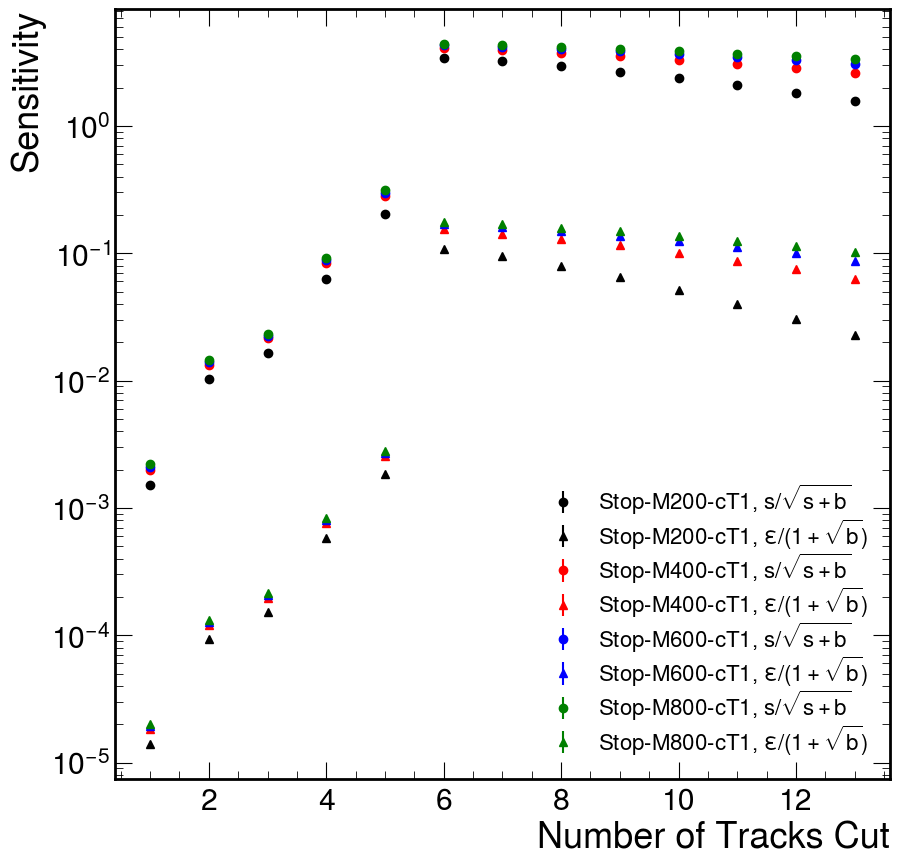

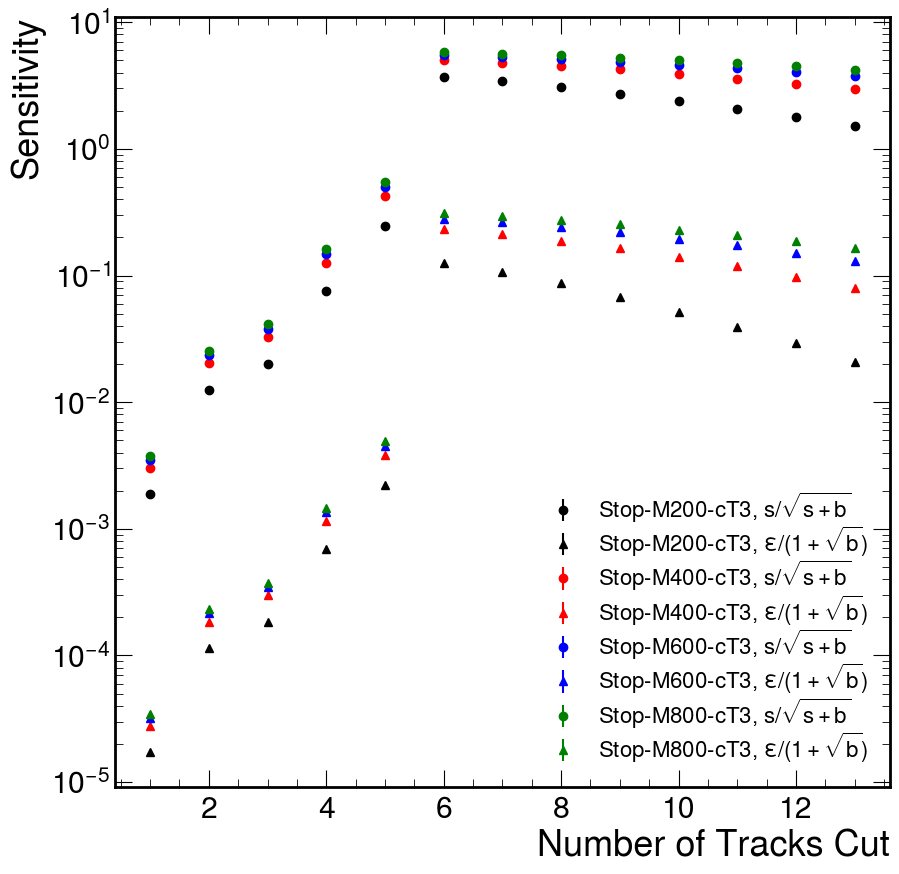

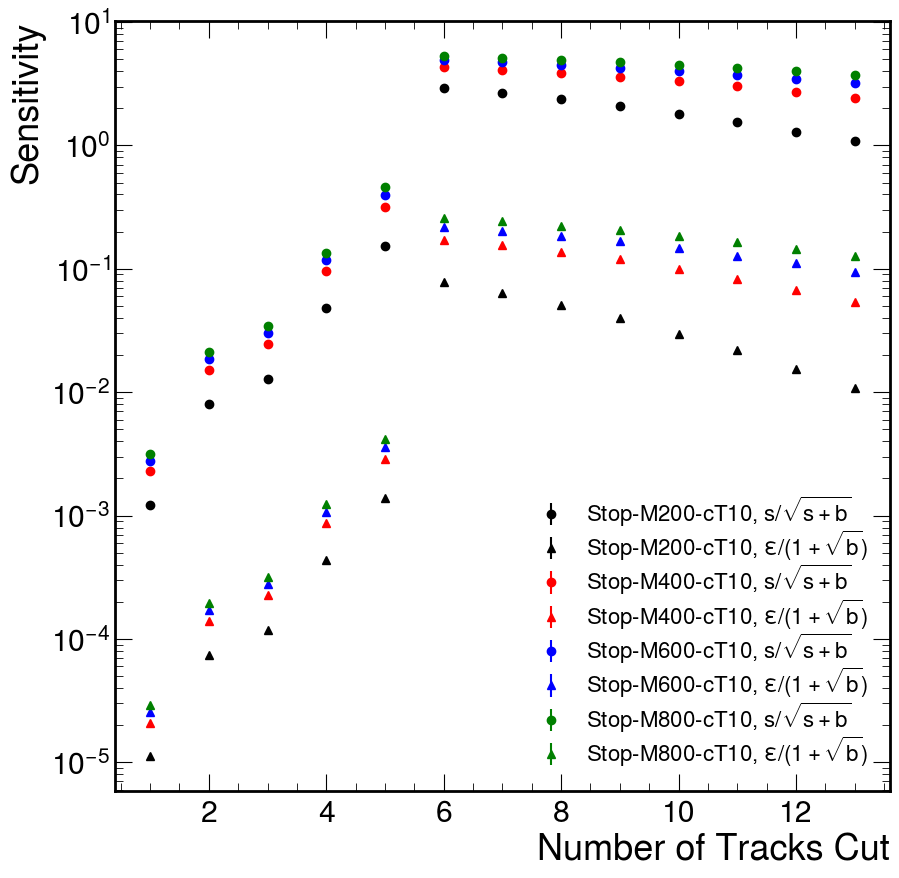

Total runtime: 13.79 seconds
best traditional sensitivity for signal Stop-M200-cT1 is 3.4318486934222032 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M400-cT1 is 4.107476889770223 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M600-cT1 is 4.2929587000105105 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M800-cT1 is 4.387105469440603 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M200-cT3 is 3.7009946771101343 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M400-cT3 is 5.0204497239645125 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M600-cT3 is 5.523279895134032 requiring > 6.0 tracks and < 0.006000 uncertainty
best traditional sensitivity for signal Stop-M800-cT3 is 5.803049180715706 requiring > 6.0 t

In [8]:
#Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

errCutValues = [0.006]
nTrackCutValues = np.linspace(1,13,13)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros_like(nTrackCutValues)
        weightSumSquared = np.zeros_like(nTrackCutValues)
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights

            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            mask = dBVErr < errCutValue
            dBVErr = dBVErr[mask]
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            for i in range(len(nTrackCutValues)):
                mask = ntracks > nTrackCutValues[i]
                dBV = dBV[mask]
                dBVErr = dBVErr[mask]
                ntracks = ntracks[mask]
            
                mask = ak.sum(dBV>=0.1,axis=1)>0
                weights = weights[mask]
                dBV = dBV[mask]
                dBVErr = dBVErr[mask]
                ntracks = ntracks[mask]
                weightSum[i] += ak.sum(weights)
                weightSumSquared[i] += ak.sum(weights**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, np.zeros_like(nTrackCutValues)) + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
for errCutValue in errCutValues:
    print("errCutValue",errCutValue)
    bgPlotWeights = parallel_processing(processDict)
    sigPlotWeights = parallel_processing(signalDict)

    #Combining Background Subprocesses and Reweighting Events
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
    bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
    bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

    # **Plotting**
    for lifetime in ["1","3","10"]:
        fig, ax = plt.subplots()
        colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
        for signal, color in colors.items():
            sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
            if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
                bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValue,nTrackCutValues[np.argmax(sensitivity)]]
            efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
            ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal+", s/$\sqrt{s+b}$")
            sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
            if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
                bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValue,nTrackCutValues[np.argmax(sensitivity)]]
            ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color,label=signal+", $\epsilon/(1+\sqrt{b})$")
            #sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
            #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)

        ax.set_ylabel("Sensitivity")
        plt.xlabel("Number of Tracks Cut")
        ax.legend(labelspacing=0,prop={'size': 16})
        ax.set_yscale("log")
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

[9.999e+02 2.000e-02 1.900e-02 1.800e-02 1.700e-02 1.600e-02 1.500e-02
 1.400e-02 1.300e-02 1.200e-02 1.100e-02 1.000e-02 9.000e-03 8.000e-03
 7.000e-03 6.000e-03 5.000e-03 4.000e-03 3.000e-03 2.000e-03 1.000e-03]
Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v15-MoreStats/250703_093551/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v15-MoreStats/250703_093607/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v15-MoreStats/250703_093717/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v15-MoreStats/250703_093623/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_B

/tmp/rmccarth/ipykernel_2483430/2461439275.py:119: RuntimeWarning: divide by zero encountered in divide
  sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))


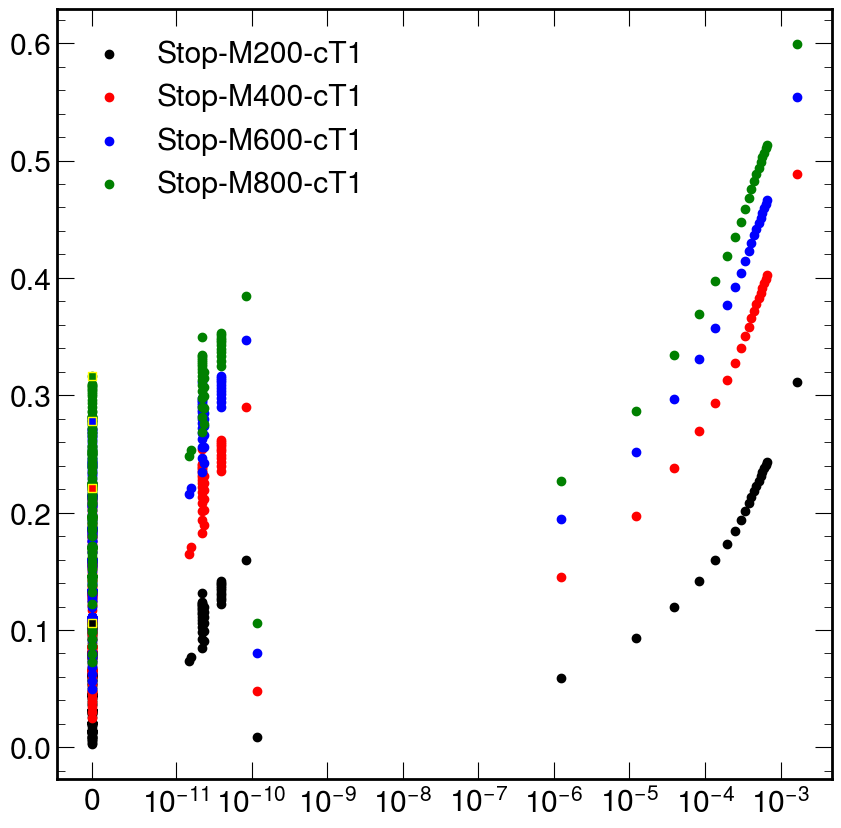

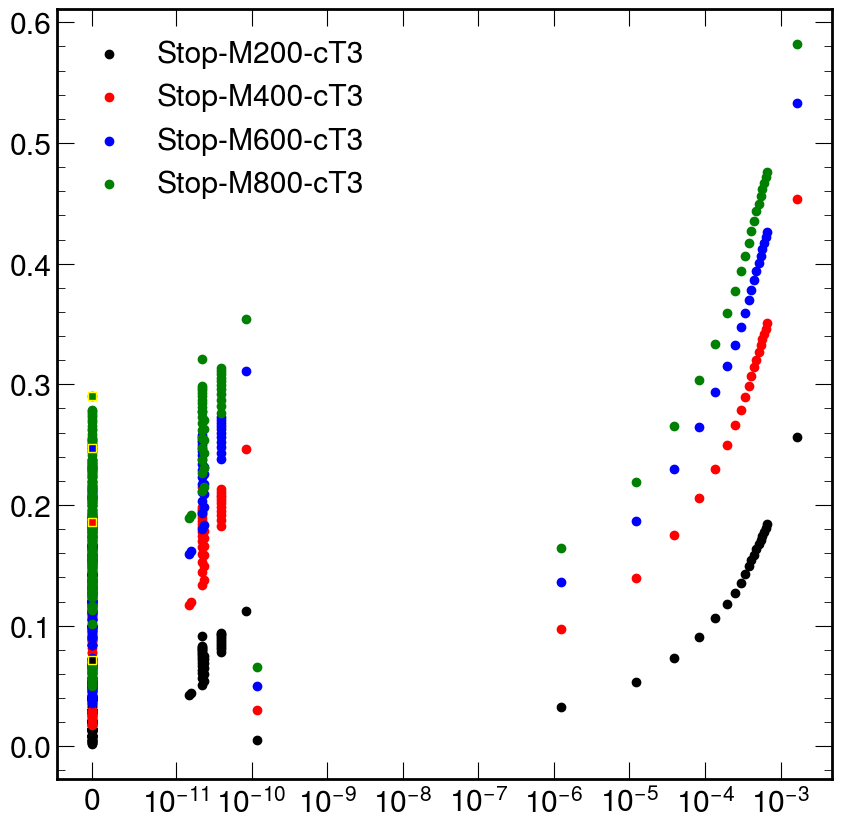

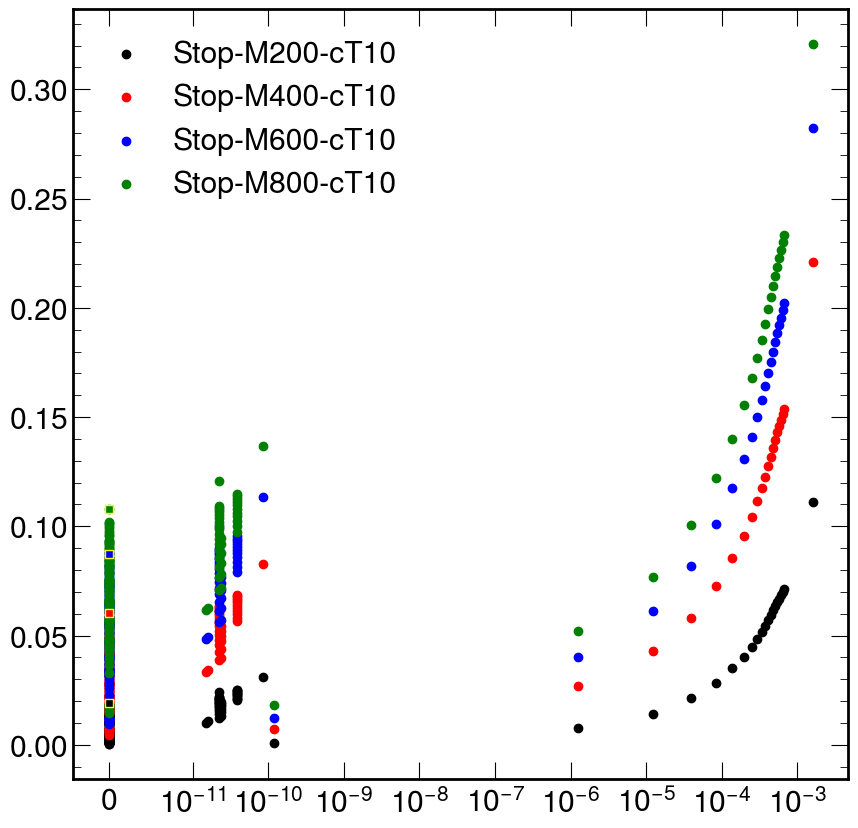

Total runtime: 562.21 seconds
best traditional sensitivity for signal Stop-M200-cT1 is 3.3971981325076492 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M400-cT1 is 4.9069319131198466 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M600-cT1 is 5.503319143934129 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M800-cT1 is 5.872279012444014 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M200-cT3 is 2.7995522499141807 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M400-cT3 is 4.504530785241198 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M600-cT3 is 5.189570618075548 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M800-cT3 is 5.626238970079842 req

In [52]:
#Improved Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#Cuts need to go from loosest to tightest
errCutValues = np.concatenate(([999.9],np.linspace(0.001,0.02,20)[::-1]))
nTrackCutValues = np.linspace(1,10,10)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros((len(errCutValues),len(nTrackCutValues)))
        weightSumSquared = np.zeros((len(errCutValues),len(nTrackCutValues)))
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            for i in range(len(errCutValues)):
                mask = dBVErr < errCutValues[i]
                dBVErr = dBVErr[mask]
                dBV = dBV[mask]
                ntracks = ntracks[mask]
                for j in range(len(nTrackCutValues)):
                    mask = ntracks > nTrackCutValues[j]
                    dBVMasked = dBV[mask]
                    dBVErrMasked = dBVErr[mask]
                    ntracksMasked = ntracks[mask]
            
                    mask = ak.sum((dBVMasked>=0.01)&(dBVMasked<2.0),axis=1)>1
                    weightsMasked = weights[mask]
                    dBVMasked = dBVMasked[mask]
                    dBVErrMasked = dBVErrMasked[mask]
                    ntracksMasked = ntracksMasked[mask]
                    weightSum[i][j] += ak.sum(weightsMasked)
                    weightSumSquared[i][j] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal)
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color)
        sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
    #ax.set_ylabel("Sensitivity")
    #plt.xlabel("Number of Tracks Cut")
    plt.legend()
    #ax.set_xscale("log")
    plt.xscale("symlog",linthresh=10**-11)
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140/250406_182644/TTto4Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140/250406_182723/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140/250406_182649/TTtoLNu2Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140/250406_182729/QCD-4Jets_Bin-HT-400to600.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-Resubmit/250407_082848/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QC

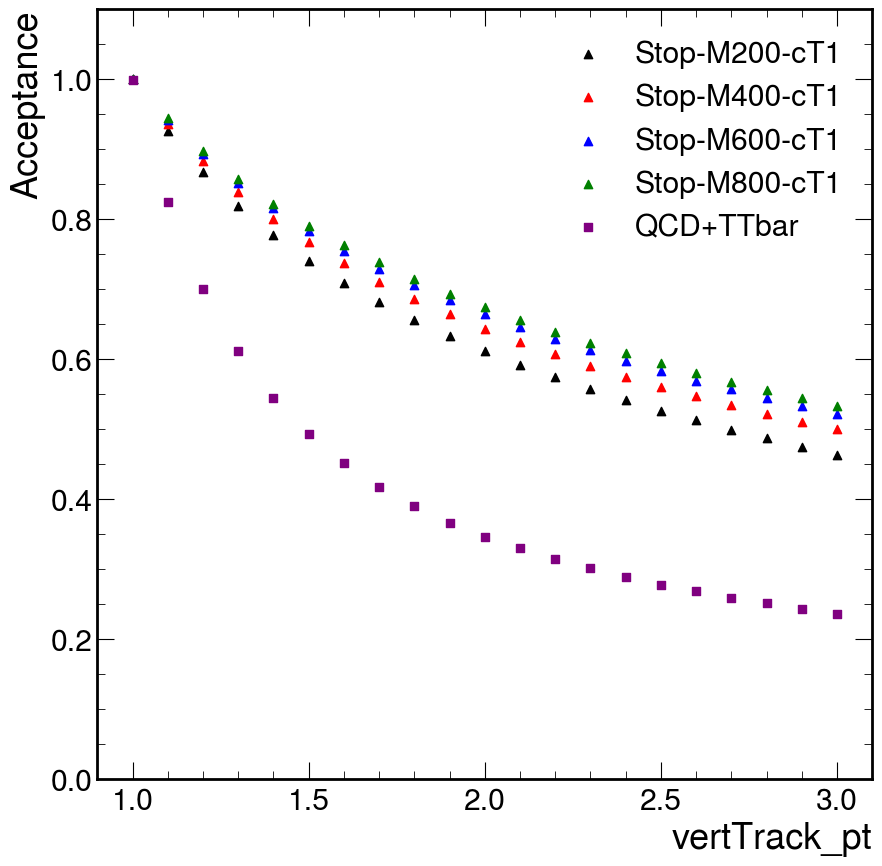

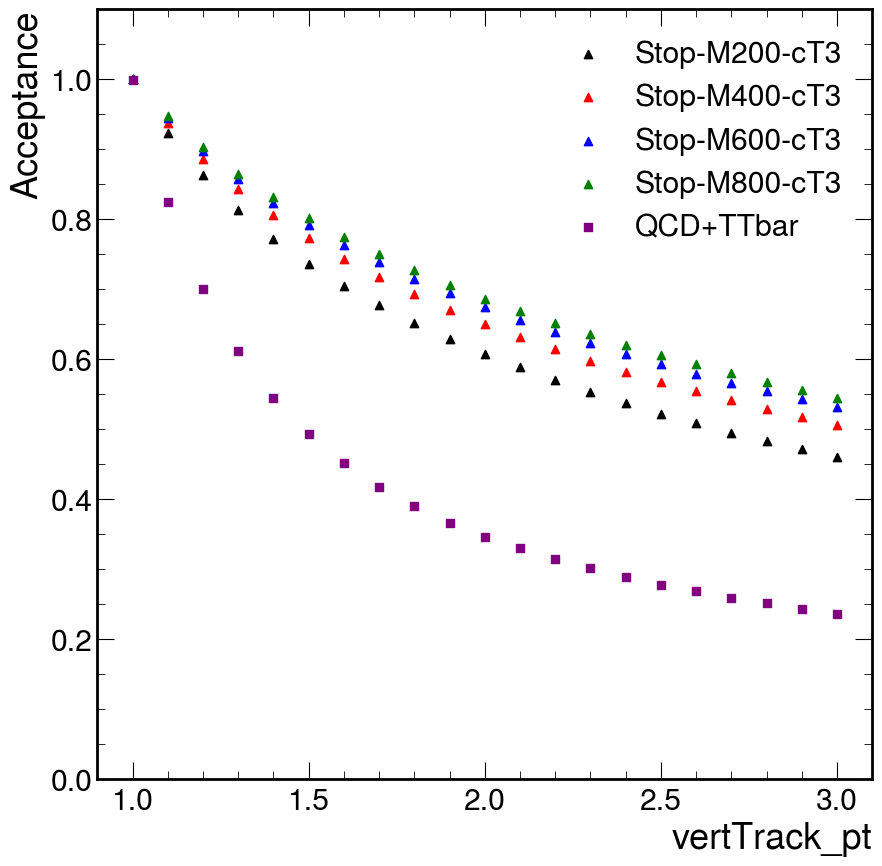

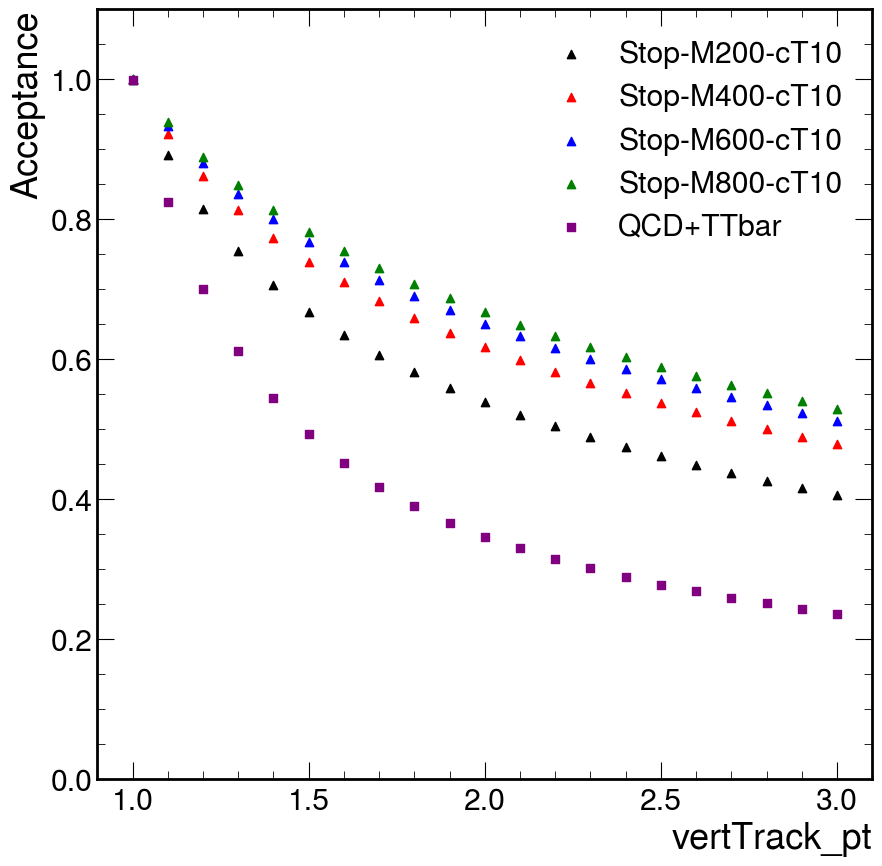

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140/250406_182644/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140/250406_182649/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140/250406_182744/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-Resubmit/250407_082848/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-Resubmit/250407_090131/QCD-4Jets_Bin-HT-1200to1500.root
Processing /eos/cms/store/group/phys_exoti

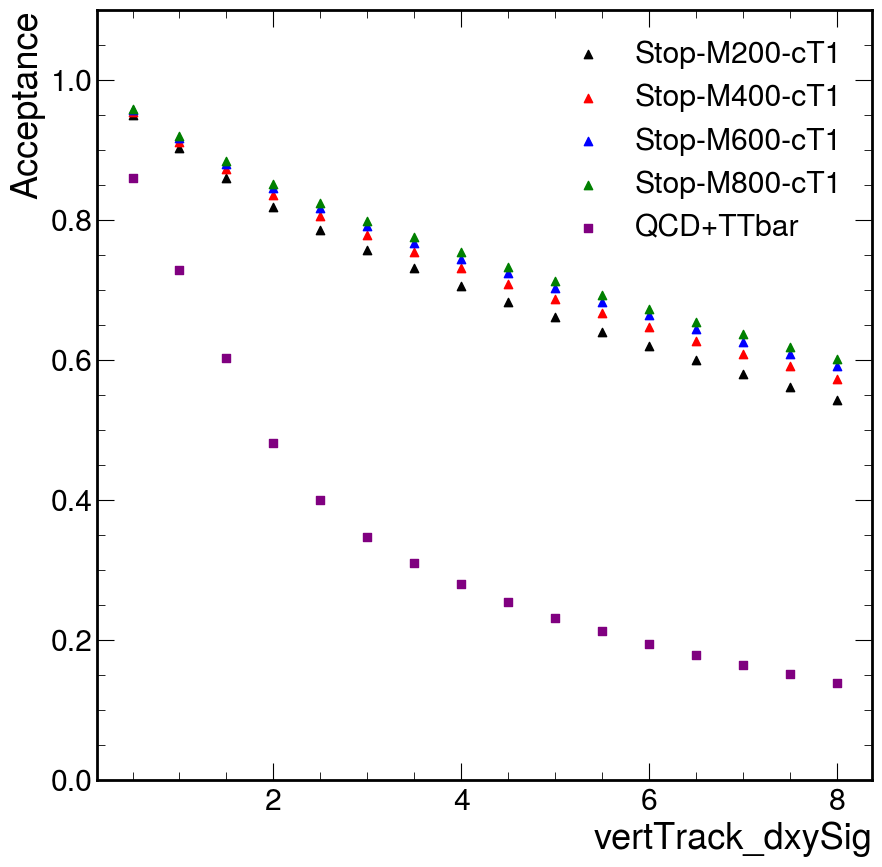

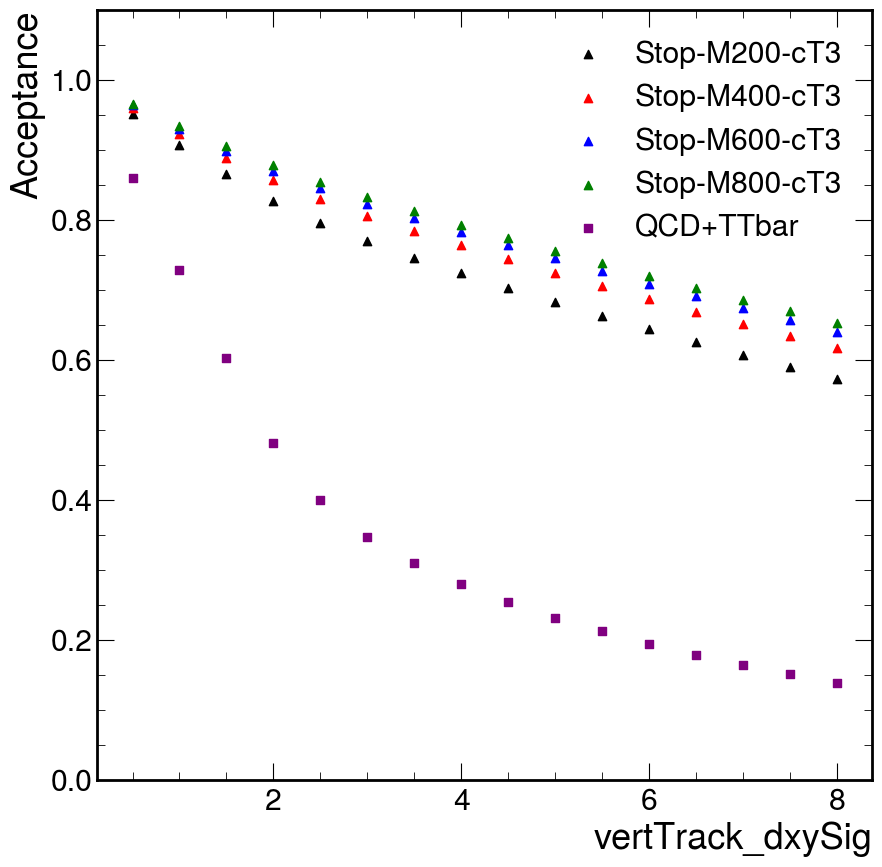

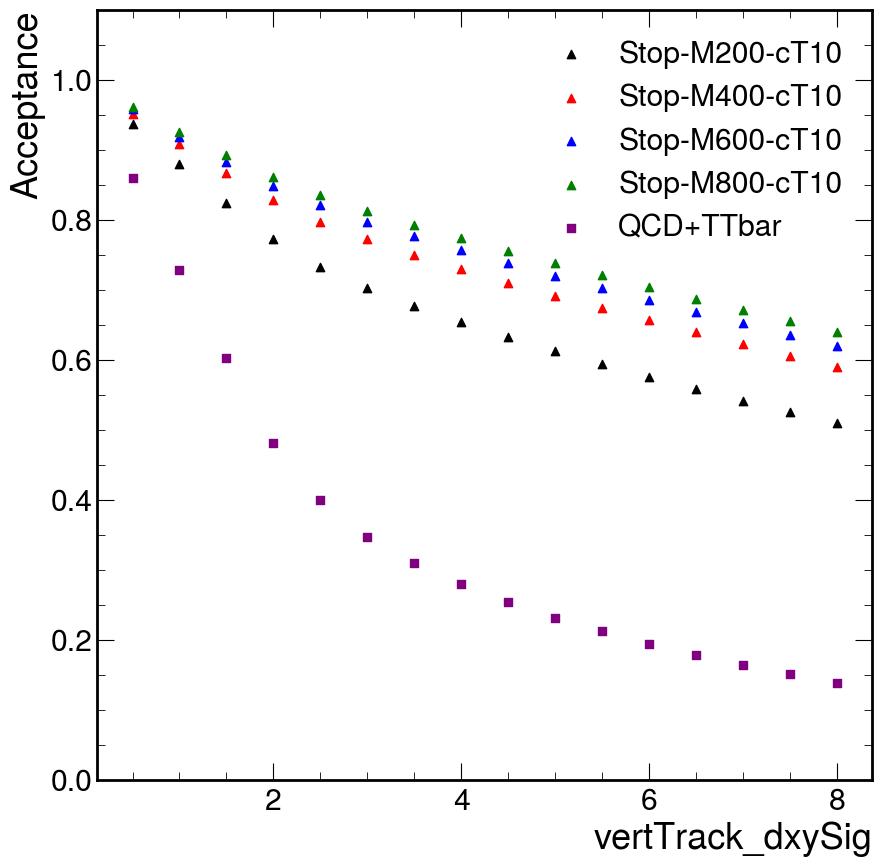

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140/250406_182644/TTto4Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-Resubmit/250407_082848/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v12GlobalTag140/250406_182744/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140/250406_182729/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v12GlobalTag140-Resubmit/250407_090131/QCD-4Jets_Bin-HT-1200

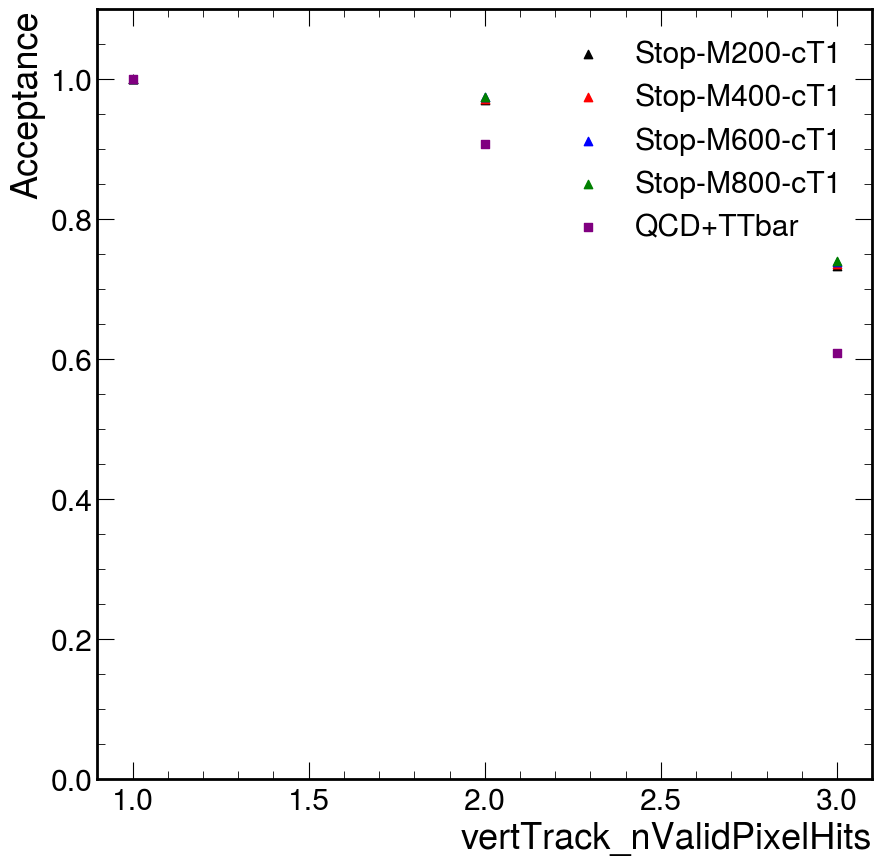

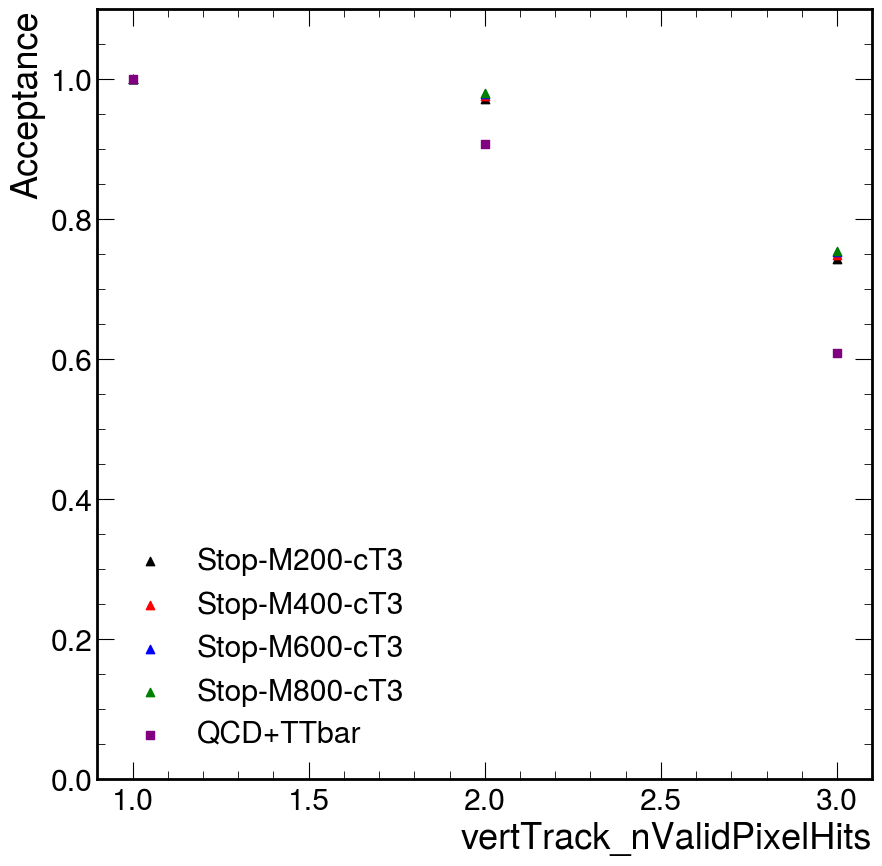

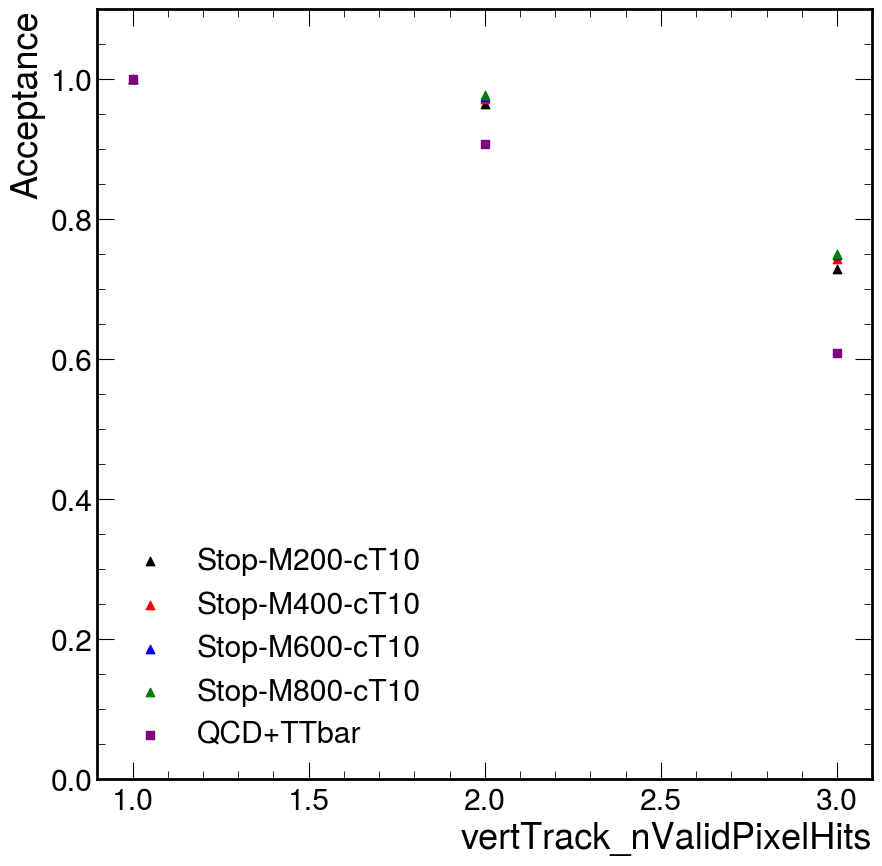

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v12GlobalTag140/250406_182723/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140/250406_182649/TTtoLNu2Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140/250406_182729/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140/250406_182656/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140/250406_182644/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Je

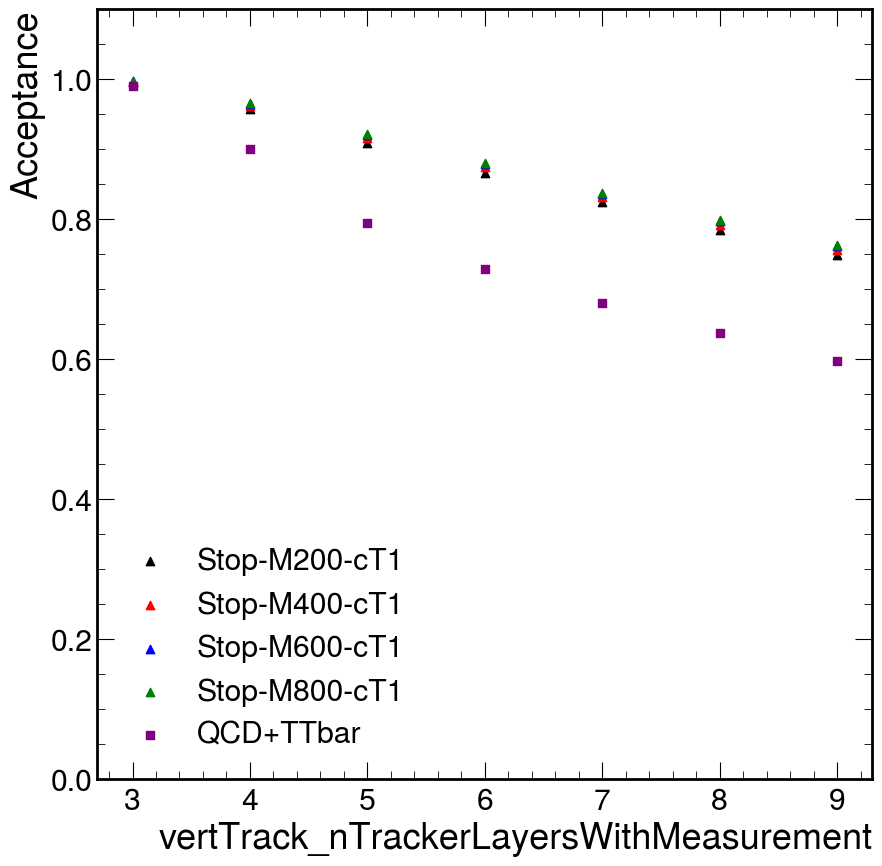

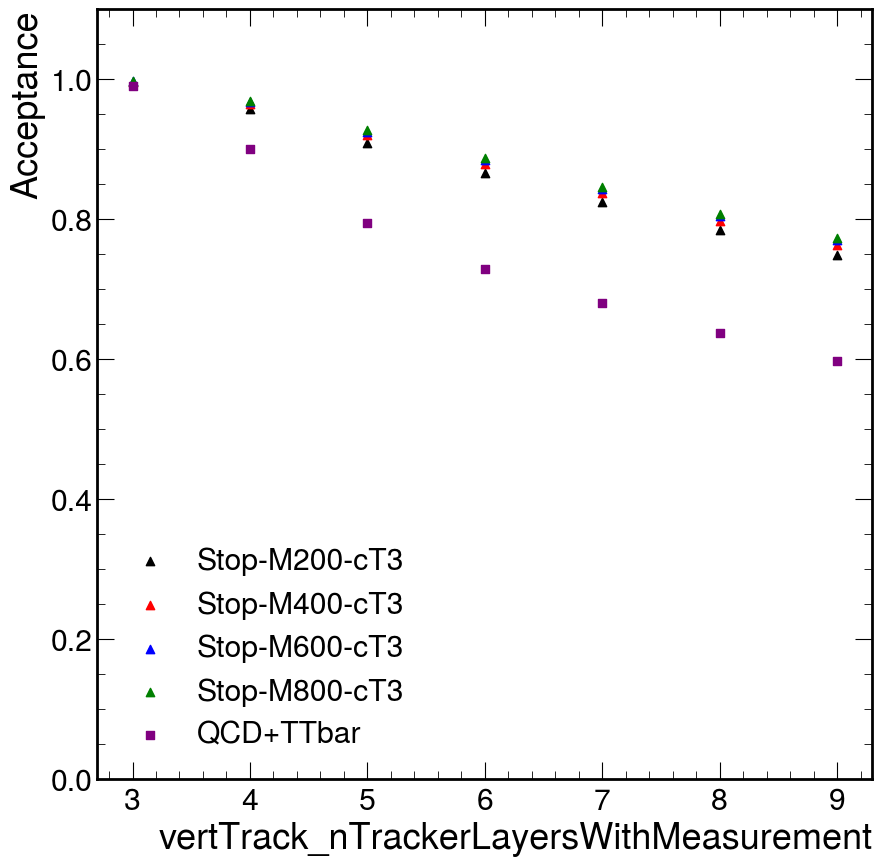

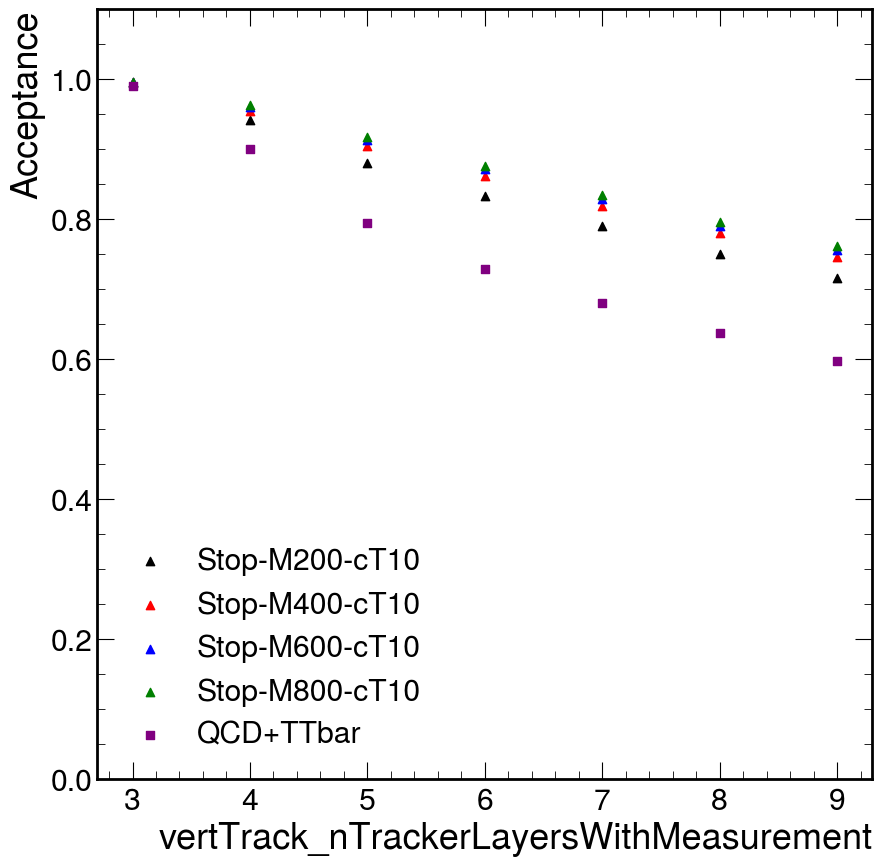

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v12GlobalTag140/250406_182644/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v12GlobalTag140/250406_182649/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v12GlobalTag140-Resubmit/250407_082848/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v12GlobalTag140/250406_182656/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v12GlobalTag140/250406_182729/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting

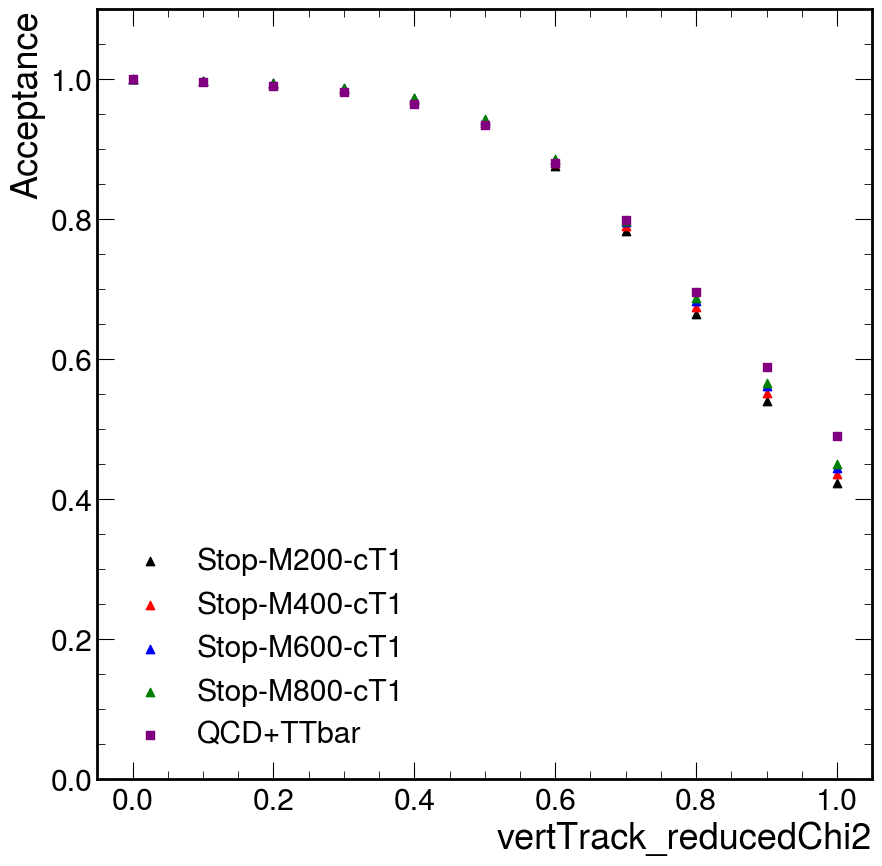

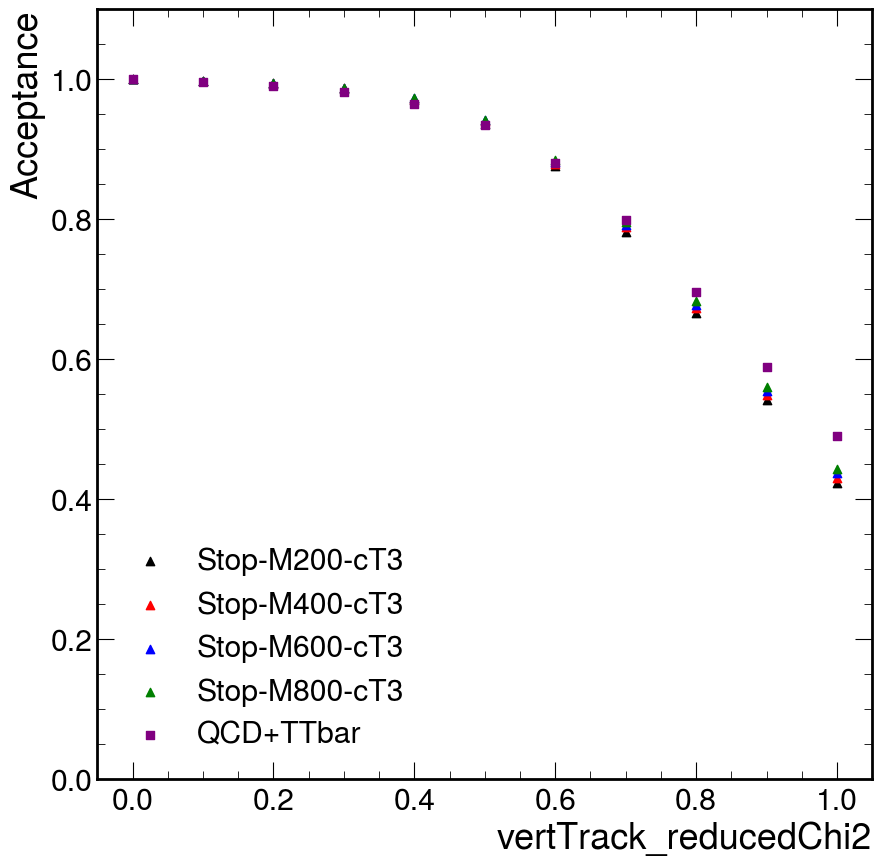

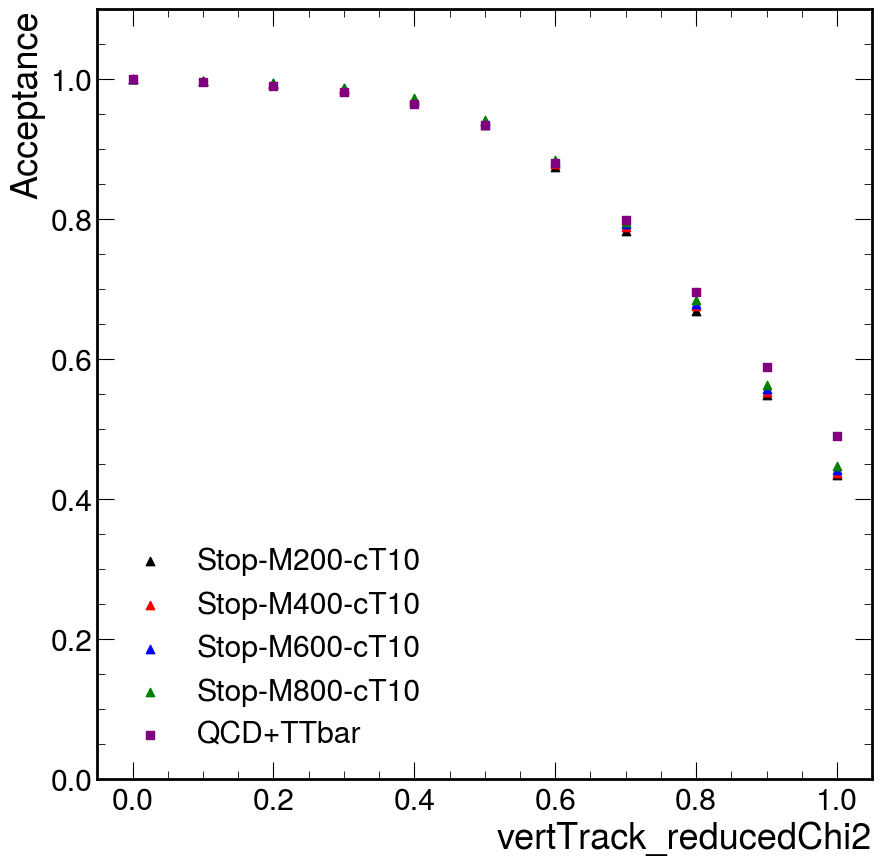

Total runtime: 65.88 seconds


In [10]:
#Track Cut Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

ptTrackCuts = np.linspace(1,3,21)
#dxySigCuts = np.linspace(4,8,9)
#pixelHitsCuts = np.linspace(1,3,3)
#nTrackerLayersCuts = np.linspace(5,9,5)

cutDict = {"vertTrack_pt": np.linspace(1,3,21), "vertTrack_dxySig": np.linspace(0.5,8,16), "vertTrack_nValidPixelHits": np.linspace(1,3,3), "vertTrack_nTrackerLayersWithMeasurement": np.linspace(3,9,7), "vertTrack_reducedChi2": np.linspace(0,1,11)}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight",branch,"vertTrack_iVtx","scoutVert_dBV"]
        #weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSum = np.zeros((len(cuts)))
        #weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSumSquared = np.zeros((len(cuts)))
        weightSkimSum = 0
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            data = batch[branch]
            if "vertTrack" in branch:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            data = data[mask]
            #dxySig = batch["vertTrack_dxySig"]
            #npixel = batch["vertTrack_nValidPixelHits"]
            #ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"]
            nTracks = ak.num(data,axis=1)
            weightSkimSum += ak.sum(nTracks*weights)
            masks = [(data > cuts[i]) for i in range(len(cuts))]
            #dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            #pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            #trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            for i in range(len(cuts)):
            #for j in range(len(dxySigCuts)):
            #for k in range(len(pixelHitsCuts)):
            #for l in range(len(nTrackerLayersCuts)):
                mask = masks[i] #& dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                dataMasked = data[mask]
                nTracks = ak.num(dataMasked,axis=1)
                weightSum[i] += ak.sum(nTracks*weights)
                weightSumSquared[i] += ak.sum(nTracks*(weights**2))
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
        output["weightSkimSum"] = {process: weightSkimSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

for branch, cuts in cutDict.items():

    bgPlotWeights = parallel_processing(processDict)
    sigPlotWeights = parallel_processing(signalDict)

    #Combining Background Subprocesses and Reweighting Events
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
    bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
    bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
    bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

    # **Plotting**
    for lifetime in ["1","3","10"]:
        fig, ax = plt.subplots()
        colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
        for signal, color in colors.items():
            efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
            ax.scatter(cuts,efficiency,label=signal,color=color,marker="^")
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        ax.scatter(cuts,fpr,label="QCD+TTbar",color="purple",marker="s")
        ax.set_ylabel("Acceptance")
        plt.xlabel(branch)
        plt.legend()
        ax.set_ylim(0.0,1.1)
        #plt.xscale("symlog",linthresh=10**-11)
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 8, 0, 3), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 9, 0, 2), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(13, 15, 2, 4), (7, 15, 1, 4), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(16, 15, 2, 2), (8, 15, 1, 3), (0, 12, 1, 3), (2, 6, 1, 2), (0, 8, 1, 1), (0, 4, 1, 2), (2, 3, 0, 1)]


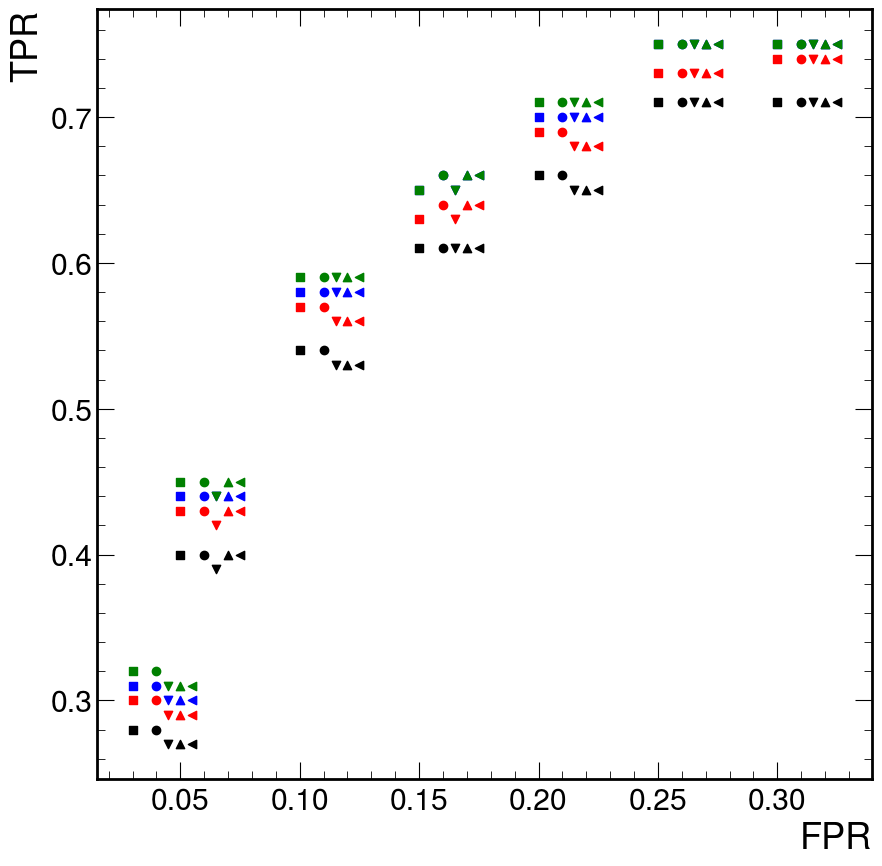

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[(10, 15, 2, 6), (7, 15, 1, 4), (0, 12, 1, 3), (0, 8, 0, 3), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(16, 15, 2, 2), (7, 15, 1, 4), (2, 11, 1, 2), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(16, 15, 2, 2), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]


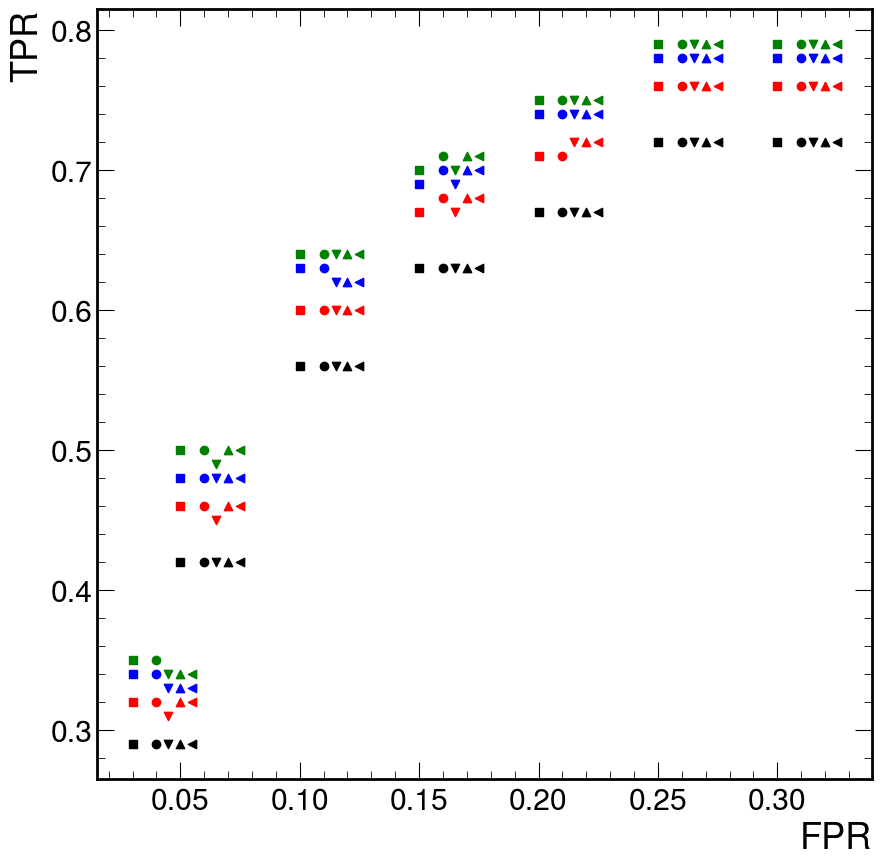

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
[(20, 15, 1, 6), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (2, 3, 0, 1)]


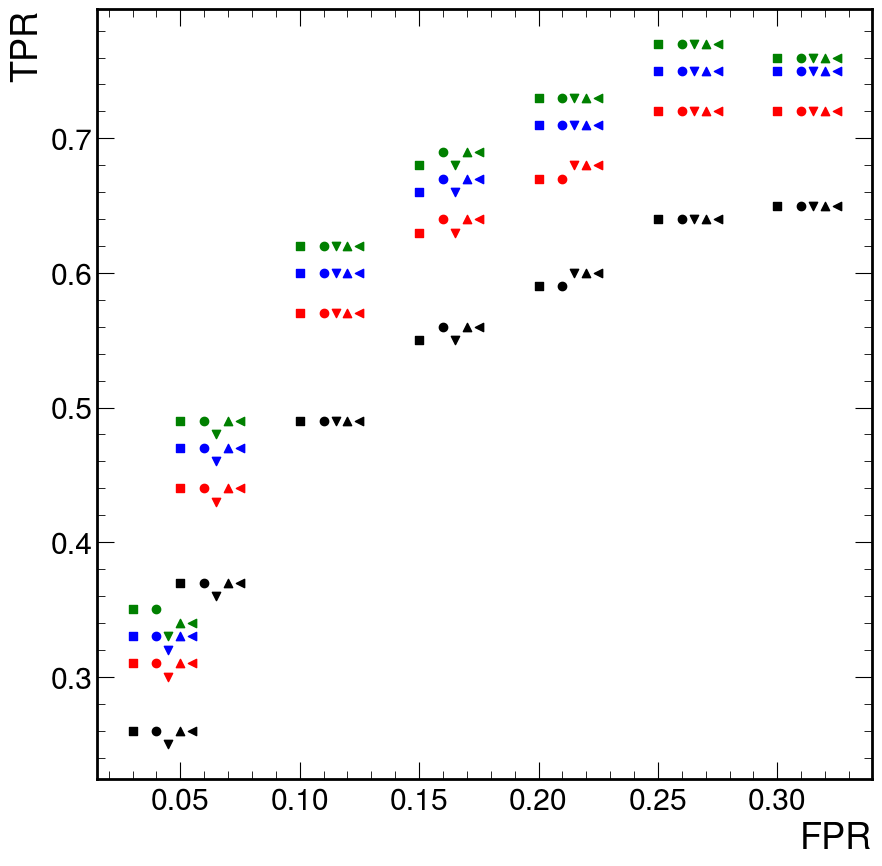

Total runtime: 2980.29 seconds


In [18]:
#Track Cut Grid Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

ptTrackCuts = np.linspace(1,3,21)
dxySigCuts = np.linspace(0.5,8,16)
pixelHitsCuts = np.linspace(1,3,3)
nTrackerLayersCuts = np.linspace(3,9,7)
"""
def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","vertTrack_iVtx","scoutVert_dBV","vertTrack_pt","vertTrack_dxySig","vertTrack_nValidPixelHits", "vertTrack_nTrackerLayersWithMeasurement"]
        weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSkimSum = 0
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            pt = batch["vertTrack_pt"][mask]
            dxySig = batch["vertTrack_dxySig"][mask]
            npixel = batch["vertTrack_nValidPixelHits"][mask]
            ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"][mask]
            nTracks = ak.num(pt,axis=1)
            weightSkimSum += ak.sum(nTracks*weights)
            ptMasks = [(pt > ptTrackCuts[i]) for i in range(len(ptTrackCuts))]
            dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            for i in range(len(ptTrackCuts)):
                for j in range(len(dxySigCuts)):
                    for k in range(len(pixelHitsCuts)):
                        for l in range(len(nTrackerLayersCuts)):
                            mask = ptMasks[i] & dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                            ptMasked = pt[mask]
                            nTracks = ak.num(ptMasked,axis=1)
                            weightSum[i][j][k][l] += ak.sum(nTracks*weights)
                            weightSumSquared[i][j][k][l] += ak.sum(nTracks*(weights**2))
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
        output["weightSkimSum"] = {process: weightSkimSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()


bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)
"""
# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        efficiency = np.round(efficiency,2)
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        fpr = np.round(fpr,2)
        unique_fpr = np.unique(fpr)
        max_effs = np.array([])
        thresh = [True,True,True,True,True,True,True]
        thresh_val = [0.01,0.05,0.1,0.15,0.2,0.25,0.3]
        indices = []
        for ux in unique_fpr:
            unique_eff = np.where(fpr == ux, efficiency, -1)
            max_eff = np.max(unique_eff)
            ind = np.unravel_index(np.argmax(unique_eff, axis=None), unique_eff.shape)
            if(ux>=thresh_val[0] and thresh[0]): 
                indices.append(ind)
                thresh[0] = False
            if(ux>=thresh_val[1] and thresh[1]): 
                indices.append(ind)
                thresh[1] = False
            if(ux>=thresh_val[2] and thresh[2]): 
                indices.append(ind)
                thresh[2] = False
            if(ux>=thresh_val[3] and thresh[3]): 
                indices.append(ind)
                thresh[3] = False
            if(ux>=thresh_val[4] and thresh[4]): 
                indices.append(ind)
                thresh[4] = False
            if(ux>=thresh_val[5] and thresh[5]): 
                indices.append(ind)
                thresh[5] = False
            if(ux>=thresh_val[6] and thresh[6]): 
                indices.append(ind)
                thresh[6] = False
            max_effs = np.append(max_effs,max_eff)
        print(indices)
        #ax.scatter(unique_fpr,max_effs,label=signal,color=color,zorder=1)
        indices = [(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 8, 0, 3), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2)
        indices = [(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 9, 0, 2), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.01,efficiency[index],color=color,marker="o",zorder=2)
        """
        indices = [(13, 15, 2, 4), (7, 15, 1, 4), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.02,efficiency[index],color=color,marker="^",zorder=2)
        indices = [(16, 15, 2, 2), (8, 15, 1, 3), (0, 12, 1, 3), (2, 6, 1, 2), (0, 8, 1, 1), (0, 4, 1, 2), (2, 3, 0, 1)]
        for index in indices:
            ax.scatter(fpr[index]+0.03,efficiency[index],color=color,marker="v",zorder=2)
        """
        indices = [(10, 15, 2, 6), (7, 15, 1, 4), (0, 12, 1, 3), (0, 8, 0, 3), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.015,efficiency[index],color=color,marker="v",zorder=2)
        indices = [(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.02,efficiency[index],color=color,marker="^",zorder=2)
        """
        indices = [(16, 15, 2, 2), (7, 15, 1, 4), (2, 11, 1, 2), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="pink")
        indices = [(16, 15, 2, 2), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="silver")
        """
        indices = [(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.025,efficiency[index],color=color,marker="<",zorder=2)
        """
        indices = [(20, 15, 1, 6), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (2, 3, 0, 1)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="beige")
        """
        
    ax.set_ylabel("TPR")
    plt.xlabel("FPR")
    #plt.yscale("log")
    plt.legend()
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v13-15TrackFPR/250506_174000/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v13-15TrackFPR/250506_174012/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v13-15TrackFPR/250506_174223/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v13-15TrackFPR/250506_174256/QCD-4Jets_Bin-HT-800to1000.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v13-15TrackFPR/250506_174025/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jet

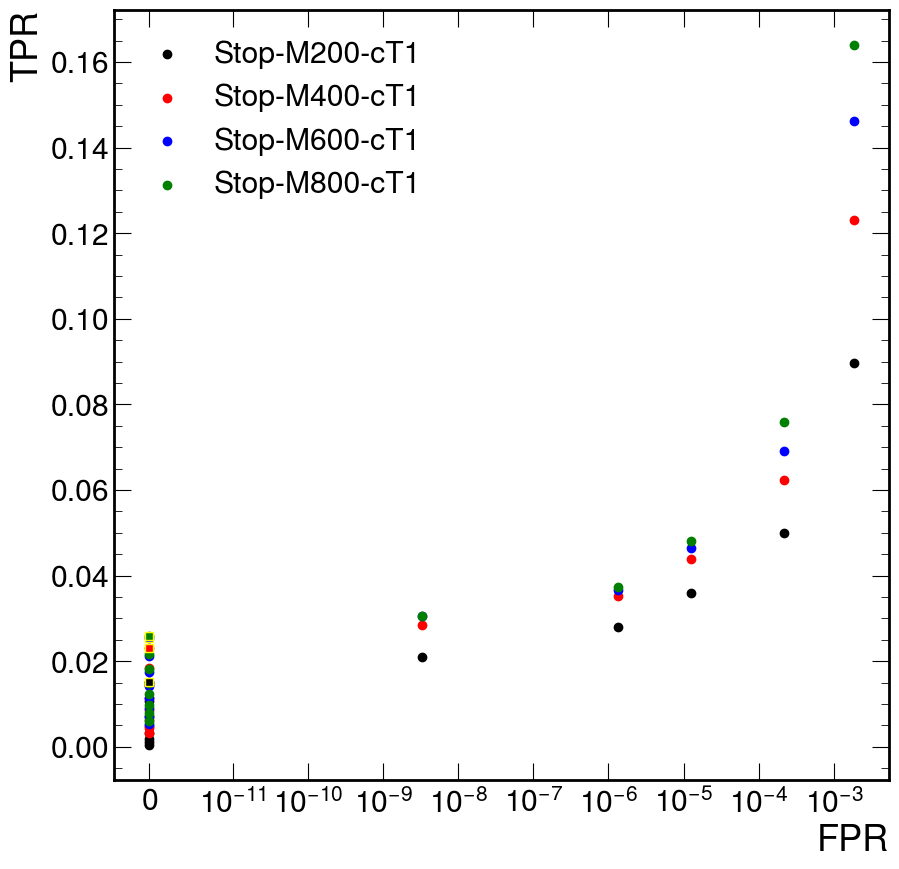

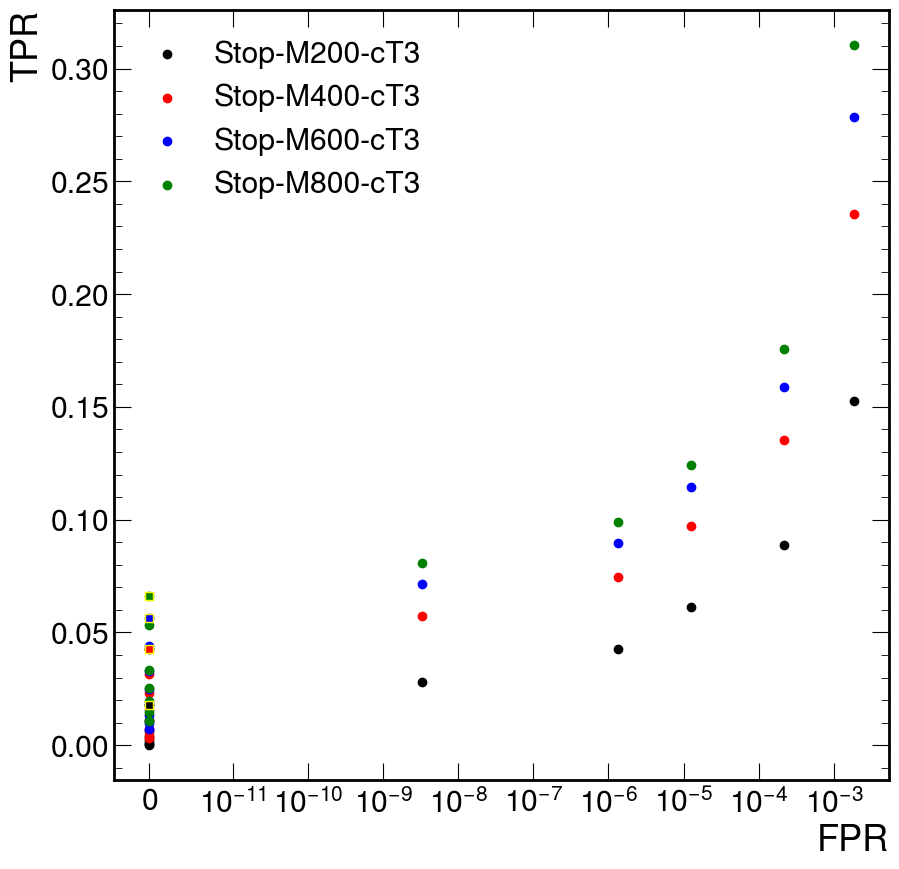

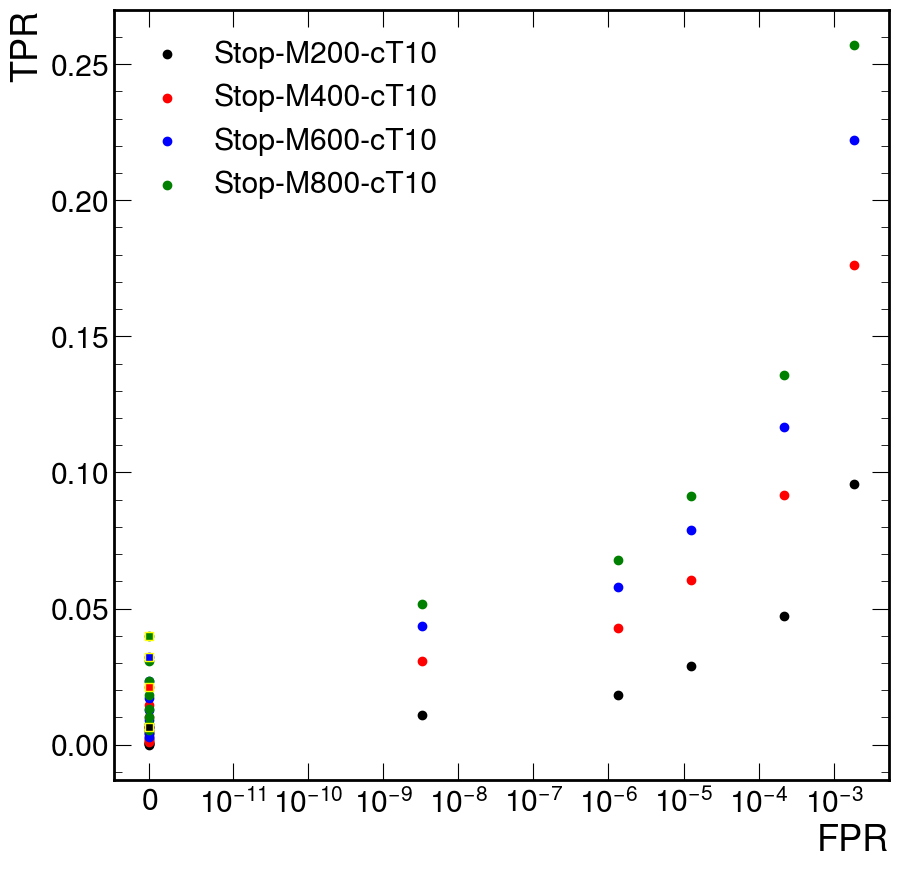

Total runtime: 63.15 seconds
total background: 226215788366.3997
best traditional sensitivity for signal Stop-M200-cT1 is 1.2788669227330172 sig eff: 0.015010101010101322 fpr: 0.0 requiring > 6.0 tracks and < 999.900000 uncertainty with track z shift < 999.9  3d shift < 999.9
best traditional sensitivity for signal Stop-M400-cT1 is 1.586154595239677 sig eff: 0.023089999999999816 fpr: 0.0 requiring > 6.0 tracks and < 999.900000 uncertainty with track z shift < 999.9  3d shift < 999.9
best traditional sensitivity for signal Stop-M600-cT1 is 1.6599995180722078 sig eff: 0.02529000000000002 fpr: 0.0 requiring > 6.0 tracks and < 999.900000 uncertainty with track z shift < 999.9  3d shift < 999.9
best traditional sensitivity for signal Stop-M800-cT1 is 1.6782776885843338 sig eff: 0.025850000000000133 fpr: 0.0 requiring > 6.0 tracks and < 999.900000 uncertainty with track z shift < 999.9  3d shift < 999.9
best traditional sensitivity for signal Stop-M200-cT3 is 1.3942189211167615 sig eff: 0.01

In [98]:
#Vertex and Track Cut Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#ptTrackCuts = np.linspace(1,3,21)
#dxySigCuts = np.linspace(0.5,8,16)
#pixelHitsCuts = np.linspace(1,3,3)
#nTrackerLayersCuts = np.linspace(3,9,7)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#20% fpr cuts
#ptTrackCuts = np.linspace(1.2,1.2,1)
#dxySigCuts = np.linspace(3.0,3.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(4,4,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#15% fpr cuts
ptTrackCuts = np.linspace(1,1,1)
dxySigCuts = np.linspace(5.0,5.0,1)
pixelHitsCuts = np.linspace(1,1,1)
nTrackerLayersCuts = np.linspace(5,5,1)
#shiftZCuts = np.linspace(0.001,0.005,5)
shiftZCuts = np.linspace(999.9,999.9,1)
#shift3DCuts = np.linspace(0.001,0.005,5)
shift3DCuts = np.linspace(999.9,999.9,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
errCuts = np.linspace(999.9,999.9,1)[::-1]
nTrackCuts = np.linspace(1,13,13)
#dTCuts = np.linspace(0,0.12,13)

#10% fpr cuts
#ptTrackCuts = np.linspace(1.2,1.2,1)
#dxySigCuts = np.linspace(6.0,6.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(5,5,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#5% fpr cuts
#ptTrackCuts = np.linspace(1.8,1.8,1)
#dxySigCuts = np.linspace(8.0,8.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(6,6,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#1% fpr cuts
#ptTrackCuts = np.linspace(3.0,3.0,1)
#dxySigCuts = np.linspace(8.0,8.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(9,9,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

def fast_count_vertices_numpy(ivtxMasked, dBV):
    result = []
    for ind_event, dBV_event in zip(ivtxMasked, dBV):
        counts = np.zeros(len(dBV_event), dtype=int)
        np.add.at(counts, np.array(ind_event), 1)
        result.append(counts)
    return ak.Array(result)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","vertTrack_iVtx","vertTrack_pt","vertTrack_dxySig","vertTrack_nValidPixelHits", "vertTrack_nTrackerLayersWithMeasurement","vertTrack_shift3DSig","vertTrack_shift3DValue","vertTrack_shiftZValue"]
        weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts),len(shiftZCuts),len(shift3DCuts),len(errCuts),len(nTrackCuts)))
        weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts),len(shiftZCuts),len(shift3DCuts),len(errCuts),len(nTrackCuts)))
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights   
            mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            pt = batch["vertTrack_pt"][mask]
            dxySig = batch["vertTrack_dxySig"][mask]
            npixel = batch["vertTrack_nValidPixelHits"][mask]
            ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"][mask]
            shiftZ = batch["vertTrack_shiftZValue"][mask]
            shift3D = batch["vertTrack_shift3DSig"][mask]
            ivtx = batch["vertTrack_iVtx"][mask]
            
            ptMasks = [(pt > ptTrackCuts[i]) for i in range(len(ptTrackCuts))]
            dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            shiftZMasks = [(shiftZ < shiftZCuts[a]) for a in range(len(shiftZCuts))]
            shift3DMasks = [(shift3D < shift3DCuts[b]) for b in range(len(shift3DCuts))]
            
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            #dT = batch["scoutVert_dT"]
            dBVMask = (dBV >= 0.1)
            dBVErrMask = [(dBVErr < errCuts[m]) for m in range(len(errCuts))]
            #dTMask = [(dT <= dTCuts[m]) for m in range(len(dTCuts))]
            
            for i in range(len(ptTrackCuts)):
                for j in range(len(dxySigCuts)):
                    for k in range(len(pixelHitsCuts)):
                        for l in range(len(nTrackerLayersCuts)):
                            for a in range(len(shiftZCuts)):
                                for b in range(len(shift3DCuts)):
                                    mask = ptMasks[i] & dxyMasks[j] & pixelMasks[k] & trackerMasks[l] & shiftZMasks[a] & shift3DMasks[b]
                                    ivtxMasked = ivtx[mask]
                                    #ntracks = ak.Array([
                                    #    np.bincount(ind_event, minlength=len(dBV_event))
                                    #    for ind_event, dBV_event in zip(ivtxMasked, dBV)
                                    #])
                                    
                                    ntracks = fast_count_vertices_numpy(ivtxMasked, dBV)
                                    
                                    ntrackMasks = [(ntracks > nTrackCuts[n]) for n in range(len(nTrackCuts))]
                                    for m in range(len(errCuts)):
                                        for n in range(len(nTrackCuts)):
                                            mask = dBVMask & dBVErrMask[m] & ntrackMasks[n] #& chi2Mask[o]
                                            dBVMasked = dBV[mask]
                                            mask = ak.num(dBVMasked,axis=1)>1
                                            weightsMasked = weights[mask]
                                            weightSum[i][j][k][l][a][b][m][n] += ak.sum(weightsMasked)
                                            weightSumSquared[i][j][k][l][a][b][m][n] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0,0,0,0,0,0,0,0]}#, "Hto2Sto4D-cT1-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS55": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS55": [0,0,0,0,0,0,0,0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT1": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0,0,0,0,0,0,0,0]}#, "Hto2Sto4D-cT1-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS55": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS55": [0,0,0,0,0,0,0,0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    #for lifetime in ["1","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        sensitivity = np.nan_to_num(sensitivity)
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),efficiency[ind],fpr[ind],ptTrackCuts[ind[0]],dxySigCuts[ind[1]],pixelHitsCuts[ind[2]],nTrackerLayersCuts[ind[3]],shiftZCuts[ind[4]],shift3DCuts[ind[5]],errCuts[ind[6]],nTrackCuts[ind[7]]]
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),efficiency[ind],fpr[ind],ptTrackCuts[ind[0]],dxySigCuts[ind[1]],pixelHitsCuts[ind[2]],nTrackerLayersCuts[ind[3]],shiftZCuts[ind[4]],shift3DCuts[ind[5]],errCuts[ind[6]],nTrackCuts[ind[7]]]
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
        plt.xscale("symlog",linthresh=10**-11)
    ax.set_ylabel("TPR")
    #ax.set_ylim(0.0,0.7)
    plt.xlabel("FPR")
    plt.legend()
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
print("total background:",bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"sig eff:",cuts[1],"fpr:",cuts[2],"requiring >",cuts[10],"tracks and <",f"{cuts[9]:3f}","uncertainty with track z shift <",cuts[7]," 3d shift <",cuts[8])# track selection of pt>",cuts[3],"dxySig>",cuts[4],"pixelHits>",cuts[5],"tracker layers>",cuts[6])
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"sig eff:",cuts[1],"fpr:",cuts[2],"requiring >",cuts[10],"tracks and <",f"{cuts[9]:3f}","uncertainty with track z shift <",cuts[7]," 3d shift <",cuts[8])# track selection of pt>",cuts[3],"dxySig>",cuts[4],"pixelHits>",cuts[5],"tracker layers>",cuts[6])


In [28]:
indices = [(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 9, 0, 2), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]

print(np.linspace(1,3,21)[0])
print(np.linspace(0.5,8,16)[3])
print(np.linspace(1,3,3)[0])
print(np.linspace(3,9,7)[3])

ptTrackCuts = np.linspace(1,3,21)
dxySigCuts = np.linspace(0.5,8,16)
pixelHitsCuts = np.linspace(1,3,3)
nTrackerLayersCuts = np.linspace(3,9,7)

1.0
2.0
1.0
6.0


Processing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v9/250714_175617/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_800to1000_30Mevts_v9/250714_175158/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v9/250714_175719/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v9/250714_175135/QCD-4Jets_Bin-HT-200to400.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-400to600_TuneCP

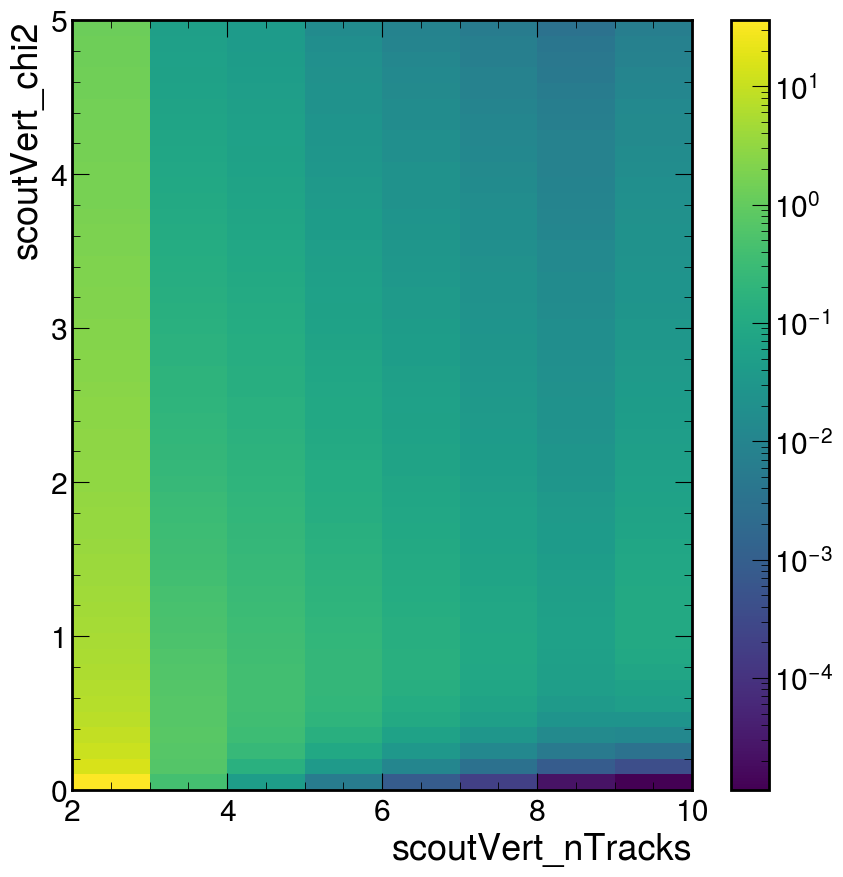

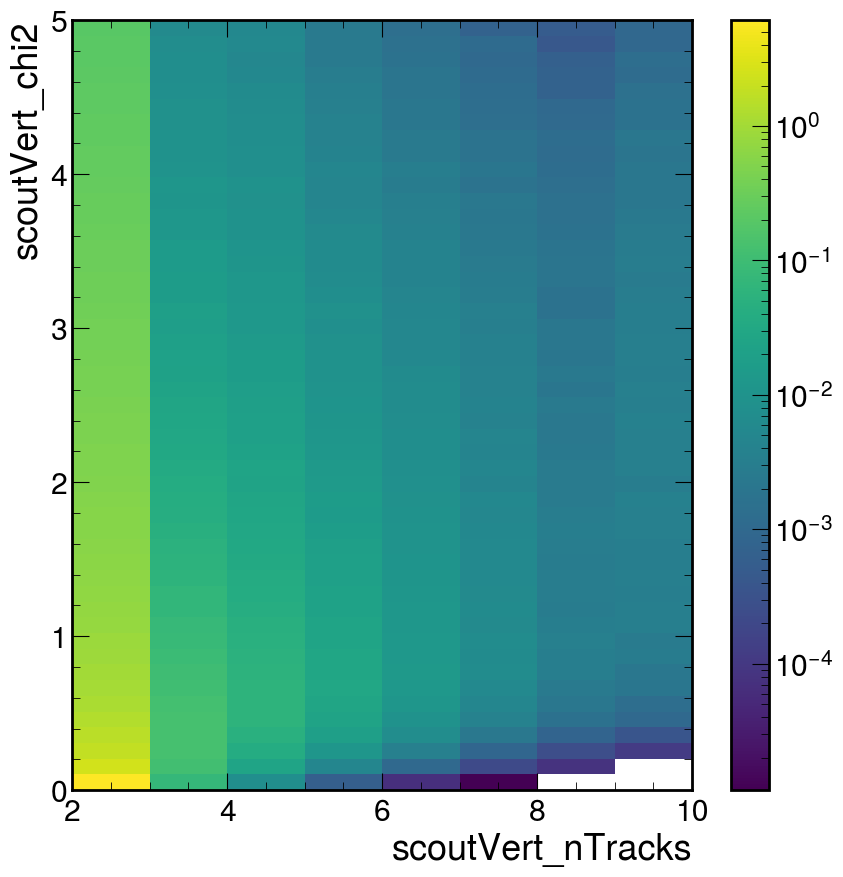

2024H


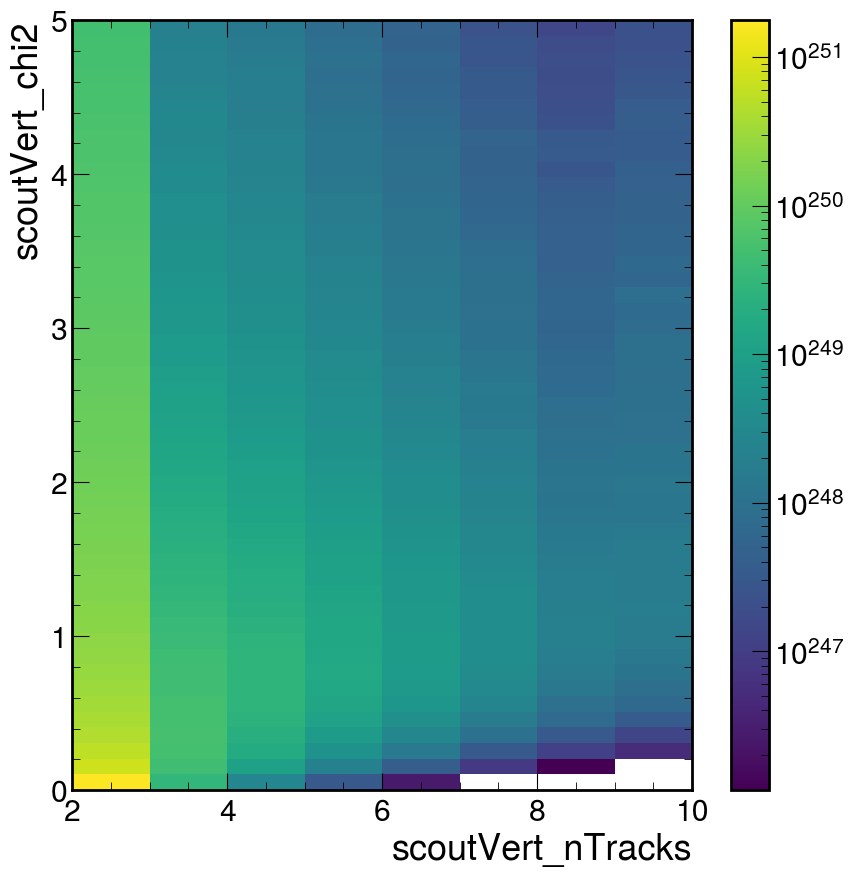

Total runtime: 482.46 seconds


In [3]:
#2D Plot Script

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.colors import LogNorm

plotDict = {
    #"vertTrack_pt": [0,50,101], "vertTrack_eta": [-3,3,101], "vertTrack_phi": [-3.142,3.142,101],
    #"vertTrack_reducedChi2": [0,7,51], "vertTrack_dxy": [0,0.3,51], "vertTrack_dxySig": [0,50,101],
    #"vertTrack_nValidPixelHits": [0,13,14], "vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    "scoutVert_dBV": [0,1,101], "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    "scoutVert_nTracks": [2,10,9], "scoutVert_chi2": [0,5,50],
    "scoutVert_dT": [0,0.5,101]
    #"scoutTrack_eta": [-3,3,101], "scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxy": [0,0.03,51], "scoutTrack_dxySig": [0,50,101]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    weightSum = np.zeros((plotDict["scoutVert_nTracks"][2]-1,plotDict["scoutVert_chi2"][2]-1))
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            x_binning = plotDict["scoutVert_nTracks"]
            x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
            x_data = batch["scoutVert_nTracks"]

            y_binning = plotDict["scoutVert_chi2"]
            y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
            y_data = batch["scoutVert_chi2"]
            
            
            #Apply displacement cut
            mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2.0)
            x_data = x_data[mask]
            y_data = y_data[mask]#*np.sqrt(x_data)
            broadcastWeights, x_data = ak.broadcast_arrays(weights,x_data)
            # Apply mask and flatten data
            x_data = ak.flatten(x_data,axis=None)
            x_data = np.clip(x_data,x_bins[0],x_bins[-1])
            y_data = ak.flatten(y_data,axis=None)
            y_data = np.clip(y_data,y_bins[0],y_bins[-1])
            weights_filtered = ak.flatten(broadcastWeights,axis=None)
            # Compute histograms
            n, xedges, yedges = np.histogram2d(x_data,y_data,weights=weights_filtered, bins=(x_bins,y_bins))
            weightSum = weightSum + n
    output["trkVert_eta_phi"] = {process: weightSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in ["trkVert_eta_phi"]:
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
for plot in ["trkVert_eta_phi"]:
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] #/ sigPlotWeights["genWeightSum"][process]

# **Plotting**
x_binning = plotDict["scoutVert_nTracks"]
y_binning = plotDict["scoutVert_chi2"]
x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
plt.pcolormesh(x_bins, y_bins, np.array(bgPlotWeights["trkVert_eta_phi"]["QCD"]).T, shading='auto', cmap='viridis',norm=LogNorm())
plt.colorbar()
plt.xlabel("scoutVert_nTracks")
plt.ylabel("scoutVert_chi2")
plt.show()
plt.pcolormesh(x_bins, y_bins, np.array(bgPlotWeights["trkVert_eta_phi"]["TTbar"]).T, shading='auto', cmap='viridis',norm=LogNorm())
plt.colorbar()
plt.xlabel("scoutVert_nTracks")
plt.ylabel("scoutVert_chi2")
plt.show()

for signal in signalDict.keys():
    print(signal)
    plt.pcolormesh(x_bins, y_bins, np.array(sigPlotWeights["trkVert_eta_phi"][signal]).T, shading='auto', cmap='viridis',norm=LogNorm())
    plt.colorbar()
    plt.xlabel("scoutVert_nTracks")
    plt.ylabel("scoutVert_chi2")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [19]:
def histogram_correlation(x_edges, y_edges, H):
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers, indexing='xy')
    x_vals = X.ravel()
    y_vals = Y.ravel()
    weights = H.ravel()
    mean_x = np.average(x_vals, weights=weights)
    mean_y = np.average(y_vals, weights=weights)
    cov_xy = np.average((x_vals - mean_x) * (y_vals - mean_y), weights=weights)
    var_x = np.average((x_vals - mean_x)**2, weights=weights)
    var_y = np.average((y_vals - mean_y)**2, weights=weights)
    return cov_xy / np.sqrt(var_x * var_y)

print("TTbar", histogram_correlation(x_bins, y_bins, np.array(bgPlotWeights["trkVert_eta_phi"]["TTbar"])))
print("QCD", histogram_correlation(x_bins, y_bins, np.array(bgPlotWeights["trkVert_eta_phi"]["QCD"])))
print("Stop M200 cT1", histogram_correlation(x_bins, y_bins, np.array(sigPlotWeights["trkVert_eta_phi"]["Stop-M200-cT1"])))

TTbar 0.1853999522036858
QCD 0.19591442631101194
Stop M200 cT1 0.42145008900765024


Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124011/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123852/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124025/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123837/TTto4Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tr

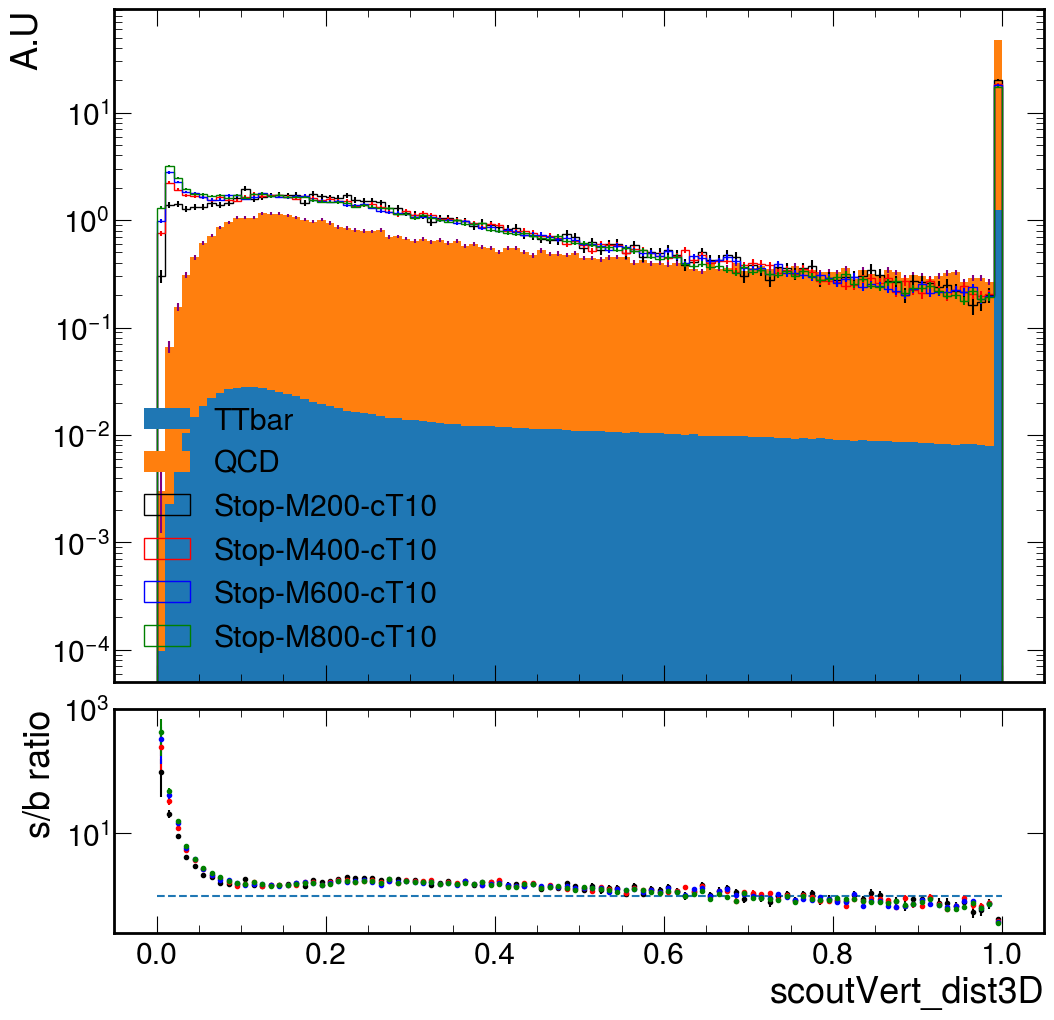

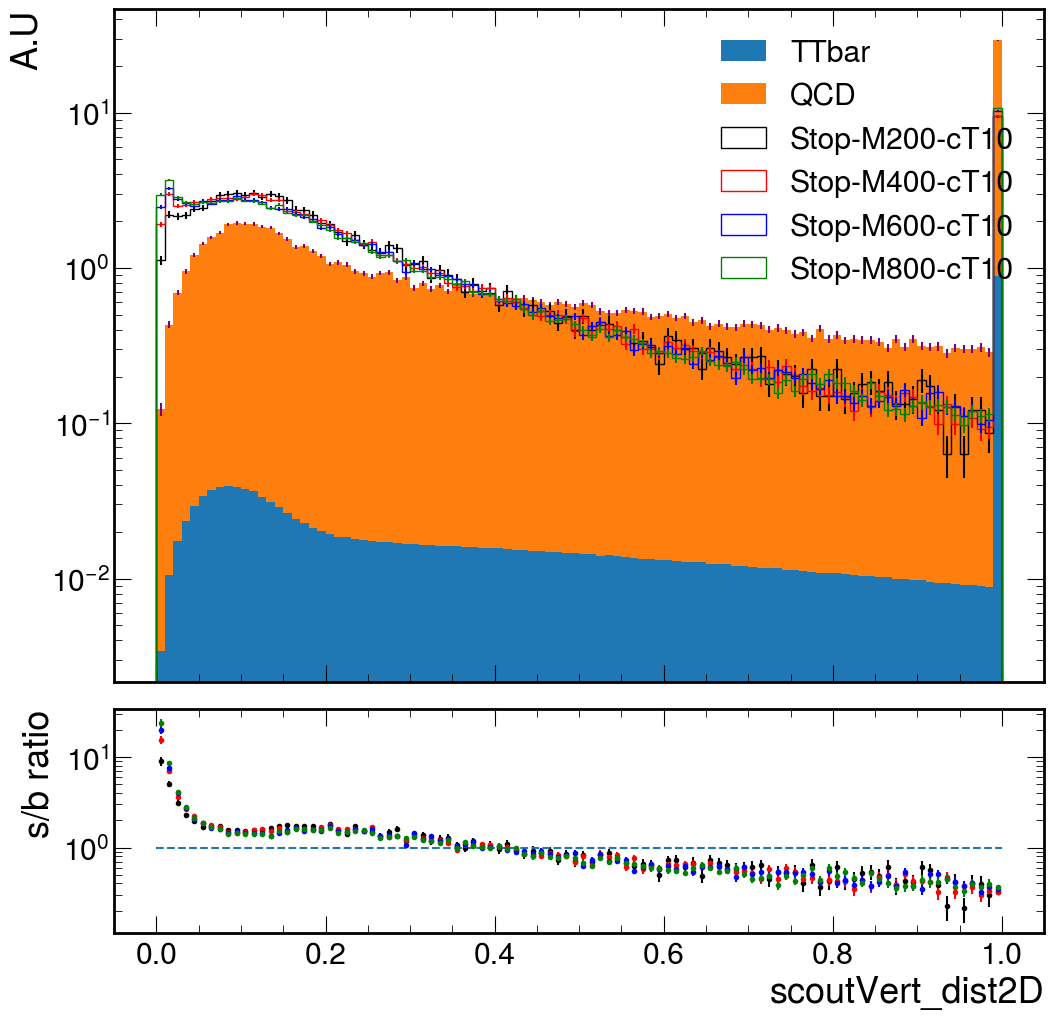

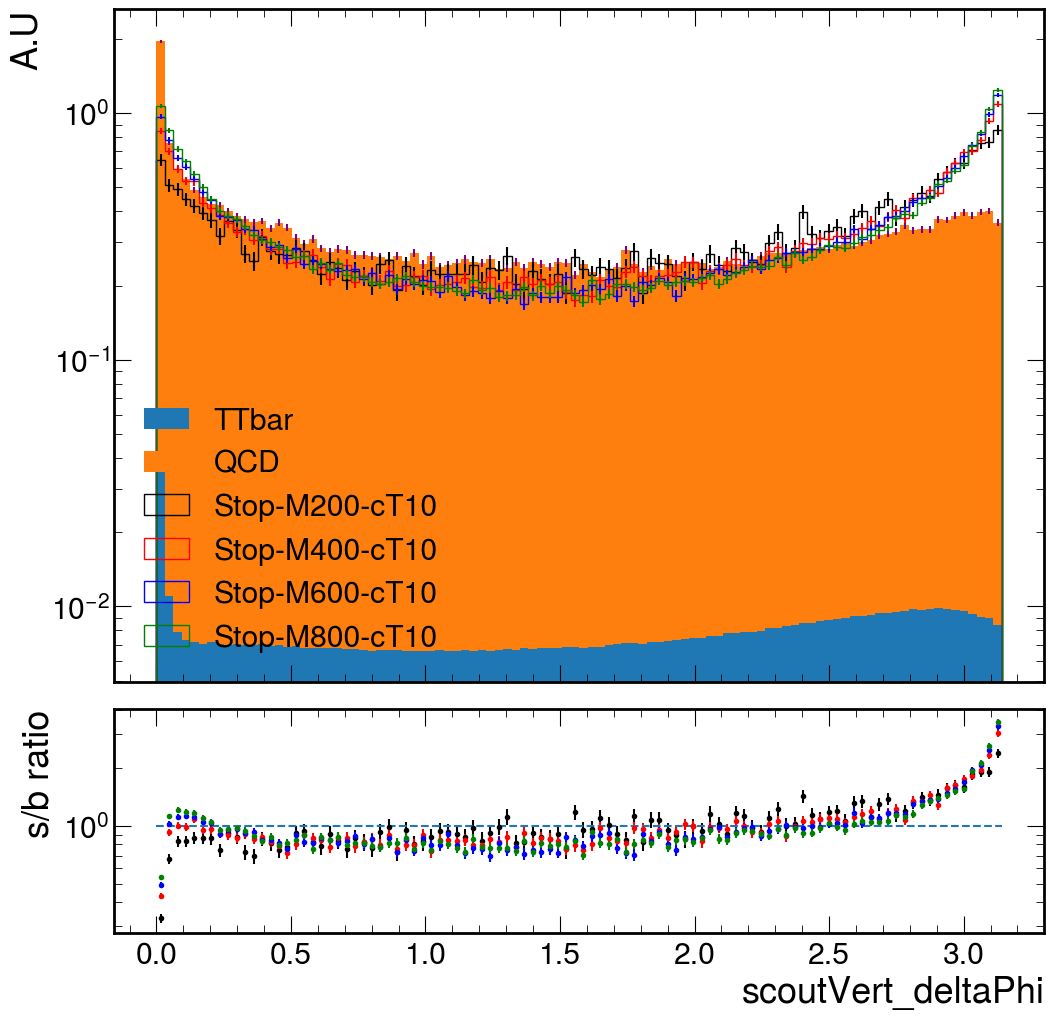

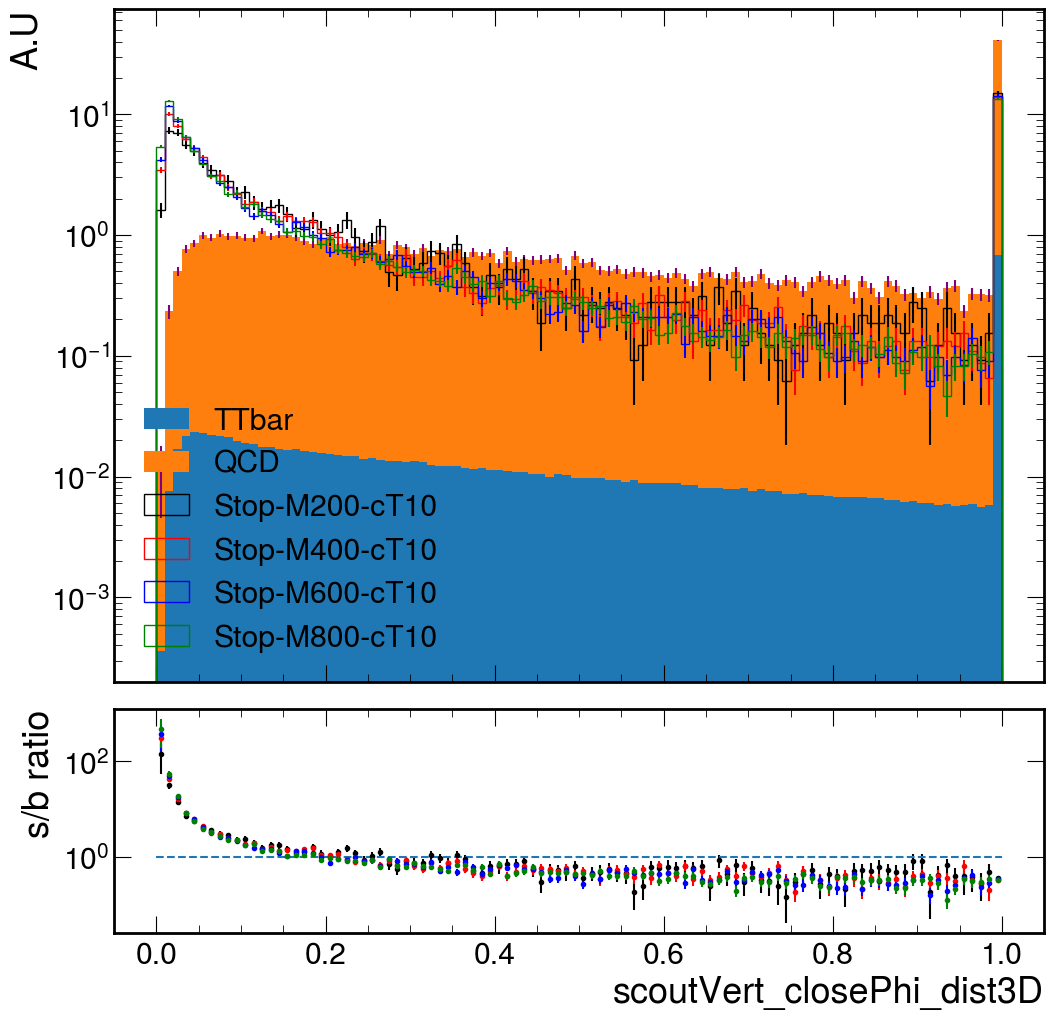

/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-awkward/2.1.1-edf8d8121f794c78bb662dab159497fd/lib/python3.9/site-packages/awkward/_backends.py:58: RuntimeWarning: divide by zero encountered in divide
  return getattr(ufunc, method)(*args, **kwargs)
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-awkward/2.1.1-edf8d8121f794c78bb662dab159497fd/lib/python3.9/site-packages/awkward/_backends.py:58: RuntimeWarning: invalid value encountered in divide
  return getattr(ufunc, method)(*args, **kwargs)


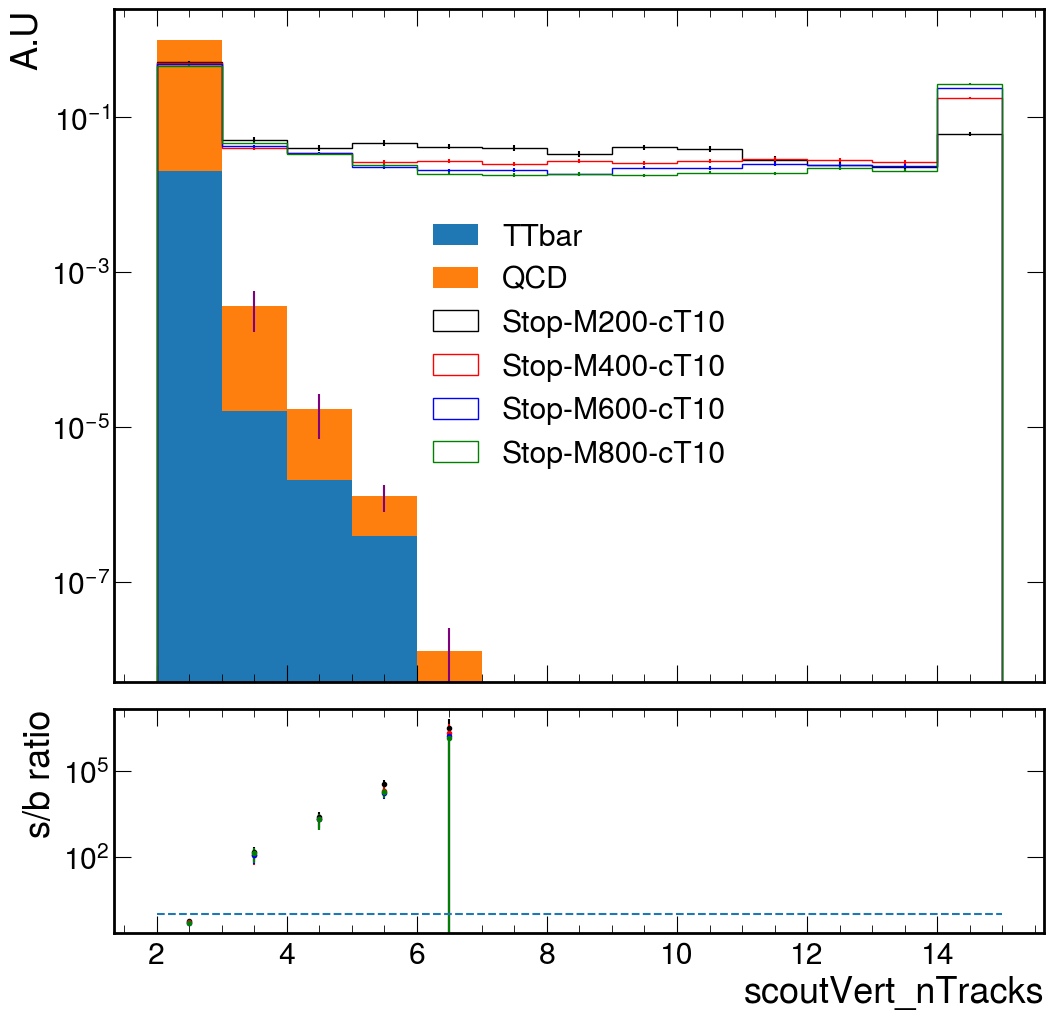

Total runtime: 720.50 seconds


In [7]:
#Vertex dVV Plots

plotDict = {
    "scoutVert_dist3D": [0,1,101], "scoutVert_dist2D": [0,1,101], "scoutVert_deltaPhi": [0,3.142,101], "scoutVert_closePhi_dist3D": [0,1,101], "scoutVert_nTracks": [2,15,14]
}

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed       

def remove_duplicates_from_subarrays(arr):
    """
    Remove duplicate indices from each subarray in a 2D awkward array.
    
    Parameters:
    -----------
    arr : awkward.Array
        A 2D awkward array of indices
        
    Returns:
    --------
    awkward.Array
        A 2D awkward array with duplicates removed from each subarray
    """
    # Convert to numpy for processing
    content = ak.to_numpy(ak.flatten(arr))
    offsets = ak.to_numpy(ak.num(arr, axis=1))
    
    # Compute the starting index for each subarray
    starts = np.zeros(len(offsets), dtype=np.int64)
    np.cumsum(offsets[:-1], out=starts[1:])
    
    # Create a list to hold the processed subarrays
    result_list = []
    
    # Process each subarray
    for i in range(len(offsets)):
        start_idx = starts[i]
        end_idx = start_idx + offsets[i]
        
        # Extract the subarray and remove duplicates
        subarray = content[start_idx:end_idx]
        unique_subarray = np.unique(subarray)
        
        result_list.append(unique_subarray)
    
    # Convert back to awkward array
    return ak.Array(result_list)


def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_x","scoutVert_y","scoutVert_z","scoutVert_dBV","scoutVert_phi","scoutVert_nTracks", "weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=10000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            vx = batch["scoutVert_x"]
            vy = batch["scoutVert_y"]
            vz = batch["scoutVert_z"]
            phi = batch["scoutVert_phi"]
            ntracks = batch["scoutVert_nTracks"]

            # Apply displacement cut
            mask = (batch["scoutVert_dBV"] >= 0.01)
            vx = vx[mask]
            vy = vy[mask]
            vz = vz[mask]
            phi = phi[mask]
            ntracks = ntracks[mask]
            
            idx = ak.argcombinations(vx, 2, fields=["i", "j"])  
            dx = vx[idx.i] - vx[idx.j]
            dy = vy[idx.i] - vy[idx.j]
            dz = vz[idx.i] - vz[idx.j]
            dphi = abs(phi[idx.i] - phi[idx.j])
            norm_dphi = ak.where(dphi > np.pi,2 * np.pi - dphi,dphi)
            distances3D = np.sqrt(dx**2 + dy**2 + dz**2)
            distances2D = np.sqrt(dx**2 + dy**2)
            mask = (norm_dphi<0.5) & (distances3D<0.2)
            close_idx = idx[mask]
            close_idx = ak.concatenate((close_idx.i,close_idx.j),axis=1)
            close_idx = remove_duplicates_from_subarrays(close_idx)
            
            for plot, binning in plotDict.items():
                if "deltaPhi" in plot:
                    data = norm_dphi
                elif "closePhi_dist3D" in plot:
                    mask = (norm_dphi<0.5)
                    data = distances3D[mask]
                elif "dist3D" in plot:
                    data = distances3D
                elif "dist2D" in plot:
                    data = distances2D
                elif "nTracks" in plot:
                    data = ntracks[close_idx]
                bins = np.linspace(binning[0], binning[1], binning[2])
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
for plot in plotDict.keys():
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"Stop-M200-cT10": "black", "Stop-M400-cT10": "red", "Stop-M600-cT10": "blue", "Stop-M800-cT10": "green"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


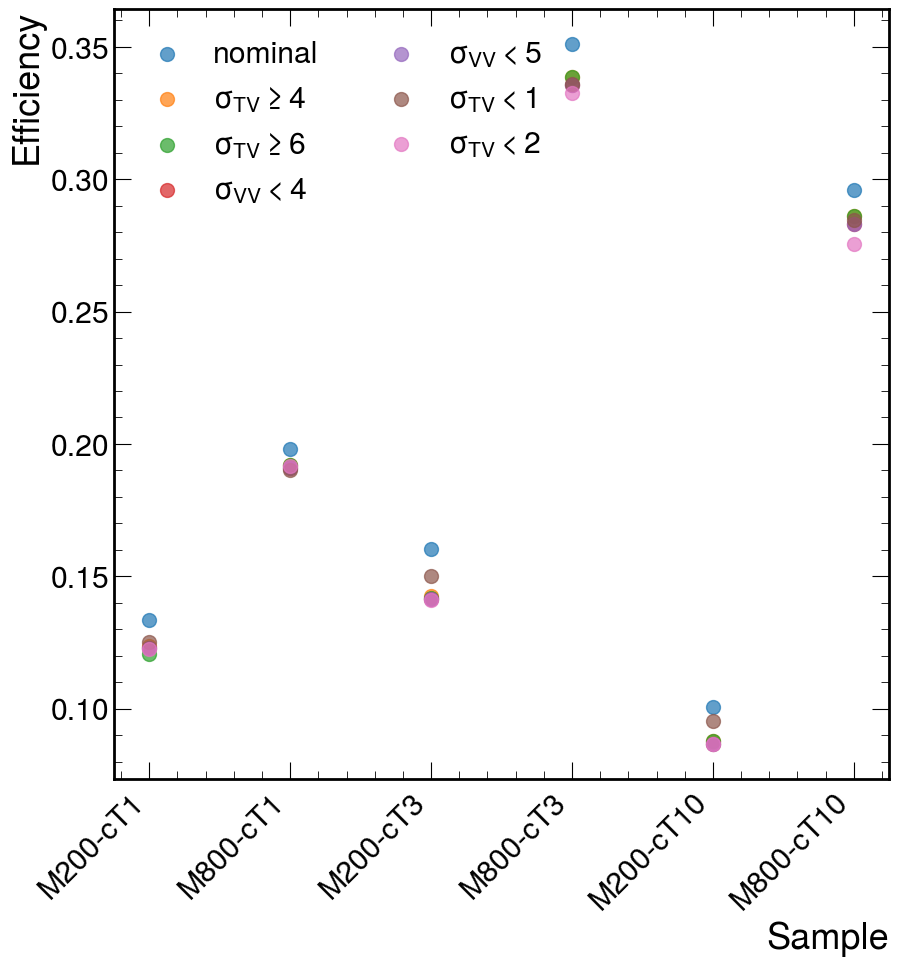

In [51]:
import matplotlib.pyplot as plt

def create_scatter_plot(x_labels, y_values, title="Scatter Plot", x_label="Categories", y_label="Values", legend="nominal"):
    """
    Creates a scatter plot with string labels on the x-axis and float values on the y-axis
    
    Args:
        x_labels (list): List of strings for x-axis labels
        y_values (list): List of floats for y values
        title (str): Title of the plot
        x_label (str): Label for x-axis
        y_label (str): Label for y-axis
    """
    # Check if input lists have the same length
    if len(x_labels) != len(y_values):
        raise ValueError("The lists of x labels and y values must have the same length")
    
    # Create x-coordinates (just numerical positions)
    x_positions = list(range(len(x_labels)))
    plt.scatter(x_positions, y_values, s=100, alpha=0.7,label=legend)
    
    # Set the x-axis ticks and labels
    plt.xticks(x_positions, x_labels, rotation=45, ha='right')
    
    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    leg = plt.legend(frameon=False,ncol=2)
    leg.get_frame().set_edgecolor('black')

# Example usage
if __name__ == "__main__":
    # Sample data
    categories = ["M200-cT1","M800-cT1","M200-cT3","M800-cT3","M200-cT10","M800-cT10"]
    nominal_values = [0.13335353535351235,0.19808999999995566,0.160289999999968,0.3509793814432051,0.10056112224447658,0.2957499999999237]
    maxTrackVertSig4_values = [0.12371717171715187,0.19207999999995762,0.1426499999999738,0.3386082474225906,0.08784569138275729,0.2860299999999269]
    maxTrackVertSig6_values = [0.12077777777775889,0.19207999999995762,0.141949999999974,0.3386082474225906,0.08784569138275729,0.2860299999999269]
    mergeShared3_values = [0.12294949494947535,0.190849999999958,0.1413399999999742,0.33540206185558136,0.08668336673345907,0.2829699999999279]
    mergeShared5_values = [0.12132323232321326,0.19267999999995744,0.14289999999997371,0.3399072164947551,0.08845691382764687,0.2875699999999264]
    minTrackVertSig1_values = [0.1252525252525049,0.1900099999999583,0.15008999999997136,0.3360618556700141,0.09551102204407742,0.2845199999999274]
    minTrackVertSig2_values = [0.12239393939391997,0.19149999999995782,0.14113999999997429,0.33273195876279865,0.08657314629257734,0.2756099999999303]
    # Create the scatter plot
    #plt.figure(figsize=(10, 6))
    plt.figure()
    create_scatter_plot(categories, nominal_values, "", "Sample", "Efficiency")
    create_scatter_plot(categories, maxTrackVertSig4_values, "", "Sample", "Efficiency",legend="$\sigma_{TV} \geq 4$")
    create_scatter_plot(categories, maxTrackVertSig6_values, "", "Sample", "Efficiency",legend="$\sigma_{TV} \geq 6$")
    create_scatter_plot(categories, mergeShared3_values, "", "Sample", "Efficiency",legend="$\sigma_{VV} < 4$")
    create_scatter_plot(categories, mergeShared3_values, "", "Sample", "Efficiency",legend="$\sigma_{VV} < 5$")
    create_scatter_plot(categories, minTrackVertSig1_values, "", "Sample", "Efficiency",legend="$\sigma_{TV} < 1$")
    create_scatter_plot(categories, minTrackVertSig2_values, "", "Sample", "Efficiency",legend="$\sigma_{TV} < 2$")
    #plt.ylim(0.1,0.5)
    plt.show()

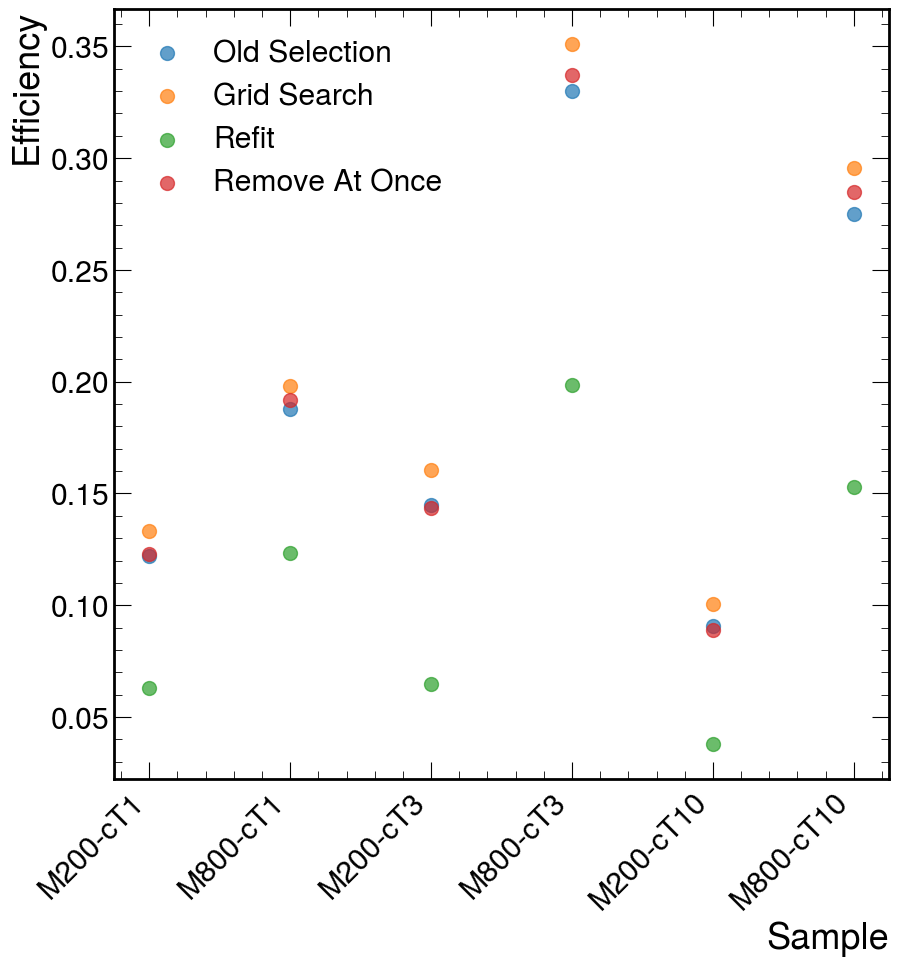

In [75]:
import matplotlib.pyplot as plt

def create_scatter_plot(x_labels, y_values, title="Scatter Plot", x_label="Categories", y_label="Values", legend="nominal"):
    """
    Creates a scatter plot with string labels on the x-axis and float values on the y-axis
    
    Args:
        x_labels (list): List of strings for x-axis labels
        y_values (list): List of floats for y values
        title (str): Title of the plot
        x_label (str): Label for x-axis
        y_label (str): Label for y-axis
    """
    # Check if input lists have the same length
    if len(x_labels) != len(y_values):
        raise ValueError("The lists of x labels and y values must have the same length")
    
    # Create x-coordinates (just numerical positions)
    x_positions = list(range(len(x_labels)))
    plt.scatter(x_positions, y_values, s=100, alpha=0.7,label=legend)
    
    # Set the x-axis ticks and labels
    plt.xticks(x_positions, x_labels, rotation=45, ha='right')
    
    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    leg = plt.legend(frameon=False)
    leg.get_frame().set_edgecolor('black')

# Example usage
if __name__ == "__main__":
    # Sample data
    categories = ["M200-cT1","M800-cT1","M200-cT3","M800-cT3","M200-cT10","M800-cT10"]
    nominal_values = [0.13335353535351235,0.19808999999995566,0.160289999999968,0.3509793814432051,0.10056112224447658,0.2957499999999237]
    refit_values = [0.06300000000000006,0.12345999999998009,0.06482999999999928,0.19836082474222416,0.03780561122244749,0.1527999999999705]
    refit0p005_values=[0.1057575757575618,0.1673699999999657,0.11873999999998162,0.28708247422673117,0.07174348697394493,0.23581999999994332]
    refitRemoveAtOnce_values = [0.12296969696967737,0.19168367346934592,0.14347999999997352,0.33722680412362194,0.08890781563125394,0.2847799999999273]
    refitRemoveAtOnce0p005_values = [0.10808080808079336,0.17147999999996436,0.12145999999998072,0.2955567010308521,0.07345691382765179,0.2457099999999401]
    preSearch_values = [0.122,0.188,0.145,0.330,0.0909,0.275]
    # Create the scatter plot
    #plt.figure(figsize=(10, 6))
    plt.figure()
    create_scatter_plot(categories, preSearch_values, "", "Sample", "Efficiency",legend="Old Selection")
    create_scatter_plot(categories, nominal_values, "", "Sample", "Efficiency",legend="Grid Search")
    create_scatter_plot(categories, refit_values, "", "Sample", "Efficiency",legend="Refit")
    #create_scatter_plot(categories, refit0p005_values, "", "Sample", "Efficiency",legend="3D Shift 0.005")
    create_scatter_plot(categories, refitRemoveAtOnce_values, "", "Sample", "Efficiency",legend="Remove At Once")
    #create_scatter_plot(categories, refitRemoveAtOnce0p005_values, "", "Sample", "Efficiency",legend="Remove At Once 3D Shift 0.005")
    #plt.ylim(0.1,0.5)
    plt.show()

In [11]:
#Cutflow for background estimation
bin_namesCustom = ["A","B","C","D"]

def process_cutflows(args):
    """ Process a single ROOT file in chunks using uproot.iterate() """
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV", "scoutVert_nTracks","weight","scoutVert_chi2"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            weights = ak.ones_like(batch["weight"])  # event weights
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>3)
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            mask = ak.num(dBV,axis=1)>0
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            
            ntrackMask = (ntracks>7)
            chi2Mask = (chi2<3.0)
            #Signal region B
            mask = ntrackMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsB = weights[mask]
            weightSum[1] += ak.sum(weightsB)
            weightSumSquared[1] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region D
            mask = ntrackMask & ~chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[3] += ak.sum(weightsD)
            weightSumSquared[3] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region C
            mask = ~ntrackMask & ~chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[2] += ak.sum(weightsC)
            weightSumSquared[2] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region A
            mask = ~ntrackMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[0] += ak.sum(weightsA)
            weightSumSquared[0] += ak.sum(weightsA**2)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    """ Process all ROOT files in parallel and aggregate results """
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)
genWeightSumDict = {}
for process, rootFiles in dict.items():
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        n_binsSkim = h_genWeights.GetNbinsX() 
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeightSum += genWeights[0]
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] #/ genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] #/ (genWeightSumDict[process]**2)
customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]

for process in list(signalDict.keys())+["TTbar","QCD"]:
    #Custom Cutflows
    print(process)
    for i in range(len(bin_namesCustom)):
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        print(bin_namesCustom[i],":",f"{efficiency:.3g} +- {stat_unc:.1g}")
sumA = customWeights["2024H"]["A"] 
sumA_unc = np.sqrt(customWeights["2024H_squared"]["A"])
sumB = customWeights["2024H"]["B"]
sumB_unc = np.sqrt(customWeights["2024H_squared"]["B"])
sumC = customWeights["2024H"]["C"]
sumC_unc = np.sqrt(customWeights["2024H_squared"]["C"])
sumD = customWeights["2024H"]["D"]
sumD_unc = np.sqrt(customWeights["2024H_squared"]["D"])
bg_exp = sumA*sumD/sumC
if(sumD!=0):
    bg_exp_unc = bg_exp * np.sqrt((sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (sumC_unc/sumC)**2)
else:
    bg_exp_unc = (sumA/sumC) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
print("expected background:",f"{bg_exp:.3g} +- {bg_exp_unc:.1g} observed: {sumB:.3g} +- {sumB_unc:.1g}")

Processing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1500to2000_30Mevts_v9/250714_175221/QCD-4Jets_Bin-HT-1500to2000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1200to1500_30Mevts_v9/250714_175214/QCD-4Jets_Bin-HT-1200to1500.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v9/250714_175143/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_2000_30Mevts_v9/250714_175228/QCD-4Jets_Bin-HT-2000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/

Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124042/QCD-4Jets_Bin-HT-600to800.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123909/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_123852/TTtoLNu2Q.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v14-15TrackFPR-RemoveAtOnce-MoreStats-dBVMin0p01/250630_124057/QCD-4Jets_Bin-HT-800to1000.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-

/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-awkward/2.1.1-edf8d8121f794c78bb662dab159497fd/lib/python3.9/site-packages/awkward/_backends.py:58: RuntimeWarning: invalid value encountered in divide
  return getattr(ufunc, method)(*args, **kwargs)
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-awkward/2.1.1-edf8d8121f794c78bb662dab159497fd/lib/python3.9/site-packages/awkward/_backends.py:58: RuntimeWarning: divide by zero encountered in divide
  return getattr(ufunc, method)(*args, **kwargs)


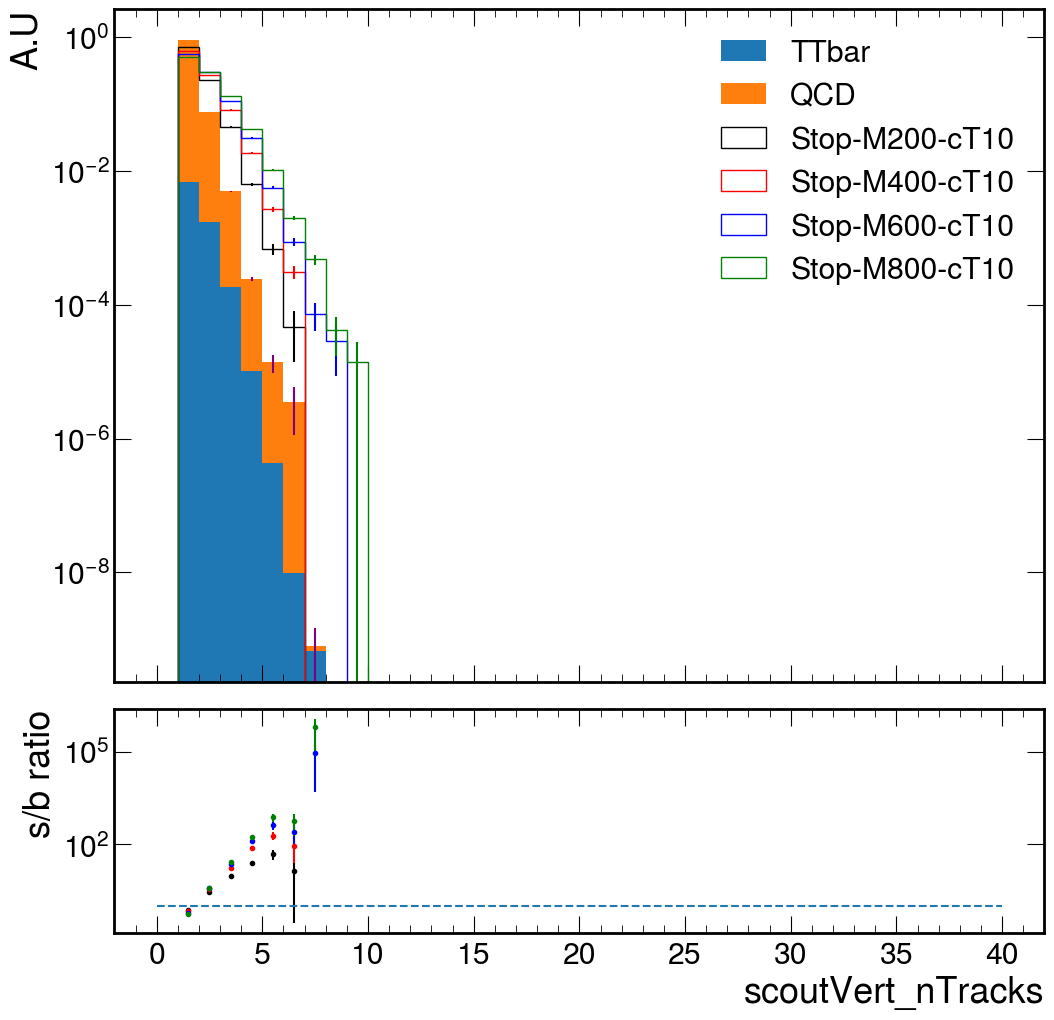

Total runtime: 1026.59 seconds


In [33]:
#Multiple Vertex Plotting Script

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "scoutVert_nTracks": [0,40,41]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["weight","scoutVert_dBV"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=10000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]

                # Apply displacement cut
                if "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_nTracks"] > 1)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                data = ak.num(data,axis=1)
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
for plot in plotDict.keys():
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"Stop-M200-cT10": "black", "Stop-M400-cT10": "red", "Stop-M600-cT10": "blue", "Stop-M800-cT10": "green"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [46]:
#Two Vertex Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

errCutValues = np.concatenate(([999.9],np.linspace(0.005,0.02,4)[::-1]))
nTrackCutValues = np.linspace(1,7,7)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros((len(errCutValues),len(nTrackCutValues),len(errCutValues),len(nTrackCutValues)))
        weightSumSquared = np.zeros((len(errCutValues),len(nTrackCutValues),len(errCutValues),len(nTrackCutValues)))
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            mask = (dBV>0.01)
            dBVErr = dBVErr[mask]
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            
            errMasks = [(dBVErr < errCutValues[i]) for i in range(len(errCutValues))]
            ntracksMasks = [(ntracks > nTrackCutValues[j]) for j in range(len(nTrackCutValues))]
            for i in range(len(errCutValues)):
                for j in range(len(nTrackCutValues)):
                    mask1 = errMasks[i] & ntracksMasks[j]
                    num1 = ak.num(dBV[mask1],axis=1)
                    for k in range(len(errCutValues)):
                        for l in range(len(nTrackCutValues)):
                            mask2 = errMasks[k] & ntracksMasks[l]
                            maskBoth = mask1 & mask2
                            num2 = ak.num(dBV[mask2],axis=1)
                            numBoth = ak.num(dBV[maskBoth],axis=1)
                            mask = (num1>0) & (num2>0) & ( (numBoth>1) | (numBoth==0) | ((numBoth==1)&((num1>1)|(num2>1))) )
                            weightsMasked = weights[mask]
                            weightSum[i][j][k][l] += ak.sum(weightsMasked)
                            weightSumSquared[i][j][k][l] += ak.sum(weightsMasked**2)
                    
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0], "Stop-M800-cT1": [0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0], "Stop-M800-cT1": [0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]],errCutValues[ind[2]],nTrackCutValues[ind[3]]]
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal)
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]],errCutValues[ind[2]],nTrackCutValues[ind[3]]]
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color)
        sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
    #ax.set_ylabel("Sensitivity")
    #plt.xlabel("Number of Tracks Cut")
    plt.legend()
    #ax.set_xscale("log")
    plt.xscale("symlog",linthresh=10**-11)
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring one vertex >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty and another vertex >",cuts[4],"tracks and <",f"{cuts[3]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring one vertex >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty and another vertex >",cuts[4],"tracks and <",f"{cuts[3]:3f}","uncertainty")

[9.999e+02 2.000e-02 1.500e-02 1.000e-02 5.000e-03]
Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v15-MoreStats/250703_093623/QCD-4Jets_Bin-HT-1000to1200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v15-MoreStats/250703_093747/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v15-MoreStats/250703_093717/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v15-MoreStats/250703_093551/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v15-MoreStats/250703_093704/QCD-4Je

Process ForkProcess-220:
Process ForkProcess-219:
Process ForkProcess-223:
Process ForkProcess-224:
Process ForkProcess-217:
Process ForkProcess-221:
Process ForkProcess-222:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/python3/3.9.14-8e02587b42992e07ed46b00eca9dfc3a/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/python3/3.9.14-8e02587b42992e07ed46b00eca9dfc3a/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/python3/3.9.14-8e02587b42992e07ed46b00eca9dfc3a/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/python3/3.9.14-8e02587b42992e07ed46b00eca9dfc3a/lib/

KeyboardInterrupt: 

In [11]:
#N track fit for background estimation

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "scoutVert_nTracks": [0,50,51]

}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_cosT","scoutVert_chi2","runNumber","jet_pt"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=10000):  
            #weights = batch["weight"]  # normalize event weights
            weights = ak.ones_like(batch["weight"])
            runNumber = batch["runNumber"]
            #mask = (runNumber!=384323) & (runNumber!=384322)
            #weights=weights[mask]
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                # Apply displacement cut
                if "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2) & (batch["scoutVert_cosT"]>0) & (batch["scoutVert_dBVErr"]<0.005) & (batch["scoutVert_chi2"]<3)#& (batch["scoutVert_nTracks"]<8) 
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #mask = (runNumber!=384323) & (runNumber!=384322)
                #data = data[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]
    sigPlotWeights[f"{plot}_squared"]["2024"] = sigPlotWeights[f"{plot}_squared"]["2024C"]+sigPlotWeights[f"{plot}_squared"]["2024D"]+sigPlotWeights[f"{plot}_squared"]["2024E"]+sigPlotWeights[f"{plot}_squared"]["2024F"]+sigPlotWeights[f"{plot}_squared"]["2024G"]+sigPlotWeights[f"{plot}_squared"]["2024H"]+sigPlotWeights[f"{plot}_squared"]["2024I"]

# **Plotting**
for plot, binning in plotDict.items():
    bins = np.linspace(binning[0], binning[1], binning[2])
    
    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    colors = {"2024": "black"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        #integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        integral = 1
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=False, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)

    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.close()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-4DxyMin/260409_153724/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-4DxyMin/260409_153818/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-4DxyMin/260409_153846/Run2024G.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-4DxyMin/260409_153833/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-4DxyMin/260409_153742/Run2024D.root



Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-4DxyMin/260409_153919/Run2024I.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-4DxyMin/260409_153901/Run2024H.root

Total runtime: 307.14 seconds


In [35]:
print(bins[:-1])
print(list(sigValues[:]))
print(sigErrors[:])

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
[0.0, 0.0, 0.0, 1778045.0, 711730.0, 224824.0, 65017.0, 18154.0, 5142.0, 1338.0, 378.0, 125.0, 36.0, 17.0, 9.0]
[0, 0, 0, 1.33e+03, 844, 474, 255, 135, 71.7, 36.6, 19.4, 11.2, 6, 4.12, 3]


Fit Results:
a = 6705.15845060 ± 58.49143310
b = 1.71136681 ± 0.00937522

R-squared: 1.0000
Reduced chi-squared: 0.8761


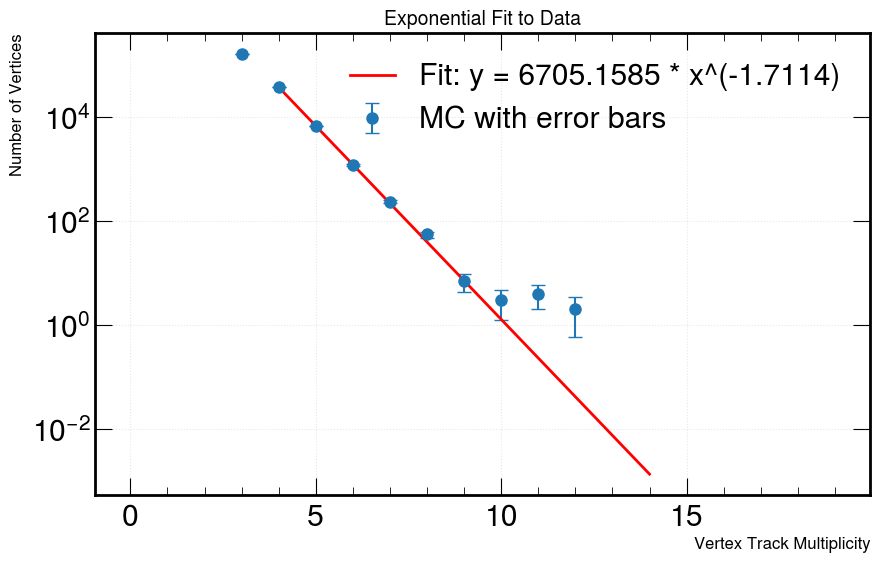

7 track fit value: 218.7 actual: 234.0 +- 15.3 residual -1.0


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define exponential function
def exponential(x, a, b):
    """Exponential function: y = a * exp(b * x)"""
    return a * np.exp(-b * (x-5))

#def exponential(x,a,b):
#    return a * x**(-b)

#def exponential(x, a, b, c):
#    return a * np.exp(-1*pow(b * (x-2),c))

#def exponential(x,a,b,c,d):
#    return a * np.exp(-b * (x-3)) +  c * np.exp(-d * (x-5))

def complete_exponential_fit_example(x, y, yerr):
    """Complete example: create data, plot with errorbars, and fit exponential"""
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    # Plot data with error bars
    ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, 
                label='MC with error bars', markersize=8)
    i_fit = np.array([4,5,6,7])
    x = x[i_fit]
    y = y[i_fit]
    yerr = yerr[i_fit]
    # Fit exponential function using weighted least squares
    # The sigma parameter uses the error bars as weights
    popt, pcov = curve_fit(exponential, x, y, 
                          sigma=yerr, absolute_sigma=True,
                          p0=[1,1],maxfev=500000)  # Initial guess for [a, b]
    
    # Extract fitted parameters and their uncertainties
    a_fit, b_fit = popt
    a_err, b_err = np.sqrt(np.diag(pcov))
    
    # Generate smooth curve for plotting
    #x_fit = np.linspace(x.min(), x.max(), 200)
    x_fit = np.linspace(x.min(), 14, 200)
    y_fit = exponential(x_fit, *popt)
    
    # Plot the fitted curve
    ax.plot(x_fit, y_fit, 'r-', linewidth=2,
            label=f'Fit: y = {a_fit:.4f} * x^(-{b_fit:.4f})')
    
    # Formatting
    ax.set_xlabel('Vertex Track Multiplicity', fontsize=12)
    ax.set_ylabel('Number of Vertices', fontsize=12)
    ax.set_title('Exponential Fit to Data', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Print fit results
    print("Fit Results:")
    print(f"a = {a_fit:.8f} ± {a_err:.8f}")
    print(f"b = {b_fit:.8f} ± {b_err:.8f}")
    #print(f"c = {c_fit:.4f} ± {c_err:.4f}")
    #print(f"d = {d_fit:.4f} ± {d_err:.4f}")
    
    # Calculate R-squared
    residuals = y - exponential(x, *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"\nR-squared: {r_squared:.4f}")
    
    # Chi-squared (goodness of fit)
    chi_squared = np.sum((residuals / yerr)**2)
    dof = len(x) - len(popt)  # degrees of freedom
    chi_squared_reduced = chi_squared / dof
    print(f"Reduced chi-squared: {chi_squared_reduced:.4f}")
    
    #plt.tight_layout()
    ax.set_yscale("log")
    plt.show()
    
    return popt, pcov

popt, pcov = complete_exponential_fit_example(bins[:-1], sigValues, sigErrors)
#fit_value = exponential(8, *popt)
#fit_value = [exponential(i, *popt) for i in range(8,15)]
fit_value = [exponential(i, *popt) for i in range(7,8)]
#for i in range(8,15):
for i in range(7,8):
    #residual = (fit_value[i-8] - sigValues[i])/sigErrors[i]
    residual = (fit_value[0] - sigValues[7])/sigErrors[7]
    #print(f"{i} track fit value:",round(fit_value[i-8],1),"actual:",round(sigValues[i],1),"+-",round(sigErrors[i],1),"residual",round(residual,2))
    print(f"{i} track fit value:",round(fit_value[0],1),"actual:",round(sigValues[7],1),"+-",round(sigErrors[7],1),"residual",round(residual,2))

Fit Results  (y = a * x^{-b})
  a   = 2794258425072.887695 +/- 658789937268.848877
  b   = 12.099117 +/- 0.144317
  rho = 0.9992
  chi2/ndf = 1.86 / 1  =  1.862


Integral x >= 8:
  Predicted : 44.3794 +/- 3.1442



/tmp/rmccarth/ipykernel_389789/3985366146.py:8: RuntimeWarning: divide by zero encountered in power
  return a * np.power(x, -b)


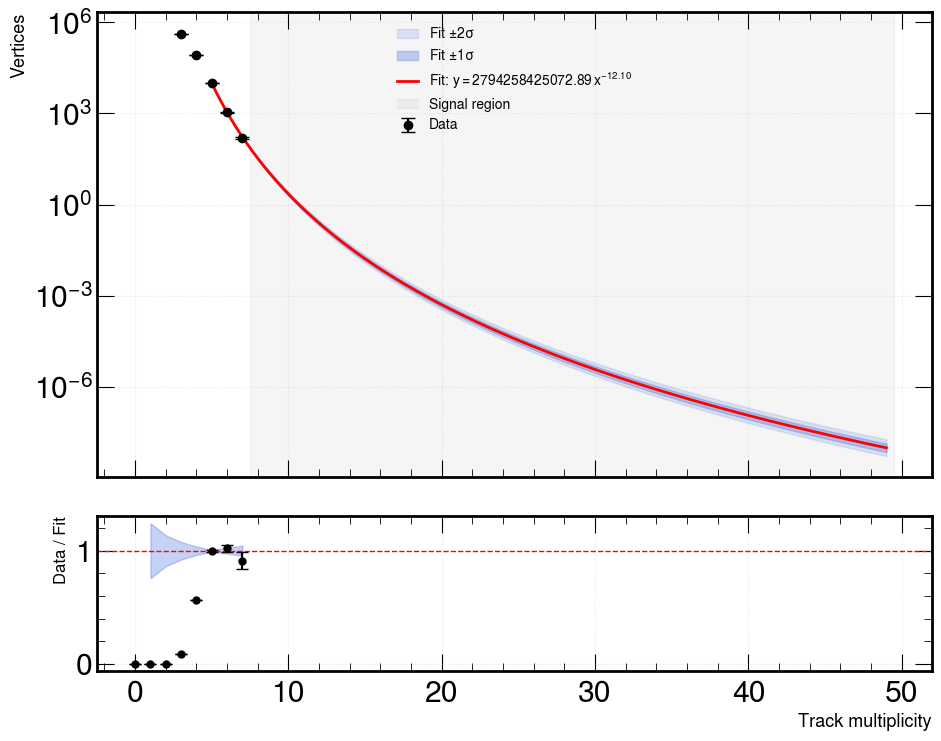

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Power law model ---
def power_law(x, a, b):
    """Power law: y = a * x^(-b)"""
    return a * np.power(x, -b)

def fit_and_extrapolate(bins, bgValues, bgErrors, fit_indices, blind_max=7, extrap_min=8, n_toys=10000):
    """
    Fit a power law to selected bins, extrapolate to high track multiplicity,
    and compare predicted vs observed yield above a blinding threshold.

    Parameters
    ----------
    bins        : array of bin edges (length = n_bins + 1)
    bgValues    : array of bin contents (length = n_bins)
    bgErrors    : array of bin uncertainties (length = n_bins)
    fit_indices : array of bin indices used in the fit
    blind_max   : show data only for x <= blind_max
    extrap_min  : extrapolation / signal region starts at this x value
    n_toys      : number of MC toys for uncertainty propagation
    """

    # Bin centers (left edges for integer track multiplicity)
    x_all = bins[:-1]

    # Select fit range
    x_fit  = x_all[fit_indices]
    y_fit  = sigValues[fit_indices]
    ye_fit = sigErrors[fit_indices]

    # ---- Fit in log-log space (power law -> linear) ----
    # log(y) = log(a) - b*log(x),  so fit params are (log_a, b)
    log_x  = np.log(x_fit)
    log_y  = np.log(y_fit)
    log_ye = ye_fit / y_fit  # error propagation: d(log y) = dy/y

    def linear(log_x, log_a, b):
        return log_a - b * log_x

    popt_log, pcov_log = curve_fit(
        linear, log_x, log_y,
        sigma=log_ye, absolute_sigma=True,
        p0=[10, 3], maxfev=500000
    )
    log_a_fit, b_fit = popt_log
    a_fit = np.exp(log_a_fit)
    popt = np.array([a_fit, b_fit])

    log_a_err, b_err = np.sqrt(np.diag(pcov_log))
    a_err = a_fit * log_a_err  # propagate back to linear space
    # Keep pcov_log for toy sampling (in log space)
    rho = pcov_log[0, 1] / (log_a_err * b_err)  # correlation coefficient

    # ---- Goodness of fit (in log space) ----
    residuals_log = log_y - linear(log_x, *popt_log)
    chi2 = np.sum((residuals_log / log_ye) ** 2)
    ndf = len(x_fit) - len(popt_log)
    print("=" * 55)
    print("Fit Results  (y = a * x^{-b})")
    print("=" * 55)
    print(f"  a   = {a_fit:.6f} +/- {a_err:.6f}")
    print(f"  b   = {b_fit:.6f} +/- {b_err:.6f}")
    print(f"  rho = {rho:.4f}")
    print(f"  chi2/ndf = {chi2:.2f} / {ndf}  =  {chi2/ndf:.3f}")
    print()

    # ---- MC toy sampling in log space for well-behaved uncertainties ----
    rng = np.random.default_rng(42)
    par_samples_log = rng.multivariate_normal(popt_log, pcov_log, size=n_toys)
    # Convert (log_a, b) -> (a, b) for each toy
    par_samples = np.column_stack([np.exp(par_samples_log[:, 0]), par_samples_log[:, 1]])

    # Smooth curve from fit range onward (not back to x~0 where power law diverges)
    x_curve = np.linspace(x_fit.min(), x_all.max(), 500)
    y_curves = np.array([power_law(x_curve, *p) for p in par_samples])
    y_central = power_law(x_curve, *popt)
    y_lo = np.percentile(y_curves, 16, axis=0)   # -1 sigma
    y_hi = np.percentile(y_curves, 84, axis=0)    #  1 sigma
    y_lo2 = np.percentile(y_curves, 2.5, axis=0)  # -2 sigma
    y_hi2 = np.percentile(y_curves, 97.5, axis=0) #  2 sigma

    # ---- Predicted yield for x >= extrap_min ----
    extrap_mask = x_all >= extrap_min
    x_extrap = x_all[extrap_mask]

    # Sum of predicted bin contents from each toy
    pred_per_toy = np.array([
        np.sum(power_law(x_extrap, *p)) for p in par_samples
    ])
    pred_central = np.sum(power_law(x_extrap, *popt))
    pred_unc = np.std(pred_per_toy)

    # ---- Observed yield (blinded comparison) ----
    obs_yield = np.sum(sigValues[extrap_mask])
    obs_err   = np.sqrt(np.sum(sigErrors[extrap_mask] ** 2))

    total_unc = np.sqrt(pred_unc**2 + obs_err**2)
    tension = (pred_central - obs_yield) / total_unc

    print()
    print(f"Integral x >= {extrap_min}:")
    print(f"  Predicted : {pred_central:.4f} +/- {pred_unc:.4f}")
    #print(f"  Observed  : {obs_yield:.4f} +/- {obs_err:.4f}")
    #print(f"  Difference: {pred_central - obs_yield:.4f} +/- {total_unc:.4f}")
    #print(f"  Tension   : {tension:+.2f} sigma")
    print()

    # ==== PLOTTING ====
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
    )

    # --- Main panel ---
    # Uncertainty bands (full range)
    ax_main.fill_between(x_curve, y_lo2, y_hi2, color="royalblue", alpha=0.15, label=r"Fit $\pm 2\sigma$")
    ax_main.fill_between(x_curve, y_lo, y_hi, color="royalblue", alpha=0.30, label=r"Fit $\pm 1\sigma$")
    ax_main.plot(x_curve, y_central, "r-", lw=2, label=f"Fit: $y = {a_fit:.2f}\\, x^{{-{b_fit:.2f}}}$")

    # Data — only show x <= blind_max
    vis = x_all <= blind_max
    ax_main.errorbar(
        x_all[vis], bgValues[vis], yerr=bgErrors[vis],
        fmt="ko", capsize=5, ms=6, label=f"Data"
    )

    # Mark the blinded region
    ax_main.axvspan(extrap_min - 0.5, x_all.max() + 0.5, color="grey", alpha=0.08, label="Signal region")

    ax_main.set_yscale("log")
    ax_main.set_ylabel("Vertices", fontsize=13)
    #ax_main.set_title("Power-law fit — blinded extrapolation", fontsize=14)
    ax_main.legend(fontsize=10)
    ax_main.grid(True, alpha=0.3)

    # --- Ratio / pull panel ---
    # Only for visible (unblinded) bins
    pred_vis = power_law(x_all[vis], *popt)
    pred_vis_toys = np.array([power_law(x_all[vis], *p) for p in par_samples])
    pred_vis_unc = np.std(pred_vis_toys, axis=0)
    ratio = bgValues[vis] / pred_vis
    ratio_err = bgErrors[vis] / pred_vis

    ax_ratio.errorbar(x_all[vis], ratio, yerr=ratio_err, fmt="ko", capsize=4, ms=5)
    # Band from fit uncertainty
    band_lo = 1 - pred_vis_unc / pred_vis
    band_hi = 1 + pred_vis_unc / pred_vis
    ax_ratio.fill_between(x_all[vis], band_lo, band_hi, color="royalblue", alpha=0.3)
    ax_ratio.axhline(1, color="r", ls="--", lw=1)
    ax_ratio.set_ylabel("Data / Fit", fontsize=12)
    ax_ratio.set_xlabel("Track multiplicity", fontsize=13)
    ax_ratio.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig("PowerLawBGFitRegionCData.pdf")
    plt.show()

    return popt, pcov_log


# ---- Run ----
# Adjust fit_indices to whichever bins you want in the fit
fit_indices = np.array([5, 6, 7])   # e.g. ntrk = 5, 6, 7, 8 depending on binning

popt, pcov = fit_and_extrapolate(
    bins, sigValues, sigErrors,
    fit_indices=fit_indices,
    blind_max=7,
    extrap_min=8,
    n_toys=10000
)

Fit Results  (y = a * exp(-b * x))
  a   = 439863421.680263 +/- 57837769.909569
  b   = 2.143875 +/- 0.025576
  rho = 0.9974
  chi2/ndf = 3.97 / 1  =  3.969


Integral x >= 8:
  Predicted : 17.7366 +/- 1.3681



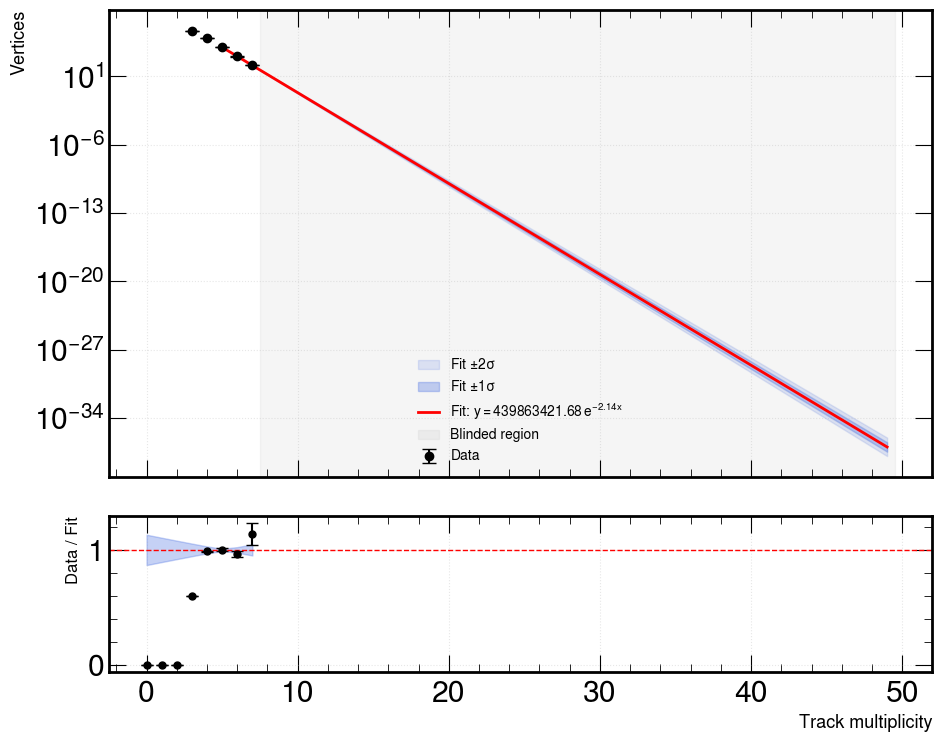

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Exponential model ---
def exponential(x, a, b):
    """Exponential: y = a * exp(-b * x)"""
    return a * np.exp(-b * x)

def fit_and_extrapolate(bins, bgValues, bgErrors, fit_indices, blind_max=7, extrap_min=8, n_toys=10000):
    """
    Fit an exponential to selected bins, extrapolate to high track multiplicity,
    and compare predicted vs observed yield above a blinding threshold.

    Parameters
    ----------
    bins        : array of bin edges (length = n_bins + 1)
    bgValues    : array of bin contents (length = n_bins)
    bgErrors    : array of bin uncertainties (length = n_bins)
    fit_indices : array of bin indices used in the fit
    blind_max   : show data only for x <= blind_max
    extrap_min  : extrapolation / signal region starts at this x value
    n_toys      : number of MC toys for uncertainty propagation
    """

    # Bin centers (left edges for integer track multiplicity)
    x_all = bins[:-1]

    # Select fit range
    x_fit  = x_all[fit_indices]
    y_fit  = bgValues[fit_indices]
    ye_fit = bgErrors[fit_indices]

    # ---- Fit in log-linear space (exponential -> linear) ----
    # log(y) = log(a) - b*x,  so fit params are (log_a, b)
    log_y  = np.log(y_fit)
    log_ye = ye_fit / y_fit  # error propagation: d(log y) = dy/y

    def linear(x, log_a, b):
        return log_a - b * x

    popt_log, pcov_log = curve_fit(
        linear, x_fit, log_y,
        sigma=log_ye, absolute_sigma=True,
        p0=[10, 0.5], maxfev=500000
    )
    log_a_fit, b_fit = popt_log
    a_fit = np.exp(log_a_fit)
    popt = np.array([a_fit, b_fit])

    log_a_err, b_err = np.sqrt(np.diag(pcov_log))
    a_err = a_fit * log_a_err  # propagate back to linear space
    rho = pcov_log[0, 1] / (log_a_err * b_err)  # correlation coefficient

    # ---- Goodness of fit (in log space) ----
    residuals_log = log_y - linear(x_fit, *popt_log)
    chi2 = np.sum((residuals_log / log_ye) ** 2)
    ndf = len(x_fit) - len(popt_log)
    print("=" * 55)
    print("Fit Results  (y = a * exp(-b * x))")
    print("=" * 55)
    print(f"  a   = {a_fit:.6f} +/- {a_err:.6f}")
    print(f"  b   = {b_fit:.6f} +/- {b_err:.6f}")
    print(f"  rho = {rho:.4f}")
    print(f"  chi2/ndf = {chi2:.2f} / {ndf}  =  {chi2/ndf:.3f}")
    print()

    # ---- MC toy sampling in log space for well-behaved uncertainties ----
    rng = np.random.default_rng(42)
    par_samples_log = rng.multivariate_normal(popt_log, pcov_log, size=n_toys)
    # Convert (log_a, b) -> (a, b) for each toy
    par_samples = np.column_stack([np.exp(par_samples_log[:, 0]), par_samples_log[:, 1]])

    # Smooth curve from fit range onward
    x_curve = np.linspace(x_fit.min(), x_all.max(), 500)
    y_curves = np.array([exponential(x_curve, *p) for p in par_samples])
    y_central = exponential(x_curve, *popt)
    y_lo = np.percentile(y_curves, 16, axis=0)    # -1 sigma
    y_hi = np.percentile(y_curves, 84, axis=0)    #  1 sigma
    y_lo2 = np.percentile(y_curves, 2.5, axis=0)  # -2 sigma
    y_hi2 = np.percentile(y_curves, 97.5, axis=0) #  2 sigma

    # ---- Predicted yield for x >= extrap_min ----
    extrap_mask = x_all >= extrap_min
    x_extrap = x_all[extrap_mask]

    # Sum of predicted bin contents from each toy
    pred_per_toy = np.array([
        np.sum(exponential(x_extrap, *p)) for p in par_samples
    ])
    pred_central = np.sum(exponential(x_extrap, *popt))
    pred_unc = np.std(pred_per_toy)

    # ---- Observed yield (blinded comparison) ----
    obs_yield = np.sum(bgValues[extrap_mask])
    obs_err   = np.sqrt(np.sum(bgErrors[extrap_mask] ** 2))

    total_unc = np.sqrt(pred_unc**2 + obs_err**2)
    tension = (pred_central - obs_yield) / total_unc

    print()
    print(f"Integral x >= {extrap_min}:")
    print(f"  Predicted : {pred_central:.4f} +/- {pred_unc:.4f}")
    #print(f"  Observed  : {obs_yield:.4f} +/- {obs_err:.4f}")
    #print(f"  Difference: {pred_central - obs_yield:.4f} +/- {total_unc:.4f}")
    #print(f"  Tension   : {tension:+.2f} sigma")
    print()

    # ==== PLOTTING ====
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
    )

    # --- Main panel ---
    ax_main.fill_between(x_curve, y_lo2, y_hi2, color="royalblue", alpha=0.15, label=r"Fit $\pm 2\sigma$")
    ax_main.fill_between(x_curve, y_lo, y_hi, color="royalblue", alpha=0.30, label=r"Fit $\pm 1\sigma$")
    ax_main.plot(x_curve, y_central, "r-", lw=2, label=f"Fit: $y = {a_fit:.2f}\\, e^{{-{b_fit:.2f}x}}$")

    # Data — only show x <= blind_max
    vis = x_all <= blind_max
    ax_main.errorbar(
        x_all[vis], bgValues[vis], yerr=bgErrors[vis],
        fmt="ko", capsize=5, ms=6, label=f"Data"
    )

    # Mark the blinded region
    ax_main.axvspan(extrap_min - 0.5, x_all.max() + 0.5, color="grey", alpha=0.08, label="Blinded region")

    ax_main.set_yscale("log")
    ax_main.set_ylabel("Vertices", fontsize=13)
    #ax_main.set_title("Exponential fit — blinded extrapolation", fontsize=14)
    ax_main.legend(fontsize=10)
    ax_main.grid(True, alpha=0.3)

    # --- Ratio / pull panel ---
    pred_vis = exponential(x_all[vis], *popt)
    pred_vis_toys = np.array([exponential(x_all[vis], *p) for p in par_samples])
    pred_vis_unc = np.std(pred_vis_toys, axis=0)
    ratio = bgValues[vis] / pred_vis
    ratio_err = bgErrors[vis] / pred_vis

    ax_ratio.errorbar(x_all[vis], ratio, yerr=ratio_err, fmt="ko", capsize=4, ms=5)
    band_lo = 1 - pred_vis_unc / pred_vis
    band_hi = 1 + pred_vis_unc / pred_vis
    ax_ratio.fill_between(x_all[vis], band_lo, band_hi, color="royalblue", alpha=0.3)
    ax_ratio.axhline(1, color="r", ls="--", lw=1)
    ax_ratio.set_ylabel("Data / Fit", fontsize=12)
    ax_ratio.set_xlabel("Track multiplicity", fontsize=13)
    ax_ratio.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig("ExponentialBGFigBlindedData.pdf")
    plt.show()

    return popt, pcov_log


# ---- Run ----
fit_indices = np.array([5, 6, 7])

popt, pcov = fit_and_extrapolate(
    bins, sigValues, sigErrors,
    fit_indices=fit_indices,
    blind_max=7,
    extrap_min=8,
    n_toys=10000
)


/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-awkward/2.1.1-edf8d8121f794c78bb662dab159497fd/lib/python3.9/site-packages/awkward/_backends.py:58: RuntimeWarning: divide by zero encountered in divide
  return getattr(ufunc, method)(*args, **kwargs)


Linear interpolation in log(y) using x = 6.0, 7.0
Slope (d log(y) / dx) = -1.6196

  Combined estimate for x >= 8
  Observed:   71.0 ± 8.4
  Predicted:  57.8 ± 8.7
  Obs - Pred: 13.2 ± 12.1
  Obs / Pred: 1.229
  Pull:       +1.09 σ


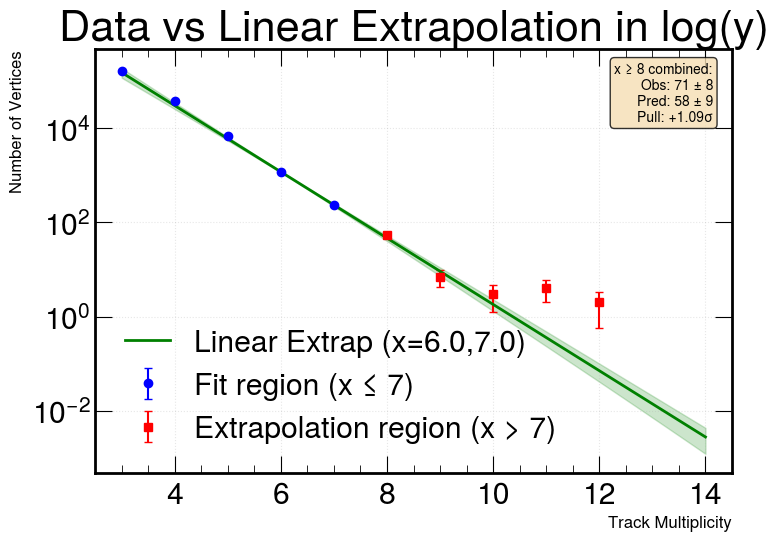

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = bins[:-1]
y = sigValues
yErr = sigErrors

# Define fit and extrapolation regions
x_fit_max = 7
fit_mask = x <= x_fit_max
#extrap_mask = x > x_fit_max
extrap_mask = x > 7

# Linear interpolation in log(y) using last two points of fit region
# Points: (x1, y1) and (x2, y2) where x2 = x_fit_max
i1, i2 = np.where(x == x_fit_max - 1)[0][0], np.where(x == x_fit_max)[0][0]
x1, x2 = x[i1], x[i2]
y1, y2 = y[i1], y[i2]
yerr1, yerr2 = yErr[i1], yErr[i2]

# Slope and intercept in log space
logy1, logy2 = np.log(y1), np.log(y2)
m = (logy2 - logy1) / (x2 - x1)  # slope
c = logy1 - m * x1               # intercept

# Prediction function
def predict(xi):
    return np.exp(m * xi + c)

# Error propagation for extrapolation
# sigma_log(y) ≈ sigma_y / y
sigma_logy1 = yerr1 / y1
sigma_logy2 = yerr2 / y2

def predict_err(xi):
    """Propagated uncertainty on prediction at xi"""
    dx = xi - x2
    # log(y_pred) = log(y2) + m * dx = log(y2) + (log(y2) - log(y1)) * dx / (x2 - x1)
    d_dlogy2 = 1 + dx / (x2 - x1)
    d_dlogy1 = -dx / (x2 - x1)
    sigma_logy_pred = np.sqrt((d_dlogy2 * sigma_logy2)**2 + (d_dlogy1 * sigma_logy1)**2)
    return predict(xi) * sigma_logy_pred

# Calculate predictions and pulls for extrapolation region
x_extrap = x[extrap_mask]
y_extrap = y[extrap_mask]
yerr_extrap = yErr[extrap_mask]

y_pred = predict(x_extrap)
y_pred_err = predict_err(x_extrap)

# Pull using observation error only
pull_obs = (y_extrap - y_pred) / yerr_extrap

# Pull using combined error (obs + extrapolation)
pull_comb = (y_extrap - y_pred) / np.sqrt(yerr_extrap**2 + y_pred_err**2)

# Combined totals for x >= 8
total_obs = np.sum(y_extrap)
total_obs_err = np.sqrt(np.sum(yerr_extrap**2))

total_pred = np.sum(y_pred)
# For prediction error: need covariance since all predictions share the same slope parameters
# Cov(y_i, y_j) comes from shared dependence on logy1 and logy2
# Build covariance matrix for predictions
n_pts = len(x_extrap)
cov_pred = np.zeros((n_pts, n_pts))
for i in range(n_pts):
    for j in range(n_pts):
        xi, xj = x_extrap[i], x_extrap[j]
        dxi, dxj = xi - x2, xj - x2
        # Partial derivatives w.r.t. log(y1) and log(y2)
        di_dlogy1 = -dxi / (x2 - x1)
        di_dlogy2 = 1 + dxi / (x2 - x1)
        dj_dlogy1 = -dxj / (x2 - x1)
        dj_dlogy2 = 1 + dxj / (x2 - x1)
        # Covariance in log space
        cov_logy = (di_dlogy1 * dj_dlogy1 * sigma_logy1**2 + 
                    di_dlogy2 * dj_dlogy2 * sigma_logy2**2)
        # Convert to linear space: Cov(y_i, y_j) ≈ y_i * y_j * Cov(log(y_i), log(y_j))
        cov_pred[i, j] = y_pred[i] * y_pred[j] * cov_logy

# Total prediction variance = sum of all covariance matrix elements
total_pred_var = np.sum(cov_pred)
total_pred_err = np.sqrt(total_pred_var)

# Combined errors and pull
total_comb_err = np.sqrt(total_obs_err**2 + total_pred_err**2)
pull_total = (total_obs - total_pred) / total_comb_err

# Print results
print(f"Linear interpolation in log(y) using x = {x1}, {x2}")
print(f"Slope (d log(y) / dx) = {m:.4f}")
print()
print(f"{'='*50}")
print(f"  Combined estimate for x >= 8")
print(f"{'='*50}")
print(f"  Observed:   {total_obs:.1f} ± {total_obs_err:.1f}")
print(f"  Predicted:  {total_pred:.1f} ± {total_pred_err:.1f}")
print(f"{'='*50}")
print(f"  Obs - Pred: {total_obs - total_pred:.1f} ± {total_comb_err:.1f}")
print(f"  Obs / Pred: {total_obs / total_pred:.3f}")
print(f"  Pull:       {pull_total:+.2f} σ")
print(f"{'='*50}")

# Plotting
fig, ax1 = plt.subplots(figsize=(8, 6))

# Data and fit
x_line = np.linspace(3, 14, 100)
y_line = predict(x_line)

ax1.errorbar(x[fit_mask], y[fit_mask], yerr=yErr[fit_mask], fmt='o', color='blue', 
             label=f'Fit region (x ≤ {x_fit_max})', capsize=3, markersize=6)
ax1.errorbar(x[extrap_mask], y[extrap_mask], yerr=yErr[extrap_mask], fmt='s', color='red', 
             label=f'Extrapolation region (x > 7)', capsize=3, markersize=6)
ax1.plot(x_line, y_line, 'g-', linewidth=2, label=f'Linear Extrap (x={x1},{x2})')

# Shade extrapolation uncertainty
y_line_err = predict_err(x_line)
ax1.fill_between(x_line, y_line - y_line_err, y_line + y_line_err, alpha=0.2, color='green')

ax1.set_yscale('log')
ax1.set_xlabel('Track Multiplicity', fontsize=12)
ax1.set_ylabel('Number of Vertices', fontsize=12)
ax1.set_title('Data vs Linear Extrapolation in log(y)')
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2.5, 14.5)

# Add text box with combined result
textstr = f'x ≥ 8 combined:\nObs: {total_obs:.0f} ± {total_obs_err:.0f}\nPred: {total_pred:.0f} ± {total_pred_err:.0f}\nPull: {pull_total:+.2f}σ'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.97, 0.97, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('linear_interp_fit.png', dpi=150)
plt.show()

[9.999e+02 2.000e-02 1.900e-02 1.800e-02 1.700e-02 1.600e-02 1.500e-02
 1.400e-02 1.300e-02 1.200e-02 1.100e-02 1.000e-02 9.000e-03 8.000e-03
 7.000e-03 6.000e-03 5.000e-03 4.000e-03 3.000e-03 2.000e-03 1.000e-03]
Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v15-MoreStats/250703_093551/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v15-MoreStats/250703_093717/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v15-MoreStats/250703_093915/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v15-MoreStats/250703_093747/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/c

/tmp/rmccarth/ipykernel_4041188/998901467.py:123: RuntimeWarning: divide by zero encountered in divide
  sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))


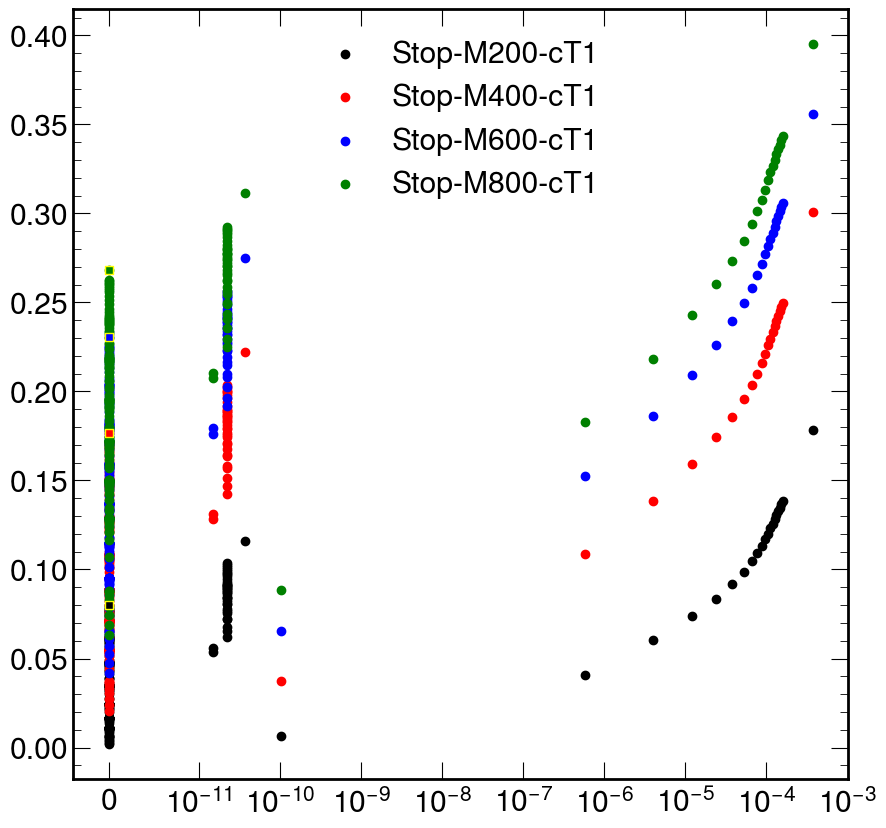

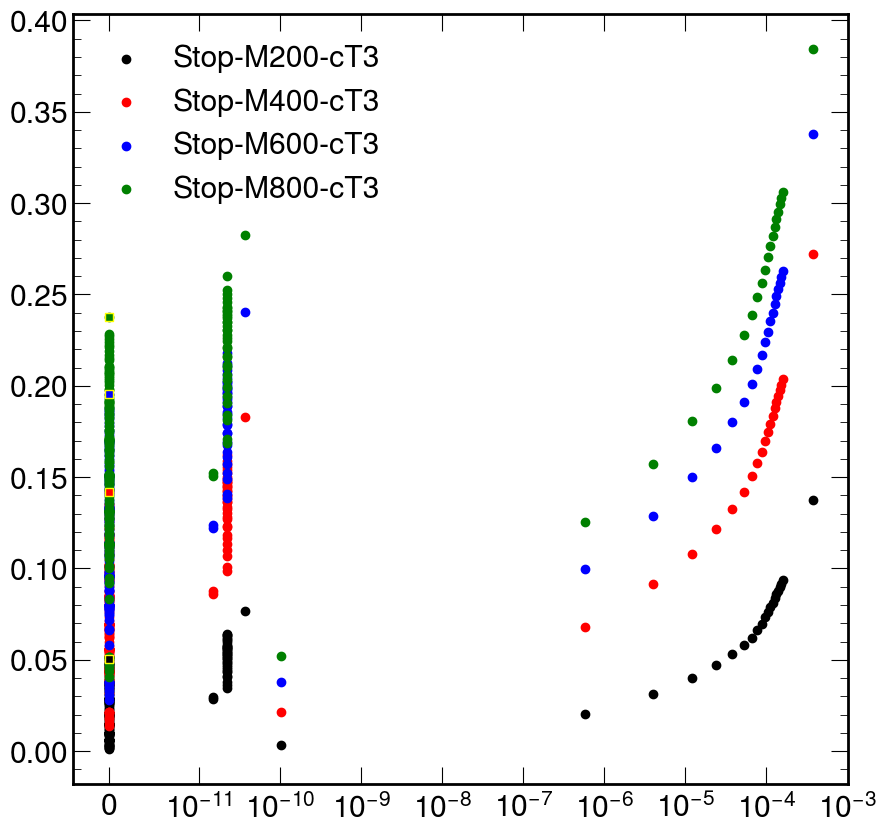

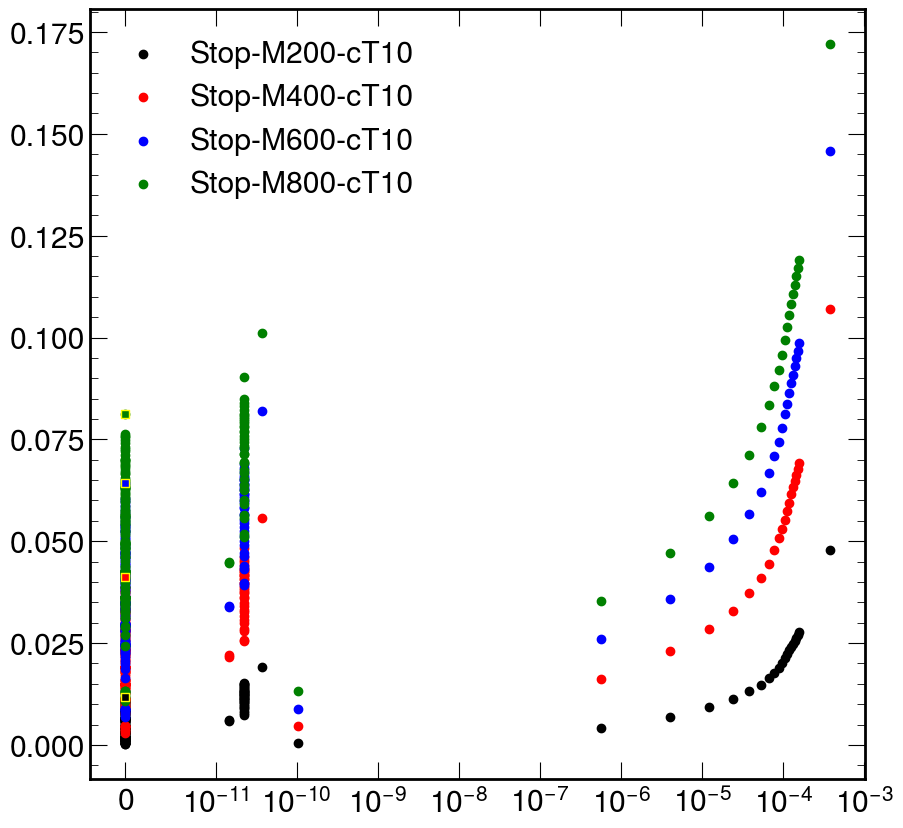

Total runtime: 683.06 seconds
best traditional sensitivity for signal Stop-M200-cT1 is 2.9535408641769134 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M400-cT1 is 4.385490804915187 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M600-cT1 is 5.01118860151897 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M800-cT1 is 5.404728152274844 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M200-cT3 is 2.3441102363157658 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M400-cT3 is 3.933542514505697 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M600-cT3 is 4.616790573547272 requiring > 4.0 tracks and < 999.900000 uncertainty
best traditional sensitivity for signal Stop-M800-cT3 is 5.087097566341537 requi

In [3]:
#Two Vertex delta R Cut Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#Cuts need to go from loosest to tightest
errCutValues = np.concatenate(([999.9],np.linspace(0.001,0.02,20)[::-1]))
nTrackCutValues = np.linspace(1,10,10)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks","scoutVert_phi"]
        weightSum = np.zeros((len(errCutValues),len(nTrackCutValues)))
        weightSumSquared = np.zeros((len(errCutValues),len(nTrackCutValues)))
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            phi = batch["scoutVert_phi"]
            for i in range(len(errCutValues)):
                mask = dBVErr < errCutValues[i]
                dBVErr = dBVErr[mask]
                dBV = dBV[mask]
                ntracks = ntracks[mask]
                phi = phi[mask]
                for j in range(len(nTrackCutValues)):
                    mask = ntracks > nTrackCutValues[j]
                    dBVMasked = dBV[mask]
                    dBVErrMasked = dBVErr[mask]
                    ntracksMasked = ntracks[mask]
                    phiMasked = phi[mask]
                    phiMasked = phiMasked[(dBVMasked>=0.01)&(dBVMasked<2.0)]
                    idx = ak.argcombinations(phiMasked, 2, fields=["i", "j"])  
                    dphi = abs(phiMasked[idx.i] - phiMasked[idx.j])
                    norm_dphi = ak.where(dphi > np.pi,2 * np.pi - dphi,dphi)
                    norm_dphi = ak.max(norm_dphi,axis=1)
                    mask = (~ak.is_none(norm_dphi))&(norm_dphi>2.5)
                    weightsMasked = weights[mask]
                    weightSum[i][j] += ak.sum(weightsMasked)
                    weightSumSquared[i][j] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal)
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color)
        sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
    #ax.set_ylabel("Sensitivity")
    #plt.xlabel("Number of Tracks Cut")
    plt.legend()
    #ax.set_xscale("log")
    plt.xscale("symlog",linthresh=10**-11)
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

In [59]:
#Extended ABCD Background Estimation
bin_namesCustom = ["A","B","C","D","E","F"]

def process_cutflows(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_chi2","scoutVert_cosT"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            weights = ak.ones_like(weights)
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>3)
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            mask = ak.num(dBV,axis=1)>0
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            
            ntrackMask = (ntracks>7)
            ntrackMinMask = (ntracks>5)
            chi2Mask = (chi2<3.0)
            #Signal region B
            mask = ntrackMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsB = weights[mask]
            weightSum[1] += ak.sum(weightsB)
            weightSumSquared[1] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region D
            mask = ntrackMask & ~chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[3] += ak.sum(weightsD)
            weightSumSquared[3] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region C
            mask = ~ntrackMask & ~chi2Mask & ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[2] += ak.sum(weightsC)
            weightSumSquared[2] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region A
            mask = ~ntrackMask & chi2Mask & ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[0] += ak.sum(weightsA)
            weightSumSquared[0] += ak.sum(weightsA**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region F
            mask = ~chi2Mask & ~ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsF = weights[mask]
            weightSum[5] += ak.sum(weightsF)
            weightSumSquared[5] += ak.sum(weightsF**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region E
            mask = chi2Mask & ~ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsE = weights[mask]
            weightSum[4] += ak.sum(weightsE)
            weightSumSquared[4] += ak.sum(weightsE**2)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)
genWeightSumDict = {}
for process, rootFiles in dict.items():
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        n_binsSkim = h_genWeights.GetNbinsX() 
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeightSum += genWeights[0]
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] #/ genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] #/ (genWeightSumDict[process]**2)

customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
customWeights["2024"] = {}
customWeights["2024_squared"] = {}
'''
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]
    customWeights["2024"][cut] = customWeights["2024C"][cut]+customWeights["2024D"][cut]+customWeights["2024E"][cut]+customWeights["2024F"][cut]+customWeights["2024G"][cut]+customWeights["2024H"][cut]+customWeights["2024I"][cut]
    customWeights["2024_squared"][cut] = customWeights["2024C_squared"][cut]+customWeights["2024D_squared"][cut]+customWeights["2024E_squared"][cut]+customWeights["2024F_squared"][cut]+customWeights["2024G_squared"][cut]+customWeights["2024H_squared"][cut]+customWeights["2024I_squared"][cut]
'''
for process in list(signalDict.keys()):#+["TTbar","QCD","2024"]:
    #Custom Cutflows
    print(process)
    for i in range(len(bin_namesCustom)):
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        print(bin_namesCustom[i],":",f"{efficiency:.3g} +- {stat_unc:.1g}")
    sumA = customWeights[process]["A"]
    sumA_unc = np.sqrt(customWeights[process+'_squared']["A"])
    sumB = customWeights[process]["B"]
    sumB_unc = np.sqrt(customWeights[process+'_squared']["B"])
    sumC = customWeights[process]["C"]
    sumC_unc = np.sqrt(customWeights[process+'_squared']["C"])
    sumD = customWeights[process]["D"]
    sumD_unc = np.sqrt(customWeights[process+'_squared']["D"])
    sumE = customWeights[process]["E"]
    sumE_unc = np.sqrt(customWeights[process+'_squared']["E"])
    sumF = customWeights[process]["F"]
    sumF_unc = np.sqrt(customWeights[process+'_squared']["F"])
    bg_exp = (sumA/sumC)**2 * (sumF*sumD/sumE)
    if(sumD!=0):
        bg_exp_unc = bg_exp * np.sqrt((2*sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (2*sumC_unc/sumC)**2 + (sumF_unc/sumF)**2 + (sumE_unc/sumE)**2)
    else:
        bg_exp_unc = (sumA/sumC)**2 * (sumF/sumE) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
    print("expected background:",f"{bg_exp:.3g} +- {bg_exp_unc:.1g} observed: {sumB:.3g} +- {sumB_unc:.1g}")

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v20/250917_155051/Run2024E.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v20/250917_154945/Run2024I.root
2024E
A : 1.36e+04 +- 1e+02
B : 1.72e+03 +- 4e+01
C : 1.15e+04 +- 1e+02
D : 1.67e+03 +- 4e+01
E : 1.2e+05 +- 3e+02
F : 6.91e+04 +- 3e+02
expected background: 1.36e+03 +- 5e+01 observed: 1.72e+03 +- 4e+01
2024I
A : 8.92e+03 +- 9e+01
B : 962 +- 3e+01
C : 1.01e+04 +- 1e+02
D : 1.54e+03 +- 4e+01
E : 8.6e+04 +- 3e+02
F : 6.55e+04 +- 3e+02
expected background: 914 +- 4e+01 observed: 962 +- 3e+01


In [18]:
with uproot.open("/eos/cms/store/group/phys_exotica/DVScouting/bruno_test/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024H_30Mevts_v9/250714_184505/ScoutingData_2024H.root") as file:
    tree = file["scoutingTree/objectTree"]
    weights = tree["weight"].array()
    print(weights)

[4.88e+252, 4.88e+252, 4.88e+252, ..., 4.88e+252, 4.88e+252, 4.88e+252]


In [7]:
#Extended ABCD Background Estimation With Validation Region
bin_namesCustom = ["A","B","C","D","E","F","A_Val","B_Val","C_Val","D_Val","E_Val","F_Val"]

def process_cutflows(args):
    """ Process a single ROOT file in chunks using uproot.iterate() """
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_chi2","scoutVert_cosT"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>2)
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            cosT = cosT[mask]
            mask = ak.num(dBV,axis=1)>0
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            cosT = cosT[mask]
            
            ntrackMask = (ntracks>7)
            ntrackMinMask = (ntracks>3)
            chi2Mask = (chi2<3.0)
            cosTMask = (cosT>0)
            #Signal region B
            mask = ntrackMask & chi2Mask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsB = weights[mask]
            weightSum[1] += ak.sum(weightsB)
            weightSumSquared[1] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region D
            mask = ntrackMask & ~chi2Mask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[3] += ak.sum(weightsD)
            weightSumSquared[3] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region C
            mask = ~ntrackMask & ~chi2Mask & ntrackMinMask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[2] += ak.sum(weightsC)
            weightSumSquared[2] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region A
            mask = ~ntrackMask & chi2Mask & ntrackMinMask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[0] += ak.sum(weightsA)
            weightSumSquared[0] += ak.sum(weightsA**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region F
            mask = ~chi2Mask & ~ntrackMinMask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsF = weights[mask]
            weightSum[5] += ak.sum(weightsF)
            weightSumSquared[5] += ak.sum(weightsF**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region E
            mask = chi2Mask & ~ntrackMinMask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsE = weights[mask]
            weightSum[4] += ak.sum(weightsE)
            weightSumSquared[4] += ak.sum(weightsE**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Signal region B
            mask = ntrackMask & chi2Mask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsB = weights[mask]
            weightSum[7] += ak.sum(weightsB)
            weightSumSquared[7] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Control region D
            mask = ntrackMask & ~chi2Mask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[9] += ak.sum(weightsD)
            weightSumSquared[9] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Control region C
            mask = ~ntrackMask & ~chi2Mask & ntrackMinMask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[8] += ak.sum(weightsC)
            weightSumSquared[8] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Control region A
            mask = ~ntrackMask & chi2Mask & ntrackMinMask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[6] += ak.sum(weightsA)
            weightSumSquared[6] += ak.sum(weightsA**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Control region F
            mask = ~chi2Mask & ~ntrackMinMask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsF = weights[mask]
            weightSum[11] += ak.sum(weightsF)
            weightSumSquared[11] += ak.sum(weightsF**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Control region E
            mask = chi2Mask & ~ntrackMinMask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsE = weights[mask]
            weightSum[10] += ak.sum(weightsE)
            weightSumSquared[10] += ak.sum(weightsE**2)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    """ Process all ROOT files in parallel and aggregate results """
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)
genWeightSumDict = {}
for process, rootFiles in dict.items():
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        n_binsSkim = h_genWeights.GetNbinsX() 
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeightSum += genWeights[0]
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] / genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] / (genWeightSumDict[process]**2)
customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]

for process in list(signalDict.keys())+["TTbar","QCD"]:
    #Custom Cutflows
    print(process)
    for i in range(len(bin_namesCustom)):
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        print(bin_namesCustom[i],":",f"{efficiency:.3g} +- {stat_unc:.1g}")
for string in ["","_Val"]:
    sumA = customWeights["TTbar"]["A"+string] + customWeights["QCD"]["A"+string]
    sumA_unc = np.sqrt(customWeights["TTbar_squared"]["A"+string] + customWeights["QCD_squared"]["A"+string])
    sumB = customWeights["TTbar"]["B"+string] + customWeights["QCD"]["B"+string]
    sumB_unc = np.sqrt(customWeights["TTbar_squared"]["B"+string] + customWeights["QCD_squared"]["B"+string])
    sumC = customWeights["TTbar"]["C"+string] + customWeights["QCD"]["C"+string]
    sumC_unc = np.sqrt(customWeights["TTbar_squared"]["C"+string] + customWeights["QCD_squared"]["C"+string])
    sumD = customWeights["TTbar"]["D"+string] + customWeights["QCD"]["D"+string]
    sumD_unc = np.sqrt(customWeights["TTbar_squared"]["D"+string] + customWeights["QCD_squared"]["D"+string])
    sumE = customWeights["TTbar"]["E"+string] + customWeights["QCD"]["E"+string]
    sumE_unc = np.sqrt(customWeights["TTbar_squared"]["E"+string] + customWeights["QCD_squared"]["E"+string])
    sumF = customWeights["TTbar"]["F"+string] + customWeights["QCD"]["F"+string]
    sumF_unc = np.sqrt(customWeights["TTbar_squared"]["F"+string] + customWeights["QCD_squared"]["F"+string])
    #bg_exp = (sumA/sumC)**2 * (sumF*sumD/sumE)
    bg_exp = sumA*sumD/sumC
    '''
    if(sumD!=0):
        bg_exp_unc = bg_exp * np.sqrt((2*sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (2*sumC_unc/sumC)**2 + (sumF_unc/sumF)**2 + (sumE_unc/sumE)**2)
    else:
        bg_exp_unc = (sumA/sumC)**2 * (sumF/sumE) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
    '''
    if(sumD!=0):
        bg_exp_unc = bg_exp * np.sqrt((sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (sumC_unc/sumC)**2)
    else:
        bg_exp_unc = (sumA/sumC) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
    print(string,"expected background:",f"{bg_exp:.3g} +- {bg_exp_unc:.1g} observed: {sumB:.3g} +- {sumB_unc:.1g}")

Processing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v15-125M/250723_150622/StopStopbarTo2Dbar2D_M-800_CTau-1mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v15-125M/250723_150407/StopStopbarTo2Dbar2D_M-200_CTau-3mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v15-125M/250723_150539/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v15-125M/250723_150354/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm

In [8]:
#Extended ABCD Background Estimation With Ntracks=7 validation Region
bin_namesCustom = ["A","B","C","D","E","F","B_Val","D_Val"]

def process_cutflows(args):
    """ Process a single ROOT file in chunks using uproot.iterate() """
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_chi2","scoutVert_cosT"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>2) #& (cosT<=0)
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            mask = ak.num(dBV,axis=1)>0
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            
            ntrackMask = (ntracks>7)
            ntrackValMask = (ntracks==6)
            ntrackMinMask = (ntracks>3)
            chi2Mask = (chi2<3.0)
            #Signal region B
            mask = ntrackMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsB = weights[mask]
            weightSum[1] += ak.sum(weightsB)
            weightSumSquared[1] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            ntrackValMask = ntrackValMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region D
            mask = ntrackMask & ~chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[3] += ak.sum(weightsD)
            weightSumSquared[3] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackValMask = ntrackValMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Signal region B
            mask = ntrackValMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsB = weights[mask]
            weightSum[6] += ak.sum(weightsB)
            weightSumSquared[6] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            ntrackValMask = ntrackValMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Validation Control region D
            mask = ntrackValMask & ~chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[7] += ak.sum(weightsD)
            weightSumSquared[7] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackValMask = ntrackValMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region C
            mask = ~ntrackMask & ~chi2Mask & ntrackMinMask & ~ntrackValMask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[2] += ak.sum(weightsC)
            weightSumSquared[2] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            ntrackValMask = ntrackValMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region A
            mask = ~ntrackMask & chi2Mask & ntrackMinMask & ~ntrackValMask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[0] += ak.sum(weightsA)
            weightSumSquared[0] += ak.sum(weightsA**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region F
            mask = ~chi2Mask & ~ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsF = weights[mask]
            weightSum[5] += ak.sum(weightsF)
            weightSumSquared[5] += ak.sum(weightsF**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region E
            mask = chi2Mask & ~ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsE = weights[mask]
            weightSum[4] += ak.sum(weightsE)
            weightSumSquared[4] += ak.sum(weightsE**2)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    """ Process all ROOT files in parallel and aggregate results """
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)
genWeightSumDict = {}
for process, rootFiles in dict.items():
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        n_binsSkim = h_genWeights.GetNbinsX() 
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeightSum += genWeights[0]
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] / genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] / (genWeightSumDict[process]**2)
customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]

for process in list(signalDict.keys())+["TTbar","QCD"]:
    #Custom Cutflows
    print(process)
    for i in range(len(bin_namesCustom)):
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        print(bin_namesCustom[i],":",f"{efficiency:.3g} +- {stat_unc:.1g}")
for string in ["","_Val"]:
    sumA = customWeights["TTbar"]["A"] + customWeights["QCD"]["A"]
    sumA_unc = np.sqrt(customWeights["TTbar_squared"]["A"] + customWeights["QCD_squared"]["A"])
    sumB = customWeights["TTbar"]["B"+string] + customWeights["QCD"]["B"+string]
    sumB_unc = np.sqrt(customWeights["TTbar_squared"]["B"+string] + customWeights["QCD_squared"]["B"+string])
    sumC = customWeights["TTbar"]["C"] + customWeights["QCD"]["C"]
    sumC_unc = np.sqrt(customWeights["TTbar_squared"]["C"] + customWeights["QCD_squared"]["C"])
    sumD = customWeights["TTbar"]["D"+string] + customWeights["QCD"]["D"+string]
    sumD_unc = np.sqrt(customWeights["TTbar_squared"]["D"+string] + customWeights["QCD_squared"]["D"+string])
    sumE = customWeights["TTbar"]["E"] + customWeights["QCD"]["E"]
    sumE_unc = np.sqrt(customWeights["TTbar_squared"]["E"] + customWeights["QCD_squared"]["E"])
    sumF = customWeights["TTbar"]["F"] + customWeights["QCD"]["F"]
    sumF_unc = np.sqrt(customWeights["TTbar_squared"]["F"] + customWeights["QCD_squared"]["F"])
    bg_exp = sumA*sumD/sumC
    if(sumD!=0):
        bg_exp_unc = bg_exp * np.sqrt((sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (sumC_unc/sumC)**2)
    else:
        bg_exp_unc = (sumA/sumC) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
    print(string,"expected background:",f"{bg_exp:.3g} +- {bg_exp_unc:.1g} observed: {sumB:.3g} +- {sumB_unc:.1g}")

Processing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v15-MoreStats/250703_093520/StopStopbarTo2Dbar2D_M-800_CTau-1mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v15-MoreStats/250703_093335/StopStopbarTo2Dbar2D_M-400_CTau-1mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v15-MoreStats/250703_093254/StopStopbarTo2Dbar2D_M-200_CTau-3mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v15-MoreStats/250703_093455/StopStopbarTo2Dbar2D_M-600_CTau-3mm.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2

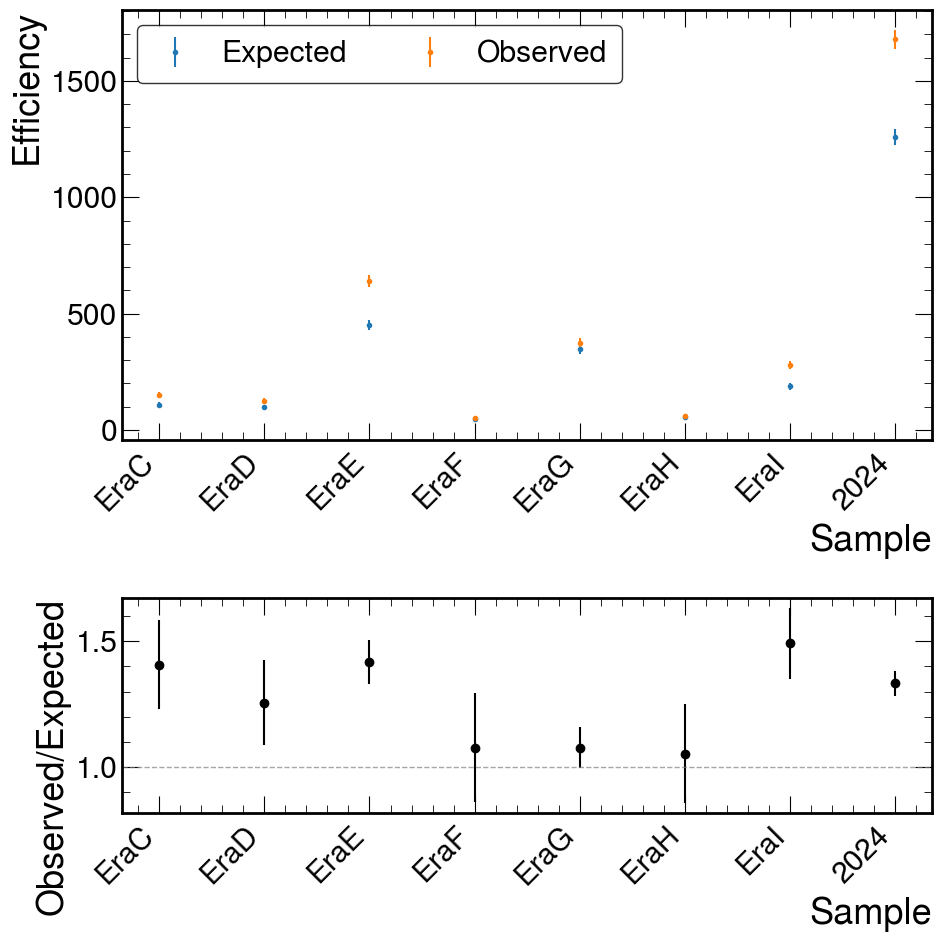

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def create_scatter_plot(ax, x_labels, y_values, title="Scatter Plot", x_label="Categories", y_label="Values", legend="nominal"):
    """
    Creates a scatter plot with string labels on the x-axis and float values on the y-axis
    
    Args:
        ax: matplotlib axes object
        x_labels (list): List of strings for x-axis labels
        y_values (list): List of floats for y values
        title (str): Title of the plot
        x_label (str): Label for x-axis
        y_label (str): Label for y-axis
    """
    # Check if input lists have the same length
    if len(x_labels) != len(y_values):
        raise ValueError("The lists of x labels and y values must have the same length")
    
    # Create x-coordinates (just numerical positions)
    x_positions = list(range(len(x_labels)))
    ax.errorbar(x_positions, y_values, yerr=np.sqrt(y_values), linestyle="none", marker=".", label=legend)
    
    # Set the x-axis ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    
    return x_positions

# Example usage
if __name__ == "__main__":
    # Sample data
    categories = ["EraC", "EraD", "EraE", "EraF", "EraG", "EraH", "EraI", "2024"]
    expected_values = np.array([108, 98.7, 451, 47.3, 347, 56, 187, 1260])
    observed_values = np.array([152, 124, 640, 51, 374, 59, 279, 1680])
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    # Top subplot: original scatter plot
    x_pos = create_scatter_plot(ax1, categories, expected_values, "", "Sample", "Events", legend="Expected")
    create_scatter_plot(ax1, categories, observed_values, "", "Sample", "Events", legend="Observed")
    
    # Add legend to top subplot
    leg = ax1.legend(frameon=True, ncol=2)
    leg.get_frame().set_edgecolor('black')
    
    # Bottom subplot: ratio plot
    # Calculate ratios
    ratios = observed_values / expected_values
    
    # Calculate uncertainty in ratio using error propagation
    # For ratio R = O/E with errors sqrt(O) and sqrt(E):
    # δR/R = sqrt((δO/O)² + (δE/E)²) = sqrt(1/O + 1/E)
    # Therefore: δR = R * sqrt(1/O + 1/E)
    ratio_errors = ratios * np.sqrt(1/observed_values + 1/expected_values)
    
    # Create ratio plot
    ax2.errorbar(x_pos, ratios, yerr=ratio_errors, linestyle="none", marker="o", color='black', markersize=6)
    
    # Add horizontal line at ratio = 1
    ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    # Set labels for ratio plot
    ax2.set_xlabel("Sample")
    ax2.set_ylabel("Observed/Expected")
    
    # Set x-axis ticks and labels
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(categories, rotation=45, ha='right')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

Pull values (number of σ from 1):
EraC: -0.45σ
EraD: +0.68σ
EraE: +2.44σ
EraF: +0.37σ
EraG: -1.81σ
EraH: -0.18σ
EraI: -0.95σ
2024: +0.16σ


/tmp/rmccarth/ipykernel_3580998/504851925.py:117: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


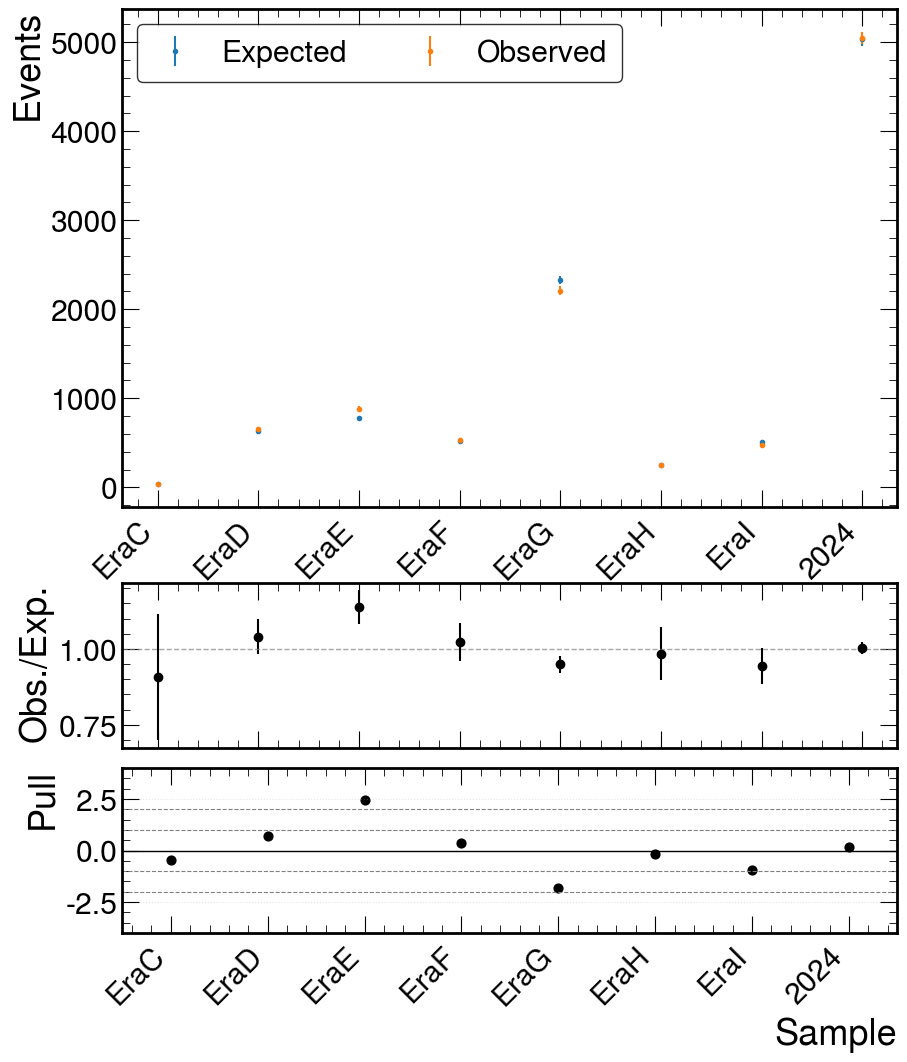

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def create_scatter_plot(ax, x_labels, y_values, title="Scatter Plot", x_label="Categories", y_label="Values", legend="nominal"):
    """
    Creates a scatter plot with string labels on the x-axis and float values on the y-axis
    
    Args:
        ax: matplotlib axes object
        x_labels (list): List of strings for x-axis labels
        y_values (list): List of floats for y values
        title (str): Title of the plot
        x_label (str): Label for x-axis
        y_label (str): Label for y-axis
    """
    # Check if input lists have the same length
    if len(x_labels) != len(y_values):
        raise ValueError("The lists of x labels and y values must have the same length")
    
    # Create x-coordinates (just numerical positions)
    x_positions = list(range(len(x_labels)))
    ax.errorbar(x_positions, y_values, yerr=np.sqrt(y_values), linestyle="none", marker=".", label=legend)
    
    # Set the x-axis ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    
    return x_positions

# Example usage
if __name__ == "__main__":
    # Sample data
    categories = ["EraC", "EraD", "EraE", "EraF", "EraG", "EraH", "EraI", "2024"]
    expected_values = np.array([39.7, 631, 775, 521, 2329, 256, 508, 5031])
    observed_values = np.array([36, 656, 881, 533, 2210, 252, 479, 5047])
    
    # Create figure
    fig = plt.figure(figsize=(10, 12))
    
    # Use subplot2grid for more control over spacing
    # Grid is (100 rows, 1 column) for fine-grained control
    ax1 = plt.subplot2grid((100, 1), (0, 0), rowspan=54, fig=fig)     # Top plot: rows 0-53
    ax2 = plt.subplot2grid((100, 1), (62, 0), rowspan=18, fig=fig)   # Middle plot: rows 62-79 (gap from 54-61)
    ax3 = plt.subplot2grid((100, 1), (82, 0), rowspan=18, fig=fig)   # Bottom plot: rows 82-99 (small gap 80-81)
    
    # Top subplot: original scatter plot
    x_pos = create_scatter_plot(ax1, categories, expected_values, "", "Sample", "Events", legend="Expected")
    create_scatter_plot(ax1, categories, observed_values, "", "Sample", "Events", legend="Observed")
    
    # Add legend to top subplot
    leg = ax1.legend(frameon=True, ncol=2)
    leg.get_frame().set_edgecolor('black')
    
    # Calculate ratios
    ratios = observed_values / expected_values
    
    # Calculate uncertainty in ratio using error propagation
    # For ratio R = O/E with errors sqrt(O) and sqrt(E):
    # δR/R = sqrt((δO/O)² + (δE/E)²) = sqrt(1/O + 1/E)
    # Therefore: δR = R * sqrt(1/O + 1/E)
    ratio_errors = ratios * np.sqrt(1/observed_values + 1/expected_values)
    
    # Middle subplot: ratio plot
    ax2.errorbar(x_pos, ratios, yerr=ratio_errors, linestyle="none", marker="o", color='black', markersize=6)
    
    # Add horizontal line at ratio = 1
    ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    # Set labels for ratio plot
    ax2.set_xlabel("")  # No x-label for middle plot since we have bottom plot
    ax2.set_ylabel("Obs./Exp.")
    
    # Set x-axis ticks and labels (but hide labels since they'll be on bottom plot)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([])
    
    # Bottom subplot: pull plot (number of sigmas from 1)
    # Calculate pull: (ratio - 1) / uncertainty
    pulls = (ratios - 1) / ratio_errors
    
    # Create pull plot with black dots
    ax3.scatter(x_pos, pulls, color='black', marker='o', s=40)
    
    # Add horizontal lines at ±1σ, ±2σ, and 0
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax3.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
    ax3.axhline(y=-1, color='gray', linestyle='--', linewidth=0.8)
    ax3.axhline(y=2, color='gray', linestyle='--', linewidth=0.8)
    ax3.axhline(y=-2, color='gray', linestyle='--', linewidth=0.8)
    
    # Set labels for pull plot
    ax3.set_xlabel("Sample")
    ax3.set_ylabel("Pull")
    
    # Set x-axis ticks and labels
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(categories, rotation=45, ha='right')
    
    # Set y-axis limits for better visualization
    ax3.set_ylim(-4, 4)
    ax3.set_xlim(-0.5, len(x_pos)-0.5)
    
    # Add grid to pull plot for easier reading
    ax3.grid(True, axis='y', alpha=0.3)
    
    # Print pull values for reference
    print("Pull values (number of σ from 1):")
    for cat, pull in zip(categories, pulls):
        print(f"{cat}: {pull:+.2f}σ")
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

In [7]:
#Extended ABCD Background Estimation With New Priority Order
bin_namesCustom = ["A","B","C","D","E","F"]

def process_cutflows(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_chi2","scoutVert_cosT","runNumber"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            weights = ak.ones_like(weights)
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            runNumber = batch["runNumber"]
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>4) & (dBVErr<0.005) #& (runNumber!=384323) & (runNumber!=384322) #& (ntracks<8)#& (cosT>0) 
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            cosT = cosT[mask]
            mask = ak.num(dBV,axis=1)>0
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            cosT = cosT[mask]
            runNumber = runNumber[mask]
            
            ntrackMask = (ntracks>7)
            ntrackMinMask = (ntracks>5)
            chi2Mask = (chi2<3)
            cosTMask = (cosT>0)
            #Signal region F
            mask = ntrackMask & chi2Mask & cosTMask
            mask = ak.num(ntracks[mask])>0
            runNumber = runNumber[mask]
            weightsB = weights[mask]
            weightSum[5] += ak.sum(weightsB)
            weightSumSquared[5] += ak.sum(weightsB**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region C
            mask = ntrackMask & ~chi2Mask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[2] += ak.sum(weightsD)
            weightSumSquared[2] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region E
            mask = ~ntrackMask & chi2Mask & ntrackMinMask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[4] += ak.sum(weightsA)
            weightSumSquared[4] += ak.sum(weightsA**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region B
            mask = ~ntrackMask & ~chi2Mask & ntrackMinMask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[1] += ak.sum(weightsC)
            weightSumSquared[1] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region D
            mask = chi2Mask & ~ntrackMinMask & cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsE = weights[mask]
            weightSum[3] += ak.sum(weightsE)
            weightSumSquared[3] += ak.sum(weightsE**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region A
            mask = ~chi2Mask & ~ntrackMinMask & ~cosTMask
            mask = ak.num(ntracks[mask])>0
            weightsF = weights[mask]
            weightSum[0] += ak.sum(weightsF)
            weightSumSquared[0] += ak.sum(weightsF**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            cosTMask = cosTMask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)
genWeightSumDict = {}
for process, rootFiles in dict.items():
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        n_binsSkim = h_genWeights.GetNbinsX() 
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeightSum += genWeights[0]
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] #/ genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] #/ (genWeightSumDict[process]**2)

customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
customWeights["2024"] = {}
customWeights["2024_squared"] = {}

for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    '''
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]
    '''
    customWeights["2024"][cut] = customWeights["2024C"][cut]+customWeights["2024D"][cut]+customWeights["2024E"][cut]+customWeights["2024F"][cut]+customWeights["2024G"][cut]+customWeights["2024H"][cut]+customWeights["2024I"][cut]
    customWeights["2024_squared"][cut] = customWeights["2024C_squared"][cut]+customWeights["2024D_squared"][cut]+customWeights["2024E_squared"][cut]+customWeights["2024F_squared"][cut]+customWeights["2024G_squared"][cut]+customWeights["2024H_squared"][cut]+customWeights["2024I_squared"][cut]

array_exp = []
array_expErr = []
array_obs = []

array_E = []
array_EErr = []
array_EObs = []

array_exp_2step = []
array_expErr_2step = []
array_obs_2step = []

for process in list(signalDict.keys())+["2024"]:#+["TTbar","QCD","2024"]:
    #Custom Cutflows
    print(process)
    for i in range(len(bin_namesCustom)):
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        print(bin_namesCustom[i],":",f"{efficiency:.3g} +- {stat_unc:.1g}")
    sumA = customWeights[process]["A"]
    sumA_unc = np.sqrt(customWeights[process+'_squared']["A"])
    sumB = customWeights[process]["B"]
    sumB_unc = np.sqrt(customWeights[process+'_squared']["B"])
    sumC = customWeights[process]["C"]
    sumC_unc = np.sqrt(customWeights[process+'_squared']["C"])
    sumD = customWeights[process]["D"]
    sumD_unc = np.sqrt(customWeights[process+'_squared']["D"])
    sumE = customWeights[process]["E"]
    sumE_unc = np.sqrt(customWeights[process+'_squared']["E"])
    sumF = customWeights[process]["F"]
    sumF_unc = np.sqrt(customWeights[process+'_squared']["F"])
    bg_exp = (sumE/sumB)**2 * (sumA*sumC/sumD)
    #bg_exp = (sumA/sumC)*sumD
    
    sumE_2step = (sumD/sumA)*sumB
    sumE_2step_unc = sumE_2step * np.sqrt((sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (sumB_unc/sumB)**2)
    
    if(sumC!=0):
        bg_exp_unc = bg_exp * np.sqrt((sumA_unc/sumA)**2 + (2*sumB_unc/sumB)**2 + (sumC_unc/sumC)**2 + (sumD_unc/sumD)**2 + (2*sumE_unc/sumE)**2)
    else:
        bg_exp_unc = (sumE/sumB)**2 * (sumA/sumD) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
    '''
    if(sumD!=0):
        bg_exp_unc = bg_exp * np.sqrt((sumA_unc/sumA)**2 + (sumD_unc/sumD)**2 + (sumC_unc/sumC)**2)
    else:
        bg_exp_unc = (sumA/sumC) * 1.83 #1.83 is 68% confidence interval for poissonian distribution with 0 observed
    '''
    print("expected background:",f"{bg_exp} +- {bg_exp_unc} observed: {sumF} +- {sumF_unc}")
    print("expected background:",f"{bg_exp:.3g} +- {bg_exp_unc:.1g} observed: {sumF:.3g} +- {sumF_unc:.1g}")
    print("expected background region E:",f"{sumE_2step} +- {sumE_2step_unc} observed: {sumE} +- {sumE_unc}")
    array_exp.append(bg_exp)
    array_expErr.append(bg_exp_unc)
    array_obs.append(sumF)
    array_E.append(sumE_2step)
    array_EErr.append(sumE_2step_unc)
    array_EObs.append(sumE)
    
    bg_exp_2step = (sumE_2step/sumB)*sumC
    bg_2step_unc = bg_exp_2step * np.sqrt((sumD_unc/sumD)**2 + (sumC_unc/sumC)**2 + (sumA_unc/sumA)**2)
    array_exp_2step.append(bg_exp_2step)
    array_expErr_2step.append(bg_2step_unc)
    array_obs_2step.append(sumF)
print("exp:",array_exp)
print("exp error:",array_expErr)
print("obs:",array_obs)
print("-"*20)
#print("exp 2step:",array_exp_2step)
#print("exp error 2step:",array_expErr_2step)
#print("obs:",array_obs_2step)
print("E exp:",array_E)
print("E exp err:",array_EErr)
print("E obs:",array_EObs)

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v27-3to4Dxy/260317_175333/Run2024I.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v27-3to4Dxy/260317_175238/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v27-3to4Dxy/260317_175248/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v27-3to4Dxy/260317_175300/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v27-3to4Dxy/260317_175147/QCD-4Jets_Bin-HT-40to70.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v27-3to4Dxy/260317_174930/TTtoLNu2Q.root

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v27-3to4Dxy/260317_174920/TTto4Q.rootProcessi

/tmp/rmccarth/ipykernel_13024/2680933454.py:249: RuntimeWarning: invalid value encountered in scalar divide
  bg_2step_unc = bg_exp_2step * np.sqrt((sumD_unc/sumD)**2 + (sumC_unc/sumC)**2 + (sumA_unc/sumA)**2)


Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v21-2p5to5Dxy/251016_182532/QCD-4Jets_Bin-HT-40to70.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v21-2p5to5Dxy/251016_182421/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v21-2p5to5Dxy/251016_182539/QCD-4Jets_Bin-HT-70to100.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v21-2p5to5Dxy/251016_182546/QCD-4Jets_Bin-HT-100to200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v21-2p5to5Dxy/251016_182501/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/g

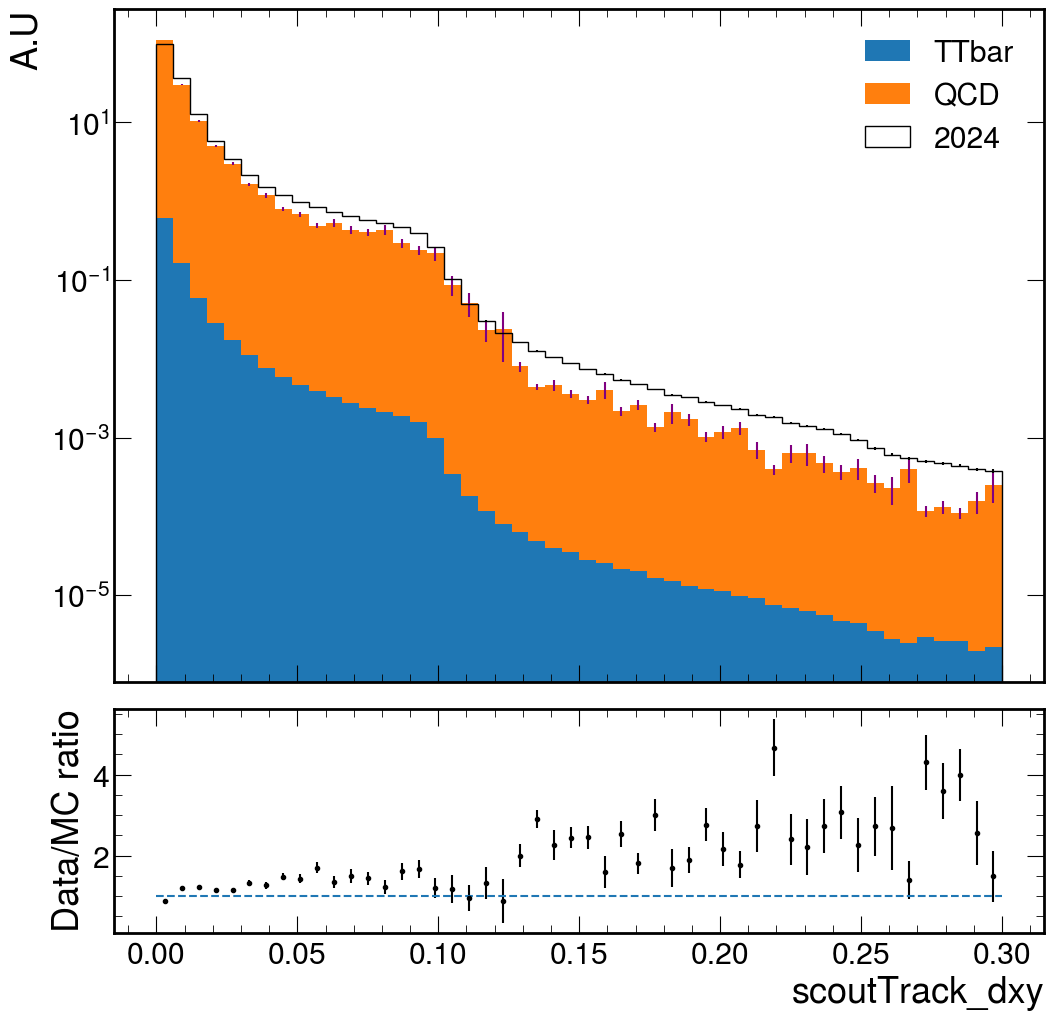

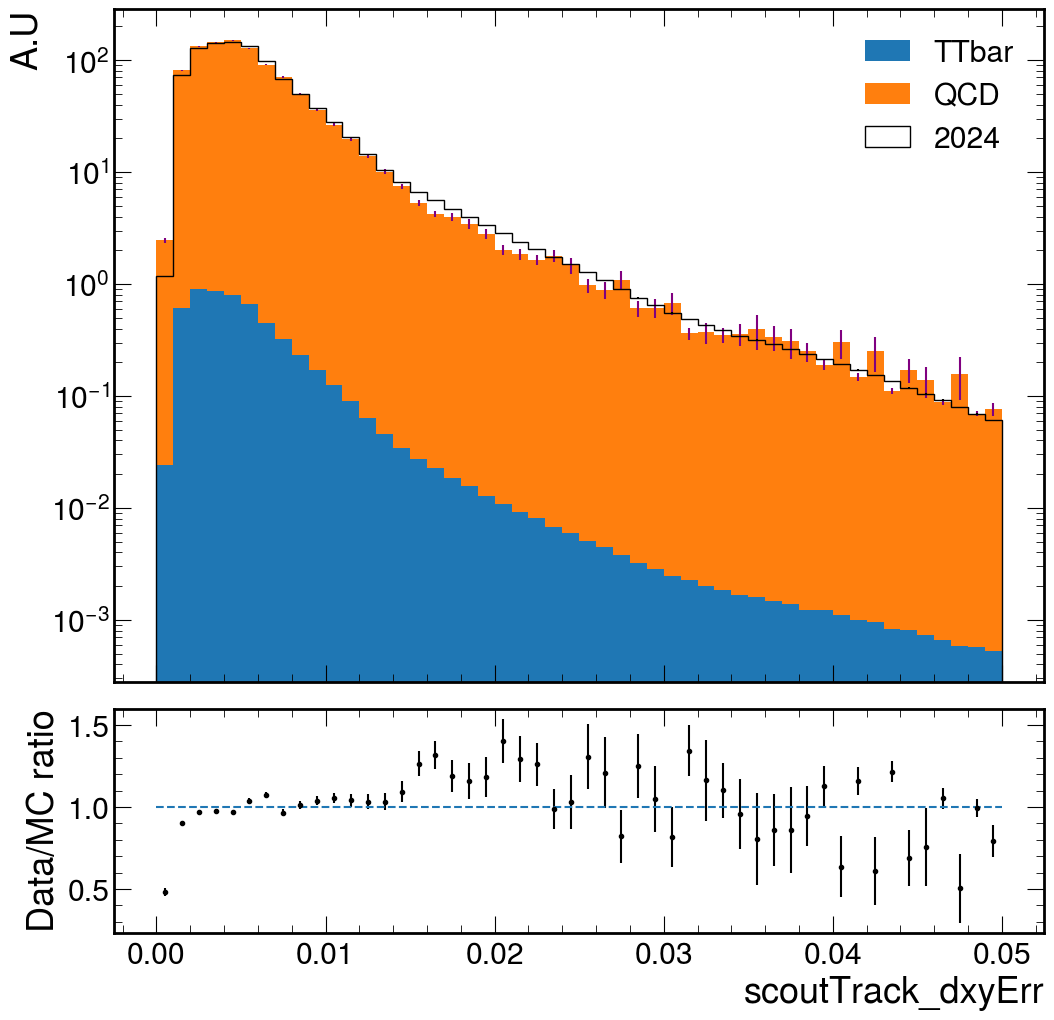

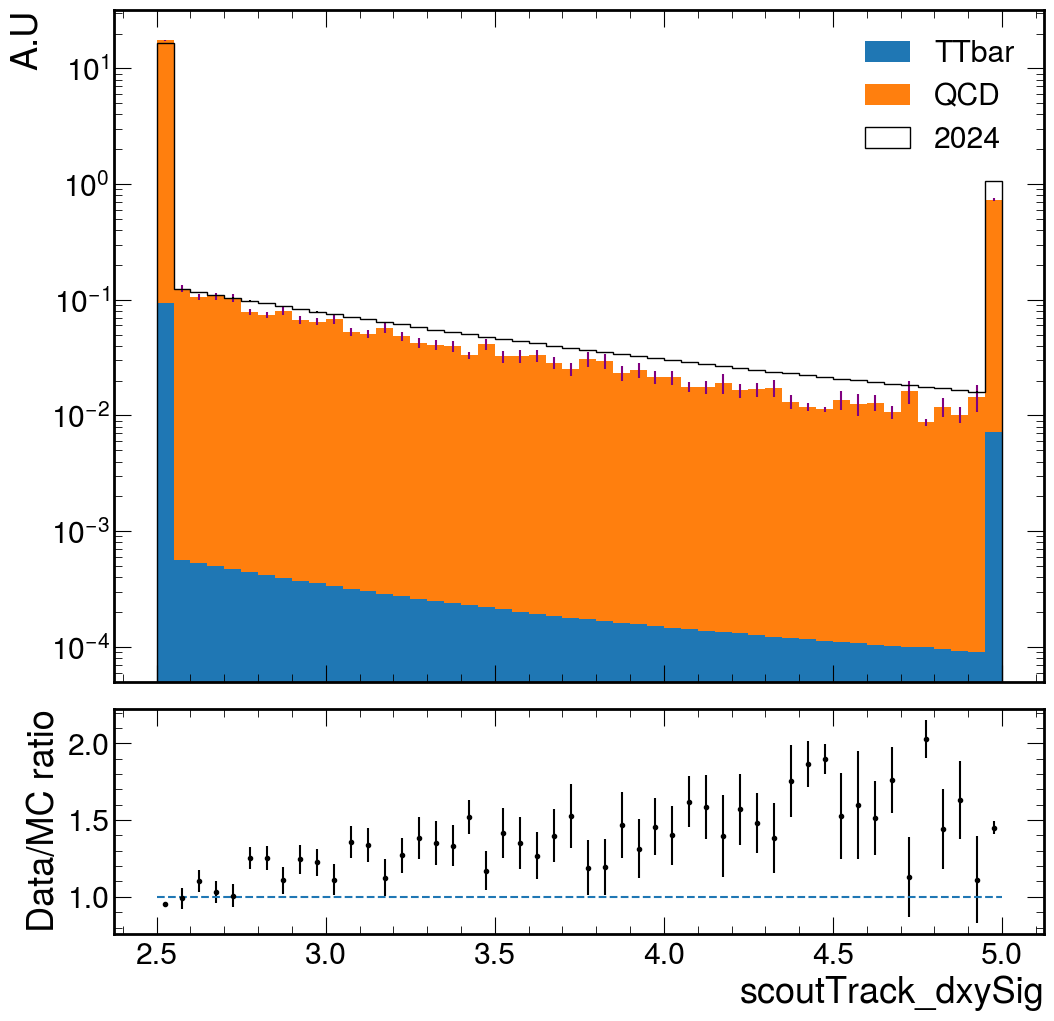

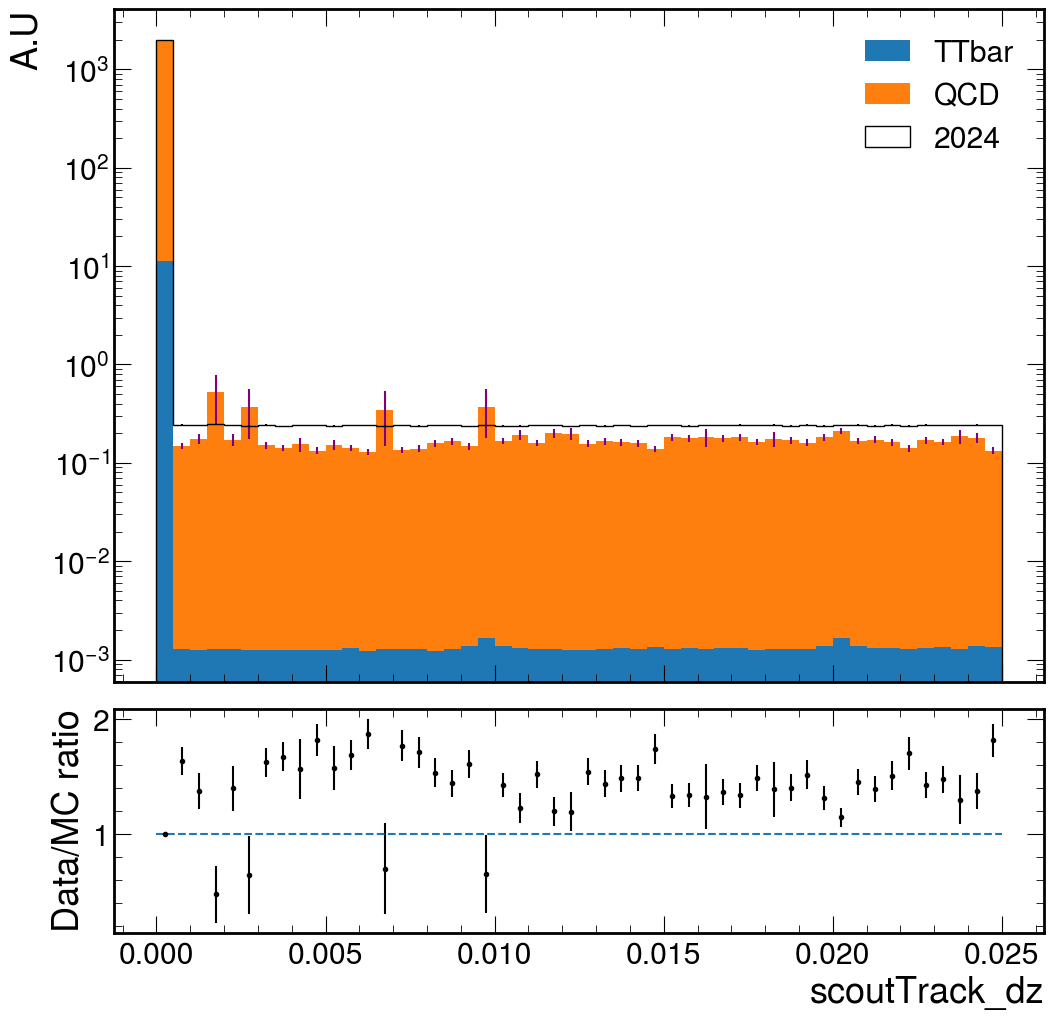

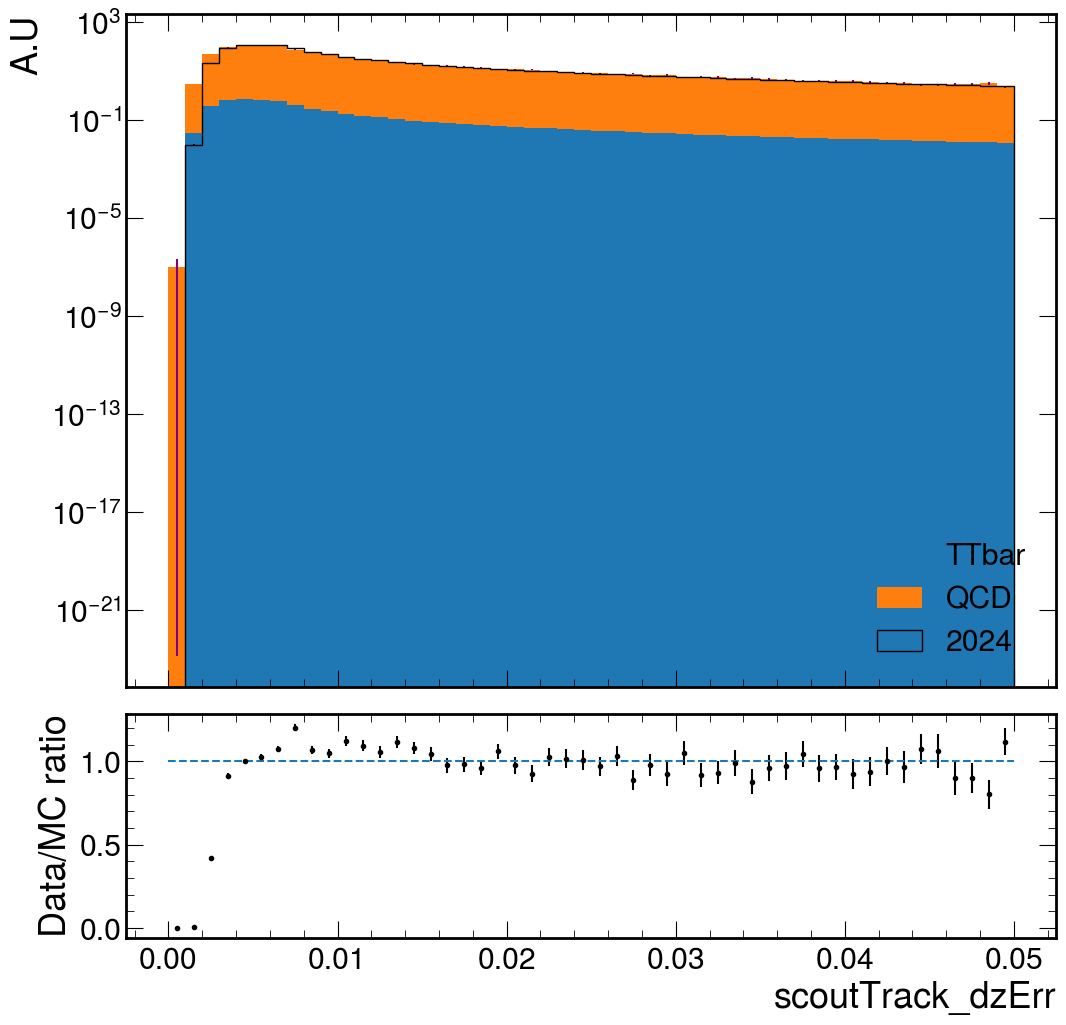

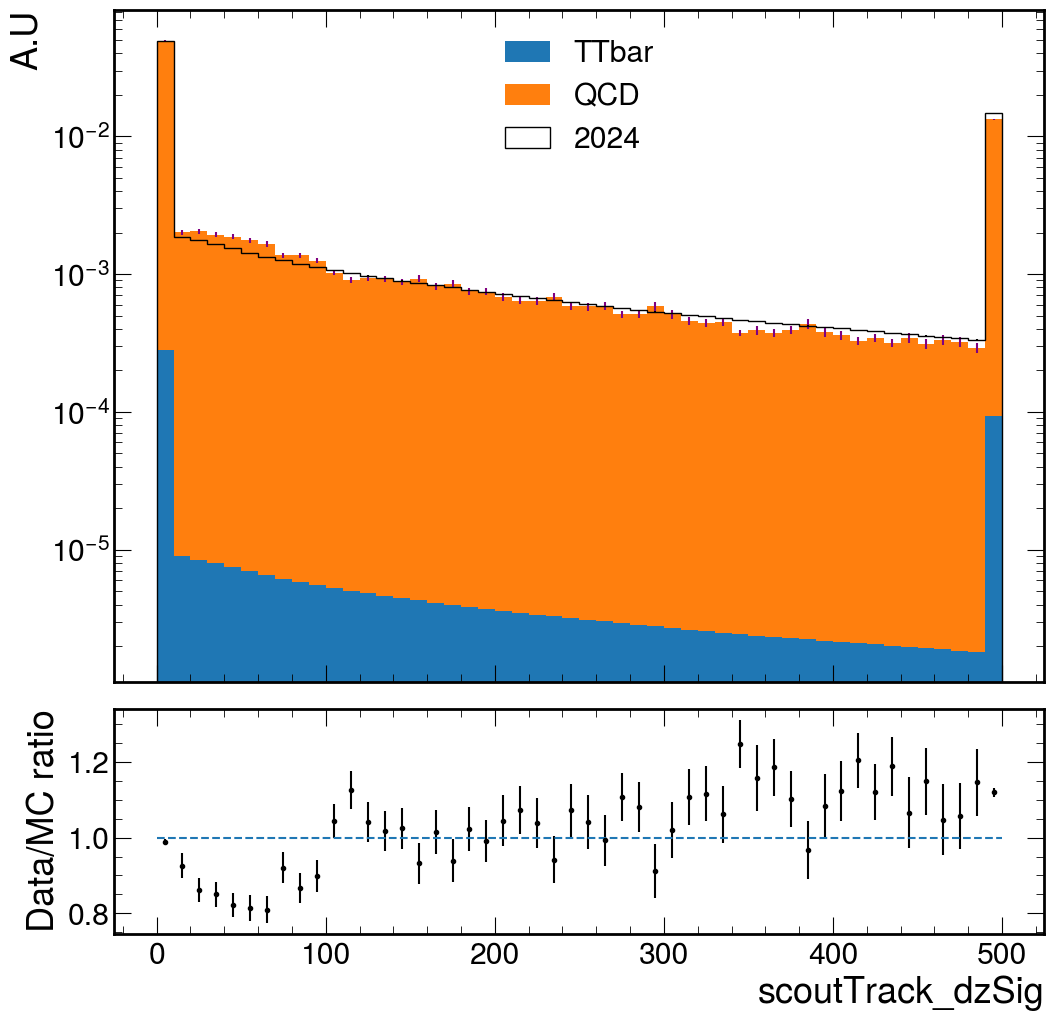

Total runtime: 1018.47 seconds


In [5]:
#Branch plotting script full 2024 pileup correction

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    #"vertTrack_pt": [0,25,26], "vertTrack_eta": [-3,3,26], "vertTrack_phi": [-3.142,3.142,26],
    #"vertTrack_reducedChi2": [0,7,51], 
    #"vertTrack_dxy": [0,0.3,51], "vertTrack_dxyErr": [0,0.05,51], "vertTrack_dxySig": [2.5,5,51],
    #"vertTrack_dz": [0,0.025,51], "vertTrack_dzErr": [0,0.05,51], "vertTrack_dzSig": [0,500,51],
    #"vertTrack_nValidPixelHits": [0,13,14], #"vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    #"vertTrack_shiftZErr": [0,0.05,51], "vertTrack_shiftZValue": [0,0.05,101],
    #"vertTrack_shift3DErr": [0,0.05,51], "vertTrack_shift3DValue": [0,0.1,101],
    #"scoutVert_dBV": [0,0.5,26],# "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    #"scoutVert_nTracks": [4,10,7], "scoutVert_chi2": [0,5,25],
    #"scoutVert_dT": [0,0.5,101], "scoutVert_cosT": [-1,1,101], "scoutVert_pMag": [0,500,101],
    "scoutTrack_dxy": [0,0.3,51], "scoutTrack_dxyErr": [0,0.05,51], "scoutTrack_dxySig": [2.5,5,51],
    "scoutTrack_dz": [0,0.025,51], "scoutTrack_dzErr": [0,0.05,51], "scoutTrack_dzSig": [0,500,51],
    #"scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxySig": [0,50,101], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"scoutTrack_pt": [0,200,101],#, "scoutTrack_nValidPixelHits": [0,13,14]
    #"scoutTrack_pt": [0,25,26], "scoutTrack_eta": [-3,3,26], "scoutTrack_phi": [-3.142,3.142,26],
    #"jet_pt": [30,200,26], "jet_eta": [-3,3,26], "jet_phi": [-3.142,3.142,26],
    #"scoutTrack_pt": [12,200,47],
    #"vertTrack_pt": [4,14,11],
    #"jet_pt": [3,12,10]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open("/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/Summer24Prompt24_RunBCDEFGHI.root") as file:
        jetVetoMap = file["jetvetomap"]
        jetVetoMapXBins = jetVetoMap.to_numpy()[1]
        jetVetoMapYBins = jetVetoMap.to_numpy()[2]
        jetVetoMap = jetVetoMap.to_numpy()[0]
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx","vertTrack_iJet", "weight", "truePU","jet_eta","jet_phi","jet_passJetIdTight","jet_pt","jet_chEmEF","jet_neEmEF","scoutVert_dBV"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        correctionArray = np.load("PURatio_Full2024.npy")
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum
            if(process in processDict):
                PU = batch["truePU"]
                PU_binned = np.digitize(PU,np.linspace(0,100,101))
                PU_binned = PU_binned - 1
                correction = correctionArray[PU_binned]
                weights = weights * correction
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                #if "Sig" in plot:
                #    data = batch["vertTrack_dxy"] / batch["vertTrack_dxyErr"]
                # Apply displacement cut
                if "vertTrack_shift" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
                elif "vertTrack" in plot:
                    #mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)  & (batch["vertTrack_dxySig"] > 5) & (batch["vertTrack_pt"] > 1.0) & (batch["vertTrack_nValidPixelHits"] > 1)
                    '''
                    jetEta = batch["jet_eta"]
                    jetPhi = batch["jet_phi"]
                    jetPt = batch["jet_pt"]
                    jetId = batch["jet_passJetIdTight"]
                    jetChargedEMFrac = batch["jet_chEmEF"]
                    jetNeutralEMFrac = batch["jet_neEmEF"]
                    ivtx = batch["vertTrack_iVtx"]
                    ijet = batch["vertTrack_iJet"]
                    ptMask = (((jetPt>15) & ((abs(jetEta)<=2.5) | (abs(jetEta)>=3))) | ((jetPt>50) & ((abs(jetEta)>2.5) & (abs(jetEta)<3))))
                    selectionMask = ptMask & jetId & ((jetChargedEMFrac+jetNeutralEMFrac)<0.9) & (abs(jetEta)<2.5) & (jetPt>30)
                    #Apply jet veto
                    x_bins = jetVetoMapXBins
                    y_bins = jetVetoMapYBins
                    jetEta_n = ak.num(jetEta)
                    jetEta = ak.flatten(jetEta)
                    jetPhi_n = ak.num(jetPhi)
                    jetPhi = ak.flatten(jetPhi)
                    jetEta_binned = np.digitize(jetEta,x_bins)
                    jetEta_binned = np.clip(jetEta_binned,1,82)
                    jetEta_binned = jetEta_binned - 1
                    jetPhi_binned = np.digitize(jetPhi,y_bins)
                    jetPhi_binned = np.clip(jetPhi_binned,1,72)
                    jetPhi_binned = jetPhi_binned - 1
                    mask = jetVetoMap[jetEta_binned,jetPhi_binned]
                    mask = (mask == 0)
                    mask = ak.unflatten(mask,jetEta_n)
                    mask = mask & selectionMask
                    trackVeto = (mask[ijet]) | (ijet==-1)
                    '''
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01) & (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] < 2) #& trackVeto
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2)
                elif "scoutTrack" in plot:
                    #mask = (batch["scoutTrack_dxySig"] > 5) & (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
                    mask = ak.ones_like(data, dtype=bool)
                elif "jet" in plot:
                    '''
                    jetEta = batch["jet_eta"]
                    jetPhi = batch["jet_phi"]
                    jetPt = batch["jet_pt"]
                    jetId = batch["jet_passJetIdTight"]
                    jetChargedEMFrac = batch["jet_chEmEF"]
                    jetNeutralEMFrac = batch["jet_neEmEF"]
                    ptMask = (((jetPt>15) & ((abs(jetEta)<=2.5) | (abs(jetEta)>=3))) | ((jetPt>50) & ((abs(jetEta)>2.5) & (abs(jetEta)<3))))
                    selectionMask = ptMask & jetId & ((jetChargedEMFrac+jetNeutralEMFrac)<0.9) & (abs(jetEta)<2.5) & (jetPt>30)
                    jetEta_n = ak.num(jetEta)
                    jetEta = ak.flatten(jetEta)
                    jetPhi_n = ak.num(jetPhi)
                    jetPhi = ak.flatten(jetPhi)
                    jetEta_binned = np.digitize(jetEta,jetVetoMapXBins)
                    jetEta_binned = np.clip(jetEta_binned,1,82)
                    jetEta_binned = jetEta_binned - 1
                    jetPhi_binned = np.digitize(jetPhi,jetVetoMapYBins)
                    jetPhi_binned = np.clip(jetPhi_binned,1,72)
                    jetPhi_binned = jetPhi_binned - 1
                    mask = jetVetoMap[jetEta_binned,jetPhi_binned]
                    mask = (mask == 0)
                    mask = ak.unflatten(mask,jetEta_n)
                    mask = mask & selectionMask
                    '''
                    mask = ak.ones_like(data, dtype=bool)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD40to70"]+bgPlotWeights[plot]["QCD70to100"]+bgPlotWeights[plot]["QCD100to200"]+bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD40to70"]+bgPlotWeights[f"{plot}_squared"]["QCD70to100"]+bgPlotWeights[f"{plot}_squared"]["QCD100to200"]+bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]
    sigPlotWeights[f"{plot}_squared"]["2024"] = sigPlotWeights[f"{plot}_squared"]["2024C"]+sigPlotWeights[f"{plot}_squared"]["2024D"]+sigPlotWeights[f"{plot}_squared"]["2024E"]+sigPlotWeights[f"{plot}_squared"]["2024F"]+sigPlotWeights[f"{plot}_squared"]["2024G"]+sigPlotWeights[f"{plot}_squared"]["2024H"]+sigPlotWeights[f"{plot}_squared"]["2024I"]

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"2024": "black"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("Data/MC ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    #rax.set_ylim(0,2)
    #rax.set_yscale("log")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Processing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v28-4DxyMin/260406_193206/QCD-4Jets_Bin-HT-100to200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v28-4DxyMin/260406_193259/QCD-4Jets_Bin-HT-40to70.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v28-4DxyMin/260406_193241/QCD-4Jets_Bin-HT-200to400.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v28-4DxyMin/260406_193310/QCD-4Jets_Bin-HT-600to800.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v28-4DxyMin/260406_193157/QCD-4Je

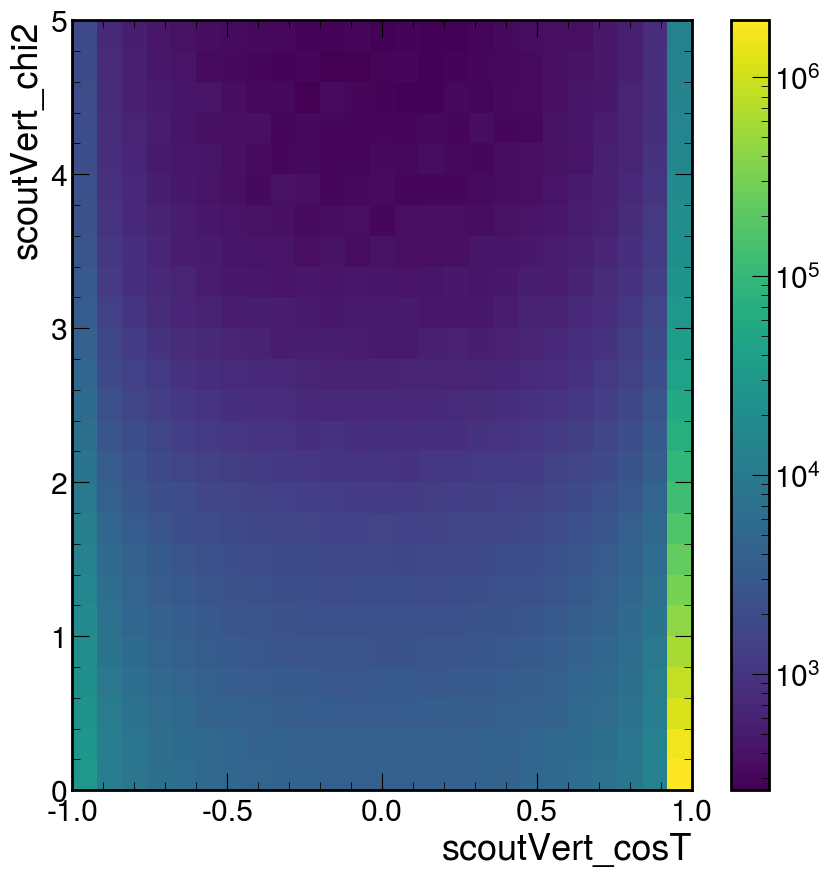

Total runtime: 98.11 seconds


In [19]:
#2D plotting script full 2024 pileup correction

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.colors import LogNorm

plotDict = {
    #"scoutTrack_eta": [-3,3,26], "scoutTrack_phi": [-3.142,3.142,26],
    "scoutVert_chi2": [0,5,26], "scoutVert_cosT": [-1,1,26]
}

x_axis = "scoutVert_cosT"
y_axis = "scoutVert_chi2"

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    weightSum = np.zeros((plotDict[x_axis][2]-1,plotDict[y_axis][2]-1))
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["weight", "truePU","scoutVert_dBV","vertTrack_iVtx","scoutTrack_pt","scoutTrack_nValidPixelHits","scoutTrack_nTrackerLayersWithMeasurement","scoutVert_nTracks"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        #correctionArray = np.load("PURatio_Full2024.npy")
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            weights = batch["weight"]  # normalize event weights
            '''
            if(process in processDict):
                if(not doWeightSum): weights = weights / genWeightSum
                PU = batch["truePU"]
                PU_binned = np.digitize(PU,np.linspace(0,100,101))
                PU_binned = PU_binned - 1
                correction = correctionArray[PU_binned]
                weights = weights * correction
            '''
            weights = ak.ones_like(weights)
            x_binning = plotDict[x_axis]
            x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
            x_data = batch[x_axis]

            y_binning = plotDict[y_axis]
            y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
            y_data = batch[y_axis]
                
            # Apply displacement cut
            if "vertTrack_shift" in x_axis:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
            elif "vertTrack" in x_axis:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01) & (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] < 2) #& trackVeto
            elif "scoutVert" in x_axis:
                mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2.0) & (batch["scoutVert_nTracks"] < 8)
            elif "scoutTrack" in plot:
                mask = (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
            else:
                mask = ak.ones_like(x_data, dtype=bool)
            x_data = x_data[mask]
            # Apply displacement cut
            if "vertTrack_shift" in y_axis:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
            elif "vertTrack" in y_axis:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01) & (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] < 2) #& trackVeto
            elif "scoutVert" in y_axis:
                mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2.0) & (batch["scoutVert_nTracks"] < 8)
            elif "scoutTrack" in plot:
                mask = (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
            else:
                mask = ak.ones_like(y_data, dtype=bool)
            y_data = y_data[mask]

            broadcastWeights, x_data = ak.broadcast_arrays(weights,x_data)
            # Apply mask and flatten data
            x_data = ak.flatten(x_data,axis=None)
            x_data = np.clip(x_data,x_bins[0],x_bins[-1])
            y_data = ak.flatten(y_data,axis=None)
            y_data = np.clip(y_data,y_bins[0],y_bins[-1])
            weights_filtered = ak.flatten(broadcastWeights,axis=None)
            # Compute histograms
            n, xedges, yedges = np.histogram2d(x_data,y_data,weights=weights_filtered, bins=(x_bins,y_bins))
            weightSum = weightSum + n
        output["2D"] = {process: weightSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in ["2D"]:
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD40to70"]+bgPlotWeights[plot]["QCD70to100"]+bgPlotWeights[plot]["QCD100to200"]+bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]

# **Plotting**
x_binning = plotDict[x_axis]
y_binning = plotDict[y_axis]
x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
ratio = np.array(sigPlotWeights["2D"]["2024"]).T #/ (np.array(bgPlotWeights["2D"]["QCD"]).T + np.array(bgPlotWeights["2D"]["TTbar"]).T)
plt.pcolormesh(x_bins, y_bins, ratio, shading='auto', cmap='viridis',norm=LogNorm())
plt.colorbar()
plt.xlabel(x_axis)
plt.ylabel(y_axis)
plt.savefig("chi2VsCosT_25bins.pdf", bbox_inches='tight')
plt.show()
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [20]:
def histogram_correlation(x_edges, y_edges, H):
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers, indexing='xy')
    x_vals = X.ravel()
    y_vals = Y.ravel()
    weights = H.ravel()
    mean_x = np.average(x_vals, weights=weights)
    mean_y = np.average(y_vals, weights=weights)
    cov_xy = np.average((x_vals - mean_x) * (y_vals - mean_y), weights=weights)
    var_x = np.average((x_vals - mean_x)**2, weights=weights)
    var_y = np.average((y_vals - mean_y)**2, weights=weights)
    return cov_xy / np.sqrt(var_x * var_y)

print("Data", histogram_correlation(x_bins, y_bins, np.array(sigPlotWeights["2D"]["2024"])))

Data -0.20966628821302388


Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v25-3to4Dxy/260309_233058/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-70to100_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-70to100_Tree_v25-3to4Dxy/260309_233229/QCD-4Jets_Bin-HT-70to100.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v25-3to4Dxy/260309_233156/QCD-4Jets_Bin-HT-400to600.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v25-3to4Dxy/260309_233104/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v25-3to4Dxy/260309_233129/QCD-4Jets_Bin-HT-1500to2000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneC

/tmp/rmccarth/ipykernel_1319046/3141024354.py:272: RuntimeWarning: invalid value encountered in divide
  ratioValues = sigValues / bgValues
/tmp/rmccarth/ipykernel_1319046/3141024354.py:273: RuntimeWarning: invalid value encountered in divide
  ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)


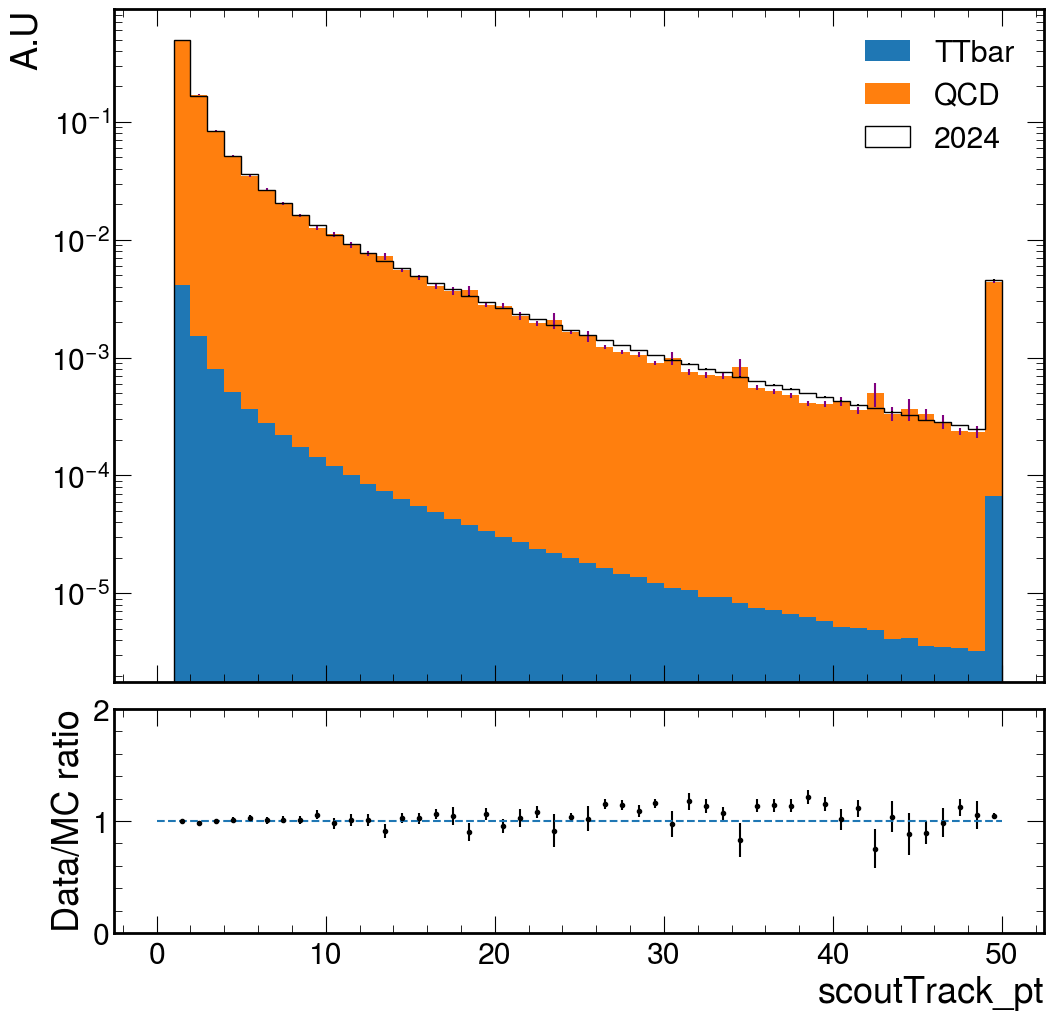

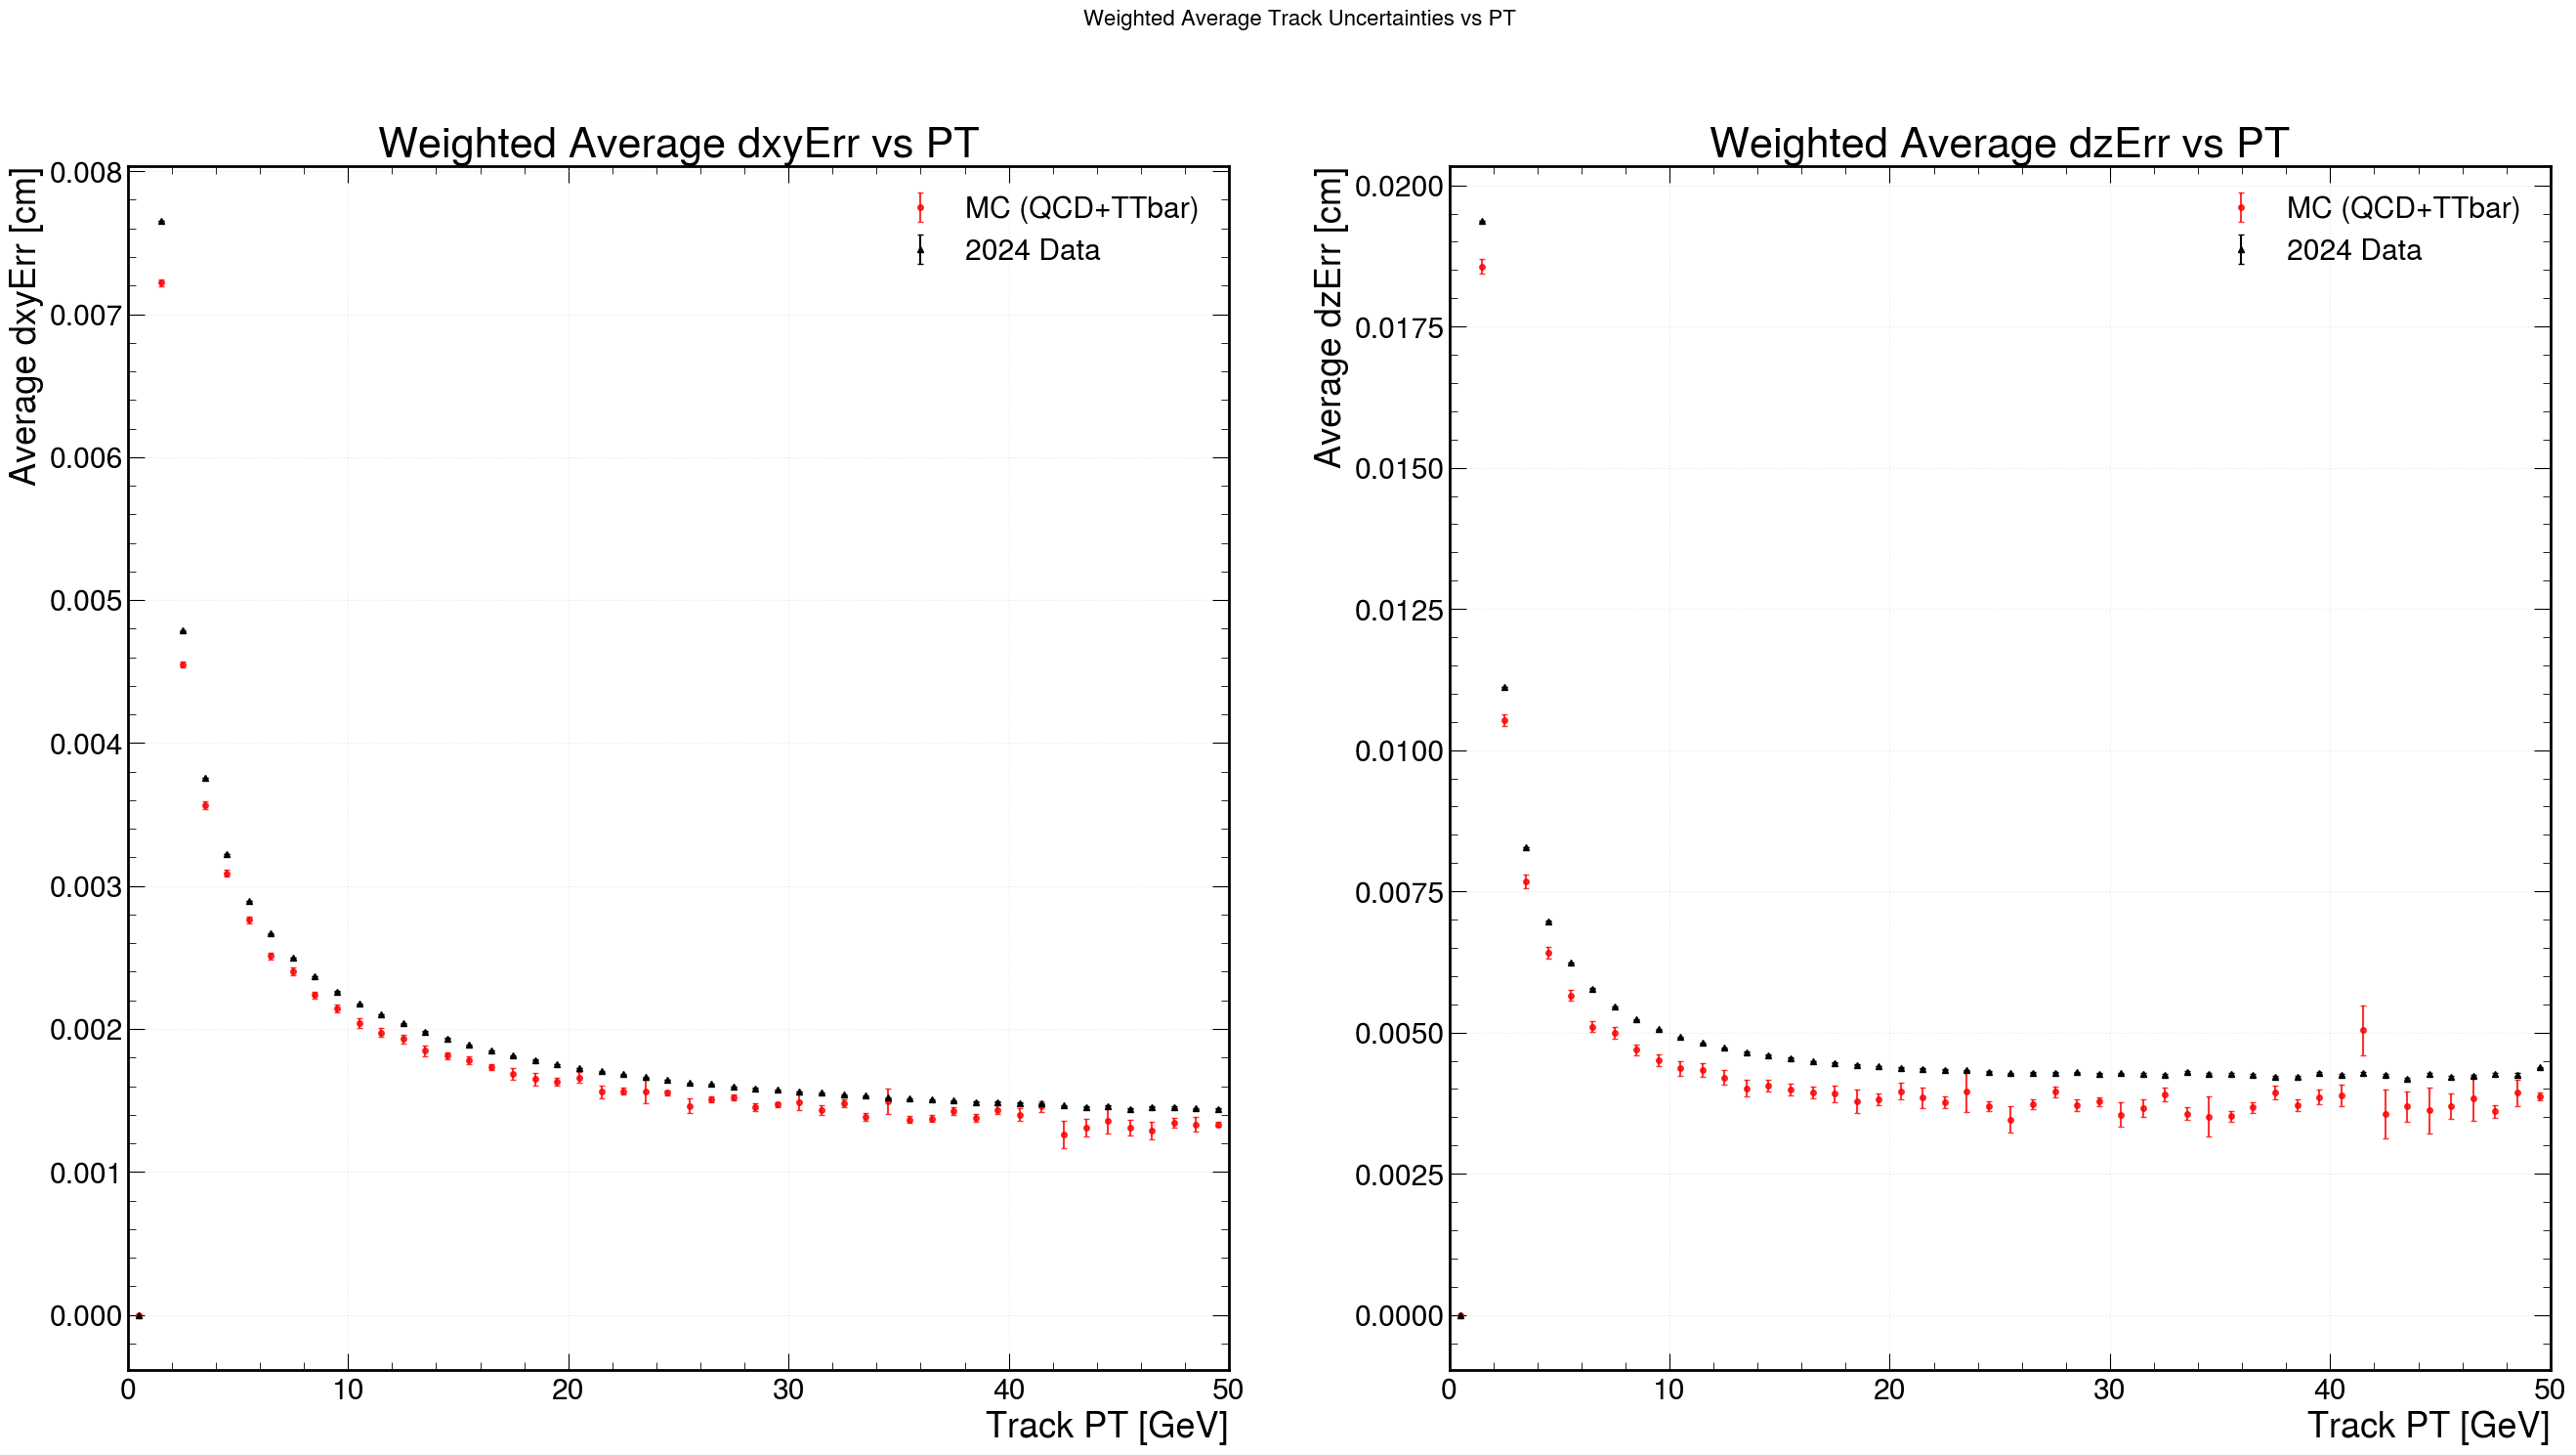

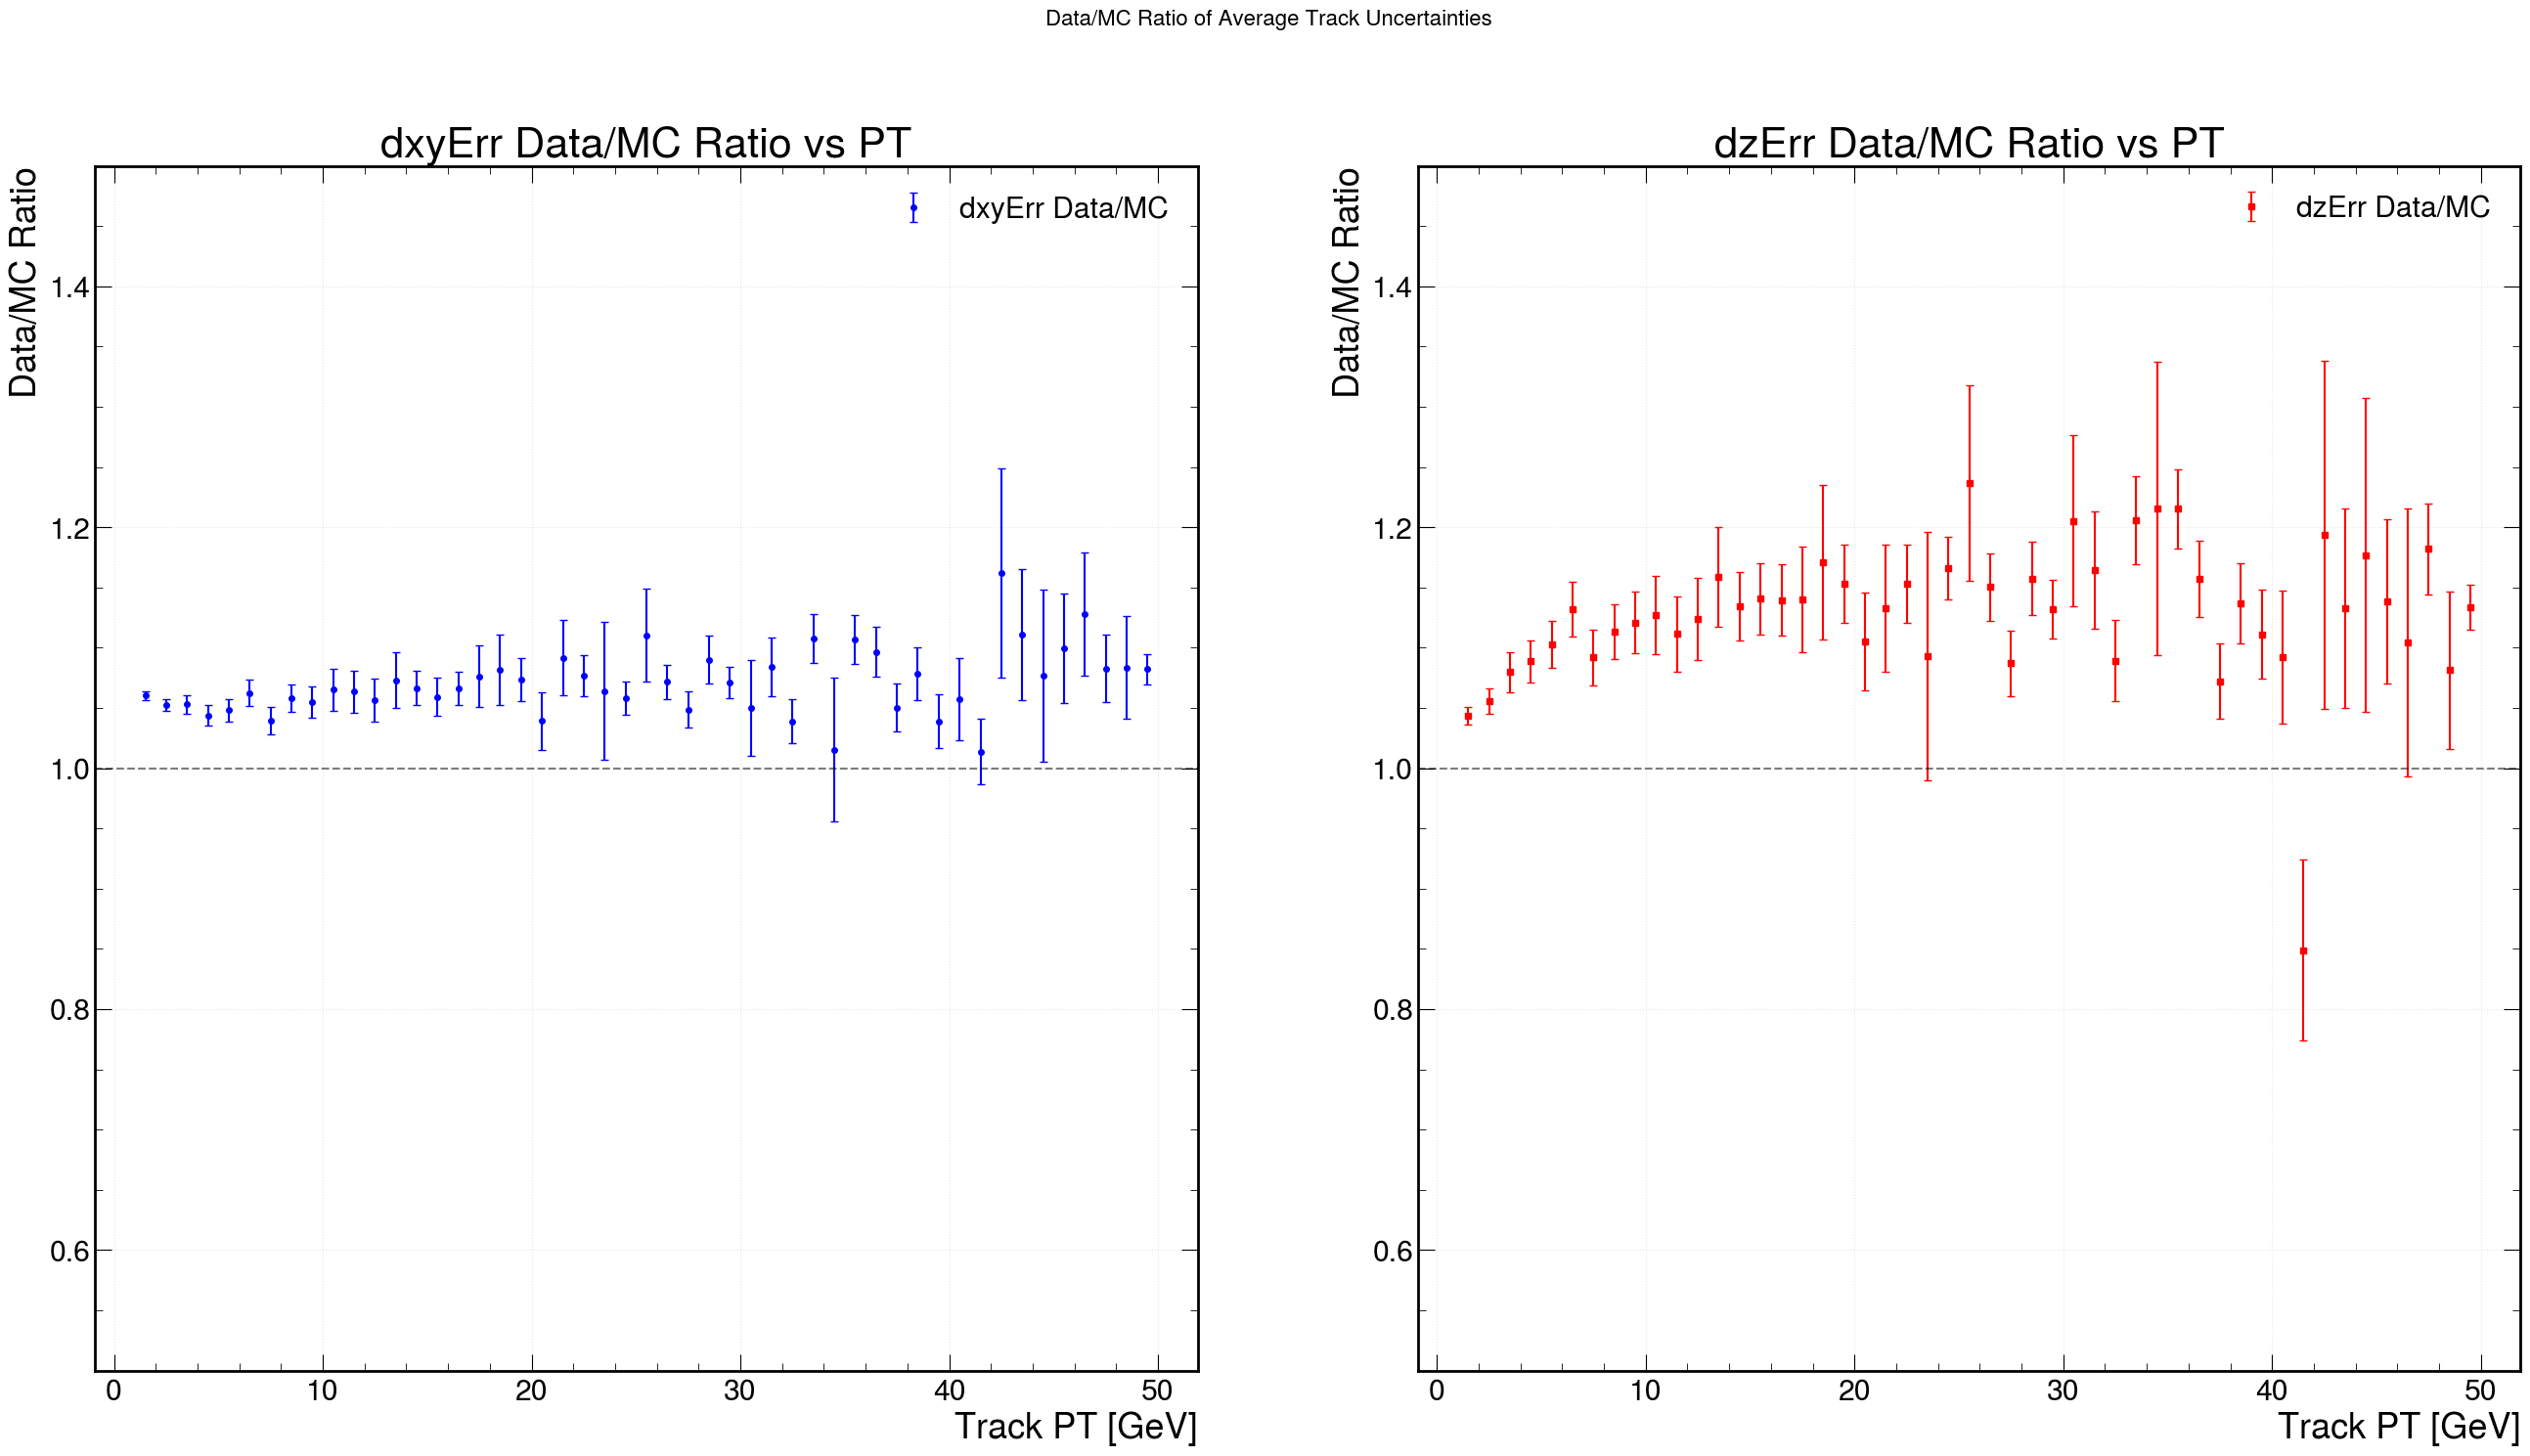

Total runtime: 265.37 seconds


In [6]:
#Track Uncertainty Study Plots

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "scoutTrack_pt": [0,50,51]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")
    output = {}
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {}
        genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select necessary branches including error branches
        branches = list(plotDict.keys()) + ["weight", "truePU", "scoutTrack_dxyErr", "scoutTrack_dzErr", 
                                           "scoutTrack_nValidPixelHits", "scoutTrack_nTrackerLayersWithMeasurement"]
        
        # Initialize arrays for storing weighted statistics per pt bin
        pt_bins = np.linspace(plotDict["scoutTrack_pt"][0], plotDict["scoutTrack_pt"][1], plotDict["scoutTrack_pt"][2])
        n_bins = len(pt_bins) - 1
        
        # For weighted mean and standard error calculation
        dxyErr_weighted_sum = np.zeros(n_bins)
        dzErr_weighted_sum = np.zeros(n_bins)
        dxyErr_weighted_sq_sum = np.zeros(n_bins)
        dzErr_weighted_sq_sum = np.zeros(n_bins)
        weight_sum = np.zeros(n_bins)
        weight_sq_sum = np.zeros(n_bins)
        
        # Iterate over the tree in chunks
        correctionArray = np.load("PURatio_Full2024.npy")
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            weights = batch["weight"]  # normalize event weights
            
            if(process in processDict):
                weights = weights / genWeightSum
                PU = batch["truePU"]
                PU_binned = np.digitize(PU,np.linspace(0,100,101))
                PU_binned = PU_binned - 1
                correction = correctionArray[PU_binned]
                weights = weights * correction
                
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                dxyErr = batch["scoutTrack_dxyErr"]
                dzErr = batch["scoutTrack_dzErr"]
                
                if "scoutTrack" in plot:
                    mask = (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                
                data = data[mask]
                dxyErr = dxyErr[mask]
                dzErr = dzErr[mask]
                
                # Calculate weighted statistics per pt bin using optimized columnar operations
                broadcastWeights, data = ak.broadcast_arrays(weights, data)
                
                # Flatten arrays
                data_flat = ak.to_numpy(ak.flatten(data, axis=None))
                dxyErr_flat = ak.to_numpy(ak.flatten(dxyErr, axis=None))
                dzErr_flat = ak.to_numpy(ak.flatten(dzErr, axis=None))
                weights_flat = ak.to_numpy(ak.flatten(broadcastWeights, axis=None))
                
                # Digitize pt values to find which bin each track belongs to
                pt_bin_indices = np.digitize(data_flat, pt_bins) 
                pt_bin_indices = np.clip(pt_bin_indices,1,binning[2]-1)
                pt_bin_indices = pt_bin_indices - 1
                
                # np.bincount accumulates values for each integer index
                dxyErr_weighted_sum += np.bincount(pt_bin_indices, 
                                                   weights=weights_flat * dxyErr_flat, 
                                                   minlength=n_bins)
                dzErr_weighted_sum += np.bincount(pt_bin_indices, 
                                                  weights=weights_flat * dzErr_flat, 
                                                  minlength=n_bins)
                dxyErr_weighted_sq_sum += np.bincount(pt_bin_indices, 
                                                      weights=weights_flat * dxyErr_flat * dxyErr_flat, 
                                                      minlength=n_bins)
                dzErr_weighted_sq_sum += np.bincount(pt_bin_indices, 
                                                     weights=weights_flat * dzErr_flat * dzErr_flat, 
                                                     minlength=n_bins)
                weight_sum += np.bincount(pt_bin_indices, 
                                         weights=weights_flat, 
                                         minlength=n_bins)
                weight_sq_sum += np.bincount(pt_bin_indices, 
                                            weights=weights_flat * weights_flat, 
                                            minlength=n_bins)
                
                # Original histogram calculation
                data_clipped = np.clip(data_flat, bins[0], bins[-1])
                n, _ = np.histogram(data_clipped, weights=weights_flat, bins=bins)
                n_2, _ = np.histogram(data_clipped, weights=weights_flat**2, bins=bins)
                
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
        
        # Calculate final weighted averages and standard errors
        with np.errstate(divide='ignore', invalid='ignore'):
            # Weighted means
            dxyErr_mean = np.where(weight_sum > 0, dxyErr_weighted_sum / weight_sum, 0)
            dzErr_mean = np.where(weight_sum > 0, dzErr_weighted_sum / weight_sum, 0)
            
            # Weighted variances
            dxyErr_var = np.where(weight_sum > 0, 
                                  dxyErr_weighted_sq_sum / weight_sum - dxyErr_mean**2, 0)
            dzErr_var = np.where(weight_sum > 0, 
                                 dzErr_weighted_sq_sum / weight_sum - dzErr_mean**2, 0)
            
            # Effective sample size
            eff_n = np.where(weight_sq_sum > 0, weight_sum**2 / weight_sq_sum, 0)
            
            # Standard errors of the weighted mean
            dxyErr_stderr = np.where(eff_n > 0, np.sqrt(dxyErr_var / eff_n), 0)
            dzErr_stderr = np.where(eff_n > 0, np.sqrt(dzErr_var / eff_n), 0)
        
        output["dxyErr_mean"] = {process: dxyErr_mean}
        output["dzErr_mean"] = {process: dzErr_mean}
        output["dxyErr_stderr"] = {process: dxyErr_stderr}
        output["dzErr_stderr"] = {process: dzErr_stderr}
        output["weight_sum"] = {process: weight_sum}
        output["weight_sq_sum"] = {process: weight_sq_sum}
        output["dxyErr_weighted_sum"] = {process: dxyErr_weighted_sum}
        output["dzErr_weighted_sum"] = {process: dzErr_weighted_sum}
        output["dxyErr_weighted_sq_sum"] = {process: dxyErr_weighted_sq_sum}
        output["dzErr_weighted_sq_sum"] = {process: dzErr_weighted_sq_sum}
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if isinstance(result[plot][process], np.ndarray):
                            results[plot][process] = results[plot].get(process, 0) + result[plot][process]
                        else:
                            results[plot][process] = result[plot][process]

    return results

# Helper function to combine weighted statistics
def combine_weighted_stats(data, components):
    """Combine weighted statistics from multiple components"""
    combined = {}
    
    # First combine the raw sums
    sum_keys = ["weight_sum", "weight_sq_sum", "dxyErr_weighted_sum", "dzErr_weighted_sum",
                "dxyErr_weighted_sq_sum", "dzErr_weighted_sq_sum"]
    
    for key in sum_keys:
        if key in data:
            combined[key] = sum(data[key][comp] for comp in components if comp in data[key])
    
    # Recalculate means and standard errors
    with np.errstate(divide='ignore', invalid='ignore'):
        # Weighted means
        combined["dxyErr_mean"] = np.where(combined["weight_sum"] > 0, 
                                          combined["dxyErr_weighted_sum"] / combined["weight_sum"], 0)
        combined["dzErr_mean"] = np.where(combined["weight_sum"] > 0, 
                                         combined["dzErr_weighted_sum"] / combined["weight_sum"], 0)
        
        # Weighted variances
        dxyErr_var = np.where(combined["weight_sum"] > 0,
                              combined["dxyErr_weighted_sq_sum"] / combined["weight_sum"] - combined["dxyErr_mean"]**2, 0)
        dzErr_var = np.where(combined["weight_sum"] > 0,
                             combined["dzErr_weighted_sq_sum"] / combined["weight_sum"] - combined["dzErr_mean"]**2, 0)
        
        # Effective sample size
        eff_n = np.where(combined["weight_sq_sum"] > 0, 
                         combined["weight_sum"]**2 / combined["weight_sq_sum"], 0)
        
        # Standard errors
        combined["dxyErr_stderr"] = np.where(eff_n > 0, np.sqrt(dxyErr_var / eff_n), 0)
        combined["dzErr_stderr"] = np.where(eff_n > 0, np.sqrt(dzErr_var / eff_n), 0)
    
    return combined

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

# Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    
    # Combine QCD components
    qcd_components = ["QCD40to70", "QCD70to100", "QCD100to200", "QCD200to400", "QCD400to600", 
                     "QCD600to800", "QCD800to1000", "QCD1000to1200", "QCD1200to1500", "QCD1500to2000", "QCD2000"]
    bgPlotWeights[plot]["QCD"] = sum(bgPlotWeights[plot][comp] for comp in qcd_components if comp in bgPlotWeights[plot])
    bgPlotWeights[f"{plot}_squared"]["QCD"] = sum(bgPlotWeights[f"{plot}_squared"][comp] for comp in qcd_components if comp in bgPlotWeights[f"{plot}_squared"])
    
    # Combine TTbar components
    ttbar_components = ["TTTo4Q", "TTToLNu2Q"]
    bgPlotWeights[plot]["TTbar"] = sum(bgPlotWeights[plot][comp] for comp in ttbar_components if comp in bgPlotWeights[plot])
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = sum(bgPlotWeights[f"{plot}_squared"][comp] for comp in ttbar_components if comp in bgPlotWeights[f"{plot}_squared"])
    
    # Combine 2024 data
    data_components = ["2024C", "2024D", "2024E", "2024F", "2024G", "2024H", "2024I"]
    sigPlotWeights[plot]["2024"] = sum(sigPlotWeights[plot][comp] for comp in data_components if comp in sigPlotWeights[plot])
    sigPlotWeights[f"{plot}_squared"]["2024"] = sum(sigPlotWeights[f"{plot}_squared"][comp] for comp in data_components if comp in sigPlotWeights[f"{plot}_squared"])

# Combine weighted statistics for QCD
bg_stats = combine_weighted_stats(bgPlotWeights, qcd_components+ttbar_components)
for key in bg_stats:
    bgPlotWeights[key]["BG"] = bg_stats[key]

# Combine weighted statistics for 2024 data
data_stats = combine_weighted_stats(sigPlotWeights, data_components)
for key in data_stats:
    sigPlotWeights[key]["2024"] = data_stats[key]

# **Plotting**
# Original PT distribution plot
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2, weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"2024": "black"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("Data/MC ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_ylim(0,2)
    plt.show()

# Plot average dxyErr and dzErr vs PT with error bars
pt_bins = np.linspace(plotDict["scoutTrack_pt"][0], plotDict["scoutTrack_pt"][1], plotDict["scoutTrack_pt"][2])
pt_centers = (pt_bins[:-1] + pt_bins[1:]) / 2

mc_dxyErr_mean = bgPlotWeights["dxyErr_mean"]["BG"]
mc_dzErr_mean = bgPlotWeights["dzErr_mean"]["BG"]
mc_dxyErr_stderr = bgPlotWeights["dxyErr_stderr"]["BG"]
mc_dzErr_stderr = bgPlotWeights["dzErr_stderr"]["BG"]
# Create figure with 2 subplots for dxyErr and dzErr
fig, axes = plt.subplots(1, 2, figsize=[32, 16])
fig.suptitle("Weighted Average Track Uncertainties vs PT", fontsize=16)

# Plot 1: Average dxyErr vs PT with error bars
ax = axes[0]
ax.errorbar(pt_centers, mc_dxyErr_mean, 
           yerr=mc_dxyErr_stderr,
           label="MC (QCD+TTbar)", marker='o', markersize=4, capsize=2, alpha=0.8, linestyle='none', color='red')
ax.errorbar(pt_centers, sigPlotWeights["dxyErr_mean"]["2024"], 
           yerr=sigPlotWeights["dxyErr_stderr"]["2024"],
           label="2024 Data", marker='^', markersize=4, color='black', capsize=2, linestyle='none')
ax.set_xlabel("Track PT [GeV]")
ax.set_ylabel("Average dxyErr [cm]")
ax.set_title("Weighted Average dxyErr vs PT")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(pt_bins[0], pt_bins[-1])

# Plot 2: Average dzErr vs PT with error bars
ax = axes[1]
ax.errorbar(pt_centers, mc_dzErr_mean, 
           yerr=mc_dzErr_stderr,
           label="MC (QCD+TTbar)", marker='o', markersize=4, capsize=2, alpha=0.8, linestyle='none', color='red')
ax.errorbar(pt_centers, sigPlotWeights["dzErr_mean"]["2024"], 
           yerr=sigPlotWeights["dzErr_stderr"]["2024"],
           label="2024 Data", marker='^', markersize=4, color='black', capsize=2, linestyle='none')
ax.set_xlabel("Track PT [GeV]")
ax.set_ylabel("Average dzErr [cm]")
ax.set_title("Weighted Average dzErr vs PT")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(pt_bins[0], pt_bins[-1])

#plt.tight_layout()
plt.show()

# Create ratio plots for error comparisons with uncertainties
fig, axes = plt.subplots(1, 2, figsize=[32, 16])
fig.suptitle("Data/MC Ratio of Average Track Uncertainties", fontsize=16)

# Calculate ratios (mc_dxyErr_mean etc already calculated above)
with np.errstate(divide='ignore', invalid='ignore'):
    # Calculate ratios
    ratio_dxyErr = np.where(mc_dxyErr_mean > 0, 
                           sigPlotWeights["dxyErr_mean"]["2024"] / mc_dxyErr_mean, 0)
    ratio_dzErr = np.where(mc_dzErr_mean > 0, 
                          sigPlotWeights["dzErr_mean"]["2024"] / mc_dzErr_mean, 0)
    
    # Propagate errors for ratios
    ratio_dxyErr_err = ratio_dxyErr * np.sqrt(
        np.where(sigPlotWeights["dxyErr_mean"]["2024"] > 0, 
                (sigPlotWeights["dxyErr_stderr"]["2024"] / sigPlotWeights["dxyErr_mean"]["2024"])**2, 0) +
        np.where(mc_dxyErr_mean > 0, (mc_dxyErr_stderr / mc_dxyErr_mean)**2, 0))
    
    ratio_dzErr_err = ratio_dzErr * np.sqrt(
        np.where(sigPlotWeights["dzErr_mean"]["2024"] > 0,
                (sigPlotWeights["dzErr_stderr"]["2024"] / sigPlotWeights["dzErr_mean"]["2024"])**2, 0) +
        np.where(mc_dzErr_mean > 0, (mc_dzErr_stderr / mc_dzErr_mean)**2, 0))

# Ratio plot for dxyErr
ax = axes[0]
valid = ratio_dxyErr > 0
ax.errorbar(pt_centers[valid], ratio_dxyErr[valid], yerr=ratio_dxyErr_err[valid],
           marker='o', markersize=4, color='blue', label='dxyErr Data/MC', capsize=3, linestyle='none')
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel("Track PT [GeV]")
ax.set_ylabel("Data/MC Ratio")
ax.set_title("dxyErr Data/MC Ratio vs PT")
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)
ax.legend()

# Ratio plot for dzErr
ax = axes[1]
valid = ratio_dzErr > 0
ax.errorbar(pt_centers[valid], ratio_dzErr[valid], yerr=ratio_dzErr_err[valid],
           marker='s', markersize=4, color='red', label='dzErr Data/MC', capsize=3, linestyle='none')
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel("Track PT [GeV]")
ax.set_ylabel("Data/MC Ratio")
ax.set_title("dzErr Data/MC Ratio vs PT")
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)
ax.legend()

#plt.tight_layout()
plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

/tmp/rmccarth/ipykernel_2354677/3692689796.py:112: RuntimeWarning: divide by zero encountered in divide
  ratios = observed_values / expected_values
/tmp/rmccarth/ipykernel_2354677/3692689796.py:118: RuntimeWarning: divide by zero encountered in divide
  ratio_errors = ratios * np.sqrt(1/observed_values + (expected_unc/expected_values)**2)
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-matplotlib/3.7.1-fa9ca38d621a0c83dbd532b338145aec/lib/python3.9/site-packages/matplotlib/axes/_axes.py:3648: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.row_stack([-(1 - lolims), 1 - uplims]) * err
/tmp/rmccarth/ipykernel_2354677/3692689796.py:136: RuntimeWarning: invalid value encountered in divide
  pulls = (ratios - 1) / ratio_errors


Pull values (number of σ from 1):
EraC: +nanσ
EraD: -1.40σ
EraE: +nanσ
EraF: +0.40σ
EraG: -0.25σ
EraH: +nanσ
EraI: +nanσ
2024: +1.01σ


/tmp/rmccarth/ipykernel_2354677/3692689796.py:169: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


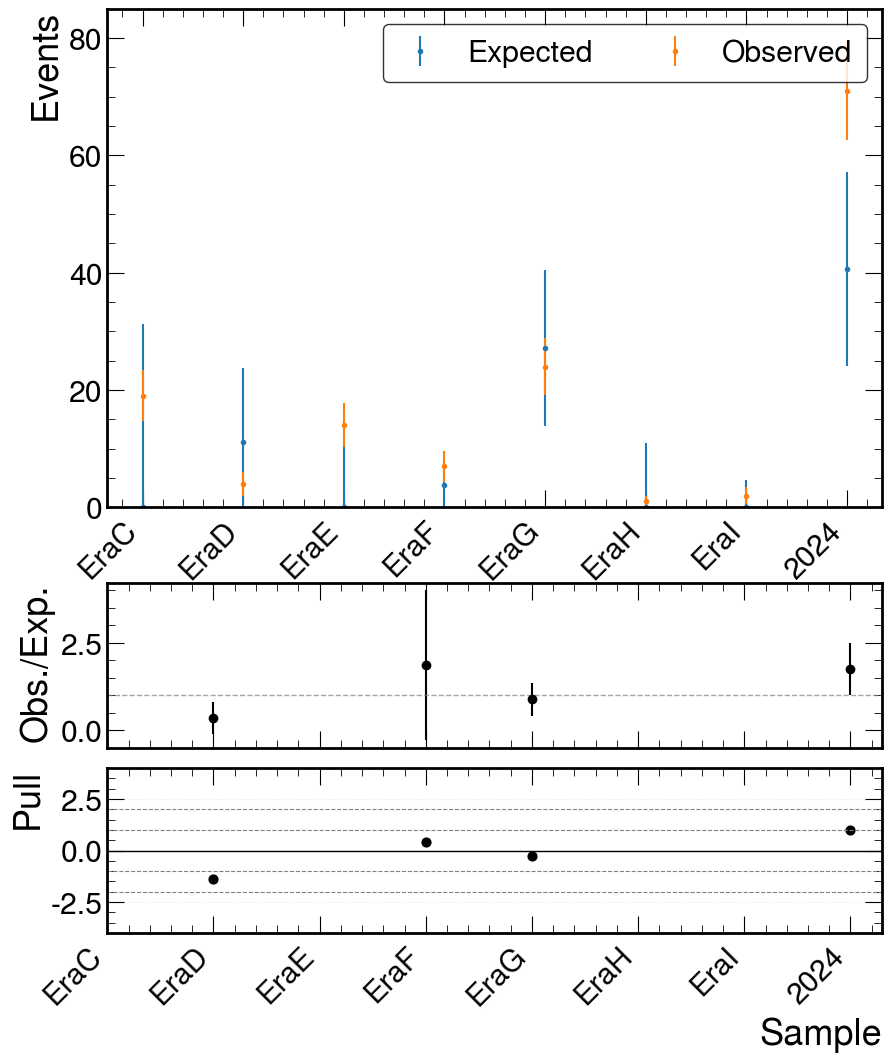

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def create_scatter_plot(ax, x_labels, y_values, y_err, title="Scatter Plot", x_label="Categories", y_label="Values", legend="nominal"):
    """
    Creates a scatter plot with string labels on the x-axis and float values on the y-axis
    
    Args:
        ax: matplotlib axes object
        x_labels (list): List of strings for x-axis labels
        y_values (list): List of floats for y values
        title (str): Title of the plot
        x_label (str): Label for x-axis
        y_label (str): Label for y-axis
    """
    # Check if input lists have the same length
    if len(x_labels) != len(y_values):
        raise ValueError("The lists of x labels and y values must have the same length")
    
    # Create x-coordinates (just numerical positions)
    x_positions = list(range(len(x_labels)))
    ax.errorbar(x_positions, y_values, yerr=y_err, linestyle="none", marker=".", label=legend)
    
    # Set the x-axis ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    
    return x_positions

# Example usage
if __name__ == "__main__":
    # Sample data
    categories = ["EraC", "EraD", "EraE", "EraF", "EraG", "EraH", "EraI", "2024"]
    #300 million events per era
    #expected_values = np.array([221.34, 238, 352.42, 190.19, 787.42, 68.52, 116.58, 1946.01])
    #expected_unc = np.array([44.99, 40.01, 54.37, 31.66, 72.28, 17.22, 24.36, 112.95])
    #observed_values = np.array([229, 257, 369, 220, 905, 65, 111, 2156])
    
    #900 million events per era (4 and 5 track vertices in lowest ntrack control regions)
    #expected_values = np.array([628.84, 889.93, 1104.11, 649.10, 16323.67, 376.05, 569.25, 19677.47])
    #expected_unc = np.array([78.81, 88.35, 106.36, 62.23, 576.04, 49.69, 68.36, 532.16])
    #observed_values = np.array([529, 751, 1105, 663, 15531, 260, 468, 19307])
    
    #900 million events per era (5 track vertices in lowest ntrack control regions)
    #expected_values = np.array([436.38, 670.68, 808.62, 512.12, 13605.98, 262.48, 396.75, 14677.26])
    #expected_unc = np.array([55.35, 67.40, 78.93, 49.64, 492.07, 35.06, 48.20, 404.20])
    #observed_values = np.array([529, 751, 1105, 663, 15531, 260, 468, 19307])
    
    #900 million events per era (5 track vertices in lowest ntrack control regions and exclude run 384323)
    #expected_values = np.array([436.38, 670.68, 808.62, 512.12, 3373.28, 262.48, 396.75, 6347.07])
    #expected_unc = np.array([55.35, 67.40, 78.93, 49.64, 165.63, 35.06, 48.20, 208.91])
    #observed_values = np.array([529, 751, 1105, 663, 3269, 260, 468, 7045])
    
    #900 million events combined extended ABCD(5 track vertices in lowest ntrack control regions and exclude run 384323)
    #expected_values = np.array([438.13068017253585, 641.0530856756895, 876.3009865776487, 612.604557369976, 3152.0480729601645, 305.83655102107053, 376.4074777511745, 6380.031486165605])
    #expected_unc = np.array([58.752108176997226, 66.33723946495101, 87.83037042117034, 57.94806095024737, 159.70372832409433, 41.922846670245384, 48.02532626386008, 215.9922965269059])
    #observed_values = np.array([529.0, 751.0, 1105.0, 663.0, 3269.0, 260.0, 468.0, 7045.0])
    
    #900 million events combined extended ABCD(5 track vertices in lowest ntrack control regions, 6 track vertices in middle and exclude run 384323)
    #expected_values = np.array([458.01778488895667, 695.6864098296026, 928.0550299842295, 643.4094958935843, 3434.9752828761707, 317.71161107614853, 414.83543909163814, 6831.021145959458])
    #expected_unc = np.array([63.778781847356385, 75.00476345542417, 97.12844376506877, 63.12560994192842, 184.1476062491469, 44.95972575778587, 54.73104362878699, 241.90690819814083])
    #observed_values = np.array([529.0, 751.0, 1105.0, 663.0, 3269.0, 260.0, 468.0, 7045.0])
    
    #900 million events ABCD in control regions with signal track selection(excluded runs 384322 and 384323)
    #expected_values = np.array([53.904761904761905, 204.58585858585857, 26.16393442622951, 75.41666666666667, 623.1443298969073, 20.4, 43.31707317073171, 979.3859649122808])
    #expected_unc = np.array([17.278130097016458, 39.09439597608359, 10.583838634588869, 21.768911619952064, 76.71376543930317, 9.10076919826011, 14.656306838068039, 82.19919774497657])
    #observed_values = np.array([47.0, 127.0, 38.0, 37.0, 489.0, 14.0, 20.0, 772.0])
    
    #900 million extended ABCD with 3 to 4 dxy blind (excluded runs 384322 and 384323)
    #expected_values = np.array([32.76974874371859, 11.857160226354083, 0.0, 6.87871080645897, 139.1210543338301, 0.0, 4.156404494382022, 184.71160459840053])
    #expected_unc = np.array([26.45531919719052, 7.819357267933965, 9.056796150932094, 5.315492397368481, 45.14661873774793, 39.80922837706512, 4.79085498097078, 45.87447466885911])
    #observed_values = np.array([42.0, 7.0, 19.0, 9.0, 246.0, 4.0, 2.0, 329.0])
    
    #900 million extended ABCD with 3 to 4 dxy blind online beamspot
    #expected_values = np.array([0.0, 46.05783793135573, 0.0, 3.787217056447826, 33.50408633644326, 0.0, 0.0, 56.15358236478356])
    #expected_unc = np.array([31.282019999999996, 43.813858575894415, 10.993909711964548, 4.138746497451676, 15.1976884414912, 11.052590944272447, 4.312558139534884, 20.508702277803902])
    #observed_values = np.array([19.0, 10.0, 14.0, 7.0, 26.0, 1.0, 2.0, 79.0])
    
    #900 million extended ABCD with 3 to 4 dxy blind online beamspot (4,5 track vertices in lowest ntrack control regions)
    #expected_values = np.array([0.0, 27.88377632219997, 0.0, 7.5431725822176325, 44.911911428197776, 0.0, 0.0, 84.88773946640238])
    #expected_unc = np.array([80.44184132300028, 31.998903207017207, 24.833201479822346, 8.214862463839665, 21.937487241437807, 31.18746462706147, 12.728401119402985, 34.381973992374355])
    #observed_values = np.array([19.0, 4.0, 14.0, 7.0, 24.0, 1.0, 2.0, 71.0])
    
    #900 million extended ABCD with 3 to 4 dxy blind online beamspot (5 track vertices in lowest ntrack control regions)
    expected_values = np.array([0.0, 11.060399276351289, 0.0, 3.7779911927293175, 27.183487426575006, 0.0, 0.0, 40.61808580078276])
    expected_unc = np.array([31.282019999999996, 12.755822476067944, 10.993909711964548, 4.128659147726412, 13.34056712296363, 11.01847800925926, 4.722053571428572, 16.507512812480154])
    observed_values = np.array([19.0, 4.0, 14.0, 7.0, 24.0, 1.0, 2.0, 71.0])
    
    # Create figure
    fig = plt.figure(figsize=(10, 12))
    
    # Use subplot2grid for more control over spacing
    # Grid is (100 rows, 1 column) for fine-grained control
    ax1 = plt.subplot2grid((100, 1), (0, 0), rowspan=54, fig=fig)     # Top plot: rows 0-53
    ax2 = plt.subplot2grid((100, 1), (62, 0), rowspan=18, fig=fig)   # Middle plot: rows 62-79 (gap from 54-61)
    ax3 = plt.subplot2grid((100, 1), (82, 0), rowspan=18, fig=fig)   # Bottom plot: rows 82-99 (small gap 80-81)
    
    # Top subplot: original scatter plot
    x_pos = create_scatter_plot(ax1, categories, expected_values,expected_unc ,"", "Sample", "Events", legend="Expected")
    create_scatter_plot(ax1, categories, observed_values,np.sqrt(observed_values), "", "Sample", "Events", legend="Observed")
    
    # Add legend to top subplot
    leg = ax1.legend(frameon=True, ncol=2)
    leg.get_frame().set_edgecolor('black')
    
    # Calculate ratios
    ratios = observed_values / expected_values
    
    # Calculate uncertainty in ratio using error propagation
    # For ratio R = O/E with errors sqrt(O) and sqrt(E):
    # δR/R = sqrt((δO/O)² + (δE/E)²) = sqrt(1/O + 1/E)
    # Therefore: δR = R * sqrt(1/O + 1/E)
    ratio_errors = ratios * np.sqrt(1/observed_values + (expected_unc/expected_values)**2)
    ax1.set_ylim(0,None)
    # Middle subplot: ratio plot
    ax2.errorbar(x_pos, ratios, yerr=ratio_errors, linestyle="none", marker="o", color='black', markersize=6)
    
    # Add horizontal line at ratio = 1
    ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    # Set labels for ratio plot
    ax2.set_xlabel("")  # No x-label for middle plot since we have bottom plot
    ax2.set_ylabel("Obs./Exp.")
    
    # Set x-axis ticks and labels (but hide labels since they'll be on bottom plot)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([])
    
    # Bottom subplot: pull plot (number of sigmas from 1)
    # Calculate pull: (ratio - 1) / uncertainty
    pulls = (ratios - 1) / ratio_errors
    
    # Create pull plot with black dots
    ax3.scatter(x_pos, pulls, color='black', marker='o', s=40)
    
    # Add horizontal lines at ±1σ, ±2σ, and 0
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax3.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
    ax3.axhline(y=-1, color='gray', linestyle='--', linewidth=0.8)
    ax3.axhline(y=2, color='gray', linestyle='--', linewidth=0.8)
    ax3.axhline(y=-2, color='gray', linestyle='--', linewidth=0.8)
    
    # Set labels for pull plot
    ax3.set_xlabel("Sample")
    ax3.set_ylabel("Pull")
    
    # Set x-axis ticks and labels
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(categories, rotation=45, ha='right')
    
    # Set y-axis limits for better visualization
    ax3.set_ylim(-4, 4)
    #ax3.set_xlim(-0.5, len(x_pos)-0.5)
    
    # Add grid to pull plot for easier reading
    ax3.grid(True, axis='y', alpha=0.3)
    
    # Print pull values for reference
    print("Pull values (number of σ from 1):")
    for cat, pull in zip(categories, pulls):
        print(f"{cat}: {pull:+.2f}σ")
    
    # Adjust layout
    plt.tight_layout()
    plt.savefig("ExtendedABCDPerEraBlindedData.pdf")
    plt.show()

In [9]:
#Extended ABCD Background Estimation With New Priority Order
from collections import Counter

bin_namesCustom = ["A","B","C","D","E","F"]

def process_cutflows(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        output[process+"_runNumbersB"] = Counter()  # Track run numbers for region B
        output[process+"_lumiSectionsB"] = Counter()
        tree = file["scoutingTree/objectTree"]

        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_chi2","scoutVert_cosT","runNumber","lumiBlock"]

        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        runNumberCountsB = Counter()  # Local counter for this file
        lumisectionCountsB = Counter()
        
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]
            weights = ak.ones_like(weights)
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            runNumber = batch["runNumber"]
            lumisection = batch["lumiBlock"]
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>4) & (cosT>0) & (dBVErr<0.005) 
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            mask = (ak.num(dBV,axis=1)>0) & (runNumber!=384323) #& (runNumber!=384322)
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            runNumber = runNumber[mask]
            lumisection = lumisection[mask]
            
            ntrackMask = (ntracks>7)
            ntrackMinMask = (ntracks>5)
            chi2Mask = (chi2<3)
            
            #Signal region B
            mask = ntrackMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            runNumberB = runNumber[mask]
            lumisectionB = lumisection[mask]
            weightsB = weights[mask]
            weightSum[1] += ak.sum(weightsB)
            weightSumSquared[1] += ak.sum(weightsB**2)
            
            # Count run numbers for events passing region B
            runNumberB_flat = ak.to_numpy(runNumberB)
            runNumberCountsB.update(runNumberB_flat)
            
            lumisectionB_flat = ak.to_numpy(lumisectionB)
            lumisectionCountsB.update(lumisectionB_flat)
            
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            runNumber = runNumber[~mask]
            
            #Control region D
            mask = ntrackMask & ~chi2Mask
            mask = ak.num(ntracks[mask])>0
            weightsD = weights[mask]
            weightSum[3] += ak.sum(weightsD)
            weightSumSquared[3] += ak.sum(weightsD**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region A
            mask = ~ntrackMask & chi2Mask & ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsA = weights[mask]
            weightSum[0] += ak.sum(weightsA)
            weightSumSquared[0] += ak.sum(weightsA**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region C
            mask = ~ntrackMask & ~chi2Mask & ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsC = weights[mask]
            weightSum[2] += ak.sum(weightsC)
            weightSumSquared[2] += ak.sum(weightsC**2)
            ntrackMask = ntrackMask[~mask]
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region E
            mask = chi2Mask & ~ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsE = weights[mask]
            weightSum[4] += ak.sum(weightsE)
            weightSumSquared[4] += ak.sum(weightsE**2)
            ntrackMinMask = ntrackMinMask[~mask]
            chi2Mask = chi2Mask[~mask]
            weights = weights[~mask]
            ntracks = ntracks[~mask]
            
            #Control region F
            mask = ~chi2Mask & ~ntrackMinMask
            mask = ak.num(ntracks[mask])>0
            weightsF = weights[mask]
            weightSum[5] += ak.sum(weightsF)
            weightSumSquared[5] += ak.sum(weightsF**2)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        output[process+"_runNumbersB"] = runNumberCountsB
        output[process+"_lumiSectionsB"] = lumisectionCountsB
        
    return output

def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for key in result:
                if ((key.endswith("_runNumbersB")) or (key.endswith("_lumiSectionsB"))):
                    # Merge Counter objects
                    if key not in results:
                        results[key] = Counter()
                    results[key].update(result[key])
                elif key not in results:
                    results[key] = result[key]
                else:
                    for cut in result[key]:
                        results[key][cut] = results[key].get(cut, 0) + result[key][cut]

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)

# ... (rest of your existing code for genWeightSumDict, combining, etc.) ...

# Print top 5 run numbers for region B for each signal process
print("\n=== Top 5 Run Numbers in Signal Region B ===")
for process in signalDict.keys():
    key = process + "_runNumbersB"
    if key in customWeights:
        top5 = customWeights[key].most_common(20)
        print(f"\n{process}:")
        for run, count in top5:
            print(f"  Run {run}: {count} events")
            
# Print top 5 LS numbers for region B for each signal process
print("\n=== Top 5 Lumisections in Signal Region B ===")
for process in signalDict.keys():
    key = process + "_lumiSectionsB"
    if key in customWeights:
        top5 = customWeights[key].most_common(10)
        print(f"\n{process}:")
        for ls, count in top5:
            print(f"  LS {ls}: {count} events")

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v24-3to4Dxy-OnlineBS/260305_211345/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v24-3to4Dxy-OnlineBS/260305_211352/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v24-3to4Dxy-OnlineBS/260305_211359/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v24-3to4Dxy-OnlineBS/260305_211415/Run2024G.root


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v24-3to4Dxy-OnlineBS/260305_211423/Run2024H.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v24-3to4Dxy-OnlineBS/260305_211407/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v24-3to4Dxy-OnlineBS/260305_211430/Run2024I.root




=== Top 5 Run Numbers in Signal Region B ===

2024C:
  Run 37

Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/tree_run384323_LS8.root


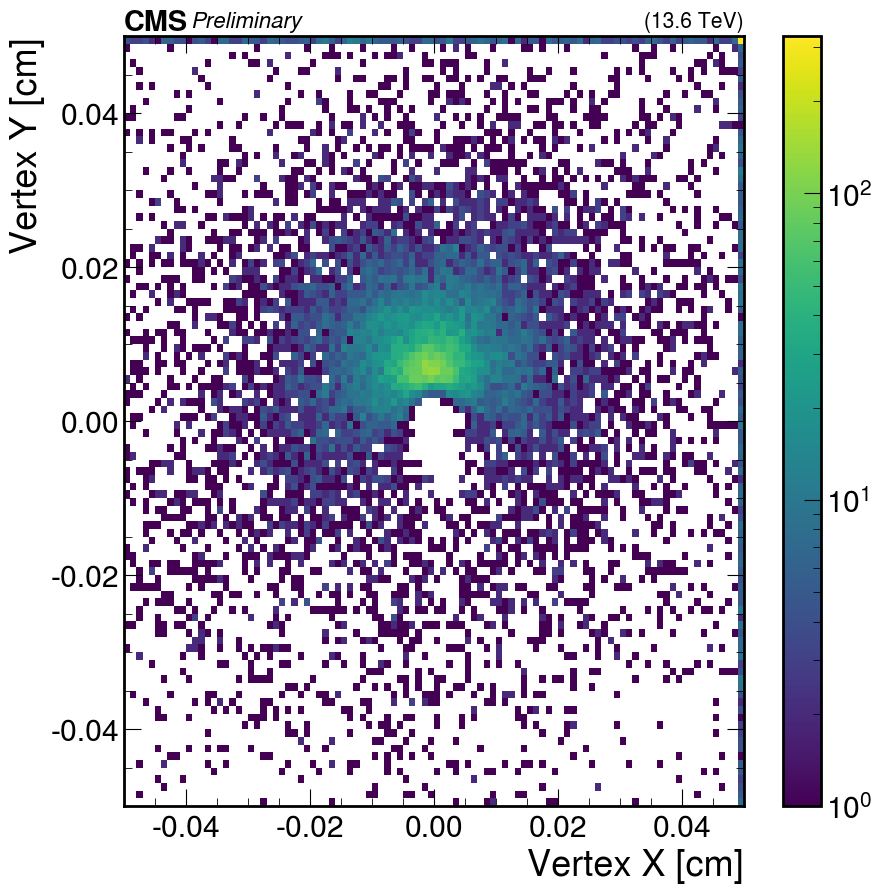

Total runtime: 6.87 seconds


In [14]:
#2D plotting script checking beamspot

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.colors import LogNorm

plotDict = {
    "scoutTrack_dxy": [-0.02,0.02,101], "scoutTrack_phi": [-3.142,3.142,101], "scoutVert_x": [-0.05,0.05,101], "scoutVert_y": [-0.05,0.05,101]
}

x_axis = "scoutVert_x"
y_axis = "scoutVert_y"

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    weightSum = np.zeros((plotDict[x_axis][2]-1,plotDict[y_axis][2]-1))
    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["weight", x_axis, y_axis,"runNumber","lumiBlock"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        nbatches = 0
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            runNumber = batch["runNumber"]
            ls = batch["lumiBlock"]
            #mask = (runNumber!=384323)
            #if(ak.sum(mask)==0): continue
            #nbatches += 1
            #if(nbatches>10): break
            weights = batch["weight"]  # normalize event weights
            #print(runNumber)
            #print(ls)
            x_binning = plotDict[x_axis]
            x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
            x_data = batch[x_axis]

            y_binning = plotDict[y_axis]
            y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
            y_data = batch[y_axis]
            #print(x_data)
            # Apply displacement cut
            #x_data = x_data[mask]
            #print(x_data)
            # Apply displacement cut
            #mask = ak.ones_like(y_data, dtype=bool)
            #y_data = y_data[mask]
            #weights = weights[mask]

            broadcastWeights, x_data = ak.broadcast_arrays(weights,x_data)
            # Apply mask and flatten data
            x_data = ak.flatten(x_data,axis=None)
            x_data = np.clip(x_data,x_bins[0],x_bins[-1])
            y_data = ak.flatten(y_data,axis=None)
            y_data = np.clip(y_data,y_bins[0],y_bins[-1])
            weights_filtered = ak.flatten(broadcastWeights,axis=None)
            # Compute histograms
            n, xedges, yedges = np.histogram2d(x_data,y_data,weights=weights_filtered, bins=(x_bins,y_bins))
            weightSum = weightSum + n
        output["2D"] = {process: weightSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
#for plot in ["2D"]:
#    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]

# **Plotting**
x_binning = plotDict[x_axis]
y_binning = plotDict[y_axis]
x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
data = np.array(sigPlotWeights["2D"]["2024G"]).T
fig, ax = plt.subplots()
plt.pcolormesh(x_bins, y_bins, data, shading='auto', cmap='viridis',norm=LogNorm())
plt.colorbar()
plt.xlabel("Vertex X [cm]")
plt.ylabel("Vertex Y [cm]")
hep.cms.label("Preliminary", loc=0, ax=ax, com=13.6, fontsize=16,data=True)
plt.savefig("beamspot2d_run384323_offlineBeamspot.pdf")
plt.show()
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v24-3to4Dxy-OnlineBS/260305_211345/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v24-3to4Dxy-OnlineBS/260305_211430/Run2024I.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v24-3to4Dxy-OnlineBS/260305_211407/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v24-3to4Dxy-OnlineBS/260305_211352/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v24-3to4Dxy-OnlineBS/260305_211415/Run2024G.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v24-3to4Dxy-OnlineBS/260305_211423/Run2024H.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v24-3to4Dxy-OnlineBS/260305_211359/Run2024E.root






run 384322 average 0.09778183698654175
run 384323 average 0.09

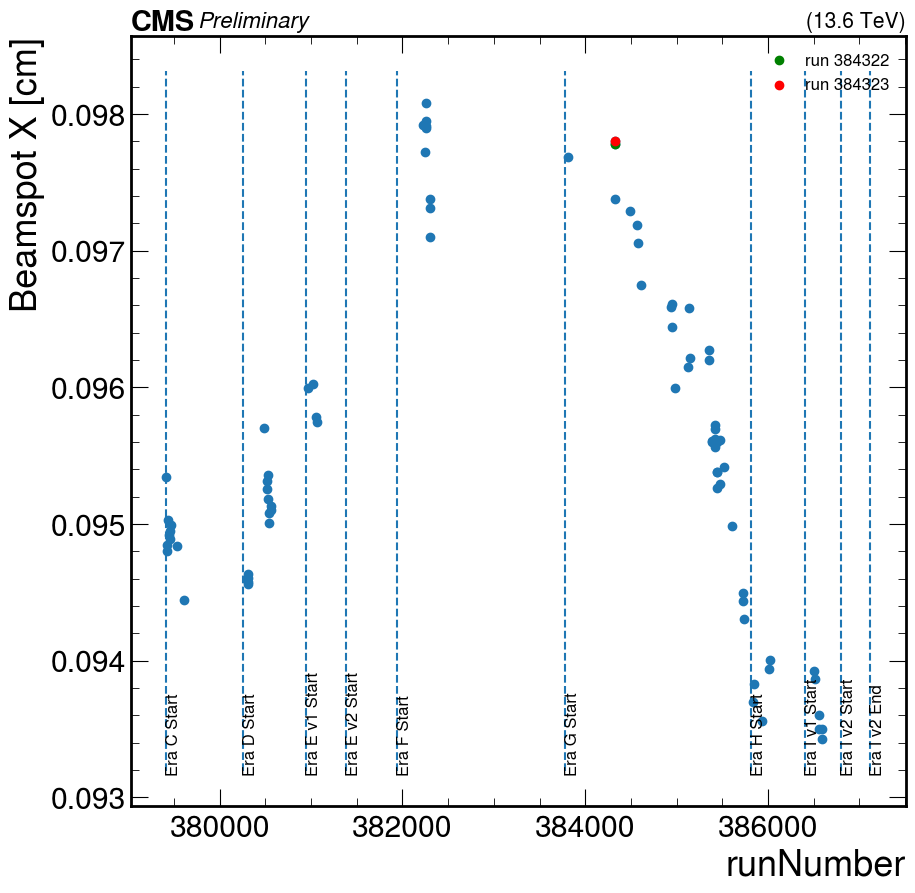

Total runtime: 19.73 seconds


In [8]:
#Scatterplot beamspot position versus lumisection

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.colors import LogNorm

x_axis = "runNumber"
y_axis = "beamspot_x"

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = [x_axis, y_axis,"runNumber"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            #runNumber = batch["runNumber"]
            x_data = batch[x_axis]
            y_data = batch[y_axis]

            #mask = (runNumber==384323)
            #x_data = x_data[mask]
            #y_data = y_data[mask]
            #print(x_data)
            # Apply mask and flatten data
            x_data = ak.flatten(x_data,axis=None)
            y_data = ak.flatten(y_data,axis=None)
            
            for i in range(len(x_data)):
                if x_data[i] not in output:
                    output[x_data[i]] = [y_data[i]]
                else:
                    output[x_data[i]] += [y_data[i]]
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for LS in result:
                if LS not in results:
                    results[LS] = result[LS]
                else:
                    for process in result[LS]:
                        if process not in results[LS]:
                             results[LS][process] = result[LS][process]
                        else:
                            results[LS][process] = results[LS][process] + result[LS][process]

    return results

t0 = time.time()

sigPlotWeights = parallel_processing(signalDict)
EraCStart = 379412
EraDStart = 380253
EraEv1Start = 380948
EraEv2Start = 381384
EraFStart = 381944
EraGStart = 383780
EraHStart = 385814
EraIv1Start = 386409
EraIv2Start = 386798
EraIv2End = 387121
# **Plotting**
x = []
y = []
for key, values in sigPlotWeights.items():
    avg = sum(values) / len(values)
    x += [key]
    y += [avg]
    if(key==384323):
        print("run 384323 average",avg)
        y_run384323 = avg
    if(key==384322):
        print("run 384322 average",avg)
        y_run384322 = avg
fig, ax = plt.subplots()
plt.scatter(x,y)
plt.xlabel(x_axis)
plt.ylabel("Beamspot X [cm]")
plt.scatter(384322,y_run384322,color="green",label="run 384322")
plt.scatter(384323,y_run384323,color="red",label="run 384323")
plt.ticklabel_format(axis='y', useOffset=False)
plt.legend(fontsize=12)
hep.cms.label("Preliminary", loc=0, ax=ax, com=13.6, fontsize=16,data=True)
ybottom, ytop = ax.get_ylim()
plt.vlines(EraCStart,ybottom,ytop,linestyle="--")
plt.text(EraCStart,ybottom,'Era C Start',rotation=90,fontsize=12)
plt.vlines(EraDStart,ybottom,ytop,linestyle="--")
plt.text(EraDStart,ybottom,'Era D Start',rotation=90,fontsize=12)
plt.vlines(EraEv1Start,ybottom,ytop,linestyle="--")
plt.text(EraEv1Start,ybottom,'Era E v1 Start',rotation=90,fontsize=12)
plt.vlines(EraEv2Start,ybottom,ytop,linestyle="--")
plt.text(EraEv2Start,ybottom,'Era E v2 Start',rotation=90,fontsize=12)
plt.vlines(EraFStart,ybottom,ytop,linestyle="--")
plt.text(EraFStart,ybottom,'Era F Start',rotation=90,fontsize=12)
plt.vlines(EraGStart,ybottom,ytop,linestyle="--")
plt.text(EraGStart,ybottom,'Era G Start',rotation=90,fontsize=12)
plt.vlines(EraHStart,ybottom,ytop,linestyle="--")
plt.text(EraHStart,ybottom,'Era H Start',rotation=90,fontsize=12)
plt.vlines(EraIv1Start,ybottom,ytop,linestyle="--")
plt.text(EraIv1Start,ybottom,'Era I v1 Start',rotation=90,fontsize=12)
plt.vlines(EraIv2Start,ybottom,ytop,linestyle="--")
plt.text(EraIv2Start,ybottom,'Era I v2 Start',rotation=90,fontsize=12)
plt.vlines(EraIv2End,ybottom,ytop,linestyle="--")
plt.text(EraIv2End,ybottom,'Era I v2 End',rotation=90,fontsize=12)
plt.savefig("OnlineBSXPosVsRunNumber.pdf")
plt.show()
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v22-2p5to4Dxy-900M/251212_045123/Run2024G.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v22-2p5to4Dxy-900M/251212_045057/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v22-2p5to4Dxy-900M/251212_045033/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v22-2p5to4Dxy-900M/251212_045044/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v22-2p5to4Dxy-900M/251212_045152/Run2024I.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v22-2p5to4Dxy-900M/251212_045111/Run2024F.root



Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v22-2p5to4Dxy-900M/251212_045135/Run2024H.root




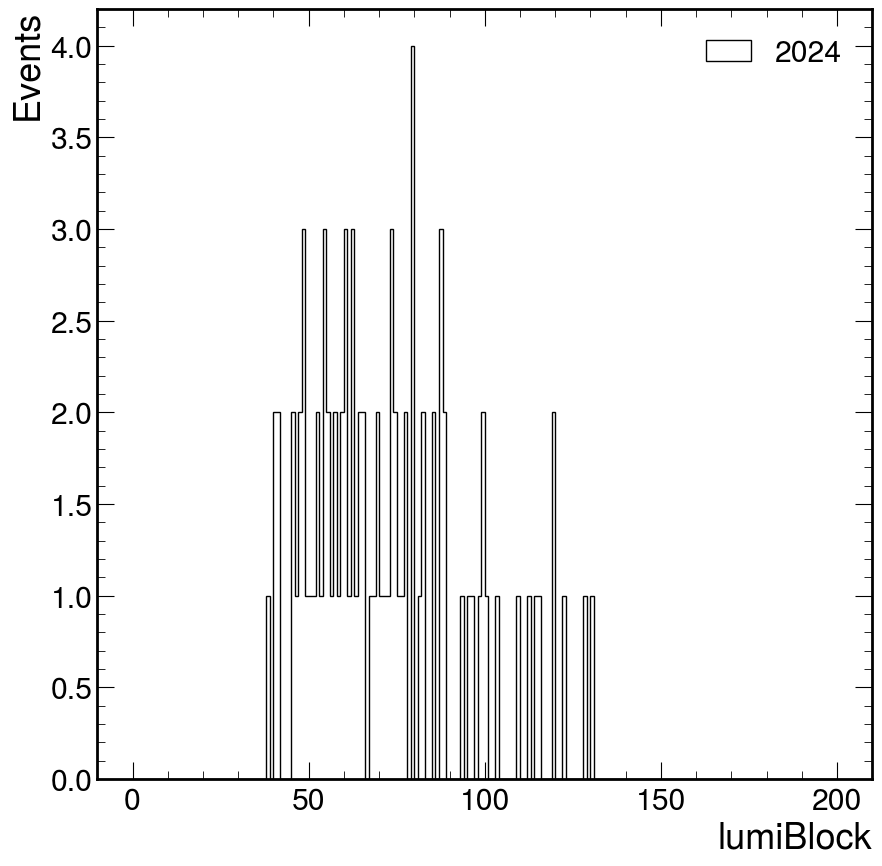

Total runtime: 54.19 seconds


In [40]:
#lumisection plotting script (pu reweighting and jet veto now done while processing, fix gen reweighting in data bug)

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "lumiBlock": [0,200,201]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight","scoutVert_nTracks","scoutVert_dBV","scoutVert_cosT","scoutVert_dBVErr","scoutVert_chi2","runNumber"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                # Apply displacement cut
                dBV = batch["scoutVert_dBV"]
                dBVErr = batch["scoutVert_dBVErr"]
                ntracks = batch["scoutVert_nTracks"]
                chi2 = batch["scoutVert_chi2"]
                cosT = batch["scoutVert_cosT"]
                runNumber = batch["runNumber"]
                weights = batch["weight"]  # normalize event weights
                weights = ak.ones_like(weights)
                if((process in processDict) and (not doWeightSum)): weights = weights / genWeightSum
            
                mask = (dBV>0.01) & (dBV<2.0) & (ntracks>7) & (cosT>0) & (dBVErr<0.005) & (chi2<3)
                dBV = dBV[mask]
                mask = (ak.num(dBV,axis=1)>0) & (runNumber==382255)
                data = data[mask]
                weights = weights[mask]

                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

for plot in plotDict.keys():
    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]

# **Plotting**
for plot, binning in plotDict.items():
    bins = np.linspace(binning[0], binning[1], binning[2])
    fig, ax = plt.subplots()
    colors = {"2024": "black"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        #integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        counts, bins, patches = ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=False, label=signal, bins=bins, histtype="step", color=color)

        #sigValues = sigPlotWeights[plot][signal] #/ integral
        #sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))
        #sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal])

        #ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)

    ax.set_ylabel("Events")
    plt.xlabel(plot)
    ax.legend()
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [41]:
print("counts:",counts)
print("bins:",bins)
index = np.argmax(counts)
print(bins[index])

counts: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 2. 2. 0. 0. 0. 2. 1. 2.
 3. 1. 1. 1. 2. 1. 3. 2. 1. 2. 1. 2. 3. 1. 3. 1. 2. 2. 0. 1. 1. 2. 1. 1.
 1. 3. 2. 1. 1. 2. 0. 4. 0. 1. 2. 0. 0. 2. 0. 3. 2. 0. 0. 0. 0. 1. 0. 1.
 1. 0. 1. 2. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 2.
 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
bins: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73. 

Processing /eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v22-2p5to4Dxy/251208_165029/TTto4Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v22-2p5to4Dxy/251208_165228/TTtoLNu2Q.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-40to70_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-40to70_Tree_v22-2p5to4Dxy/251208_171116/QCD-4Jets_Bin-HT-40to70.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-100to200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-100to200_Tree_v22-2p5to4Dxy/251208_171449/QCD-4Jets_Bin-HT-100to200.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v22-2p5to4Dxy/251208_170933/QCD-4Jets_Bin-HT-800to1000.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_T

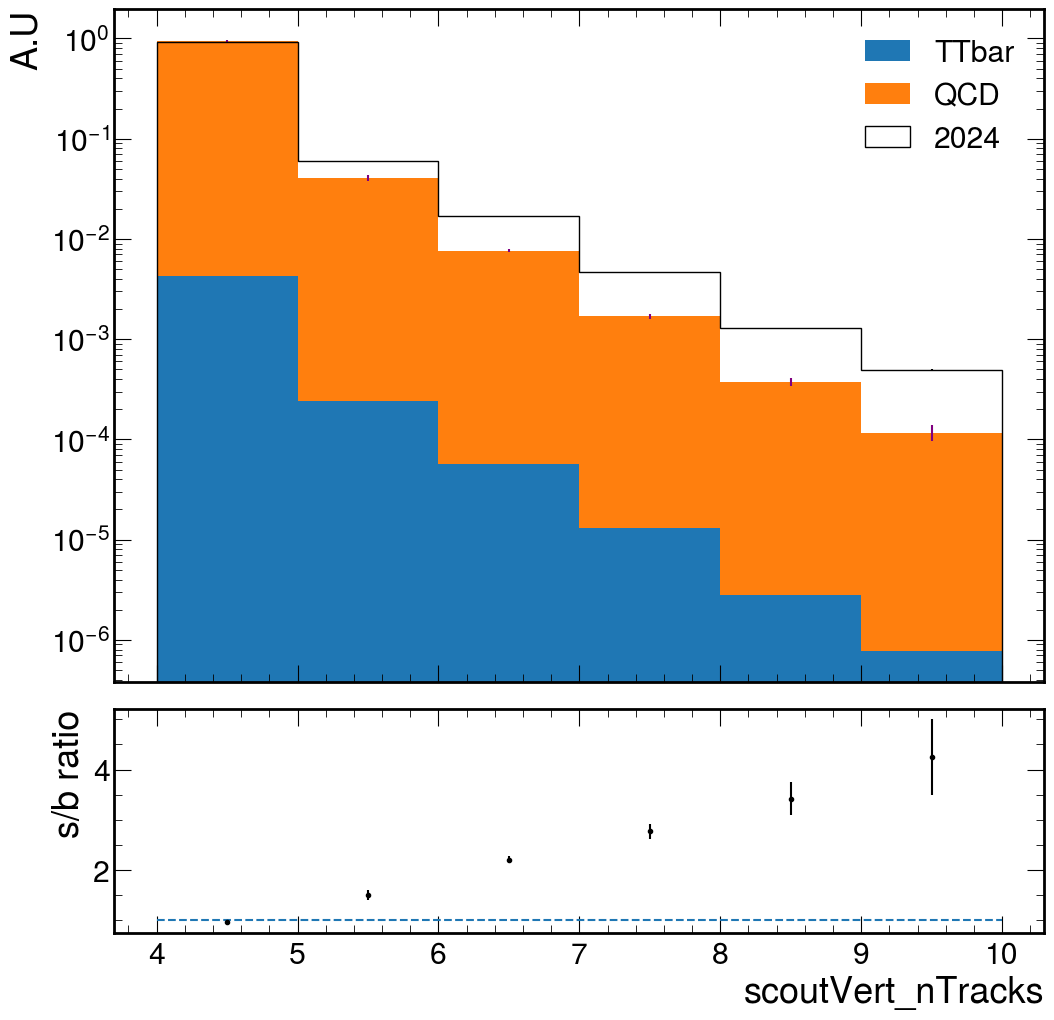

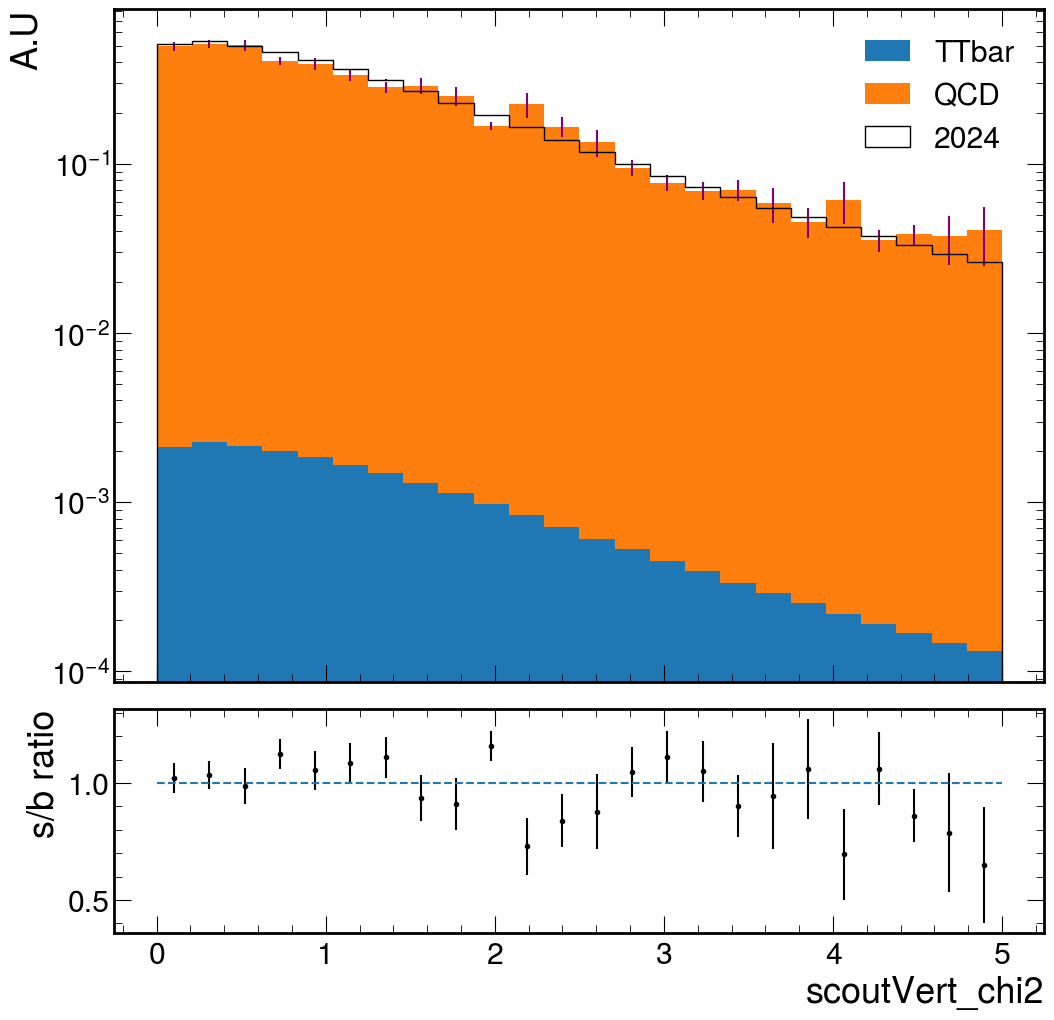

Total runtime: 16.08 seconds


In [16]:
#Updated Branch plotting script

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    #"vertTrack_pt": [0,25,26], "vertTrack_eta": [-3,3,26], "vertTrack_phi": [-3.142,3.142,26],
    #"vertTrack_reducedChi2": [0,7,51], 
    #"vertTrack_dxy": [0,0.3,51], "vertTrack_dxyErr": [0,0.05,51], "vertTrack_dxySig": [2.5,5,51],
    #"vertTrack_dz": [0,0.025,51], "vertTrack_dzErr": [0,0.05,51], "vertTrack_dzSig": [0,500,51],
    #"vertTrack_nValidPixelHits": [0,13,14], #"vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    #"vertTrack_shiftZErr": [0,0.05,51], "vertTrack_shiftZValue": [0,0.05,101],
    #"vertTrack_shift3DErr": [0,0.05,51], "vertTrack_shift3DValue": [0,0.1,101],
    #"scoutVert_dBV": [0,0.5,26],# "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    "scoutVert_nTracks": [4,10,7], "scoutVert_chi2": [0,5,25],
    #"scoutVert_dT": [0,0.5,101], "scoutVert_cosT": [-1,1,101], "scoutVert_pMag": [0,500,101],
    #"scoutTrack_dxy": [0,0.3,51], "scoutTrack_dxyErr": [0,0.05,51], "scoutTrack_dxySig": [2.5,5,51],
    #"scoutTrack_dz": [0,0.025,51], "scoutTrack_dzErr": [0,0.05,51], "scoutTrack_dzSig": [0,500,51],
    #"scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxySig": [0,50,101], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"scoutTrack_pt": [0,200,101],#, "scoutTrack_nValidPixelHits": [0,13,14]
    #"scoutTrack_pt": [0,25,26], "scoutTrack_eta": [-3,3,26], "scoutTrack_phi": [-3.142,3.142,26],
    #"jet_pt": [30,200,26], "jet_eta": [-3,3,26], "jet_phi": [-3.142,3.142,26],
    #"scoutTrack_pt": [12,200,47],
    #"vertTrack_pt": [4,14,11],
    #"jet_pt": [3,12,10]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight", "runNumber","scoutVert_dBV"]
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=40000):  
            weights = batch["weight"]  # normalize event weights
            runNumber = batch["runNumber"]
            mask = (runNumber!=384323)
            weights=weights[mask]
            if((process in processDict) and (not doWeightSum)): weights = weights / genWeightSum
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                # Apply displacement cut
                if "vertTrack" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01) & (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] < 2.0)
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2.0) #& (batch["scoutVert_nTracks"] > 3)
                elif "scoutTrack" in plot:
                    mask = ak.ones_like(data, dtype=bool)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                mask = (runNumber!=384323)
                data = data[mask]
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD40to70"]+bgPlotWeights[plot]["QCD70to100"]+bgPlotWeights[plot]["QCD100to200"]+bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD40to70"]+bgPlotWeights[f"{plot}_squared"]["QCD70to100"]+bgPlotWeights[f"{plot}_squared"]["QCD100to200"]+bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]

for plot in plotDict.keys():
    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]
    sigPlotWeights[f"{plot}_squared"]["2024"] = sigPlotWeights[f"{plot}_squared"]["2024C"]+sigPlotWeights[f"{plot}_squared"]["2024D"]+sigPlotWeights[f"{plot}_squared"]["2024E"]+sigPlotWeights[f"{plot}_squared"]["2024F"]+sigPlotWeights[f"{plot}_squared"]["2024G"]+sigPlotWeights[f"{plot}_squared"]["2024H"]+sigPlotWeights[f"{plot}_squared"]["2024I"]

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"2024": "black"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    #rax.set_yscale("log")
    #rax.set_ylim(0,2)
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Text(1, 0, 'Run Number / 1000')

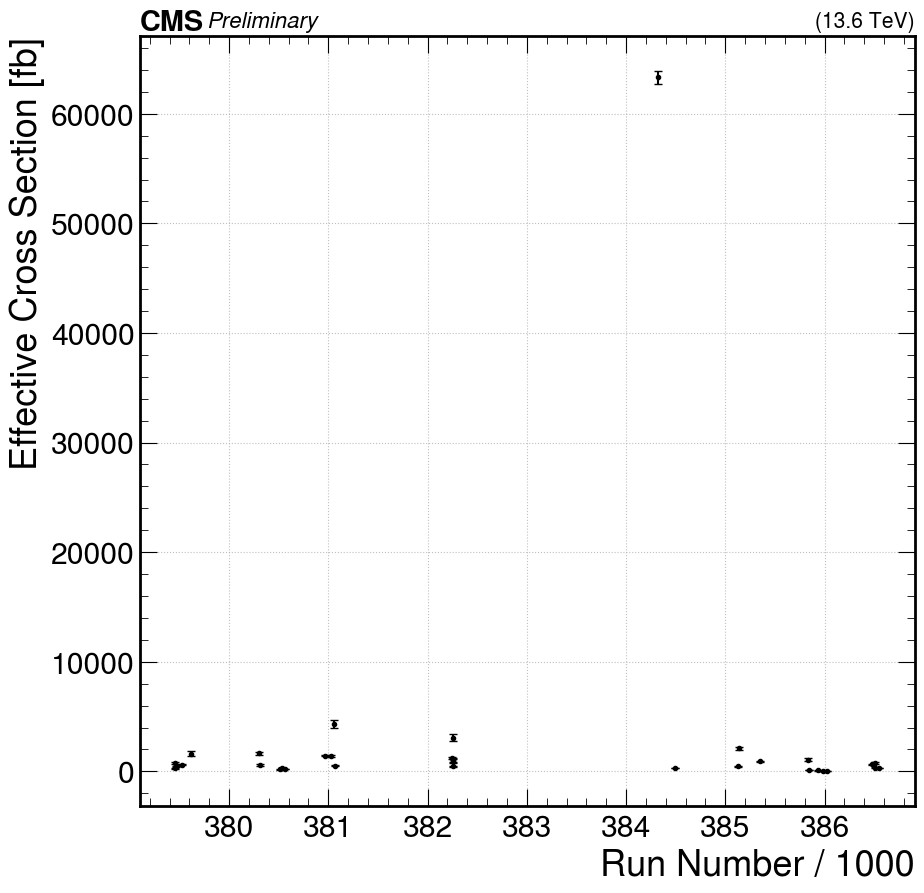

In [39]:
from matplotlib.ticker import ScalarFormatter
with open("runs2024_study.txt") as f:
    lines=f.readlines()
    runNumber = []
    xsec = []
    xsec_err = []
    for line in lines[1:]:
        data = line.split()
        runNumber.append(float(data[0])/1000)
        xsec.append(float(data[1]))
        xsec_err.append(float(data[3]))
fig, ax = plt.subplots()
plt.errorbar(runNumber,xsec,yerr=xsec_err,linestyle="none",marker=".",capsize=3,color="black")
hep.cms.label("Preliminary", loc=0, ax=ax, com=13.6, fontsize=16,data=True)
plt.grid(True)
plt.ylabel("Effective Cross Section [fb]")
plt.xlabel("Run Number / 1000")

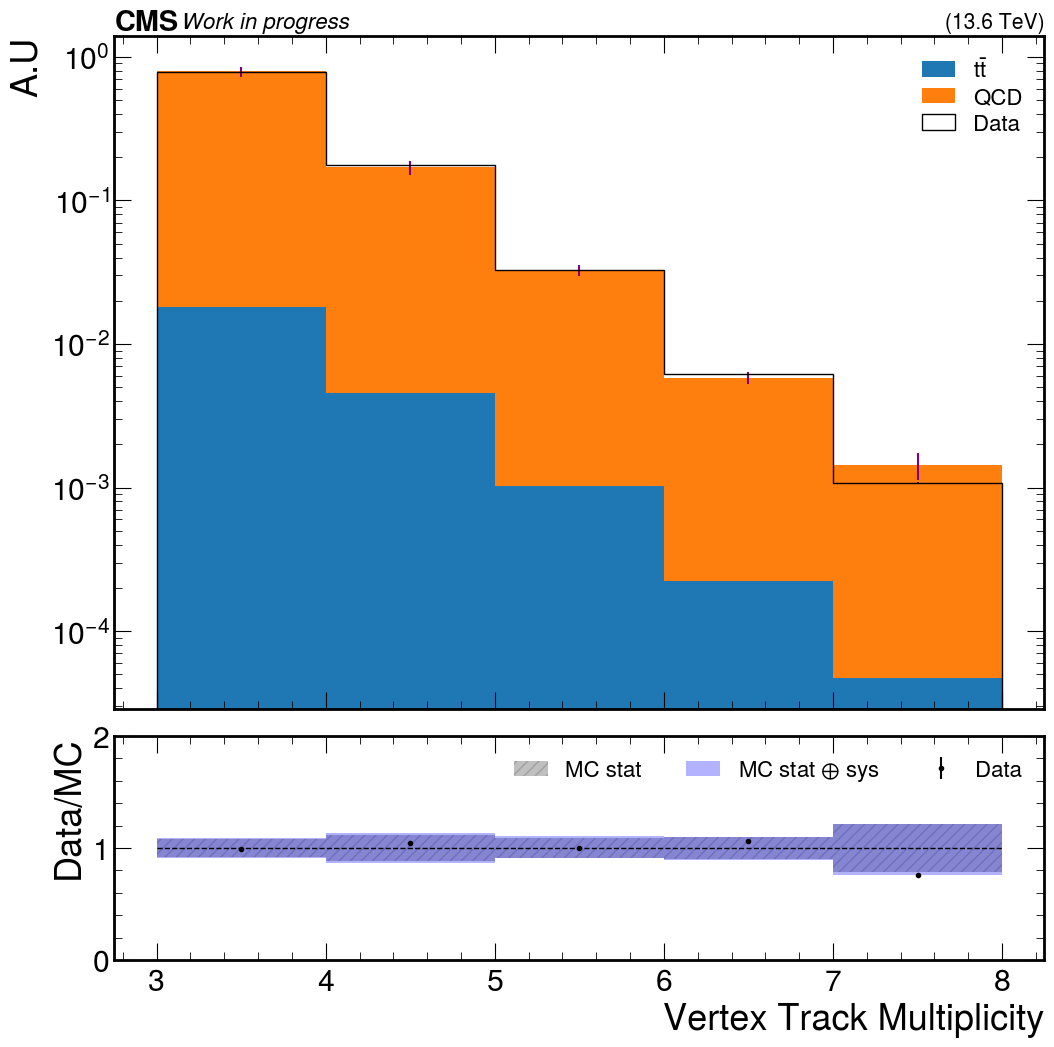

Total runtime: 1004.26 seconds


In [7]:
#Updated Branch plotting script with Systematic Uncertainty

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    #"vertTrack_pt": [0,25,26], "vertTrack_eta": [-3,3,26], "vertTrack_phi": [-3.142,3.142,26],
    #"vertTrack_reducedChi2": [0,7,51], 
    #"vertTrack_dxy": [0,0.3,51], "vertTrack_dxyErr": [0,0.05,51], "vertTrack_dxySig": [2.5,5,51],
    #"vertTrack_dz": [0,0.025,51], "vertTrack_dzErr": [0,0.05,51], "vertTrack_dzSig": [0,500,51],
    #"vertTrack_nValidPixelHits": [0,13,14], #"vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    #"vertTrack_shiftZErr": [0,0.05,51], "vertTrack_shiftZValue": [0,0.05,101],
    #"vertTrack_shift3DErr": [0,0.05,51], "vertTrack_shift3DValue": [0,0.1,101],
    #"scoutVert_dBV": [0,0.5,26],# "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    "scoutVert_nTracks": [3,8,6], #"scoutVert_chi2": [0,5,26],
    #"scoutVert_dT": [0,0.5,101], "scoutVert_cosT": [-1,1,101], "scoutVert_pMag": [0,500,101],
    #"scoutTrack_dxy": [0,0.3,51], "scoutTrack_dxyErr": [0,0.05,51], 
    #"scoutTrack_dxySig": [2,5,26],
    #"scoutTrack_dz": [0,0.025,51], "scoutTrack_dzErr": [0,0.05,51], "scoutTrack_dzSig": [0,500,51],
    #"scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxySig": [0,50,101], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"scoutTrack_pt": [0,200,101],#, "scoutTrack_nValidPixelHits": [0,13,14]
    #"scoutTrack_pt": [0,25,26], "scoutTrack_eta": [-3,3,26], "scoutTrack_phi": [-3.142,3.142,26],
    #"jet_pt": [30,200,26], "jet_eta": [-3,3,26], "jet_phi": [-3.142,3.142,26],
    #"scoutTrack_pt": [7,100,94],
    #"vertTrack_pt": [4,14,11],
    #"jet_pt": [3,12,10]
    #"vertTrack_iJet": [-2,10,13]
    #"vertTrack_hasPFMatch" : [-2,2,5]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "runNumber","scoutVert_dBV","scoutVert_dBVErr","weight","scoutVert_nTracks","scoutTrack_dxySig","scoutTrack_nValidPixelHits","scoutTrack_nValidStripHits","scoutTrack_nTrackerLayersWithMeasurement","scoutTrack_eta","scoutTrack_pt","vertTrack_iJet","scoutTrack_iJet"]
        if(process in processDict):
            branches = branches + ["uncorrectedWeight","weight_PU_BCDEFGHI_nominal", "weight_PU_BCDEFGHI_up", "weight_PU_BCDEFGHI_down","weight_trigger_nominal","weight_trigger_up","weight_trigger_down"] 
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=40000):
            if(process in processDict):
                weights = batch["uncorrectedWeight"] * batch["weight_PU_BCDEFGHI_nominal"] * batch["weight_trigger_nominal"]
                weights_PU_up = batch["uncorrectedWeight"] * batch["weight_PU_BCDEFGHI_up"] * batch["weight_trigger_nominal"]
                weights_PU_down = batch["uncorrectedWeight"] * batch["weight_PU_BCDEFGHI_down"] * batch["weight_trigger_nominal"]
                weights_Trigger_up = batch["uncorrectedWeight"] * batch["weight_PU_BCDEFGHI_nominal"] * batch["weight_trigger_up"]
                weights_Trigger_down = batch["uncorrectedWeight"] * batch["weight_PU_BCDEFGHI_nominal"] * batch["weight_trigger_down"]
            else:
                weights = ak.ones_like(batch["weight"])
            
            runNumber = batch["runNumber"]
            #mask = (runNumber!=384323)
            #weights=weights[mask]
            #if(process in processDict):
            #    weights_PU_up=weights_PU_up[mask]
            #    weights_PU_down=weights_PU_down[mask]
            '''
            dBV = batch["scoutVert_dBV"]
            dBV_masked = dBV[mask]
            mask = (dBV_masked >= 0.01) & (dBV_masked < 2.0) & (batch["scoutVert_nTracks"][mask] > 3)
            dBV_masked = dBV_masked[mask]
            eventMask = (ak.num(dBV_masked,axis=1)>0)
            weights=weights[eventMask]
            if(process in processDict):
                weights_PU_up=weights_PU_up[eventMask]
                weights_PU_down=weights_PU_down[eventMask]
            '''
            if((process in processDict) and (not doWeightSum)): 
                weights = weights / genWeightSum
                weights_PU_up = weights_PU_up / genWeightSum
                weights_PU_down = weights_PU_down / genWeightSum
                weights_Trigger_up = weights_Trigger_up / genWeightSum
                weights_Trigger_down = weights_Trigger_down / genWeightSum
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]
                
                # Apply displacement cut
                if "vertTrack" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.01) & (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] < 2.0) #& (batch["scoutVert_dBVErr"][batch["vertTrack_iVtx"]] < 0.005) & (batch["scoutVert_nTracks"][batch["vertTrack_iVtx"]] > 4)
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.01) & (batch["scoutVert_dBV"] < 2.0) & (batch["scoutVert_nTracks"] < 8)
                elif "scoutTrack" in plot:
                    mask = (batch["scoutTrack_dxySig"] > 4) & (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 2) & (batch["scoutTrack_nValidStripHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5) & (abs(batch["scoutTrack_eta"])<2.4) #& (batch["scoutTrack_iJet"]!=-1)
                    #mask = (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 2) & (batch["scoutTrack_nValidStripHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5) & (abs(batch["scoutTrack_eta"])<2.4)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #data = ak.num(data,axis=1)
                #mask = (runNumber!=384323)
                #data = data[mask]
                #data = data[eventMask]
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                if(process in processDict):
                    broadcastWeights_PU_up, data = ak.broadcast_arrays(weights_PU_up,data)
                    broadcastWeights_PU_down, data = ak.broadcast_arrays(weights_PU_down,data)
                    broadcastWeights_Trigger_up, data = ak.broadcast_arrays(weights_Trigger_up,data)
                    broadcastWeights_Trigger_down, data = ak.broadcast_arrays(weights_Trigger_down,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                if(process in processDict):
                    weights_filtered_PU_up = ak.flatten(broadcastWeights_PU_up,axis=None)
                    weights_filtered_PU_down = ak.flatten(broadcastWeights_PU_down,axis=None)
                    weights_filtered_Trigger_up = ak.flatten(broadcastWeights_Trigger_up,axis=None)
                    weights_filtered_Trigger_down = ak.flatten(broadcastWeights_Trigger_down,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if(process in processDict):
                    n_PU_up, _ = np.histogram(data, weights=weights_filtered_PU_up, bins=bins)
                    n_PU_down, _ = np.histogram(data, weights=weights_filtered_PU_down, bins=bins)
                    n_Trigger_up, _ = np.histogram(data, weights=weights_filtered_Trigger_up, bins=bins)
                    n_Trigger_down, _ = np.histogram(data, weights=weights_filtered_Trigger_down, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                    if(process in processDict):
                        output[f"{plot}_PU_up"] = {process: n_PU_up}
                        output[f"{plot}_PU_down"] = {process: n_PU_down}
                        output[f"{plot}_Trigger_up"] = {process: n_Trigger_up}
                        output[f"{plot}_Trigger_down"] = {process: n_Trigger_down}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
                    if(process in processDict):
                        output[f"{plot}_PU_up"][process] = output[f"{plot}_PU_up"][process] + n_PU_up
                        output[f"{plot}_PU_down"][process] = output[f"{plot}_PU_down"][process] + n_PU_down
                        output[f"{plot}_Trigger_up"][process] = output[f"{plot}_Trigger_up"][process] + n_Trigger_up
                        output[f"{plot}_Trigger_down"][process] = output[f"{plot}_Trigger_down"][process] + n_Trigger_down
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results
'''
t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_PU_up"][process] = bgPlotWeights[f"{plot}_PU_up"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_PU_down"][process] = bgPlotWeights[f"{plot}_PU_down"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_Trigger_up"][process] = bgPlotWeights[f"{plot}_Trigger_up"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_Trigger_down"][process] = bgPlotWeights[f"{plot}_Trigger_down"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD40to70"]+bgPlotWeights[plot]["QCD70to100"]+bgPlotWeights[plot]["QCD100to200"]+bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD40to70"]+bgPlotWeights[f"{plot}_squared"]["QCD70to100"]+bgPlotWeights[f"{plot}_squared"]["QCD100to200"]+bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[f"{plot}_PU_up"]["QCD"] = bgPlotWeights[f"{plot}_PU_up"]["QCD40to70"]+bgPlotWeights[f"{plot}_PU_up"]["QCD70to100"]+bgPlotWeights[f"{plot}_PU_up"]["QCD100to200"]+bgPlotWeights[f"{plot}_PU_up"]["QCD200to400"]+bgPlotWeights[f"{plot}_PU_up"]["QCD400to600"]+bgPlotWeights[f"{plot}_PU_up"]["QCD600to800"]+bgPlotWeights[f"{plot}_PU_up"]["QCD800to1000"]+bgPlotWeights[f"{plot}_PU_up"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_PU_up"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_PU_up"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_PU_up"]["QCD2000"]
    bgPlotWeights[f"{plot}_PU_down"]["QCD"] = bgPlotWeights[f"{plot}_PU_down"]["QCD40to70"]+bgPlotWeights[f"{plot}_PU_down"]["QCD70to100"]+bgPlotWeights[f"{plot}_PU_down"]["QCD100to200"]+bgPlotWeights[f"{plot}_PU_down"]["QCD200to400"]+bgPlotWeights[f"{plot}_PU_down"]["QCD400to600"]+bgPlotWeights[f"{plot}_PU_down"]["QCD600to800"]+bgPlotWeights[f"{plot}_PU_down"]["QCD800to1000"]+bgPlotWeights[f"{plot}_PU_down"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_PU_down"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_PU_down"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_PU_down"]["QCD2000"]
    bgPlotWeights[f"{plot}_Trigger_up"]["QCD"] = bgPlotWeights[f"{plot}_Trigger_up"]["QCD40to70"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD70to100"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD100to200"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD200to400"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD400to600"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD600to800"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD800to1000"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_Trigger_up"]["QCD2000"]
    bgPlotWeights[f"{plot}_Trigger_down"]["QCD"] = bgPlotWeights[f"{plot}_Trigger_down"]["QCD40to70"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD70to100"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD100to200"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD200to400"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD400to600"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD600to800"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD800to1000"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_Trigger_down"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_PU_up"]["TTbar"] = bgPlotWeights[f"{plot}_PU_up"]["TTTo4Q"]+bgPlotWeights[f"{plot}_PU_up"]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_PU_down"]["TTbar"] = bgPlotWeights[f"{plot}_PU_down"]["TTTo4Q"]+bgPlotWeights[f"{plot}_PU_down"]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_Trigger_up"]["TTbar"] = bgPlotWeights[f"{plot}_Trigger_up"]["TTTo4Q"]+bgPlotWeights[f"{plot}_Trigger_up"]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_Trigger_down"]["TTbar"] = bgPlotWeights[f"{plot}_Trigger_down"]["TTTo4Q"]+bgPlotWeights[f"{plot}_Trigger_down"]["TTToLNu2Q"]

for plot in plotDict.keys():
    sigPlotWeights[plot]["2024"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024G"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]
    sigPlotWeights[f"{plot}_squared"]["2024"] = sigPlotWeights[f"{plot}_squared"]["2024C"]+sigPlotWeights[f"{plot}_squared"]["2024D"]+sigPlotWeights[f"{plot}_squared"]["2024E"]+sigPlotWeights[f"{plot}_squared"]["2024F"]+sigPlotWeights[f"{plot}_squared"]["2024G"]+sigPlotWeights[f"{plot}_squared"]["2024H"]+sigPlotWeights[f"{plot}_squared"]["2024I"]
    sigPlotWeights[plot]["CDEFHI"] = sigPlotWeights[plot]["2024C"]+sigPlotWeights[plot]["2024D"]+sigPlotWeights[plot]["2024E"]+sigPlotWeights[plot]["2024F"]+sigPlotWeights[plot]["2024H"]+sigPlotWeights[plot]["2024I"]

'''
# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])
    #bgIntegral = 1

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=[r"$t\bar{t}$","QCD"], bins=bins)

    # Background (MC) values and statistical uncertainties
    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors_stat = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
                            bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors_stat, linestyle="none", color="purple")
    
    # Compute PU systematic uncertainty (asymmetric)
    bg_PU_up = (bgPlotWeights[f"{plot}_PU_up"]["QCD"] / bgIntegral) + (bgPlotWeights[f"{plot}_PU_up"]["TTbar"] / bgIntegral)
    bg_PU_down = (bgPlotWeights[f"{plot}_PU_down"]["QCD"] / bgIntegral) + (bgPlotWeights[f"{plot}_PU_down"]["TTbar"] / bgIntegral)
    
    bg_Trigger_up = (bgPlotWeights[f"{plot}_Trigger_up"]["QCD"] / bgIntegral) + (bgPlotWeights[f"{plot}_Trigger_up"]["TTbar"] / bgIntegral)
    bg_Trigger_down = (bgPlotWeights[f"{plot}_Trigger_down"]["QCD"] / bgIntegral) + (bgPlotWeights[f"{plot}_Trigger_down"]["TTbar"] / bgIntegral)
    
    # Systematic deviations from nominal
    sys_PU_up = bg_PU_up - bgValues
    sys_PU_down = bg_PU_down - bgValues
    
    sys_Trigger_up = bg_Trigger_up - bgValues
    sys_Trigger_down = bg_Trigger_down - bgValues
    
    # Upper error: maximum positive deviation
    bgErrors_sys_PU_up = np.maximum.reduce([sys_PU_up, sys_PU_down, np.zeros_like(bgValues)])
    bgErrors_sys_Trigger_up = np.maximum.reduce([sys_Trigger_up, sys_Trigger_down, np.zeros_like(bgValues)])
    
    # Lower error: maximum negative deviation (take absolute value)
    bgErrors_sys_PU_down = np.abs(np.minimum.reduce([sys_PU_up, sys_PU_down, np.zeros_like(bgValues)]))
    bgErrors_sys_Trigger_down = np.abs(np.minimum.reduce([sys_Trigger_up, sys_Trigger_down, np.zeros_like(bgValues)]))
    
    # Total MC uncertainty (stat ⊕ sys), asymmetric
    bgErrors_total_up = np.sqrt(bgErrors_stat**2 + bgErrors_sys_PU_up**2 + bgErrors_sys_Trigger_up**2)
    bgErrors_total_down = np.sqrt(bgErrors_stat**2 + bgErrors_sys_PU_down**2 + bgErrors_sys_Trigger_down**2)
    
    colors = {"2024": "black"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        #integral = 1
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label="Data", bins=bins, histtype="step", color=color)

        # Signal (Data) values and statistical uncertainties
        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        
        # Ratio with DATA statistical uncertainty only (assuming zero MC uncertainty)
        ratioValues = sigValues / bgValues
        ratioErrors_data = sigErrors / bgValues  # Only data stat uncertainty
        
        # MC relative uncertainties for bands (asymmetric)
        mc_stat_rel = bgErrors_stat / bgValues
        mc_total_rel_up = bgErrors_total_up / bgValues
        mc_total_rel_down = bgErrors_total_down / bgValues
        
        # Create step arrays for proper bin alignment
        bin_edges_step = np.repeat(bins, 2)[1:-1]
        mc_stat_rel_step = np.repeat(mc_stat_rel, 2)
        mc_total_rel_up_step = np.repeat(mc_total_rel_up, 2)
        mc_total_rel_down_step = np.repeat(mc_total_rel_down, 2)
        
        # Plot data points with data stat only
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors_data, 
                    linestyle="none", color=color, marker=".", label="Data", zorder=3)
        
        # Inner band: MC stat only (hatched, symmetric)
        rax.fill_between(bin_edges_step, 1 - mc_stat_rel_step, 1 + mc_stat_rel_step, 
                        alpha=0.5, color='gray', hatch='///', 
                        edgecolor='gray', label='MC stat', linewidth=0, zorder=1)
        
        # Outer band: MC stat ⊕ sys (asymmetric)
        rax.fill_between(bin_edges_step, 1 - mc_total_rel_down_step, 1 + mc_total_rel_up_step,
                        alpha=0.3, color='blue', label='MC stat $\\oplus$ sys', linewidth=0, zorder=2)

    # Calculate maximum value for y-limit
    #max_ratio_data = np.nanmax(ratioValues + ratioErrors_data)
    #max_ratio_band = np.nanmax(1 + mc_total_rel_up)
    #max_ratio = max(max_ratio_data, max_ratio_band)
    
    rax.hlines(1, bins[0], bins[-1], linestyle="dashed", color='black', linewidth=1)
    rax.set_ylabel("Data/MC")
    #rax.set_xlabel(plot)
    if "scoutVert_nTracks" in plot:
        rax.set_xlabel("Vertex Track Multiplicity")
    else:
        rax.set_xlabel(plot)
    rax.legend(fontsize=16,labelspacing=0.25,ncol=3)
    rax.set_ylim(0,2)
    hep.cms.label("Work in progress", loc=0, ax=ax, com=13.6, fontsize=16,data=True)
    ax.set_ylabel("A.U")
    ax.legend(fontsize=16,labelspacing=0.25)
    ax.set_yscale("log")
    
    plt.savefig(f"{plot}_datamc.pdf", bbox_inches='tight')
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024C_Brilcalc.csv
Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024D_Brilcalc.csv
Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024E_Brilcalc.csv
Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024F_Brilcalc.csv
Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024G_Brilcalc.csv
Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024H_Brilcalc.csv
Processing /afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON/2024I_Brilcalc.csv

Parsed 458 unique runs from 7 fil

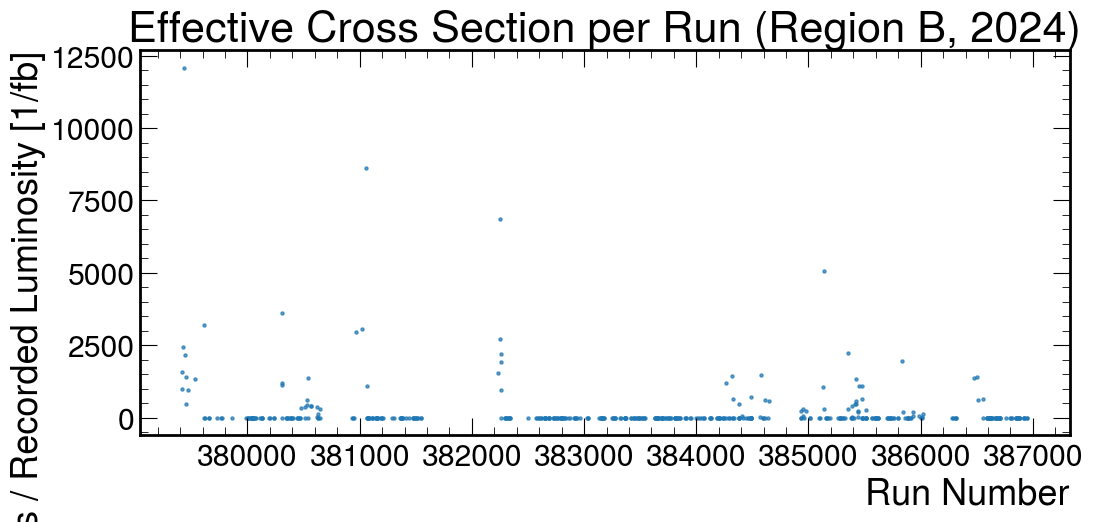

In [30]:
#Read csv from brilcalc and build dictionary of integrated luminosity 
import glob
import os

def parse_lumi_files(file_pattern, lumi_dir):
    """
    Parse luminosity CSV files and build a dictionary of {run: recorded_lumi}.
    Assumes files have two header lines starting with '#', then data lines like:
    379416:9517,04/14/24 17:34:18,195,195,0.042302619,0.039739297
    """
    lumi_by_run = {}
    files = sorted(glob.glob(os.path.join(lumi_dir, file_pattern)))

    if not files:
        print(f"No files found matching '{file_pattern}' in '{lumi_dir}'")
        return lumi_by_run

    for f in files:
        print(f"Processing {f}")
        with open(f, "r") as infile:
            for line in infile:
                line = line.strip().strip("\r")
                if not line or line.startswith("#"):
                    continue
                cols = line.split(",")
                run = int(cols[0].split(":")[0])
                recorded = float(cols[-1])
                lumi_by_run[run] = lumi_by_run.get(run, 0.0) + recorded

    print(f"\nParsed {len(lumi_by_run)} unique runs from {len(files)} files")
    return lumi_by_run

# Adjust the pattern and directory to match your file naming convention
lumi_by_run = parse_lumi_files(file_pattern="2024*_Brilcalc.csv", lumi_dir="/afs/cern.ch/user/r/rmccarth/private/scouting/CMSSW_14_0_18_patch1/src/Run3ScoutingAnalysisTools/GoldenJSON")

#Plot effective cross section (number of signal events / integrated luminosity) per run across all eras
from collections import Counter

def process_cutflows(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process+"_runNumbersB"] = Counter()  # Track run numbers for region B
        tree = file["scoutingTree/objectTree"]

        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight","scoutVert_chi2","scoutVert_cosT","runNumber","lumiBlock"]
        runNumberCountsB = Counter()  # Local counter for this file
        
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]
            weights = ak.ones_like(weights)
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            runNumber = batch["runNumber"]
            lumisection = batch["lumiBlock"]
            
            mask = (dBV>0.01) & (dBV<2.0) & (ntracks>4) & (cosT>0) & (dBVErr<0.005) 
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            mask = (ak.num(dBV,axis=1)>0) & (runNumber!=384323) #& (runNumber!=384322)
            weights = weights[mask]
            ntracks = ntracks[mask]
            chi2 = chi2[mask]
            runNumber = runNumber[mask]
            lumisection = lumisection[mask]
            
            ntrackMask = (ntracks>7)
            ntrackMinMask = (ntracks>5)
            chi2Mask = (chi2<3)
            
            #Signal region B
            mask = ntrackMask & chi2Mask
            mask = ak.num(ntracks[mask])>0
            runNumberB = runNumber[mask]
            lumisectionB = lumisection[mask]
            weightsB = weights[mask]
            
            # Count run numbers for events passing region B
            runNumberB_flat = ak.to_numpy(runNumberB)
            runNumberCountsB.update(runNumberB_flat)
            
        output[process+"_runNumbersB"] = runNumberCountsB        
    return output

def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for key in result:
                # Merge Counter objects
                if key not in results:
                    results[key] = Counter()
                results[key].update(result[key])

    return results

dict = signalDict | processDict
customWeights = parallel_processing(dict)

customWeights["2024_runNumbersB"] = customWeights["2024C_runNumbersB"]+customWeights["2024D_runNumbersB"]+customWeights["2024E_runNumbersB"]+customWeights["2024F_runNumbersB"]+customWeights["2024G_runNumbersB"]+customWeights["2024H_runNumbersB"]+customWeights["2024I_runNumbersB"]

# Build arrays of run number and effective cross section (counts / lumi)
runs = []
xsec = []

for run, lumi in lumi_by_run.items():
    runs.append(run)
    if run in customWeights["2024_runNumbersB"]:
        xsec.append(customWeights["2024_runNumbersB"][run] / lumi)
    else:
        xsec.append(0)

runs = np.array(runs)
xsec = np.array(xsec)

# Sort by run number for cleaner plotting
order = np.argsort(runs)
runs = runs[order]
xsec = xsec[order]

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(runs, xsec, s=5, alpha=0.7)
ax.set_xlabel("Run Number")
ax.set_ylabel("Counts / Recorded Luminosity [1/fb]")
ax.set_title("Effective Cross Section per Run (Region B, 2024)")
ax.ticklabel_format(axis="x", style="plain")
plt.show()


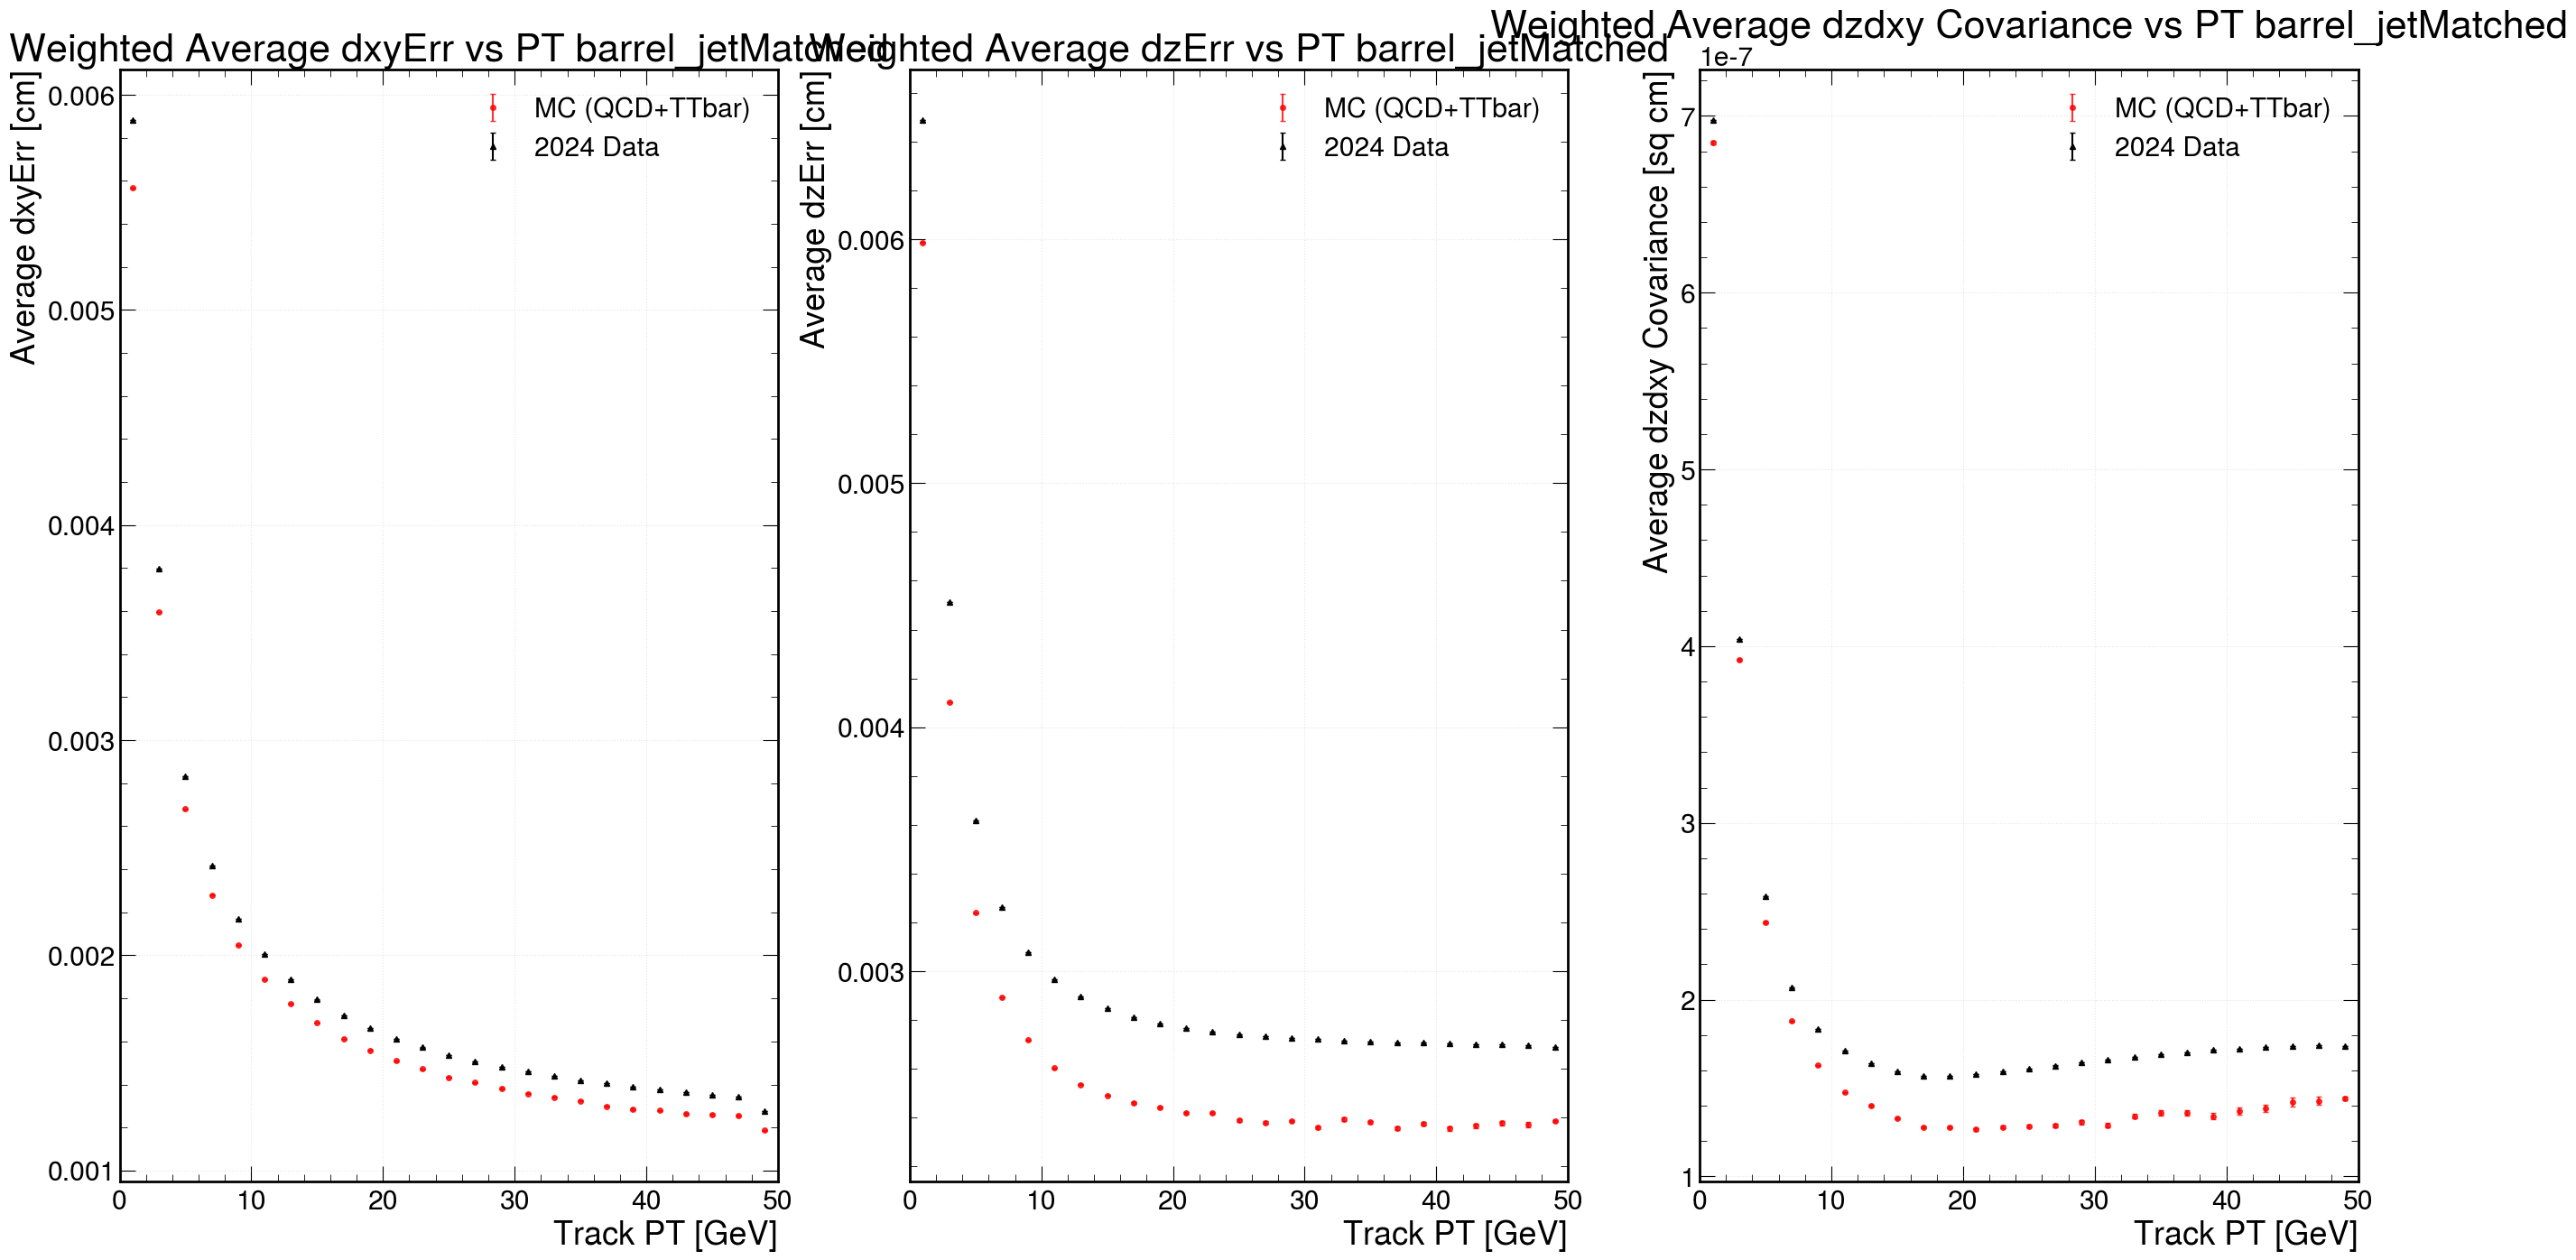

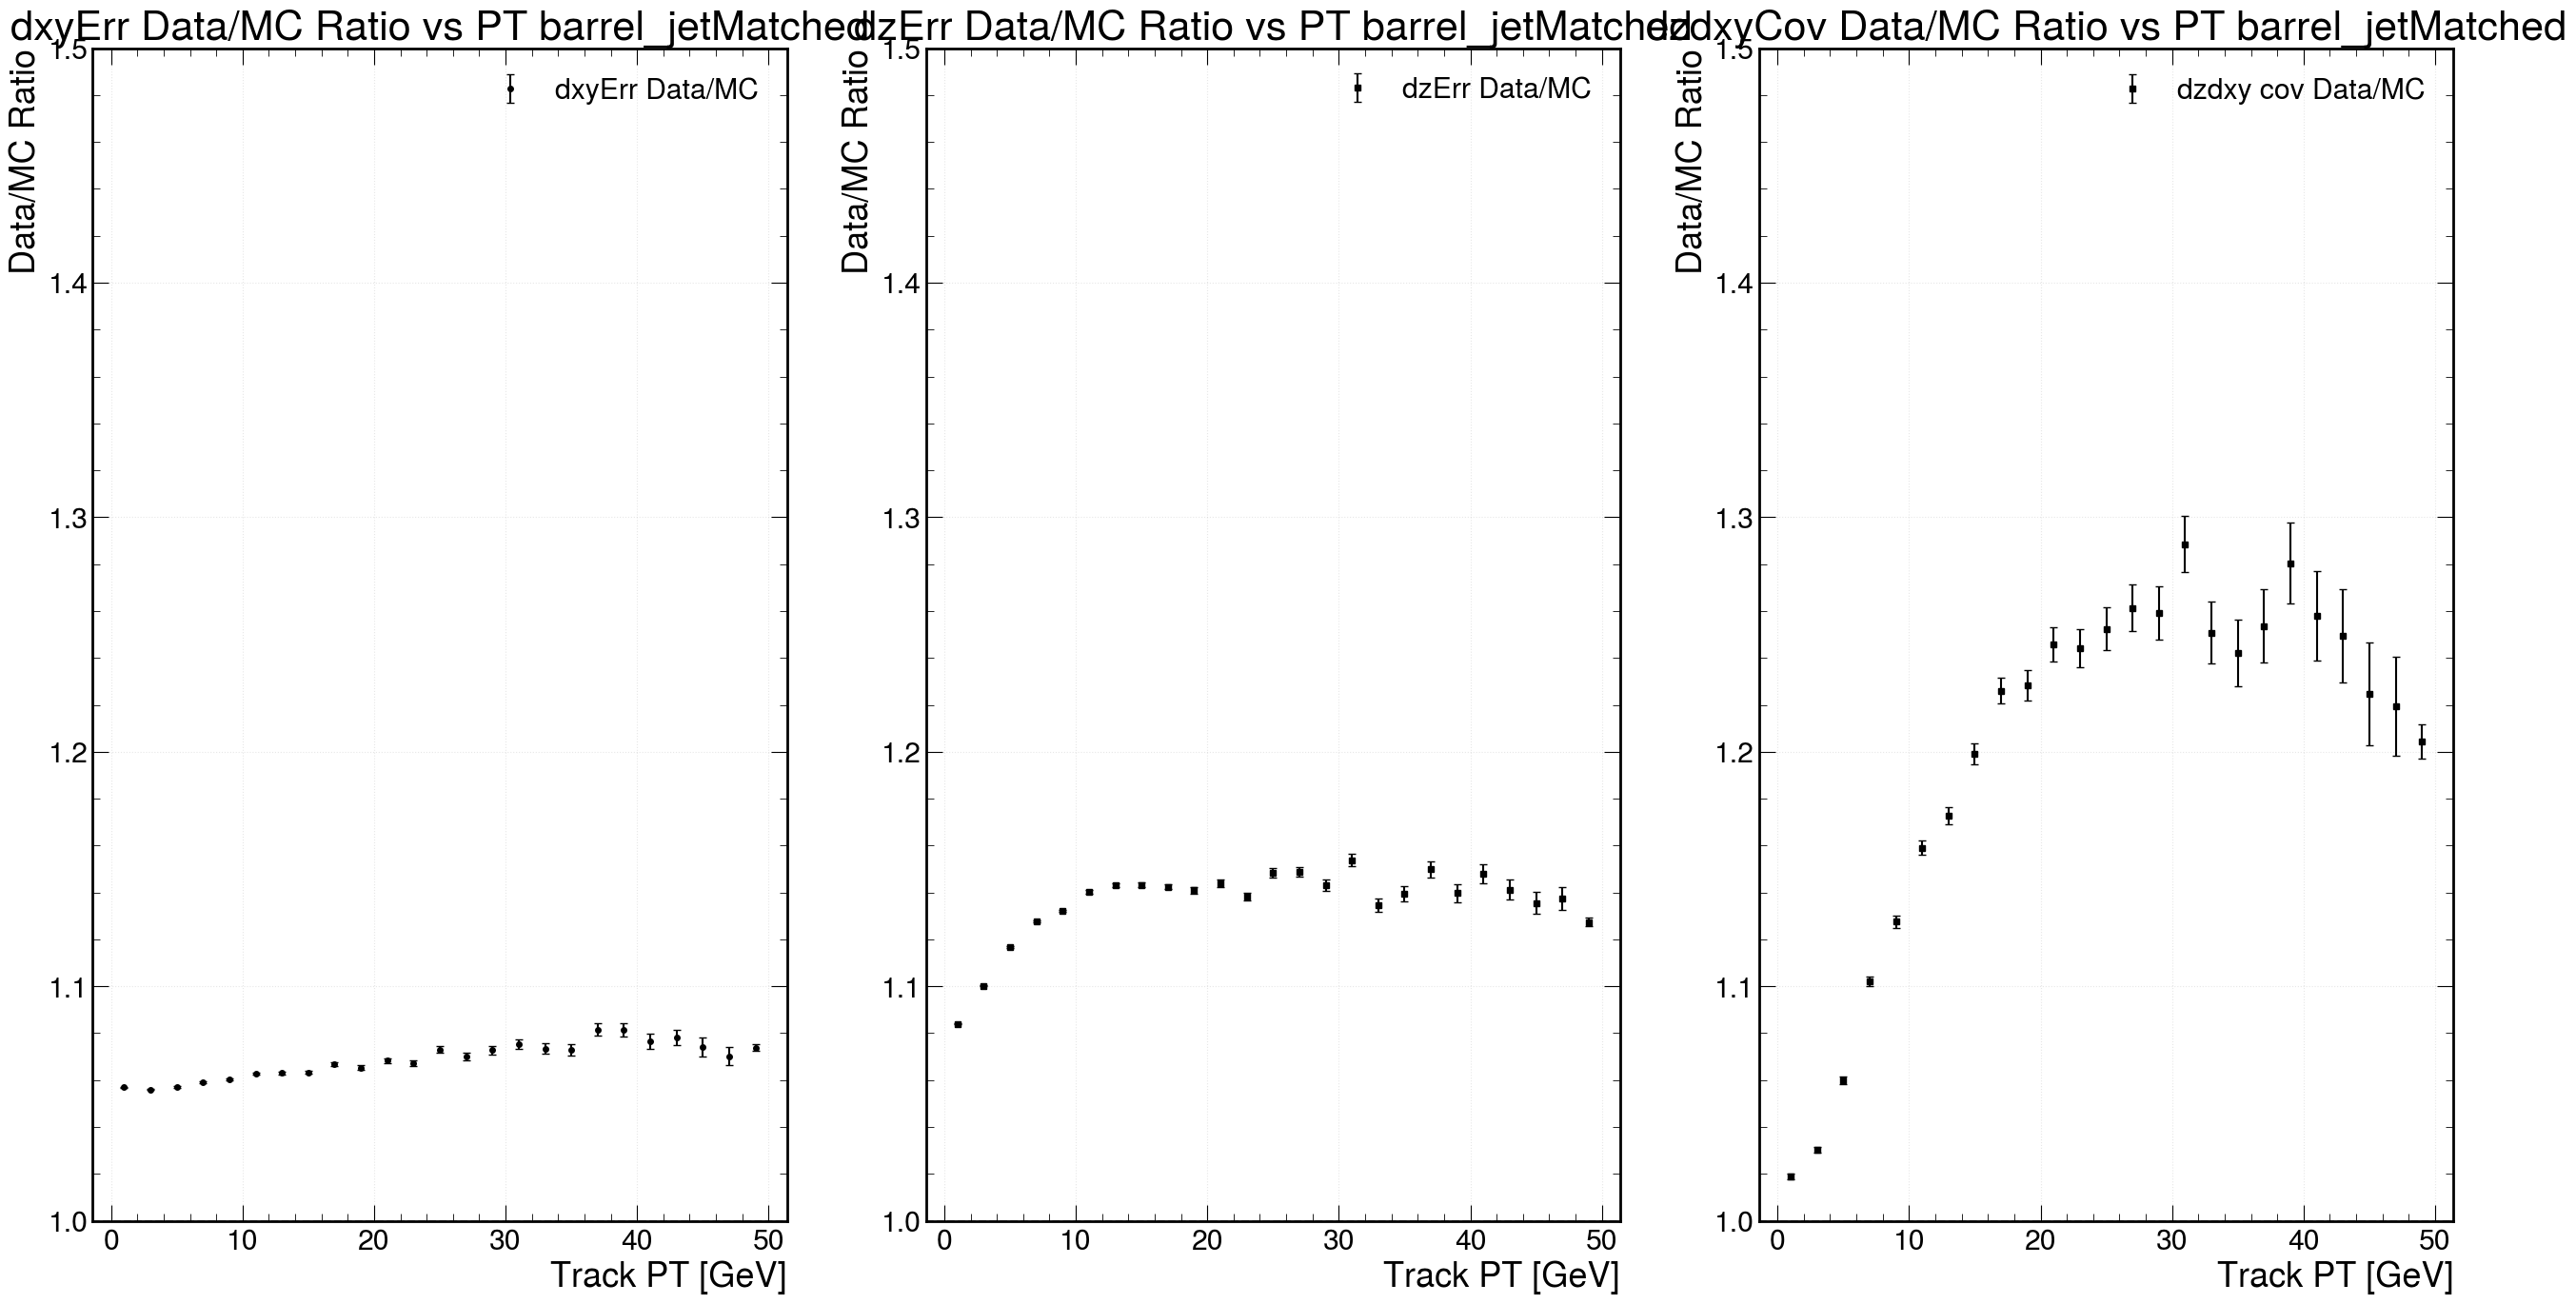

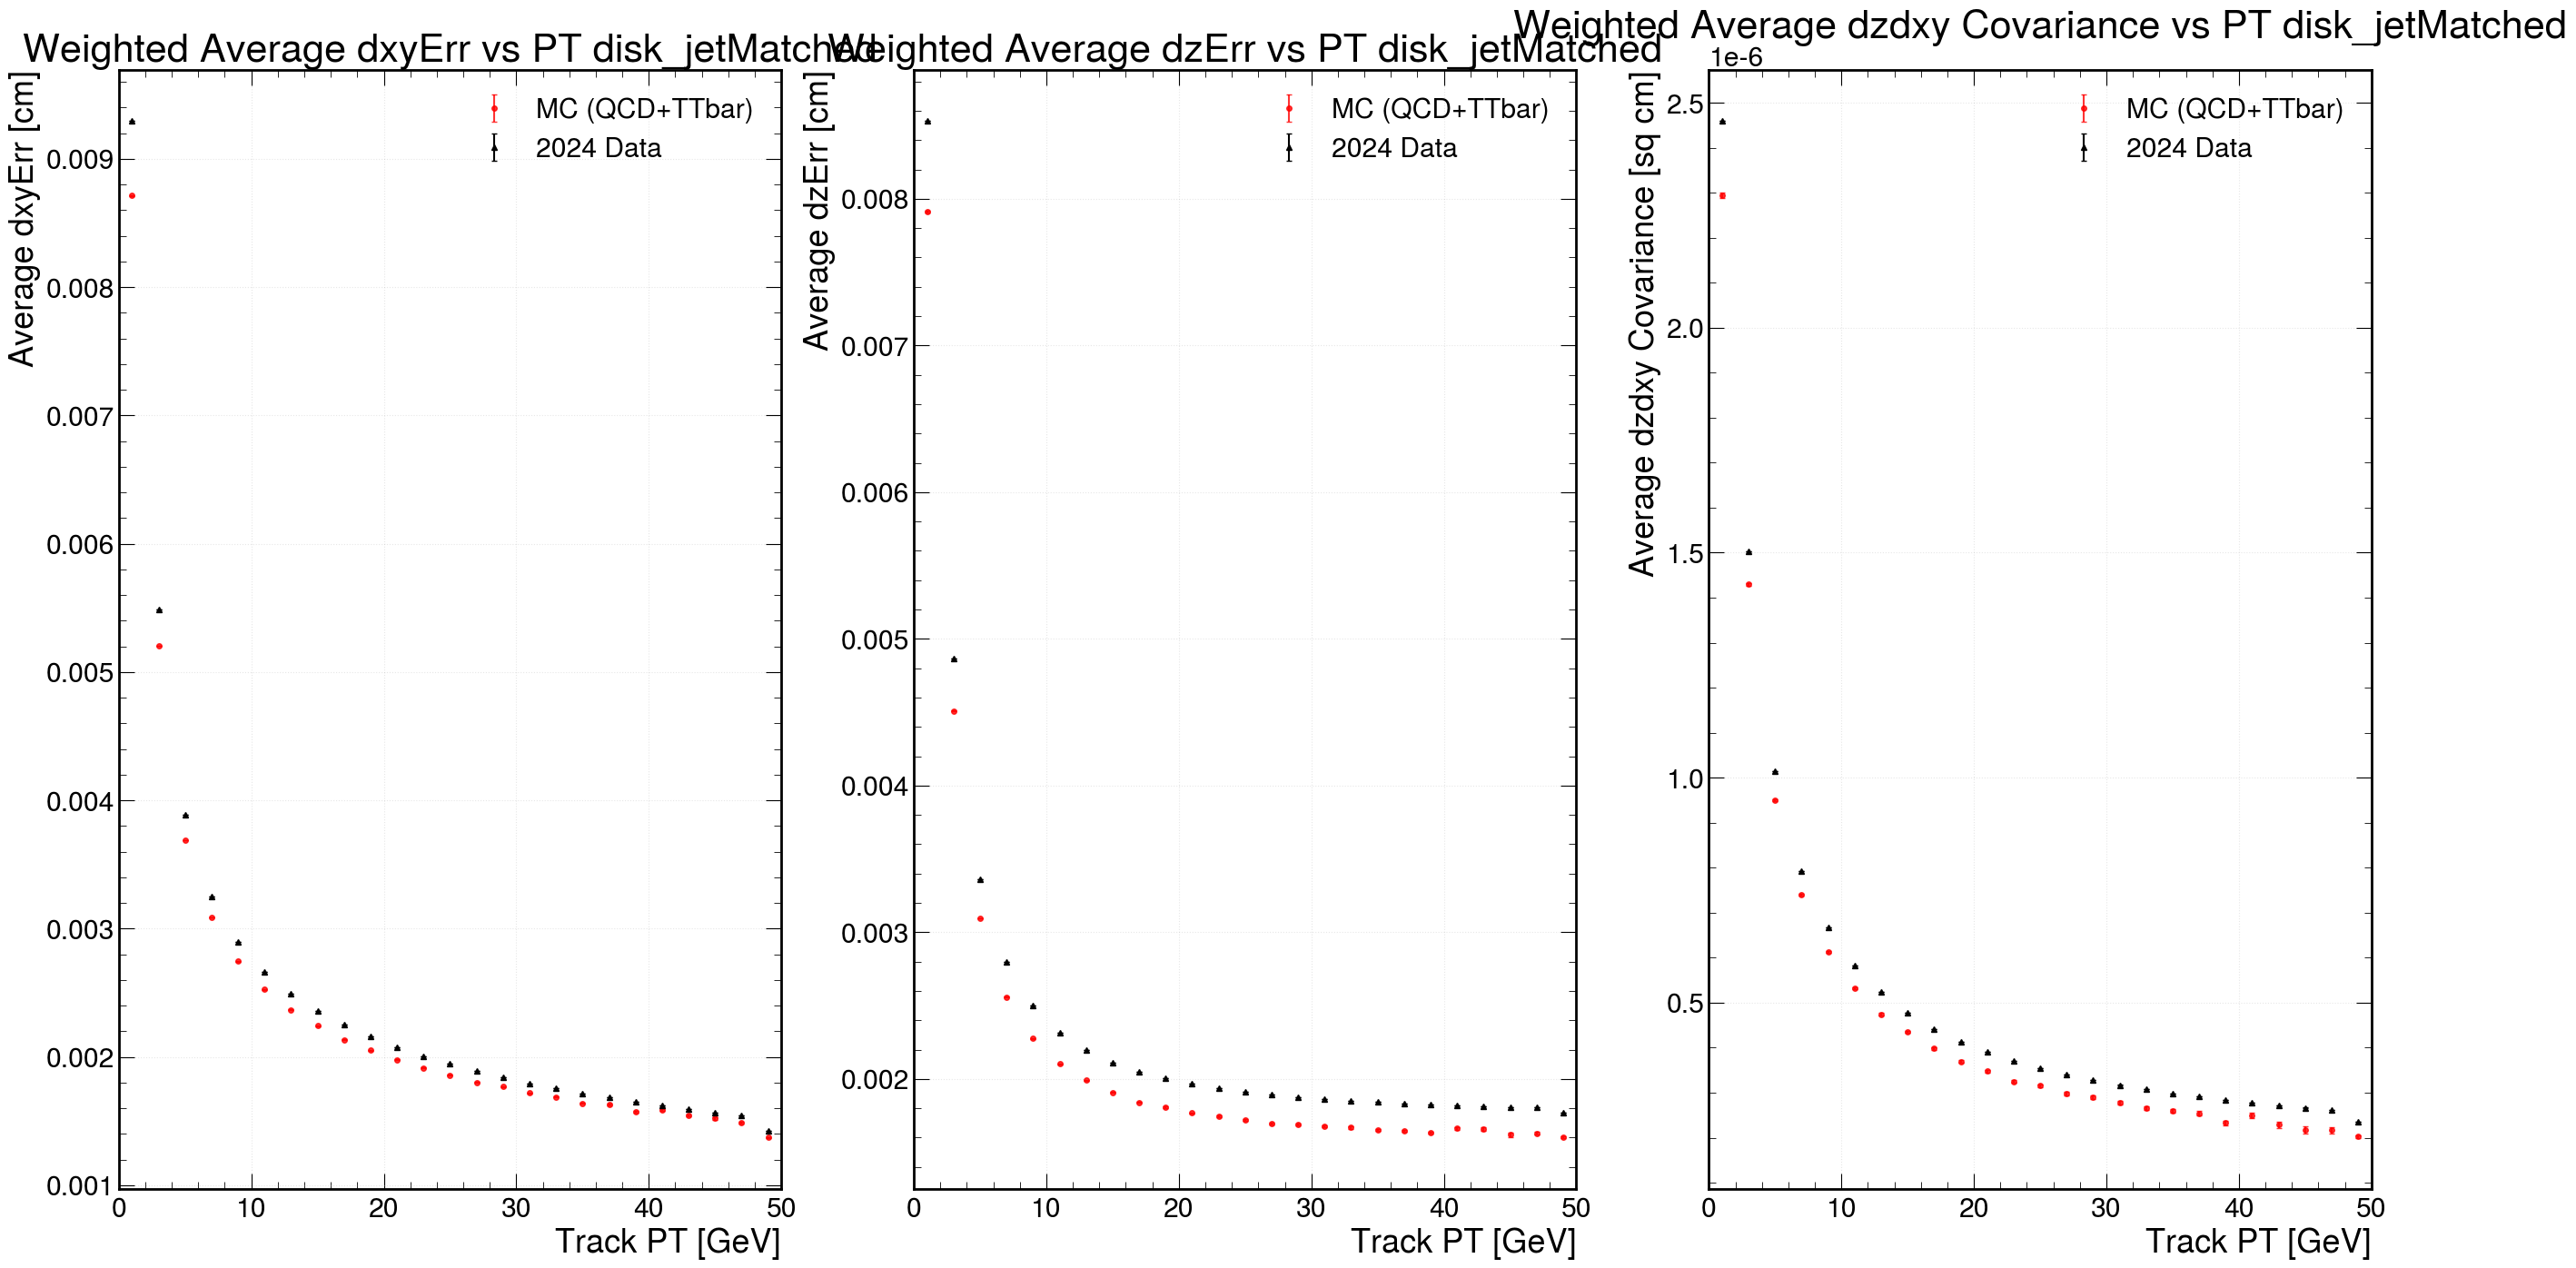

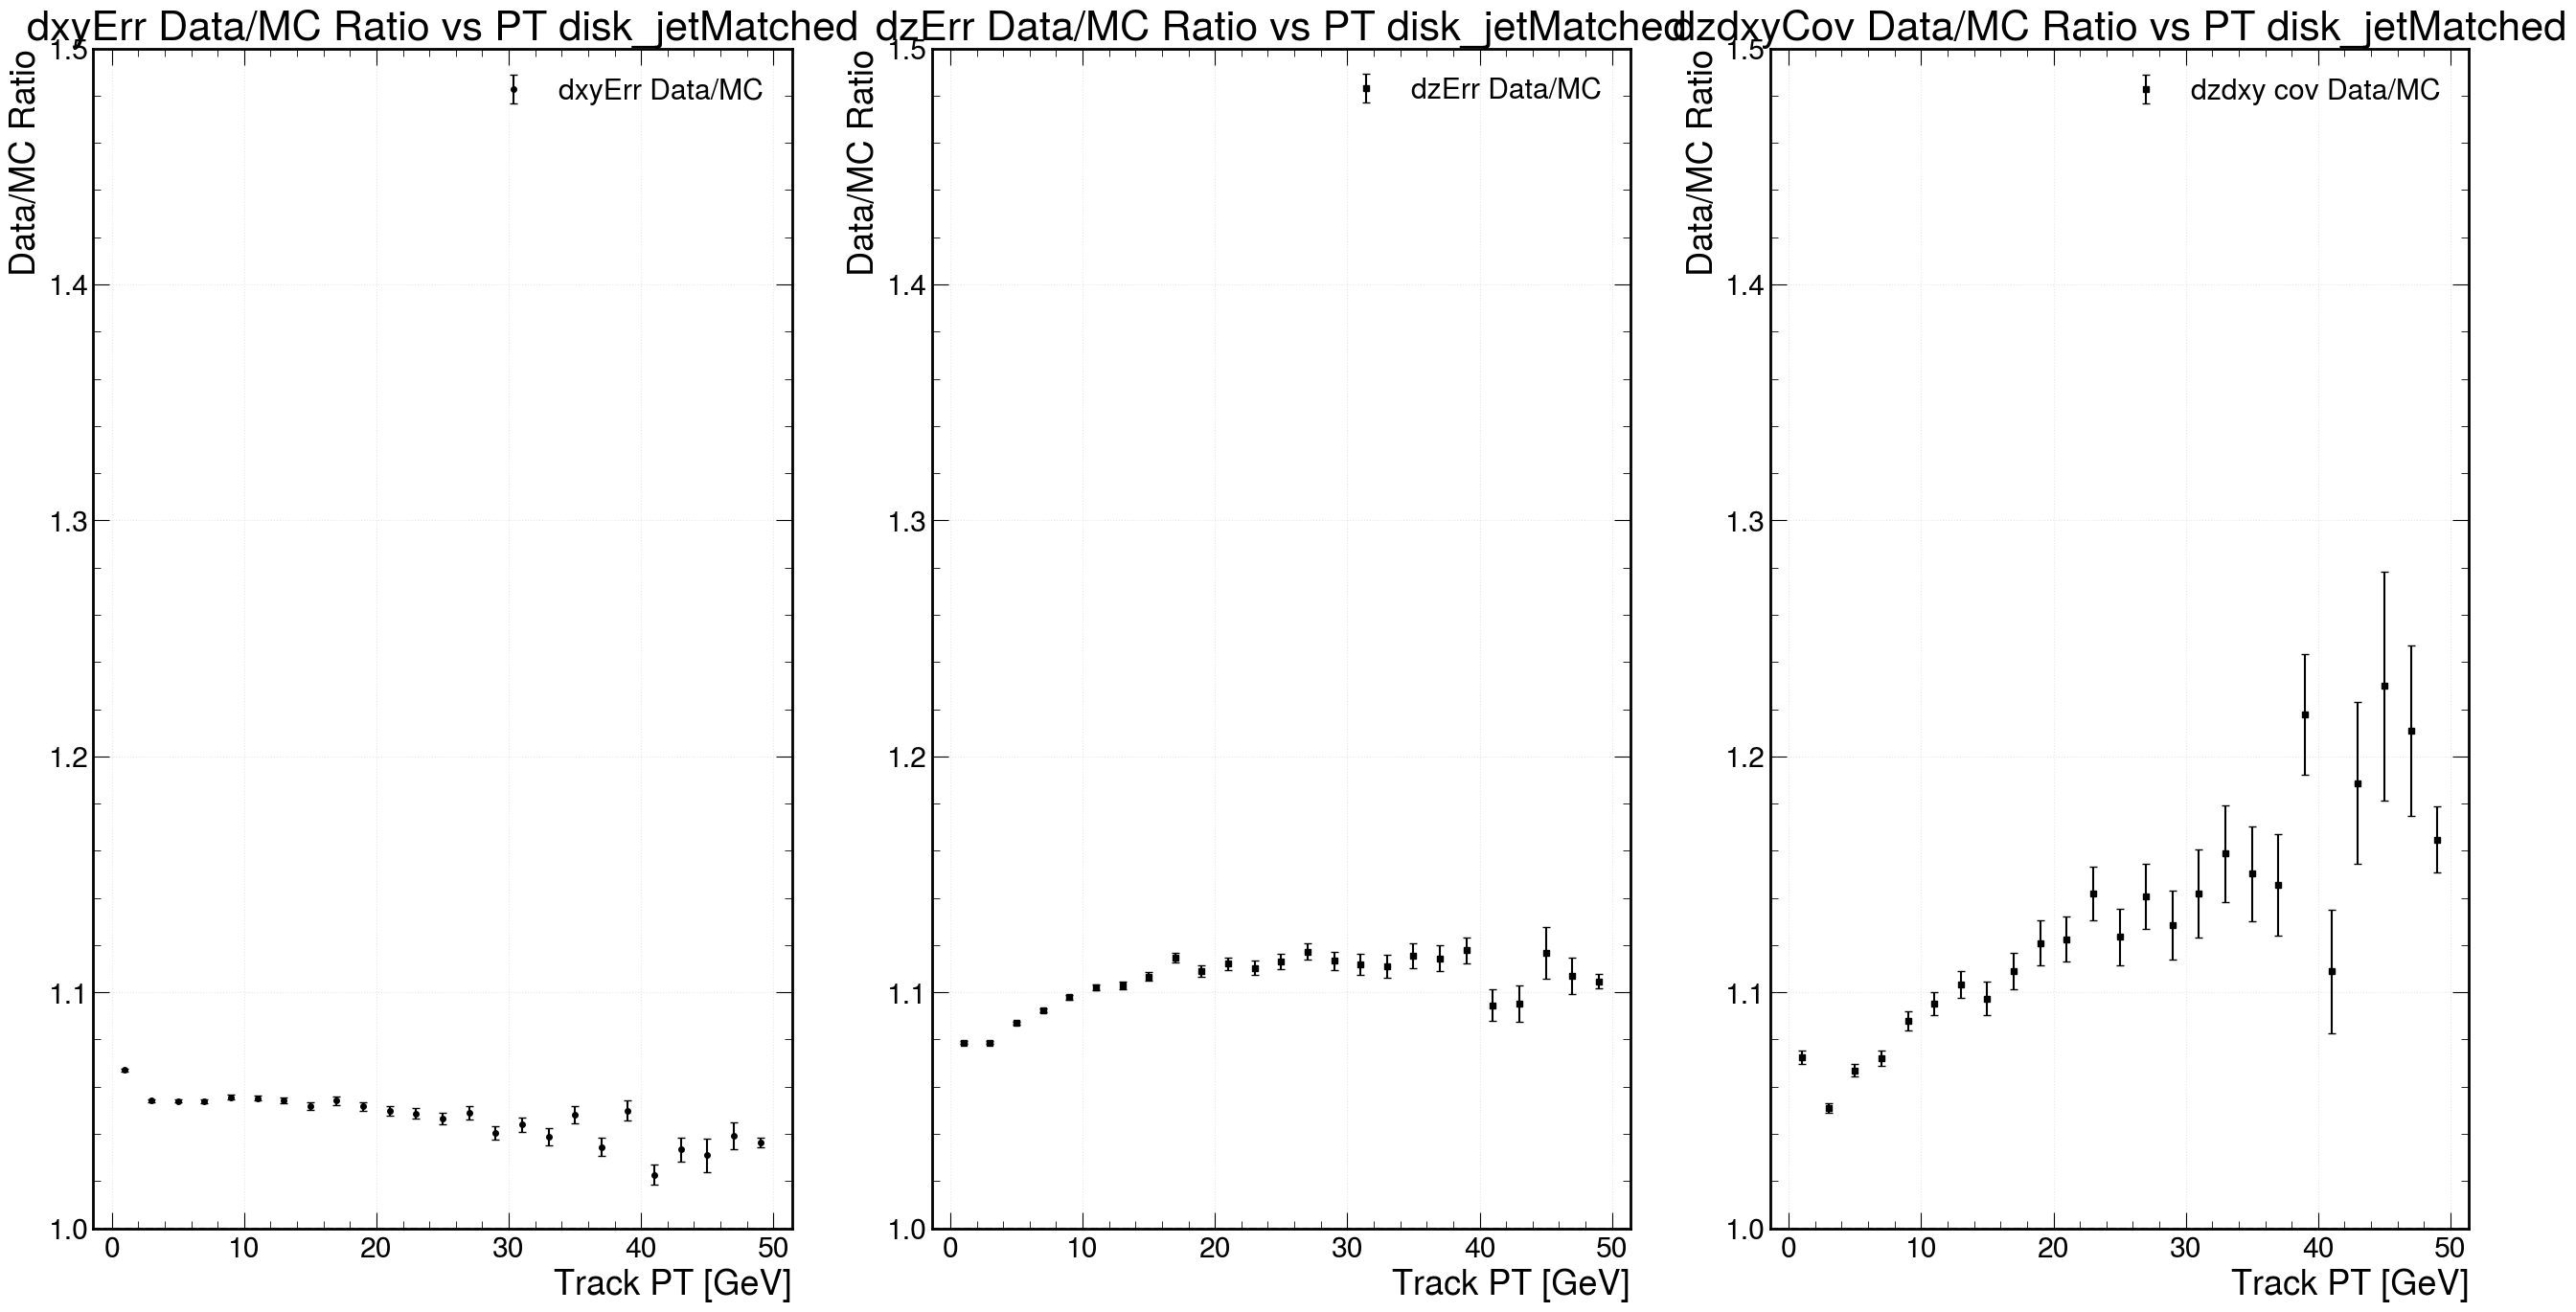

dxyErr_barrel_jetMatched [exp]: a=1.100013±0.010204, b=0.015096±0.004287, c=-3.096397±0.222812
  chi2/ndf = 109.08/22 = 4.958


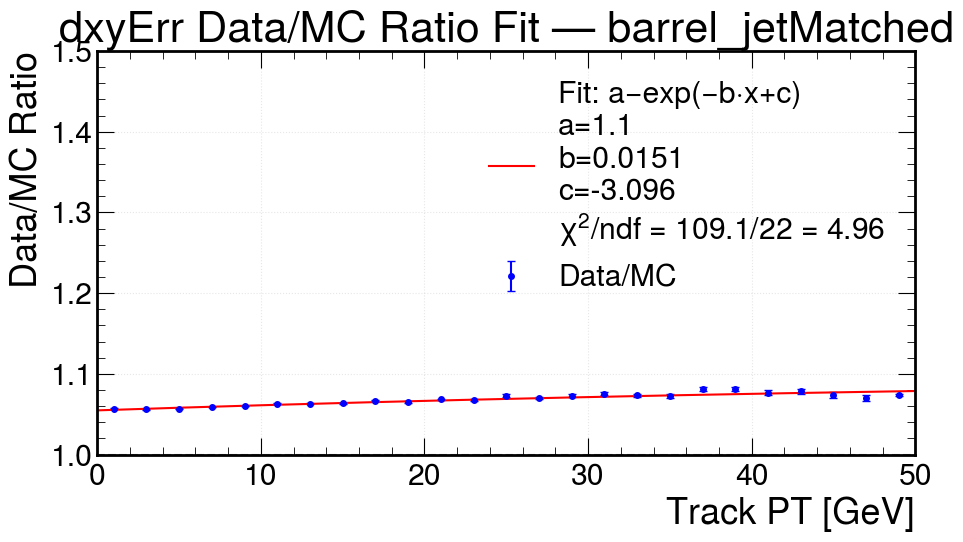

dzErr_barrel_jetMatched [exp]: a=1.146700±0.000494, b=0.182004±0.003064, c=-2.569677±0.006343
  chi2/ndf = 414.68/22 = 18.849


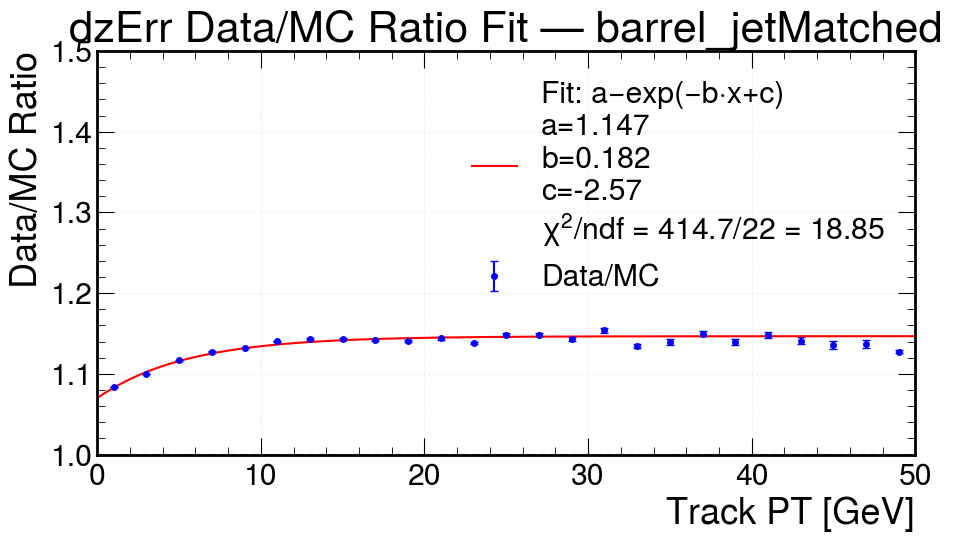

dzdxyCov_barrel_jetMatched [tanh]: a=0.133574±0.003737, b=0.128300±0.006182, c=-1.035423±0.065005, d=1.111151±0.002552
  chi2/ndf = 119.70/21 = 5.700


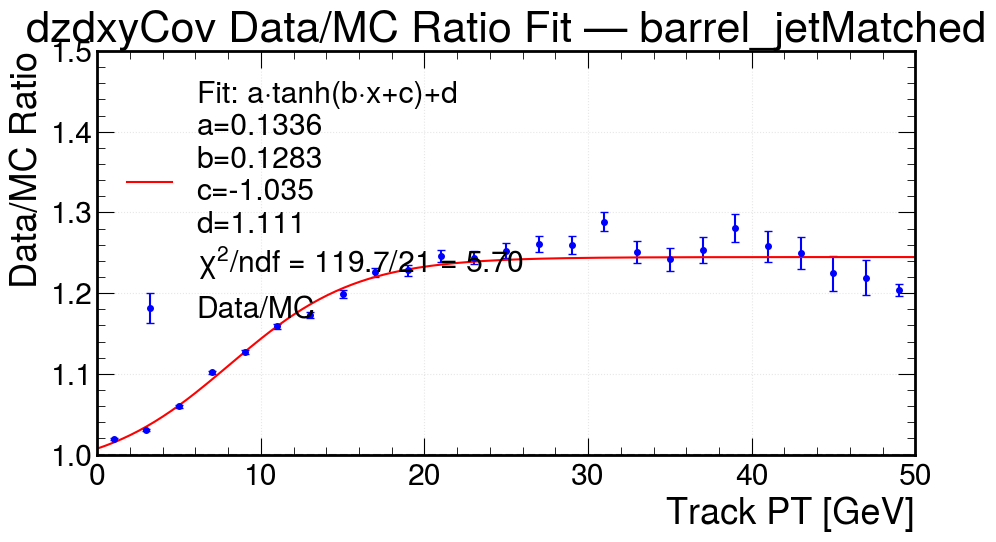

dxyErr_disk_jetMatched [bathtub]: a=1.053713±0.000586, b=0.012792±0.000925, c=-0.000298±0.000033
  chi2/ndf = 113.89/22 = 5.177


/tmp/rmccarth/ipykernel_2586275/384730031.py:275: RuntimeWarning: divide by zero encountered in divide
  return a + b / x + c * x


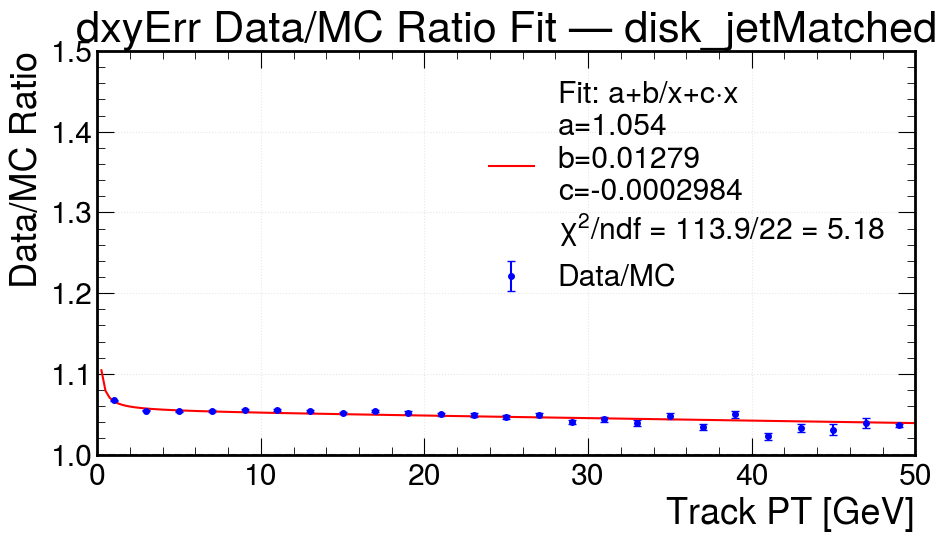

dzErr_disk_jetMatched [exp]: a=1.116355±0.001568, b=0.089655±0.006940, c=-3.106973±0.031923
  chi2/ndf = 132.35/22 = 6.016


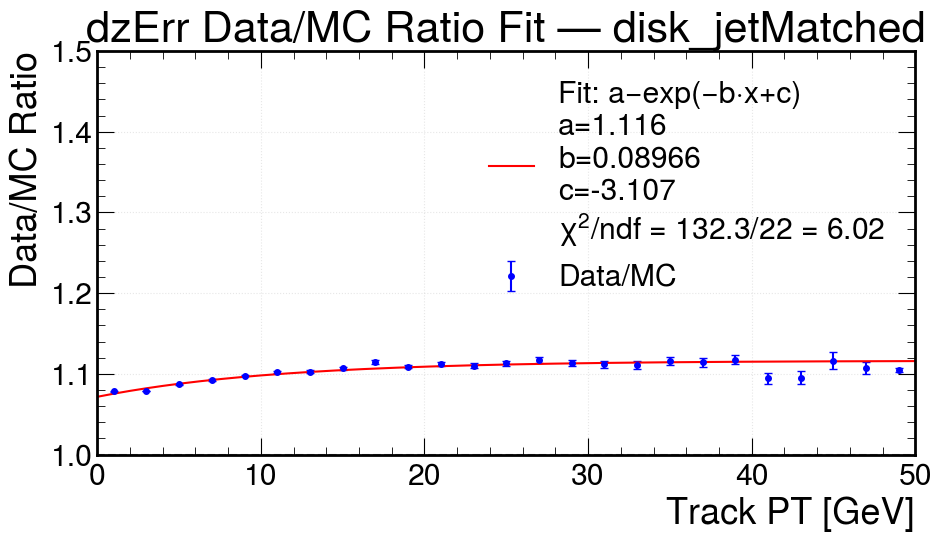

dzdxyCov_disk_jetMatched [bathtub]: a=1.044593±0.002586, b=0.020308±0.004270, c=0.003404±0.000174
  chi2/ndf = 74.62/22 = 3.392


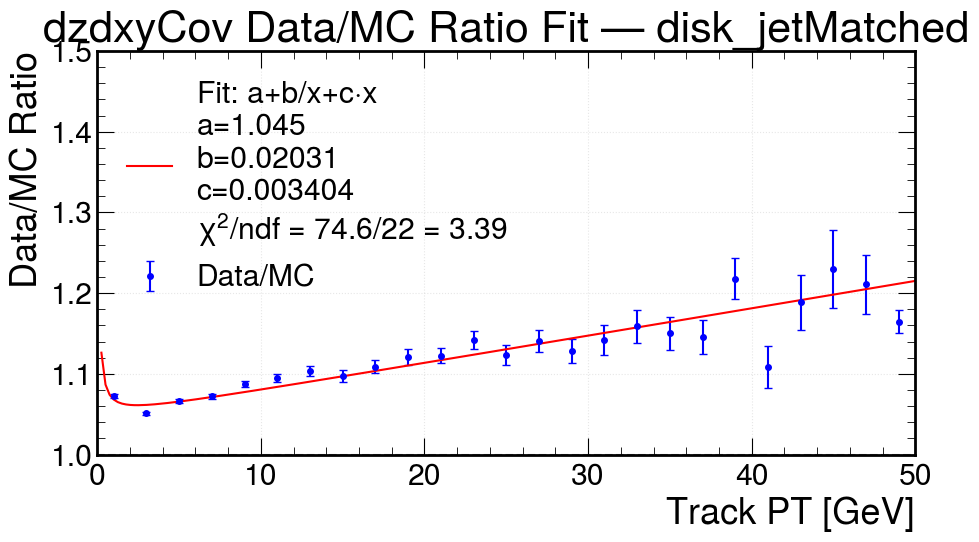

Total runtime: 14.65 seconds


In [3]:
#Track Uncertainty Correction Calculation

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "scoutTrack_pt": [0,50,26]
}

# Helper function to combine weighted statistics
def combine_weighted_stats(data, components):
    """Combine weighted statistics from multiple components"""
    combined = {}
    
    # First combine the raw sums
    sum_keys = ["weight_sum", "weight_sq_sum", "dxyErr_weighted_sum", "dszErr_weighted_sum", "dszdxyCov_weighted_sum",
                "dxyErr_weighted_sq_sum", "dszErr_weighted_sq_sum", "dszdxyCov_weighted_sq_sum"]
    
    for key in sum_keys:
        for string in ["_barrel","_disk","_barrel_jetMatched","_disk_jetMatched"]:
            fullKey = key+string
            if fullKey in data:
                combined[fullKey] = sum(data[fullKey][comp] for comp in components if comp in data[fullKey])
    
    # Recalculate means and standard errors
    for string in ["_barrel","_disk","_barrel_jetMatched","_disk_jetMatched"]:
        with np.errstate(divide='ignore', invalid='ignore'):
            # Weighted means
            combined["dxyErr_mean"+string] = np.where(combined["weight_sum"+string] > 0, 
                                              combined["dxyErr_weighted_sum"+string] / combined["weight_sum"+string], 0)
            combined["dzErr_mean"+string] = np.where(combined["weight_sum"+string] > 0, 
                                             combined["dszErr_weighted_sum"+string] / combined["weight_sum"+string], 0)
            combined["cov_mean"+string] = np.where(combined["weight_sum"+string] > 0, 
                                             combined["dszdxyCov_weighted_sum"+string] / combined["weight_sum"+string], 0)

            # Weighted variances
            dxyErr_var = np.where(combined["weight_sum"+string] > 0,
                                  combined["dxyErr_weighted_sq_sum"+string] / combined["weight_sum"+string] - combined["dxyErr_mean"+string]**2, 0)
            dzErr_var = np.where(combined["weight_sum"+string] > 0,
                                 combined["dszErr_weighted_sq_sum"+string] / combined["weight_sum"+string] - combined["dzErr_mean"+string]**2, 0)
            cov_var = np.where(combined["weight_sum"+string] > 0,
                                 combined["dszdxyCov_weighted_sq_sum"+string] / combined["weight_sum"+string] - combined["cov_mean"+string]**2, 0)

            # Effective sample size
            eff_n = np.where(combined["weight_sq_sum"+string] > 0, 
                             combined["weight_sum"+string]**2 / combined["weight_sq_sum"+string], 0)

            # Standard errors
            combined["dxyErr_stderr"+string] = np.where(eff_n > 0, np.sqrt(dxyErr_var / eff_n), 0)
            combined["dzErr_stderr"+string] = np.where(eff_n > 0, np.sqrt(dzErr_var / eff_n), 0)
            combined["cov_stderr"+string] = np.where(eff_n > 0, np.sqrt(cov_var / eff_n), 0)
    
    return combined

t0 = time.time()

plotWeights = {}
dict = signalDict | processDict
for process, rootFiles in dict.items():
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        
        #Assuming only one file per process here
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        n_binsSkim = h_genWeights.GetNbinsX() 
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeightSum = genWeights[0]
        
        for plot in ["weight_sum","weight_sq_sum","dxyErr_weighted_sum","dszErr_weighted_sum","dszdxyCov_weighted_sum","dxyErr_weighted_sq_sum","dszErr_weighted_sq_sum","dszdxyCov_weighted_sq_sum"]:
            for string in ["_barrel","_disk","_barrel_jetMatched","_disk_jetMatched"]:
                hist = f.Get("p/"+plot+string)
                nbins = hist.GetNbinsX() 
                data = np.array([hist.GetBinContent(i) for i in range(1, nbins + 1)])
                rebinned = data[:50].reshape(25, 2).sum(axis=1) #rebin to 25 bins
                rebinned[-1] += data[50:].sum()  # overflow from x > 50

                
                if process in processDict:
                    if ("weight_sq_sum" == plot):
                        rebinned = rebinned/(genWeightSum**2)
                    else:
                        rebinned = rebinned/genWeightSum

                if (plot+string) not in plotWeights:
                    plotWeights[(plot+string)] = {process: rebinned}
                else:
                    if process in plotWeights[(plot+string)]:
                        plotWeights[(plot+string)][process] = plotWeights[(plot+string)][process] + rebinned
                    else:
                        plotWeights[(plot+string)][process] = rebinned
        

    
# Combine QCD components
qcd_components = ["QCD40to70", "QCD70to100", "QCD100to200", "QCD200to400", "QCD400to600", 
                 "QCD600to800", "QCD800to1000", "QCD1000to1200", "QCD1200to1500", "QCD1500to2000", "QCD2000"]

# Combine TTbar components
ttbar_components = ["TTTo4Q", "TTToLNu2Q"]

# Combine 2024 data
data_components = ["2024C", "2024D", "2024E", "2024F", "2024G", "2024H", "2024I"]

# Combine weighted statistics for QCD
bg_stats = combine_weighted_stats(plotWeights, qcd_components+ttbar_components)
for key in bg_stats.keys():
    if key in plotWeights:
        plotWeights[key]["BG"] = bg_stats[key]
    else:
        plotWeights[key] = {"BG": bg_stats[key]}

# Combine weighted statistics for 2024 data
data_stats = combine_weighted_stats(plotWeights, data_components)
for key in data_stats.keys():
    if key in plotWeights:
        plotWeights[key]["2024"] = data_stats[key]
    else:
        plotWeights[key] = {"2024": data_stats[key]}

# **Plotting**
# Plot average dxyErr and dzErr vs PT with error bars
pt_bins = np.linspace(plotDict["scoutTrack_pt"][0], plotDict["scoutTrack_pt"][1], plotDict["scoutTrack_pt"][2])
pt_centers = (pt_bins[:-1] + pt_bins[1:]) / 2

for string in ["_barrel_jetMatched","_disk_jetMatched"]:
    mc_dxyErr_mean = plotWeights["dxyErr_mean"+string]["BG"]
    mc_dzErr_mean = plotWeights["dzErr_mean"+string]["BG"]
    mc_cov_mean = plotWeights["cov_mean"+string]["BG"]
    mc_dxyErr_stderr = plotWeights["dxyErr_stderr"+string]["BG"]
    mc_dzErr_stderr = plotWeights["dzErr_stderr"+string]["BG"]
    mc_cov_stderr = plotWeights["cov_stderr"+string]["BG"]
    # Create figure with 2 subplots for dxyErr and dzErr
    fig, axes = plt.subplots(1, 3, figsize=[32, 16])
    #fig.suptitle("Weighted Average Track Uncertainties vs PT "+string[1:], fontsize=16)

    # Plot 1: Average dxyErr vs PT with error bars
    ax = axes[0]
    ax.errorbar(pt_centers, mc_dxyErr_mean, 
               yerr=mc_dxyErr_stderr,
               label="MC (QCD+TTbar)", marker='o', markersize=4, capsize=2, alpha=0.8, linestyle='none', color='red')
    ax.errorbar(pt_centers, plotWeights["dxyErr_mean"+string]["2024"], 
               yerr=plotWeights["dxyErr_stderr"+string]["2024"],
               label="2024 Data", marker='^', markersize=4, color='black', capsize=2, linestyle='none')
    ax.set_xlabel("Track PT [GeV]")
    ax.set_ylabel("Average dxyErr [cm]")
    ax.set_title("Weighted Average dxyErr vs PT "+string[1:])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pt_bins[0], pt_bins[-1])

    # Plot 2: Average dzErr vs PT with error bars
    ax = axes[1]
    ax.errorbar(pt_centers, mc_dzErr_mean, 
               yerr=mc_dzErr_stderr,
               label="MC (QCD+TTbar)", marker='o', markersize=4, capsize=2, alpha=0.8, linestyle='none', color='red')
    ax.errorbar(pt_centers, plotWeights["dzErr_mean"+string]["2024"], 
               yerr=plotWeights["dzErr_stderr"+string]["2024"],
               label="2024 Data", marker='^', markersize=4, color='black', capsize=2, linestyle='none')
    ax.set_xlabel("Track PT [GeV]")
    ax.set_ylabel("Average dzErr [cm]")
    ax.set_title("Weighted Average dzErr vs PT "+string[1:])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pt_bins[0], pt_bins[-1])

    # Plot 3: Average dxydz covariance vs PT with error bars
    ax = axes[2]
    ax.errorbar(pt_centers, mc_cov_mean, 
               yerr=mc_cov_stderr,
               label="MC (QCD+TTbar)", marker='o', markersize=4, capsize=2, alpha=0.8, linestyle='none', color='red')
    ax.errorbar(pt_centers, plotWeights["cov_mean"+string]["2024"], 
               yerr=plotWeights["cov_stderr"+string]["2024"],
               label="2024 Data", marker='^', markersize=4, color='black', capsize=2, linestyle='none')
    ax.set_xlabel("Track PT [GeV]")
    ax.set_ylabel("Average dzdxy Covariance [sq cm]")
    ax.set_title("Weighted Average dzdxy Covariance vs PT "+string[1:])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pt_bins[0], pt_bins[-1])

    #plt.tight_layout()
    plt.savefig("trackAvgUnc_datamc"+string+".pdf")
    plt.show()

    # Create ratio plots for error comparisons with uncertainties
    fig, axes = plt.subplots(1, 3, figsize=[32, 16])
    #fig.suptitle("Data/MC Ratio of Average Track Uncertainties "+string[1:], fontsize=16)

    # Calculate ratios (mc_dxyErr_mean etc already calculated above)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate ratios
        ratio_dxyErr = np.where(mc_dxyErr_mean > 0, 
                               plotWeights["dxyErr_mean"+string]["2024"] / mc_dxyErr_mean, 0)
        ratio_dzErr = np.where(mc_dzErr_mean > 0, 
                              plotWeights["dzErr_mean"+string]["2024"] / mc_dzErr_mean, 0)
        ratio_cov = np.where(mc_cov_mean > 0, 
                              plotWeights["cov_mean"+string]["2024"] / mc_cov_mean, 0)

        # Propagate errors for ratios
        ratio_dxyErr_err = ratio_dxyErr * np.sqrt(
            np.where(plotWeights["dxyErr_mean"+string]["2024"] > 0, 
                    (plotWeights["dxyErr_stderr"+string]["2024"] / plotWeights["dxyErr_mean"+string]["2024"])**2, 0) +
            np.where(mc_dxyErr_mean > 0, (mc_dxyErr_stderr / mc_dxyErr_mean)**2, 0))

        ratio_dzErr_err = ratio_dzErr * np.sqrt(
            np.where(plotWeights["dzErr_mean"+string]["2024"] > 0,
                    (plotWeights["dzErr_stderr"+string]["2024"] / plotWeights["dzErr_mean"+string]["2024"])**2, 0) +
            np.where(mc_dzErr_mean > 0, (mc_dzErr_stderr / mc_dzErr_mean)**2, 0))

        ratio_cov_err = ratio_cov * np.sqrt(
            np.where(plotWeights["cov_mean"+string]["2024"] > 0,
                    (plotWeights["cov_stderr"+string]["2024"] / plotWeights["cov_mean"+string]["2024"])**2, 0) +
            np.where(mc_cov_mean > 0, (mc_cov_stderr / mc_cov_mean)**2, 0))

    # Ratio plot for dxyErr
    ax = axes[0]
    valid = ratio_dxyErr > 0
    ax.errorbar(pt_centers[valid], ratio_dxyErr[valid], yerr=ratio_dxyErr_err[valid],
               marker='o', markersize=4, color='black', label='dxyErr Data/MC', capsize=3, linestyle='none')
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel("Track PT [GeV]")
    ax.set_ylabel("Data/MC Ratio")
    ax.set_title("dxyErr Data/MC Ratio vs PT "+string[1:])
    ax.set_ylim(1, 1.5)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Ratio plot for dzErr
    ax = axes[1]
    valid = ratio_dzErr > 0
    ax.errorbar(pt_centers[valid], ratio_dzErr[valid], yerr=ratio_dzErr_err[valid],
               marker='s', markersize=4, color='black', label='dzErr Data/MC', capsize=3, linestyle='none')
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel("Track PT [GeV]")
    ax.set_ylabel("Data/MC Ratio")
    ax.set_title("dzErr Data/MC Ratio vs PT "+string[1:])
    ax.set_ylim(1, 1.5)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Ratio plot for dzErr
    ax = axes[2]
    valid = ratio_cov > 0
    ax.errorbar(pt_centers[valid], ratio_cov[valid], yerr=ratio_cov_err[valid],
               marker='s', markersize=4, color='black', label='dzdxy cov Data/MC', capsize=3, linestyle='none')
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel("Track PT [GeV]")
    ax.set_ylabel("Data/MC Ratio")
    ax.set_title("dzdxyCov Data/MC Ratio vs PT "+string[1:])
    ax.set_ylim(1, 1.5)
    ax.grid(True, alpha=0.3)
    ax.legend()

    #plt.tight_layout()
    plt.savefig("trackUncRatio"+string+".pdf")
    plt.show()

from scipy.optimize import curve_fit

# --- Fit models ---
def exp_model(x, a, b, c):
    return a - np.exp(-b * x + c)

def quad_model(x, a, b, c):
    return a + b * x + c * x**2

def log_model(x, a, b, c):
    return a + b * np.log(x + c)

def bathtub_model(x, a, b, c):
    return a + b / x + c * x

def saturate_model(x, a, b, c):
    return a * x / (x + b) + c

def cubic_model(x, a, b, c, d):
    return a + b * x + c * x**2 + d * x**3

def tanh_model(x, a, b, c, d):
    return a * np.tanh(b * x + c) + d

# --- Model registry ---
models = {
    "exp":      {"func": exp_model,      "label": "a−exp(−b·x+c)",    "npar": 3},
    "quad":     {"func": quad_model,     "label": "a+b·x+c·x²",       "npar": 3},
    "log":      {"func": log_model,      "label": "a+b·ln(x+c)",      "npar": 3},
    "bathtub":  {"func": bathtub_model,  "label": "a+b/x+c·x",       "npar": 3},
    "saturate": {"func": saturate_model, "label": "a·x/(x+b)+c",     "npar": 3},
    "cubic":    {"func": cubic_model,    "label": "a+b·x+c·x²+d·x³", "npar": 4},
    "tanh":     {"func": tanh_model,     "label": "a·tanh(b·x+c)+d",  "npar": 4},
}

# --- Configuration per fit ---
fit_config = {
    ("dxyErr",   "barrel_jetMatched"): {"model": "exp",      "p0": [1.5, 0.5, 0.0],   "bounds": ([0, 0, -10], [3, 10, 10])},
    ("dxyErr",   "disk_jetMatched"):   {"model": "bathtub",  "p0": [1.1, 0.5, 0.001], "bounds": (-np.inf, np.inf)},
    ("dzErr",    "barrel_jetMatched"): {"model": "exp",      "p0": [1.5, 0.5, 0.0],   "bounds": ([0, 0, -10], [3, 10, 10])},
    ("dzErr",    "disk_jetMatched"):   {"model": "exp",      "p0": [1.5, 0.5, 0.0],   "bounds": ([0, 0, -10], [3, 10, 10])},
    ("dzdxyCov", "barrel_jetMatched"): {"model": "tanh",      "p0": [0.15, 0.2, 0.0, 1.2], "bounds": ([0, 0, -5, 0], [1, 5, 5, 2])},
    ("dzdxyCov", "disk_jetMatched"):   {"model": "bathtub",  "p0": [1.1, 0.5, 0.001], "bounds": (-np.inf, np.inf)},
}

# Store corrections
corrections = {}

for string in ["_barrel_jetMatched", "_disk_jetMatched"]:
    mc_dxyErr_mean = plotWeights["dxyErr_mean" + string]["BG"]
    mc_dzErr_mean = plotWeights["dzErr_mean" + string]["BG"]
    mc_cov_mean = plotWeights["cov_mean" + string]["BG"]
    mc_dxyErr_stderr = plotWeights["dxyErr_stderr" + string]["BG"]
    mc_dzErr_stderr = plotWeights["dzErr_stderr" + string]["BG"]
    mc_cov_stderr = plotWeights["cov_stderr" + string]["BG"]

    # Recalculate ratios and errors
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_dxyErr = np.where(mc_dxyErr_mean > 0,
                                plotWeights["dxyErr_mean" + string]["2024"] / mc_dxyErr_mean, 0)
        ratio_dzErr = np.where(mc_dzErr_mean > 0,
                               plotWeights["dzErr_mean" + string]["2024"] / mc_dzErr_mean, 0)
        ratio_cov = np.where(mc_cov_mean > 0,
                             plotWeights["cov_mean" + string]["2024"] / mc_cov_mean, 0)

        ratio_dxyErr_err = ratio_dxyErr * np.sqrt(
            np.where(plotWeights["dxyErr_mean" + string]["2024"] > 0,
                     (plotWeights["dxyErr_stderr" + string]["2024"] / plotWeights["dxyErr_mean" + string]["2024"])**2, 0) +
            np.where(mc_dxyErr_mean > 0, (mc_dxyErr_stderr / mc_dxyErr_mean)**2, 0))

        ratio_dzErr_err = ratio_dzErr * np.sqrt(
            np.where(plotWeights["dzErr_mean" + string]["2024"] > 0,
                     (plotWeights["dzErr_stderr" + string]["2024"] / plotWeights["dzErr_mean" + string]["2024"])**2, 0) +
            np.where(mc_dzErr_mean > 0, (mc_dzErr_stderr / mc_dzErr_mean)**2, 0))

        ratio_cov_err = ratio_cov * np.sqrt(
            np.where(plotWeights["cov_mean" + string]["2024"] > 0,
                     (plotWeights["cov_stderr" + string]["2024"] / plotWeights["cov_mean" + string]["2024"])**2, 0) +
            np.where(mc_cov_mean > 0, (mc_cov_stderr / mc_cov_mean)**2, 0))

    region = string[1:]  # "barrel" or "disk"

    for label, ratio, ratio_err in [
        ("dxyErr", ratio_dxyErr, ratio_dxyErr_err),
        ("dzErr", ratio_dzErr, ratio_dzErr_err),
        ("dzdxyCov", ratio_cov, ratio_cov_err),
    ]:
        valid = (ratio > 0) & (ratio_err > 0)
        x_fit = pt_centers[valid]
        y_fit = ratio[valid]
        yerr_fit = ratio_err[valid]

        # Look up config
        cfg = fit_config[(label, region)]
        model_info = models[cfg["model"]]
        fit_func = model_info["func"]
        npar = model_info["npar"]

        try:
            popt, pcov = curve_fit(fit_func, x_fit, y_fit, p0=cfg["p0"],
                                   sigma=yerr_fit, absolute_sigma=True,
                                   bounds=cfg["bounds"], maxfev=10000)
            perr = np.sqrt(np.diag(pcov))

            # Reduced chi-squared
            residuals = y_fit - fit_func(x_fit, *popt)
            chi2 = np.sum((residuals / yerr_fit)**2)
            ndf = len(x_fit) - npar
            red_chi2 = chi2 / ndf if ndf > 0 else np.inf

            param_str = ", ".join(f"{chr(97+i)}={popt[i]:.6f}±{perr[i]:.6f}" for i in range(npar))
            print(f"{label}_{region} [{cfg['model']}]: {param_str}")
            print(f"  chi2/ndf = {chi2:.2f}/{ndf} = {red_chi2:.3f}")

        except RuntimeError as e:
            print(f"Fit failed for {label}_{region}: {e}")
            popt = cfg["p0"]
            red_chi2 = np.inf

        # Evaluate fit at all bin centers and save
        fit_values = fit_func(pt_centers, *popt)
        key = f"ratio_correction_{label}_{region}"
        corrections[key] = fit_values

        #fname = f"{key}.npy"
        #np.save(fname, fit_values)
        #print(f"  Saved {fname}  (shape={fit_values.shape})")

        # Plot
        fig, ax = plt.subplots(figsize=[10, 6])
        ax.errorbar(x_fit, y_fit, yerr=yerr_fit,
                     marker='o', markersize=4, color='blue', capsize=3,
                     linestyle='none', label='Data/MC')
        x_smooth = np.linspace(pt_bins[0], pt_bins[-1], 200)
        param_lines = "\n".join(f"{chr(97+i)}={popt[i]:.4g}" for i in range(npar))
        ax.plot(x_smooth, fit_func(x_smooth, *popt), 'r-',
                label=(f'Fit: {model_info["label"]}\n'
                       f'{param_lines}\n'
                       f'$\\chi^2$/ndf = {chi2:.1f}/{ndf} = {red_chi2:.2f}'))
        ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel("Track PT [GeV]")
        ax.set_ylabel("Data/MC Ratio")
        ax.set_title(f"{label} Data/MC Ratio Fit — {region}")
        ax.set_ylim(1, 1.5)
        ax.set_xlim(pt_bins[0], pt_bins[-1])
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

#print("\nAll correction files saved:")
#np.savez("ratio_uncertaintyCorrections_v28.npz", **corrections)

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

In [5]:
data = np.load("ratio_uncertaintyCorrections.npz")
corr_dxyErr_barrel = data["ratio_correction_dxyErr_barrel"]
print(corr_dxyErr_barrel)

[1.06979913 1.07991986 1.08702955 1.09202402 1.09553258 1.0979973
 1.09972873 1.10094505 1.10179949 1.10239973 1.10282139 1.1031176
 1.10332568 1.10347186 1.10357455 1.10364669 1.10369736 1.10373296
 1.10375797 1.10377554 1.10378788 1.10379655 1.10380264 1.10380691
 1.10380992]


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-4DxyMin/260409_153724/Run2024C.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-4DxyMin/260409_153833/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-4DxyMin/260409_153742/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-4DxyMin/260409_153818/Run2024E.root


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-4DxyMin/260409_153901/Run2024H.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-4DxyMin/260409_153846/Run2024G.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-4DxyMin/260409_153919/Run2024I.root



=== 2024 Data Combined ===
ntrk=3: A=19646.0±140.2  B=423178.0±650.5  C=19109.0±138.2  D=422276.0±649.8
  TF(B/A)=21.5402±0.

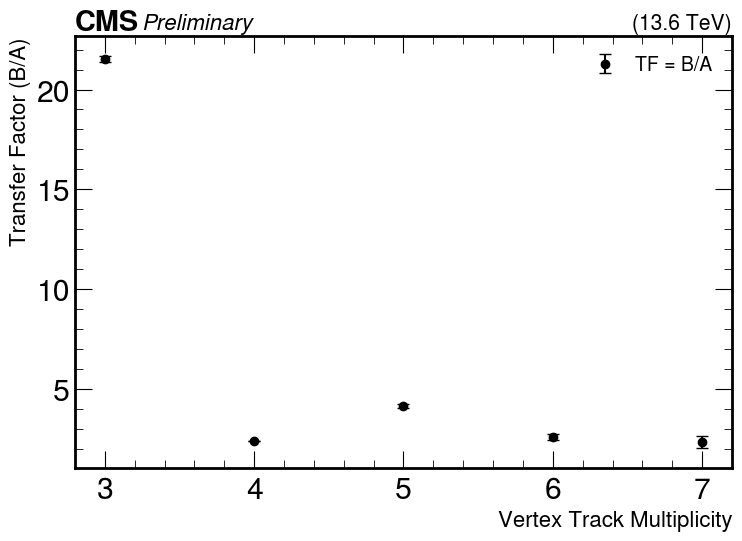

Saved transfer_factor_vs_ntrack.pdf/png


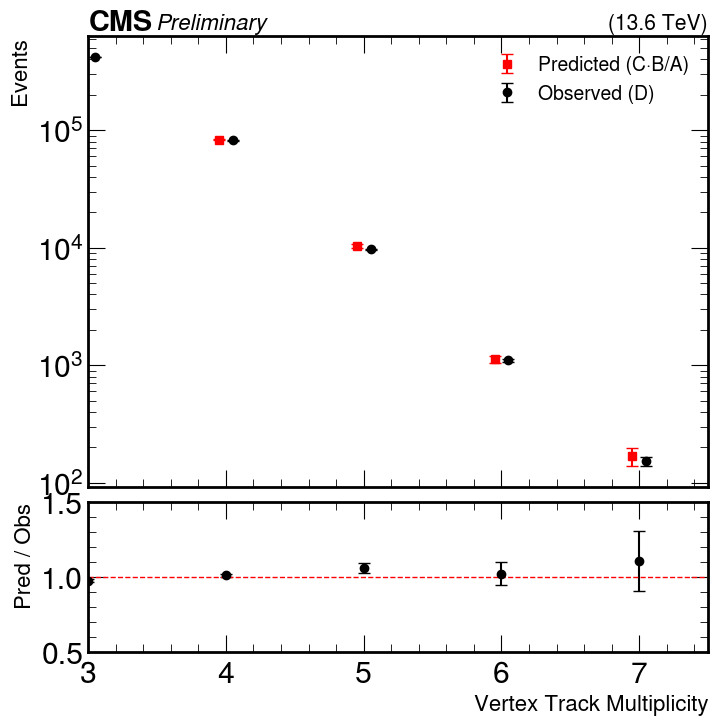

Saved abcd_closure_vs_ntrack.pdf/png


In [11]:
#ABCD in different track multiplicity bins

import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from concurrent.futures import ProcessPoolExecutor, as_completed

plt.style.use(hep.style.CMS)

# ABCD regions in (cosT, chi2):
#   A: cosT <= 0, chi2 >= 3  (fail both)
#   B: cosT <= 0, chi2 < 3   (pass chi2 only)
#   C: cosT > 0,  chi2 >= 3  (pass cosT only)
#   D: cosT > 0,  chi2 < 3   (signal region)
#
# Transfer factor: TF = B/A
# Prediction: D_pred = C * (B/A)

NTRACK_BINS = [3, 4, 5, 6, 7]
ABCD_REGIONS = ["A", "B", "C", "D"]


def process_abcd_per_ntrack(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    # Initialize counts: {ntrk: {region: (sum_w, sum_w2)}}
    counts = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}

    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]
        branches = [
            "scoutVert_dBV", "scoutVert_dBVErr", "scoutVert_nTracks",
            "weight", "scoutVert_chi2", "scoutVert_cosT", "jet_pt"
        ]

        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = ak.ones_like(batch["weight"])
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            #jet_pt = batch["jet_pt"]
            #njet = ak.num(jet_pt,axis=1)
            #jet_mask = (njet>3)
            #dBV = dBV[jet_mask]
            #dBVErr = dBVErr[jet_mask]
            #ntracks = ntracks[jet_mask]
            #chi2 = chi2[jet_mask]
            #cosT = cosT[jet_mask]
            # Baseline vertex selection
            vtx_mask = (dBV > 0.01) & (dBV < 2.0) & (ntracks > 2) & (dBVErr < 0.005) #& (ntracks < 8)
            dBV = dBV[vtx_mask]
            ntracks = ntracks[vtx_mask]
            chi2 = chi2[vtx_mask]
            cosT = cosT[vtx_mask]

            # Keep events with at least one vertex passing baseline
            evt_mask = ak.num(dBV, axis=1) > 0
            weights = weights[evt_mask]
            ntracks = ntracks[evt_mask]
            chi2 = chi2[evt_mask]
            cosT = cosT[evt_mask]

            for nt in NTRACK_BINS:
                # Select vertices with exactly this track multiplicity
                nt_mask = ntracks == nt
                nt_chi2 = chi2[nt_mask]
                nt_cosT = cosT[nt_mask]

                # ABCD masks (per vertex)
                pass_cosT = nt_cosT > 0
                pass_chi2 = nt_chi2 < 3

                region_masks = {
                    "D": pass_cosT & pass_chi2,
                    "C": pass_cosT & ~pass_chi2,
                    "B": ~pass_cosT & pass_chi2,
                    "A": ~pass_cosT & ~pass_chi2,
                }
                
                duplicateMask = ak.ones_like(weights, dtype=bool)
                for region in ["D","C","B","A"]:
                    rmask = region_masks[region]
                    # Event has at least one vertex in this region
                    evt_in_region = (ak.num(nt_cosT[rmask]) > 0) & duplicateMask
                    w = weights[evt_in_region]
                    counts[nt][region][0] += float(ak.sum(w))
                    counts[nt][region][1] += float(ak.sum(w**2))
                    duplicateMask = duplicateMask & (~evt_in_region)

    return process, counts


def merge_counts(all_counts):
    """Merge counts across files for the same process."""
    merged = {}
    for process, counts in all_counts:
        if process not in merged:
            merged[process] = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                merged[process][nt][r][0] += counts[nt][r][0]
                merged[process][nt][r][1] += counts[nt][r][1]
    return merged


def compute_transfer_factors(counts):
    """Compute TF = B/A and its uncertainty for each ntrack bin."""
    ntracks = []
    tfs = []
    tf_errs = []
    region_yields = {r: ([], []) for r in ABCD_REGIONS}

    for nt in NTRACK_BINS:
        A, A2 = counts[nt]["A"]
        B, B2 = counts[nt]["B"]
        C, C2 = counts[nt]["C"]
        D, D2 = counts[nt]["D"]

        A_err = np.sqrt(A2)
        B_err = np.sqrt(B2)
        C_err = np.sqrt(C2)
        D_err = np.sqrt(D2)

        for r in ABCD_REGIONS:
            val, val2 = counts[nt][r]
            region_yields[r][0].append(val)
            region_yields[r][1].append(np.sqrt(val2))

        if A > 0 and B > 0:
            tf = B / A
            tf_err = tf * np.sqrt((A_err / A)**2 + (B_err / B)**2)
        elif A == 0:
            tf = 0
            tf_err = 0
        else:
            tf = 0
            tf_err = 0

        ntracks.append(nt)
        tfs.append(tf)
        tf_errs.append(tf_err)

        # Also print predicted vs observed
        if A > 0:
            D_pred = C * B / A
            D_pred_err = D_pred * np.sqrt(
                (A_err / A)**2 + (B_err / B)**2 + (C_err / C)**2
            ) if C > 0 else 0
        else:
            D_pred = 0
            D_pred_err = 0

        print(f"ntrk={nt}: A={A:.1f}±{A_err:.1f}  B={B:.1f}±{B_err:.1f}  "
              f"C={C:.1f}±{C_err:.1f}  D={D:.1f}±{D_err:.1f}")
        print(f"  TF(B/A)={tf:.4f}±{tf_err:.4f}  "
              f"D_pred={D_pred:.2f}±{D_pred_err:.2f}  D_obs={D:.1f}±{D_err:.1f}")

    return np.array(ntracks), np.array(tfs), np.array(tf_errs), region_yields


def plot_transfer_factor(ntracks, tfs, tf_errs, process_label="2024 Data"):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(
        ntracks, tfs, yerr=tf_errs,
        fmt='o', color='black', markersize=6, capsize=4, linewidth=1.5,
        label=f"TF = B/A"
    )

    ax.set_xlabel("Vertex Track Multiplicity", fontsize=16)
    ax.set_ylabel("Transfer Factor (B/A)", fontsize=16)
    ax.set_xticks(NTRACK_BINS)
    ax.legend(fontsize=14)
    #ax.set_xlim(4.5, 7.5)

    hep.cms.label("Preliminary", loc=0, ax=ax, com=13.6, fontsize=16,data=True)

    plt.tight_layout()
    plt.savefig("transfer_factor_vs_ntrack.pdf")
    plt.savefig("transfer_factor_vs_ntrack.png", dpi=150)
    plt.show()
    print("Saved transfer_factor_vs_ntrack.pdf/png")


def plot_closure(ntracks, region_yields, process_label="2024 Data"):
    """Plot predicted vs observed D region yields."""
    A_vals, A_errs = np.array(region_yields["A"][0]), np.array(region_yields["A"][1])
    B_vals, B_errs = np.array(region_yields["B"][0]), np.array(region_yields["B"][1])
    C_vals, C_errs = np.array(region_yields["C"][0]), np.array(region_yields["C"][1])
    D_vals, D_errs = np.array(region_yields["D"][0]), np.array(region_yields["D"][1])

    safe = A_vals > 0
    D_pred = np.where(safe, C_vals * B_vals / A_vals, 0)
    D_pred_err = np.where(
        safe & (B_vals > 0) & (C_vals > 0),
        D_pred * np.sqrt((A_errs/A_vals)**2 + (B_errs/B_vals)**2 + (C_errs/C_vals)**2),
        0
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[3, 1],
                                    sharex=True, gridspec_kw={'hspace': 0.05})

    ax1.errorbar(ntracks - 0.05, D_pred, yerr=D_pred_err,
                 fmt='s', color='red', markersize=6, capsize=4, label="Predicted (C·B/A)")
    ax1.errorbar(ntracks + 0.05, D_vals, yerr=D_errs,
                 fmt='o', color='black', markersize=6, capsize=4, label="Observed (D)")

    ax1.set_ylabel("Events", fontsize=16)
    ax1.legend(fontsize=14)
    ax1.set_xlim(4.5, 7.5)
    ax1.set_yscale("log")
    hep.cms.label("Preliminary", loc=0, ax=ax1, com=13.6, fontsize=16,data=True)


    # Ratio panel
    ratio = np.where(D_vals > 0, D_pred / D_vals, 0)
    ratio_err = np.where(D_vals > 0, D_pred_err / D_vals, 0)
    ax2.errorbar(ntracks, ratio, yerr=ratio_err, fmt='o', color='black', markersize=6, capsize=4)
    ax2.axhline(1, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel("Vertex Track Multiplicity", fontsize=16)
    ax2.set_ylabel("Pred / Obs", fontsize=16)
    ax2.set_ylim(0.5, 1.5)
    ax2.set_xticks(NTRACK_BINS)

    #plt.tight_layout()
    plt.savefig("abcd_closure_vs_ntrack.pdf")
    plt.savefig("abcd_closure_vs_ntrack.png", dpi=150)
    plt.show()
    print("Saved abcd_closure_vs_ntrack.pdf/png")


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # --- Fill in your file dictionaries here ---
    # processDict = {"2024C": [...], "2024D": [...], ...}
    # signalDict = {"stop_M200_ctau10": [...], ...}

    run_dict = signalDict  # or signalDict | processDict

    # Parallel processing
    all_results = []
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {
            executor.submit(process_abcd_per_ntrack, (f, p)): (f, p)
            for p, files in run_dict.items() for f in files
        }
        for future in as_completed(futures):
            all_results.append(future.result())

    merged = merge_counts(all_results)

    # Combine data eras
    combined = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
    data_eras = [k for k in merged if k.startswith("2024")]
    for era in data_eras:
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                combined[nt][r][0] += merged[era][nt][r][0]
                combined[nt][r][1] += merged[era][nt][r][1]

    print("\n=== 2024 Data Combined ===")
    ntracks, tfs, tf_errs, region_yields = compute_transfer_factors(combined)

    plot_transfer_factor(ntracks, tfs, tf_errs, process_label="2024 Data")
    plot_closure(ntracks, region_yields, process_label="2024 Data")

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v27-4DxyMin/260317_180418/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v27-4DxyMin/260317_180518/Run2024H.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v27-4DxyMin/260317_180442/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v27-4DxyMin/260317_180451/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v27-4DxyMin/260317_180533/Run2024I.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v27-4DxyMin/260317_180507/Run2024G.root





Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v27-4DxyMin/260317_180429/Run2024D.root

=== 2024 Data Combined ===
nJetTrk=3: A=4838.0±69.6  B=30832.0±175.6  C=5095.0±71.4  D=31557.0±177.6
  TF(B/A)=6.3729±0.0985

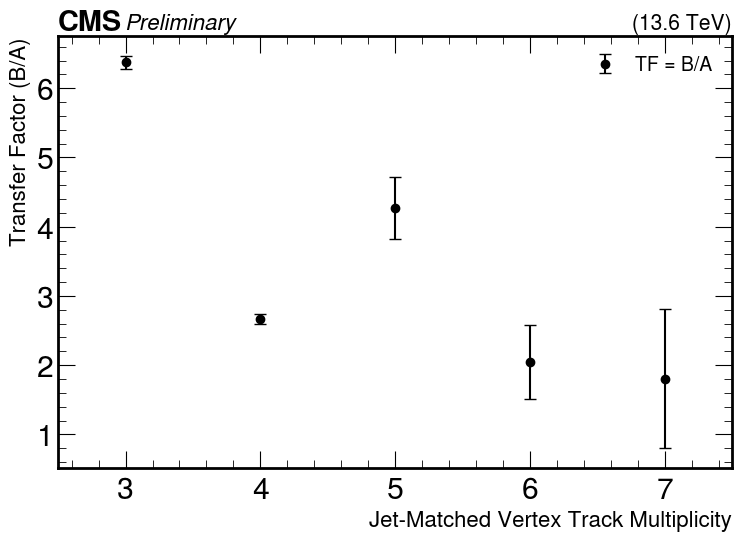

Saved transfer_factor_vs_nJetTrk.pdf/png


/tmp/rmccarth/ipykernel_124853/1699410891.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


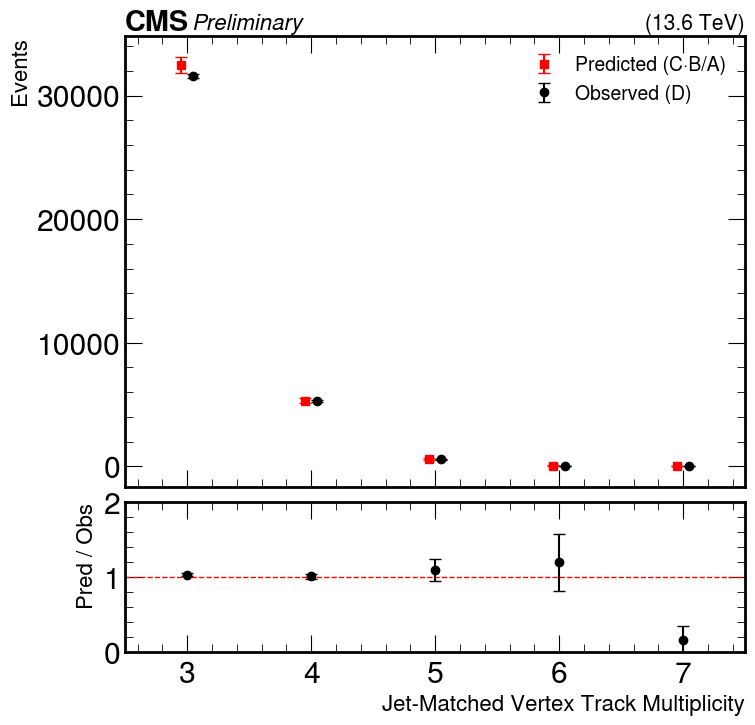

Saved abcd_closure_vs_nJetTrk.pdf/png


In [8]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from concurrent.futures import ProcessPoolExecutor, as_completed

plt.style.use(hep.style.CMS)

# ABCD regions in (cosT, chi2):
#   A: cosT <= 0, chi2 >= 3  (fail both)
#   B: cosT <= 0, chi2 < 3   (pass chi2 only)
#   C: cosT > 0,  chi2 >= 3  (pass cosT only)
#   D: cosT > 0,  chi2 < 3   (signal region)
#
# Transfer factor: TF = B/A
# Prediction: D_pred = C * (B/A)

NTRACK_BINS = [3, 4, 5, 6, 7]
ABCD_REGIONS = ["A", "B", "C", "D"]


def process_abcd_per_ntrack(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    counts = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}

    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]
        branches = [
            "scoutVert_dBV", "scoutVert_dBVErr", "scoutVert_nTracks",
            "weight", "scoutVert_chi2", "scoutVert_cosT",
            "vertTrack_iVtx", "vertTrack_iJet",
        ]

        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = ak.ones_like(batch["weight"])
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            trk_iVtx = batch["vertTrack_iVtx"]
            trk_iJet = batch["vertTrack_iJet"]
            
            # Compute number of jet-matched tracks per vertex.
            # trk_iVtx and trk_iJet are jagged arrays of shape [event][track].
            # For each vertex index in each event, count tracks with iJet != -1.

            nVtx = ak.num(dBV, axis=1)  # number of vertices per event

            # Mask for tracks matched to a jet
            trk_has_jet = trk_iJet != -1

            # For each vertex index, count how many of its tracks have a jet match.
            # We build a per-vertex count by looping over vertex indices.
            # Use ak.ArrayBuilder or a vectorized approach:
            # For each event, for each vertex i, count tracks where iVtx==i and iJet!=-1

            def count_jet_matched_per_vtx(trk_iVtx, trk_has_jet, nVtx):
                # Get max number of vertices across all events for broadcasting
                max_nvtx = ak.max(nVtx)
                if max_nvtx is None or max_nvtx == 0:
                    return ak.Array([[] for _ in range(len(nVtx))])

                counts_list = []
                for ivtx in range(max_nvtx):
                    # For each event, count tracks assigned to vertex ivtx that have a jet
                    is_this_vtx = trk_iVtx == ivtx
                    matched = is_this_vtx & trk_has_jet
                    cnt = ak.sum(matched, axis=1)  # per-event count for this vtx index
                    counts_list.append(cnt)

                # Stack into [event, vtx_index] regular array, then trim to actual nVtx
                stacked = np.stack([ak.to_numpy(c) for c in counts_list], axis=1)
                # Convert to variable-length based on nVtx
                nVtx_np = ak.to_numpy(nVtx)
                result = []
                for ievt in range(len(nVtx_np)):
                    result.append(stacked[ievt, :nVtx_np[ievt]].tolist())
                return ak.Array(result)

            nJetTracks = count_jet_matched_per_vtx(trk_iVtx, trk_has_jet, nVtx)

            # Baseline vertex selection (use original ntracks > 4 for baseline,
            # but we'll bin in nJetTracks)
            vtx_mask = (dBV > 0.01) & (dBV < 2.0) & (nJetTracks > 2) & (dBVErr < 0.005) & (nJetTracks<8)
            dBV = dBV[vtx_mask]
            nJetTracks = nJetTracks[vtx_mask]
            chi2 = chi2[vtx_mask]
            cosT = cosT[vtx_mask]

            # Keep events with at least one vertex passing baseline
            evt_mask = ak.num(dBV, axis=1) > 0
            weights = weights[evt_mask]
            nJetTracks = nJetTracks[evt_mask]
            chi2 = chi2[evt_mask]
            cosT = cosT[evt_mask]

            for nt in NTRACK_BINS:
                # Select vertices with exactly this many jet-matched tracks
                nt_mask = nJetTracks == nt
                nt_chi2 = chi2[nt_mask]
                nt_cosT = cosT[nt_mask]

                pass_cosT = nt_cosT > 0
                pass_chi2 = nt_chi2 < 3

                region_masks = {
                    "A": ~pass_cosT & ~pass_chi2,
                    "B": ~pass_cosT & pass_chi2,
                    "C": pass_cosT & ~pass_chi2,
                    "D": pass_cosT & pass_chi2,
                }

                duplicateMask = ak.ones_like(weights, dtype=bool)
                for region in ["D","C","B","A"]:
                    rmask = region_masks[region]
                    # Event has at least one vertex in this region
                    evt_in_region = (ak.num(nt_cosT[rmask]) > 0) & duplicateMask
                    w = weights[evt_in_region]
                    counts[nt][region][0] += float(ak.sum(w))
                    counts[nt][region][1] += float(ak.sum(w**2))
                    duplicateMask = duplicateMask & (~evt_in_region)

    return process, counts


def merge_counts(all_counts):
    merged = {}
    for process, counts in all_counts:
        if process not in merged:
            merged[process] = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                merged[process][nt][r][0] += counts[nt][r][0]
                merged[process][nt][r][1] += counts[nt][r][1]
    return merged


def compute_transfer_factors(counts):
    ntracks = []
    tfs = []
    tf_errs = []
    region_yields = {r: ([], []) for r in ABCD_REGIONS}

    for nt in NTRACK_BINS:
        A, A2 = counts[nt]["A"]
        B, B2 = counts[nt]["B"]
        C, C2 = counts[nt]["C"]
        D, D2 = counts[nt]["D"]

        A_err = np.sqrt(A2)
        B_err = np.sqrt(B2)
        C_err = np.sqrt(C2)
        D_err = np.sqrt(D2)

        for r in ABCD_REGIONS:
            val, val2 = counts[nt][r]
            region_yields[r][0].append(val)
            region_yields[r][1].append(np.sqrt(val2))

        if A > 0 and B > 0:
            tf = B / A
            tf_err = tf * np.sqrt((A_err / A)**2 + (B_err / B)**2)
        else:
            tf = 0
            tf_err = 0

        ntracks.append(nt)
        tfs.append(tf)
        tf_errs.append(tf_err)

        if A > 0 and C > 0:
            D_pred = C * B / A
            D_pred_err = D_pred * np.sqrt(
                (A_err / A)**2 + (B_err / B)**2 + (C_err / C)**2
            )
        else:
            D_pred = 0
            D_pred_err = 0

        print(f"nJetTrk={nt}: A={A:.1f}±{A_err:.1f}  B={B:.1f}±{B_err:.1f}  "
              f"C={C:.1f}±{C_err:.1f}  D={D:.1f}±{D_err:.1f}")
        print(f"  TF(B/A)={tf:.4f}±{tf_err:.4f}  "
              f"D_pred={D_pred:.2f}±{D_pred_err:.2f}  D_obs={D:.1f}±{D_err:.1f}")

    return np.array(ntracks), np.array(tfs), np.array(tf_errs), region_yields


def plot_transfer_factor(ntracks, tfs, tf_errs, process_label="2024 Data"):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(
        ntracks, tfs, yerr=tf_errs,
        fmt='o', color='black', markersize=6, capsize=4, linewidth=1.5,
        label="TF = B/A"
    )

    ax.set_xlabel("Jet-Matched Vertex Track Multiplicity", fontsize=16)
    ax.set_ylabel("Transfer Factor (B/A)", fontsize=16)
    ax.set_xticks(NTRACK_BINS)
    ax.legend(fontsize=14)
    ax.set_xlim(min(NTRACK_BINS) - 0.5, max(NTRACK_BINS) + 0.5)

    hep.cms.label("Preliminary", loc=0, ax=ax, com=13.6, fontsize=16,data=True)

    plt.tight_layout()
    plt.savefig("transfer_factor_vs_nJetTrk.pdf")
    plt.savefig("transfer_factor_vs_nJetTrk.png", dpi=150)
    plt.show()
    print("Saved transfer_factor_vs_nJetTrk.pdf/png")


def plot_closure(ntracks, region_yields, process_label="2024 Data"):
    A_vals, A_errs = np.array(region_yields["A"][0]), np.array(region_yields["A"][1])
    B_vals, B_errs = np.array(region_yields["B"][0]), np.array(region_yields["B"][1])
    C_vals, C_errs = np.array(region_yields["C"][0]), np.array(region_yields["C"][1])
    D_vals, D_errs = np.array(region_yields["D"][0]), np.array(region_yields["D"][1])

    safe = A_vals > 0
    D_pred = np.where(safe, C_vals * B_vals / A_vals, 0)
    D_pred_err = np.where(
        safe & (B_vals > 0) & (C_vals > 0),
        D_pred * np.sqrt((A_errs/A_vals)**2 + (B_errs/B_vals)**2 + (C_errs/C_vals)**2),
        0
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[3, 1],
                                    sharex=True, gridspec_kw={'hspace': 0.05})

    ax1.errorbar(ntracks - 0.05, D_pred, yerr=D_pred_err,
                 fmt='s', color='red', markersize=6, capsize=4, label="Predicted (C·B/A)")
    ax1.errorbar(ntracks + 0.05, D_vals, yerr=D_errs,
                 fmt='o', color='black', markersize=6, capsize=4, label="Observed (D)")

    ax1.set_ylabel("Events", fontsize=16)
    ax1.legend(fontsize=14)
    ax1.set_xlim(min(NTRACK_BINS) - 0.5, max(NTRACK_BINS) + 0.5)
    hep.cms.label("Preliminary", loc=0, ax=ax1, com=13.6, fontsize=16,data=True)

    ratio = np.where(D_vals > 0, D_pred / D_vals, 0)
    ratio_err = np.where(D_vals > 0, D_pred_err / D_vals, 0)
    ax2.errorbar(ntracks, ratio, yerr=ratio_err, fmt='o', color='black', markersize=6, capsize=4)
    ax2.axhline(1, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel("Jet-Matched Vertex Track Multiplicity", fontsize=16)
    ax2.set_ylabel("Pred / Obs", fontsize=16)
    ax2.set_ylim(0, 2)
    ax2.set_xticks(NTRACK_BINS)

    plt.tight_layout()
    plt.savefig("abcd_closure_vs_nJetTrk.pdf")
    plt.savefig("abcd_closure_vs_nJetTrk.png", dpi=150)
    plt.show()
    print("Saved abcd_closure_vs_nJetTrk.pdf/png")


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # --- Fill in your file dictionaries here ---
    # processDict = {"2024C": [...], "2024D": [...], ...}
    # signalDict = {"stop_M200_ctau10": [...], ...}

    run_dict = signalDict  # or signalDict | processDict

    all_results = []
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {
            executor.submit(process_abcd_per_ntrack, (f, p)): (f, p)
            for p, files in run_dict.items() for f in files
        }
        for future in as_completed(futures):
            all_results.append(future.result())

    merged = merge_counts(all_results)

    # Combine data eras
    combined = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
    data_eras = [k for k in merged if k.startswith("2024")]
    for era in data_eras:
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                combined[nt][r][0] += merged[era][nt][r][0]
                combined[nt][r][1] += merged[era][nt][r][1]

    print("\n=== 2024 Data Combined ===")
    ntracks, tfs, tf_errs, region_yields = compute_transfer_factors(combined)

    plot_transfer_factor(ntracks, tfs, tf_errs, process_label="2024 Data")
    plot_closure(ntracks, region_yields, process_label="2024 Data")

    # Optionally run on signal to check contamination
    for sig_name, sig_counts in merged.items():
        if sig_name in data_eras:
            continue
        print(f"\n=== {sig_name} ===")
        compute_transfer_factors(sig_counts)

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-3to4Dxy-Resubmit/260414_173013/Run2024C.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-3to4Dxy-Resubmit/260414_174858/Run2024E.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-3to4Dxy-Resubmit/260414_174913/Run2024G.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-3to4Dxy-Resubmit/260414_174920/Run2024H.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-3to4Dxy-Resubmit/260414_174906/Run2024F.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-3to4Dxy-Resubmit/260414_174928/Run2024I.root


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-3to4Dxy-Resubmit/260414_173952/Run2024D.root



=== 2024 Data Combined ===
ntrk=3: A=61986.0±249.0  B=746855.

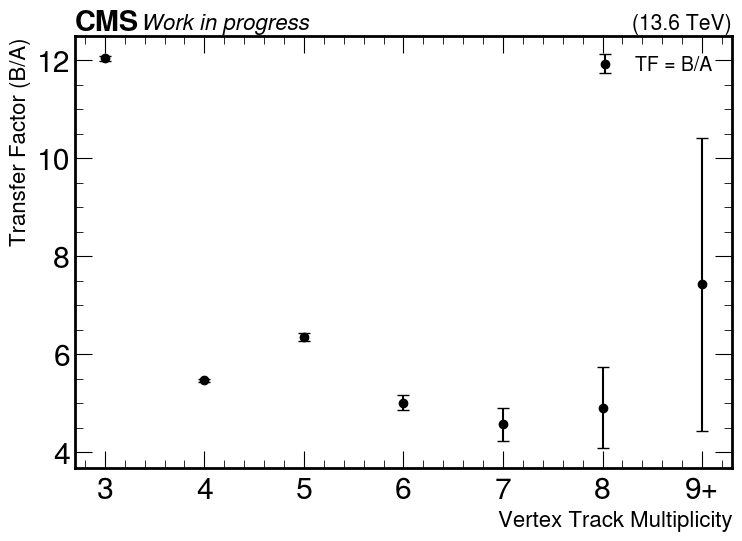

Saved transfer_factor_vs_ntrack.pdf/png


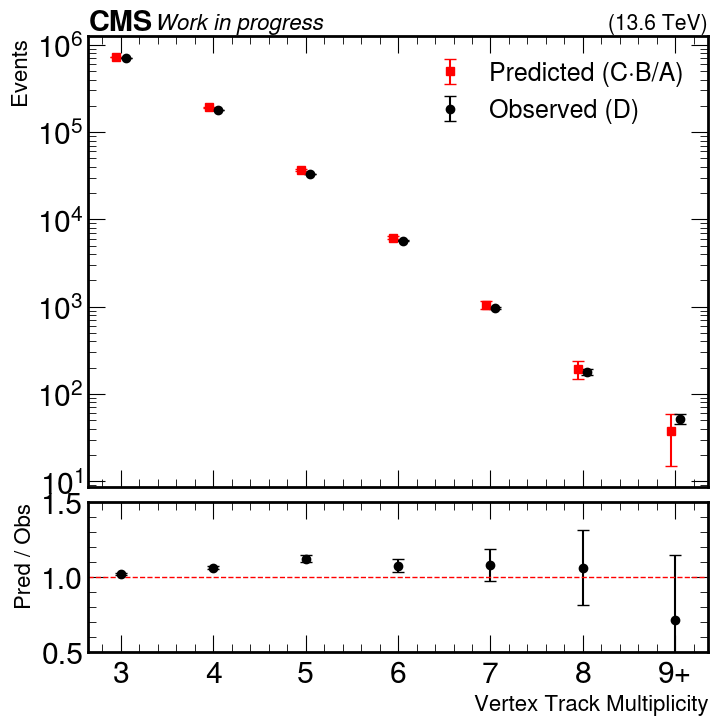

Saved abcd_closure_vs_ntrack.pdf/png


In [12]:
#ABCD in different track multiplicity bins with blinding

import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from concurrent.futures import ProcessPoolExecutor, as_completed

plt.style.use(hep.style.CMS)

# ABCD regions in (cosT, chi2):
#   A: cosT <= 0, chi2 >= 3  (fail both)
#   B: cosT <= 0, chi2 < 3   (pass chi2 only)
#   C: cosT > 0,  chi2 >= 3  (pass cosT only)
#   D: cosT > 0,  chi2 < 3   (signal region)
#
# Transfer factor: TF = B/A
# Prediction: D_pred = C * (B/A)

NTRACK_BINS = [3, 4, 5, 6, 7, 8, "9+"]
ABCD_REGIONS = ["A", "B", "C", "D"]
BLINDED_BINS = []  # Bins where D region is blinded

def process_abcd_per_ntrack(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    # Initialize counts: {ntrk: {region: (sum_w, sum_w2)}}
    counts = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}

    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]
        branches = [
            "scoutVert_dBV", "scoutVert_dBVErr", "scoutVert_nTracks",
            "weight", "scoutVert_chi2", "scoutVert_cosT", "jet_pt"
        ]

        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = ak.ones_like(batch["weight"])
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            #jet_pt = batch["jet_pt"]
            #njet = ak.num(jet_pt,axis=1)
            #jet_mask = (njet>3)
            #dBV = dBV[jet_mask]
            #dBVErr = dBVErr[jet_mask]
            #ntracks = ntracks[jet_mask]
            #chi2 = chi2[jet_mask]
            #cosT = cosT[jet_mask]
            # Baseline vertex selection
            vtx_mask = (dBV > 0.01) & (dBV < 2.0) & (ntracks > 2) & (dBVErr < 0.005) #& (ntracks < 8)
            dBV = dBV[vtx_mask]
            ntracks = ntracks[vtx_mask]
            chi2 = chi2[vtx_mask]
            cosT = cosT[vtx_mask]

            # Keep events with at least one vertex passing baseline
            evt_mask = ak.num(dBV, axis=1) > 0
            weights = weights[evt_mask]
            ntracks = ntracks[evt_mask]
            chi2 = chi2[evt_mask]
            cosT = cosT[evt_mask]

            for nt in NTRACK_BINS:
                # Select vertices with exactly this track multiplicity
                # (or >= 8 for the inclusive bin)
                if nt == "9+":
                    nt_mask = ntracks >= 9
                else:
                    nt_mask = ntracks == nt

                nt_chi2 = chi2[nt_mask]
                nt_cosT = cosT[nt_mask]

                # ABCD masks (per vertex)
                pass_cosT = nt_cosT > 0
                pass_chi2 = nt_chi2 < 2.5

                region_masks = {
                    "A": ~pass_cosT & ~pass_chi2,
                    "B": ~pass_cosT & pass_chi2,
                    "C": pass_cosT & ~pass_chi2,
                    "D": pass_cosT & pass_chi2,
                }

                duplicateMask = ak.ones_like(weights, dtype=bool)
                for region in ["D","C","B","A"]:
                    rmask = region_masks[region]
                    # Event has at least one vertex in this region
                    evt_in_region = (ak.num(nt_cosT[rmask]) > 0) & duplicateMask
                    duplicateMask = duplicateMask & (~evt_in_region)
                    
                    # Skip filling observed D for blinded bins
                    if region == "D" and nt in BLINDED_BINS:
                        continue
                    
                    w = weights[evt_in_region]
                    counts[nt][region][0] += float(ak.sum(w))
                    counts[nt][region][1] += float(ak.sum(w**2))
                    
                    
    return process, counts


def merge_counts(all_counts):
    """Merge counts across files for the same process."""
    merged = {}
    for process, counts in all_counts:
        if process not in merged:
            merged[process] = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                merged[process][nt][r][0] += counts[nt][r][0]
                merged[process][nt][r][1] += counts[nt][r][1]
    return merged


def compute_transfer_factors(counts):
    """Compute TF = B/A and its uncertainty for each ntrack bin."""
    ntracks = []
    tfs = []
    tf_errs = []
    region_yields = {r: ([], []) for r in ABCD_REGIONS}

    for nt in NTRACK_BINS:
        A, A2 = counts[nt]["A"]
        B, B2 = counts[nt]["B"]
        C, C2 = counts[nt]["C"]
        D, D2 = counts[nt]["D"]

        A_err = np.sqrt(A2)
        B_err = np.sqrt(B2)
        C_err = np.sqrt(C2)
        D_err = np.sqrt(D2)

        for r in ABCD_REGIONS:
            val, val2 = counts[nt][r]
            region_yields[r][0].append(val)
            region_yields[r][1].append(np.sqrt(val2))

        if A > 0 and B > 0:
            tf = B / A
            tf_err = tf * np.sqrt((A_err / A)**2 + (B_err / B)**2)
        elif A == 0:
            tf = 0
            tf_err = 0
        else:
            tf = 0
            tf_err = 0

        # Use numeric position for plotting
        nt_label = nt if isinstance(nt, int) else 9
        ntracks.append(nt_label)
        tfs.append(tf)
        tf_errs.append(tf_err)

        # Predicted vs observed
        if A > 0:
            D_pred = C * B / A
            D_pred_err = D_pred * np.sqrt(
                (A_err / A)**2 + (B_err / B)**2 + (C_err / C)**2
            ) if C > 0 else 0
        else:
            D_pred = 0
            D_pred_err = 0

        if nt in BLINDED_BINS:
            print(f"ntrk={nt}: A={A:.1f}±{A_err:.1f}  B={B:.1f}±{B_err:.1f}  "
                  f"C={C:.1f}±{C_err:.1f}  D=BLINDED")
            print(f"TF(B/A)={tf:.4f}±{tf_err:.4f}  "
                  f"D_pred={D_pred:.2f}±{D_pred_err:.2f}  D_obs=BLINDED")
        else:
            print(f"ntrk={nt}: A={A:.1f}±{A_err:.1f}  B={B:.1f}±{B_err:.1f}  "
                  f"C={C:.1f}±{C_err:.1f}  D={D:.1f}±{D_err:.1f}")
            print(f"  TF(B/A)={tf:.4f}±{tf_err:.4f}  "
                  f"D_pred={D_pred:.2f}±{D_pred_err:.2f}  D_obs={D:.1f}±{D_err:.1f}")

    return np.array(ntracks), np.array(tfs), np.array(tf_errs), region_yields


def plot_transfer_factor(ntracks, tfs, tf_errs, process_label="2024 Data"):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(
        ntracks, tfs, yerr=tf_errs,
        fmt='o', color='black', markersize=6, capsize=4, linewidth=1.5,
        label=f"TF = B/A"
    )

    ax.set_xlabel("Vertex Track Multiplicity", fontsize=16)
    ax.set_ylabel("Transfer Factor (B/A)", fontsize=16)
    tick_labels = [str(nt) for nt in NTRACK_BINS]
    ax.set_xticks(ntracks)
    ax.set_xticklabels(tick_labels)
    ax.legend(fontsize=14)

    hep.cms.label("Work in progress", loc=0, ax=ax, com=13.6, fontsize=16,data=True)

    plt.tight_layout()
    plt.savefig("transfer_factor_vs_ntrack.pdf")
    plt.savefig("transfer_factor_vs_ntrack.png", dpi=150)
    plt.show()
    print("Saved transfer_factor_vs_ntrack.pdf/png")


def plot_closure(ntracks, region_yields, process_label="2024 Data"):
    """Plot predicted vs observed D region yields."""
    A_vals, A_errs = np.array(region_yields["A"][0]), np.array(region_yields["A"][1])
    B_vals, B_errs = np.array(region_yields["B"][0]), np.array(region_yields["B"][1])
    C_vals, C_errs = np.array(region_yields["C"][0]), np.array(region_yields["C"][1])
    D_vals, D_errs = np.array(region_yields["D"][0]), np.array(region_yields["D"][1])

    safe_A = np.where(A_vals > 0, A_vals, 1.0)
    D_pred = np.where(A_vals > 0, C_vals * B_vals / safe_A, 0)
    D_pred_err = np.where(
        (A_vals > 0) & (B_vals > 0) & (C_vals > 0),
        D_pred * np.sqrt((A_errs/safe_A)**2 + (B_errs/np.where(B_vals>0,B_vals,1.0))**2 + (C_errs/np.where(C_vals>0,C_vals,1.0))**2),
        0
    )

    # Build masks for blinded vs unblinded bins
    blinded_mask = np.array([nt in BLINDED_BINS for nt in NTRACK_BINS])
    unblinded_mask = ~blinded_mask

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[3, 1],
                                    sharex=True, gridspec_kw={'hspace': 0.05})

    # Plot prediction for all bins
    ax1.errorbar(ntracks - 0.05, D_pred, yerr=D_pred_err,
                 fmt='s', color='red', markersize=6, capsize=4, label="Predicted (C·B/A)")

    # Plot observed only for unblinded bins
    if np.any(unblinded_mask):
        ax1.errorbar(ntracks[unblinded_mask] + 0.05, D_vals[unblinded_mask],
                     yerr=D_errs[unblinded_mask],
                     fmt='o', color='black', markersize=6, capsize=4, label="Observed (D)")

    # Mark blinded bins with gray bands
    if np.any(blinded_mask):
        for x in ntracks[blinded_mask]:
            ax1.axvspan(x - 0.4, x + 0.4, color='gray', alpha=0.15, zorder=0)

    ax1.set_ylabel("Events", fontsize=16)
    ax1.legend(fontsize=18)
    ax1.set_yscale("log")

    # Place blinded labels after log scale is set so ylim is sensible
    if np.any(blinded_mask):
        for x in ntracks[blinded_mask]:
            ax1.text(x, ax1.get_ylim()[0] * 2, "BLINDED", ha='center', va='bottom',
                     fontsize=10, color='gray', fontstyle='italic')

    hep.cms.label("Work in progress", loc=0, ax=ax1, com=13.6, fontsize=16,data=True)
    # Ratio panel: only for unblinded bins
    safe_D = np.where(D_vals > 0, D_vals, 1.0)  # avoid division by zero
    ratio = np.where((D_vals > 0) & unblinded_mask, D_pred / safe_D, np.nan)
    ratio_err = np.where((D_vals > 0) & unblinded_mask, D_pred_err / safe_D, np.nan)

    if np.any(unblinded_mask):
        valid = unblinded_mask & np.isfinite(ratio)
        ax2.errorbar(ntracks[valid], ratio[valid], yerr=ratio_err[valid],
                     fmt='o', color='black', markersize=6, capsize=4)

    ax2.axhline(1, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel("Vertex Track Multiplicity", fontsize=16)
    ax2.set_ylabel("Pred / Obs", fontsize=16)
    ax2.set_ylim(0.5, 1.5)
    tick_labels = [str(nt) for nt in NTRACK_BINS]
    ax2.set_xticks(ntracks)
    ax2.set_xticklabels(tick_labels)

    # Gray bands on ratio panel too
    if np.any(blinded_mask):
        for x in ntracks[blinded_mask]:
            ax2.axvspan(x - 0.4, x + 0.4, color='gray', alpha=0.15, zorder=0)

    plt.savefig("abcd_closure_vs_ntrack.pdf")
    plt.savefig("abcd_closure_vs_ntrack.png", dpi=150)
    plt.show()
    print("Saved abcd_closure_vs_ntrack.pdf/png")


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # --- Fill in your file dictionaries here ---
    # processDict = {"2024C": [...], "2024D": [...], ...}
    # signalDict = {"stop_M200_ctau10": [...], ...}

    run_dict = signalDict  # or signalDict | processDict

    # Parallel processing
    all_results = []
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {
            executor.submit(process_abcd_per_ntrack, (f, p)): (f, p)
            for p, files in run_dict.items() for f in files
        }
        for future in as_completed(futures):
            all_results.append(future.result())

    merged = merge_counts(all_results)

    # Combine data eras
    combined = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
    data_eras = [k for k in merged if k.startswith("2024")]
    for era in data_eras:
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                combined[nt][r][0] += merged[era][nt][r][0]
                combined[nt][r][1] += merged[era][nt][r][1]

    print("\n=== 2024 Data Combined ===")
    ntracks, tfs, tf_errs, region_yields = compute_transfer_factors(combined)

    plot_transfer_factor(ntracks, tfs, tf_errs, process_label="2024 Data")
    plot_closure(ntracks, region_yields, process_label="2024 Data")

Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024D_Tree_v28-4DxyMin/260409_153742/Run2024D.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024H_Tree_v28-4DxyMin/260409_153901/Run2024H.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024F_Tree_v28-4DxyMin/260409_153833/Run2024F.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024I_Tree_v28-4DxyMin/260409_153919/Run2024I.rootProcessing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024G_Tree_v28-4DxyMin/260409_153846/Run2024G.root


Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024C_Tree_v28-4DxyMin/260409_153724/Run2024C.root
Processing /eos/cms/store/group/phys_exotica/DVScouting/ScoutingPFRun3/Run2024E_Tree_v28-4DxyMin/260409_153818/Run2024E.root



=== 2024 Data Combined ===
ntrk=3: A=19655.0±140.2  B=423363.0±650.7  C=19114.0±138.3  D=422276.0±649.8
  TF(B/A)=21.5397±0.

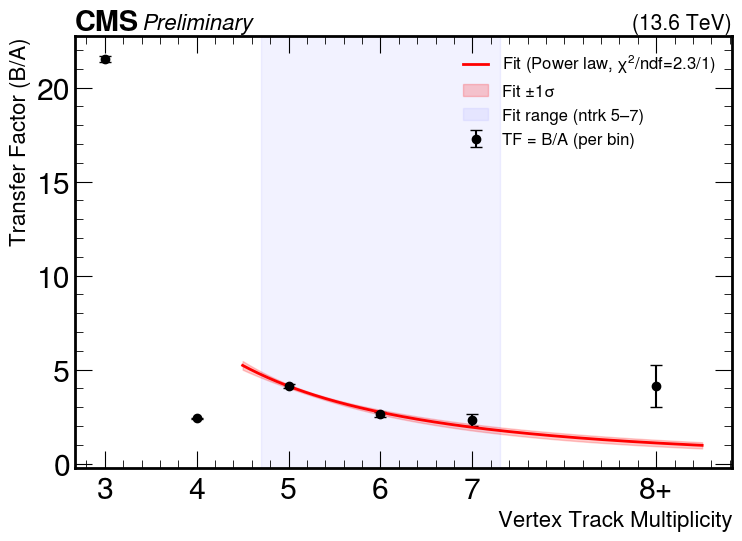

Saved transfer_factor_vs_ntrack.pdf/png

=== Fitted prediction for ntrk=8+ ===
  TF(fit) = 1.0932 ± 0.1710
  C = 15.0 ± 3.9
  D_pred(fit) = 16.40 ± 4.95


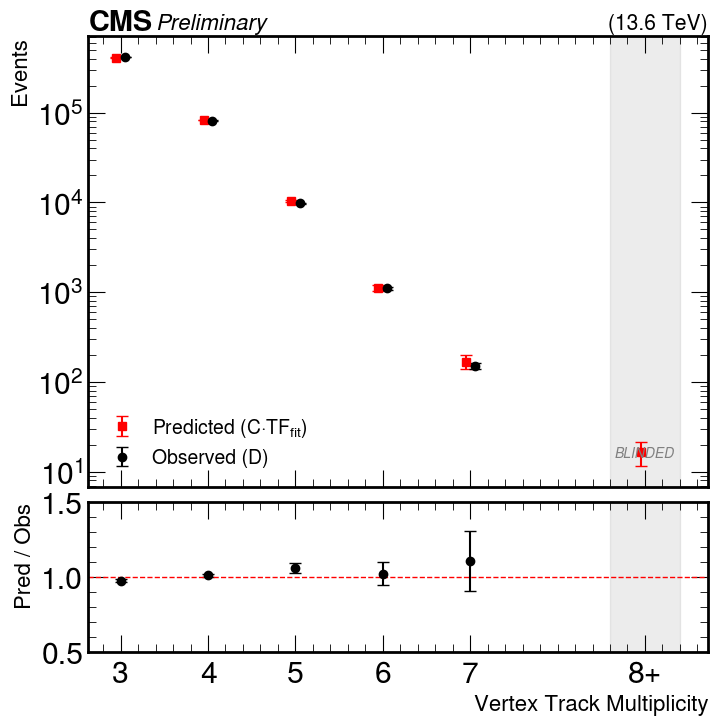

Saved abcd_closure_vs_ntrack.pdf/png


In [16]:
#ABCD in different track multiplicity bins
# with TF fit extrapolation for blinded low-stats bins

import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor, as_completed

plt.style.use(hep.style.CMS)

# ABCD regions in (cosT, chi2):
#   A: cosT <= 0, chi2 >= 3  (fail both)
#   B: cosT <= 0, chi2 < 3   (pass chi2 only)
#   C: cosT > 0,  chi2 >= 3  (pass cosT only)
#   D: cosT > 0,  chi2 < 3   (signal region)
#
# Transfer factor: TF = B/A
# Prediction: D_pred = C * TF

NTRACK_BINS = [3, 4, 5, 6, 7, "8+"]
ABCD_REGIONS = ["A", "B", "C", "D"]
BLINDED_BINS = ["8+"]  # Bins where D region is blinded

# Bins used for fitting TF vs ntrack (exclude ntrk=3 outlier)
FIT_BINS = [5, 6, 7]


# ============================================================
# Fit models for transfer factor vs ntrack
# ============================================================
def model_const(x, a):
    return a * np.ones_like(x, dtype=float)

def model_linear(x, a, b):
    return a + b * x

def model_log(x, a, b):
    return a + b * np.log(x)

def model_exp(x, a, b):
    return a * np.exp(b * x)

def model_power(x, a, b):
    return a * np.power(x, b)


def fit_transfer_factor(ntracks, tfs, tf_errs, fit_bins=FIT_BINS):
    """
    Fit TF vs ntrack using several models, select best by chi2/ndf.
    Returns the best-fit function, parameters, covariance, and label.
    """
    # Select only the fit bins
    fit_mask = np.array([nt in fit_bins for nt in NTRACK_BINS])
    x_fit = ntracks[fit_mask].astype(float)
    y_fit = tfs[fit_mask]
    yerr_fit = tf_errs[fit_mask]

    # Skip bins with zero error (would cause inf weight)
    valid = yerr_fit > 0
    x_fit = x_fit[valid]
    y_fit = y_fit[valid]
    yerr_fit = yerr_fit[valid]

    mean_tf = np.mean(y_fit)

    # (function, initial guess, bounds)
    models = {
        "Constant":    (model_const,  [mean_tf],      ([-np.inf], [np.inf])),
        "Linear":      (model_linear, [mean_tf, 0.0], ([-np.inf, -np.inf], [np.inf, np.inf])),
        "Log":         (model_log,    [mean_tf, 0.0], ([-np.inf, -np.inf], [np.inf, np.inf])),
        "Exponential": (model_exp,    [mean_tf, 0.0], ([0, -2.0], [np.inf, 2.0])),
        "Power law":   (model_power,  [mean_tf, 0.0], ([0, -10.0], [np.inf, 10.0])),
    }

    best_name = None
    best_chi2ndf = np.inf
    best_result = None

    print("\n=== Transfer Factor Fit Results ===")
    for name, (func, p0, bounds) in models.items():
        npar = len(p0)
        ndf = len(x_fit) - npar
        if ndf <= 0:
            continue
        try:
            popt, pcov = curve_fit(
                func, x_fit, y_fit, p0=p0, sigma=yerr_fit,
                absolute_sigma=True, bounds=bounds, maxfev=10000
            )
            y_pred = func(x_fit, *popt)

            # Validate: fitted values must be finite and positive
            if not np.all(np.isfinite(y_pred)) or np.any(y_pred <= 0):
                print(f"  {name:12s}: SKIPPED (non-finite or negative fitted values)")
                continue

            residuals = (y_fit - y_pred) / yerr_fit
            chi2 = np.sum(residuals**2)
            chi2ndf = chi2 / ndf
            print(f"  {name:12s}: chi2/ndf = {chi2:.2f}/{ndf} = {chi2ndf:.2f}  params = {popt}")

            if chi2ndf < best_chi2ndf:
                best_chi2ndf = chi2ndf
                best_name = name
                best_result = (func, popt, pcov, name, chi2, ndf)
        except Exception as e:
            print(f"  {name:12s}: fit failed ({e})")

    func, popt, pcov, name, chi2, ndf = best_result
    print(f"\n  Best fit: {name} (chi2/ndf = {chi2:.2f}/{ndf})")

    func, popt, pcov, name, chi2, ndf = best_result
    print(f"\n  Best fit: {name} (chi2/ndf = {chi2:.2f}/{ndf})")
    return best_result


def extrapolate_tf(fit_result, ntrack_val):
    """
    Evaluate fitted TF and its uncertainty at a given ntrack value.
    Returns (tf_fitted, tf_fitted_err).
    """
    func, popt, pcov, name, chi2, ndf = fit_result
    x = np.array([float(ntrack_val)])
    tf_val = func(x, *popt)[0]

    # Propagate parameter uncertainties via Jacobian
    eps = 1e-6
    jac = np.zeros(len(popt))
    for i in range(len(popt)):
        p_up = popt.copy()
        p_up[i] += eps
        p_dn = popt.copy()
        p_dn[i] -= eps
        jac[i] = (func(x, *p_up)[0] - func(x, *p_dn)[0]) / (2 * eps)

    tf_err = np.sqrt(jac @ pcov @ jac)
    return tf_val, tf_err


# ============================================================
# Processing
# ============================================================
def process_abcd_per_ntrack(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    # Initialize counts: {ntrk: {region: (sum_w, sum_w2)}}
    counts = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}

    with uproot.open(rootFile) as file:
        tree = file["scoutingTree/objectTree"]
        branches = [
            "scoutVert_dBV", "scoutVert_dBVErr", "scoutVert_nTracks",
            "weight", "scoutVert_chi2", "scoutVert_cosT", "jet_pt"
        ]

        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = ak.ones_like(batch["weight"])
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            ntracks = batch["scoutVert_nTracks"]
            chi2 = batch["scoutVert_chi2"]
            cosT = batch["scoutVert_cosT"]
            #jet_pt = batch["jet_pt"]
            #njet = ak.num(jet_pt,axis=1)
            #jet_mask = (njet>3)
            #dBV = dBV[jet_mask]
            #dBVErr = dBVErr[jet_mask]
            #ntracks = ntracks[jet_mask]
            #chi2 = chi2[jet_mask]
            #cosT = cosT[jet_mask]
            # Baseline vertex selection
            vtx_mask = (dBV > 0.01) & (dBV < 2.0) & (ntracks > 2) & (dBVErr < 0.005) #& (ntracks < 8)
            dBV = dBV[vtx_mask]
            ntracks = ntracks[vtx_mask]
            chi2 = chi2[vtx_mask]
            cosT = cosT[vtx_mask]

            # Keep events with at least one vertex passing baseline
            evt_mask = ak.num(dBV, axis=1) > 0
            weights = weights[evt_mask]
            ntracks = ntracks[evt_mask]
            chi2 = chi2[evt_mask]
            cosT = cosT[evt_mask]

            for nt in NTRACK_BINS:
                # Select vertices with exactly this track multiplicity
                # (or >= 9 for the inclusive bin)
                if nt == "8+":
                    nt_mask = ntracks >= 8
                else:
                    nt_mask = ntracks == nt

                nt_chi2 = chi2[nt_mask]
                nt_cosT = cosT[nt_mask]

                # ABCD masks (per vertex)
                pass_cosT = nt_cosT > 0
                pass_chi2 = nt_chi2 < 3

                region_masks = {
                    "A": ~pass_cosT & ~pass_chi2,
                    "B": ~pass_cosT & pass_chi2,
                    "C": pass_cosT & ~pass_chi2,
                    "D": pass_cosT & pass_chi2,
                }

                duplicateMask = ak.ones_like(weights, dtype=bool)
                for region in ["D","C","B","A"]:
                    rmask = region_masks[region]
                    # Event has at least one vertex in this region
                    evt_in_region = (ak.num(nt_cosT[rmask]) > 0) & duplicateMask
                    duplicateMask = duplicateMask & (~evt_in_region)
                    
                    # Skip filling observed D for blinded bins
                    if region == "D" and nt in BLINDED_BINS:
                        continue
                    
                    w = weights[evt_in_region]
                    counts[nt][region][0] += float(ak.sum(w))
                    counts[nt][region][1] += float(ak.sum(w**2))

    return process, counts


def merge_counts(all_counts):
    """Merge counts across files for the same process."""
    merged = {}
    for process, counts in all_counts:
        if process not in merged:
            merged[process] = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                merged[process][nt][r][0] += counts[nt][r][0]
                merged[process][nt][r][1] += counts[nt][r][1]
    return merged


def compute_transfer_factors(counts):
    """Compute TF = B/A and its uncertainty for each ntrack bin."""
    ntracks = []
    tfs = []
    tf_errs = []
    region_yields = {r: ([], []) for r in ABCD_REGIONS}

    for nt in NTRACK_BINS:
        A, A2 = counts[nt]["A"]
        B, B2 = counts[nt]["B"]
        C, C2 = counts[nt]["C"]
        D, D2 = counts[nt]["D"]

        A_err = np.sqrt(A2)
        B_err = np.sqrt(B2)
        C_err = np.sqrt(C2)
        D_err = np.sqrt(D2)

        for r in ABCD_REGIONS:
            val, val2 = counts[nt][r]
            region_yields[r][0].append(val)
            region_yields[r][1].append(np.sqrt(val2))

        if A > 0 and B > 0:
            tf = B / A
            tf_err = tf * np.sqrt((A_err / A)**2 + (B_err / B)**2)
        elif A == 0:
            tf = 0
            tf_err = 0
        else:
            tf = 0
            tf_err = 0

        # Use numeric position for plotting
        nt_label = nt if isinstance(nt, int) else 9
        ntracks.append(nt_label)
        tfs.append(tf)
        tf_errs.append(tf_err)

        # Predicted vs observed (raw per-bin ABCD, no fit)
        if A > 0:
            D_pred = C * B / A
            D_pred_err = D_pred * np.sqrt(
                (A_err / A)**2 + (B_err / B)**2 + (C_err / C)**2
            ) if C > 0 else 0
        else:
            D_pred = 0
            D_pred_err = 0

        if nt in BLINDED_BINS:
            print(f"ntrk={nt}: A={A:.1f}±{A_err:.1f}  B={B:.1f}±{B_err:.1f}  "
                  f"C={C:.1f}±{C_err:.1f}  D=BLINDED")
            print(f"  TF(B/A)={tf:.4f}±{tf_err:.4f}  "
                  f"D_pred(raw)={D_pred:.2f}±{D_pred_err:.2f}  D_obs=BLINDED")
        else:
            print(f"ntrk={nt}: A={A:.1f}±{A_err:.1f}  B={B:.1f}±{B_err:.1f}  "
                  f"C={C:.1f}±{C_err:.1f}  D={D:.1f}±{D_err:.1f}")
            print(f"  TF(B/A)={tf:.4f}±{tf_err:.4f}  "
                  f"D_pred(raw)={D_pred:.2f}±{D_pred_err:.2f}  D_obs={D:.1f}±{D_err:.1f}")

    return np.array(ntracks), np.array(tfs), np.array(tf_errs), region_yields


def plot_transfer_factor(ntracks, tfs, tf_errs, fit_result=None, process_label="2024 Data"):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(
        ntracks, tfs, yerr=tf_errs,
        fmt='o', color='black', markersize=6, capsize=4, linewidth=1.5,
        label="TF = B/A (per bin)"
    )

    # Overlay fit curve
    if fit_result is not None:
        func, popt, pcov, name, chi2, ndf = fit_result
        x_plot = np.linspace(min(FIT_BINS) - 0.5, max(ntracks) + 0.5, 200)
        y_plot = func(x_plot, *popt)

        # Fit uncertainty band
        y_err = np.zeros_like(x_plot)
        eps = 1e-6
        for xi, xval in enumerate(x_plot):
            jac = np.zeros(len(popt))
            for i in range(len(popt)):
                p_up = popt.copy(); p_up[i] += eps
                p_dn = popt.copy(); p_dn[i] -= eps
                jac[i] = (func(np.array([xval]), *p_up)[0] - func(np.array([xval]), *p_dn)[0]) / (2*eps)
            y_err[xi] = np.sqrt(jac @ pcov @ jac)

        ax.plot(x_plot, y_plot, 'r-', linewidth=2,
                label=f"Fit ({name}, $\\chi^2$/ndf={chi2:.1f}/{ndf})")
        ax.fill_between(x_plot, y_plot - y_err, y_plot + y_err,
                        color='red', alpha=0.2, label="Fit ±1σ")

        # Mark fit range
        ax.axvspan(min(FIT_BINS) - 0.3, max(FIT_BINS) + 0.3,
                   color='blue', alpha=0.05, zorder=0, label=f"Fit range (ntrk {min(FIT_BINS)}–{max(FIT_BINS)})")

    ax.set_xlabel("Vertex Track Multiplicity", fontsize=16)
    ax.set_ylabel("Transfer Factor (B/A)", fontsize=16)
    tick_labels = [str(nt) for nt in NTRACK_BINS]
    ax.set_xticks(ntracks)
    ax.set_xticklabels(tick_labels)
    ax.legend(fontsize=12)

    hep.cms.label("Preliminary", loc=0, ax=ax, com=13.6, fontsize=16, data=True)

    plt.tight_layout()
    plt.savefig("transfer_factor_vs_ntrack.pdf")
    plt.savefig("transfer_factor_vs_ntrack.png", dpi=150)
    plt.show()
    print("Saved transfer_factor_vs_ntrack.pdf/png")


def plot_closure(ntracks, region_yields, fit_result=None, process_label="2024 Data"):
    """Plot predicted vs observed D region yields.
    For blinded bins, uses fitted TF if available, otherwise raw B/A."""
    A_vals, A_errs = np.array(region_yields["A"][0]), np.array(region_yields["A"][1])
    B_vals, B_errs = np.array(region_yields["B"][0]), np.array(region_yields["B"][1])
    C_vals, C_errs = np.array(region_yields["C"][0]), np.array(region_yields["C"][1])
    D_vals, D_errs = np.array(region_yields["D"][0]), np.array(region_yields["D"][1])

    blinded_mask = np.array([nt in BLINDED_BINS for nt in NTRACK_BINS])
    unblinded_mask = ~blinded_mask

    # Compute predictions
    safe_A = np.where(A_vals > 0, A_vals, 1.0)
    D_pred = np.where(A_vals > 0, C_vals * B_vals / safe_A, 0)
    D_pred_err = np.where(
        (A_vals > 0) & (B_vals > 0) & (C_vals > 0),
        D_pred * np.sqrt((A_errs/safe_A)**2 +
                         (B_errs/np.where(B_vals>0, B_vals, 1.0))**2 +
                         (C_errs/np.where(C_vals>0, C_vals, 1.0))**2),
        0
    )

    # Override blinded bins with fitted TF prediction
    if fit_result is not None:
        for i, nt in enumerate(NTRACK_BINS):
            if nt in BLINDED_BINS:
                nt_num = nt if isinstance(nt, int) else 9
                tf_fit, tf_fit_err = extrapolate_tf(fit_result, nt_num)
                C_val = C_vals[i]
                C_err = C_errs[i]
                D_pred[i] = C_val * tf_fit
                # Propagate C uncertainty and TF fit uncertainty
                if C_val > 0:
                    D_pred_err[i] = D_pred[i] * np.sqrt(
                        (C_err / C_val)**2 + (tf_fit_err / tf_fit)**2
                    ) if tf_fit > 0 else 0
                else:
                    D_pred_err[i] = 0

                print(f"\n=== Fitted prediction for ntrk={nt} ===")
                print(f"  TF(fit) = {tf_fit:.4f} ± {tf_fit_err:.4f}")
                print(f"  C = {C_val:.1f} ± {C_err:.1f}")
                print(f"  D_pred(fit) = {D_pred[i]:.2f} ± {D_pred_err[i]:.2f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[3, 1],
                                    sharex=True, gridspec_kw={'hspace': 0.05})

    # Prediction label depends on whether fit was used
    pred_label = "Predicted (C·TF$_{fit}$)" if fit_result else "Predicted (C·B/A)"
    ax1.errorbar(ntracks - 0.05, D_pred, yerr=D_pred_err,
                 fmt='s', color='red', markersize=6, capsize=4, label=pred_label)

    # Plot observed only for unblinded bins
    if np.any(unblinded_mask):
        ax1.errorbar(ntracks[unblinded_mask] + 0.05, D_vals[unblinded_mask],
                     yerr=D_errs[unblinded_mask],
                     fmt='o', color='black', markersize=6, capsize=4, label="Observed (D)")

    # Mark blinded bins with gray bands
    if np.any(blinded_mask):
        for x in ntracks[blinded_mask]:
            ax1.axvspan(x - 0.4, x + 0.4, color='gray', alpha=0.15, zorder=0)

    ax1.set_ylabel("Events", fontsize=16)
    ax1.legend(fontsize=14)
    ax1.set_yscale("log")

    # Place blinded labels after log scale is set so ylim is sensible
    if np.any(blinded_mask):
        for x in ntracks[blinded_mask]:
            ax1.text(x, ax1.get_ylim()[0] * 2, "BLINDED", ha='center', va='bottom',
                     fontsize=10, color='gray', fontstyle='italic')

    hep.cms.label("Preliminary", loc=0, ax=ax1, com=13.6, fontsize=16, data=True)

    # Ratio panel: only for unblinded bins
    safe_D = np.where(D_vals > 0, D_vals, 1.0)
    ratio = np.where((D_vals > 0) & unblinded_mask, D_pred / safe_D, np.nan)
    ratio_err = np.where((D_vals > 0) & unblinded_mask, D_pred_err / safe_D, np.nan)

    if np.any(unblinded_mask):
        valid = unblinded_mask & np.isfinite(ratio)
        ax2.errorbar(ntracks[valid], ratio[valid], yerr=ratio_err[valid],
                     fmt='o', color='black', markersize=6, capsize=4)

    ax2.axhline(1, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel("Vertex Track Multiplicity", fontsize=16)
    ax2.set_ylabel("Pred / Obs", fontsize=16)
    ax2.set_ylim(0.5, 1.5)
    tick_labels = [str(nt) for nt in NTRACK_BINS]
    ax2.set_xticks(ntracks)
    ax2.set_xticklabels(tick_labels)

    # Gray bands on ratio panel too
    if np.any(blinded_mask):
        for x in ntracks[blinded_mask]:
            ax2.axvspan(x - 0.4, x + 0.4, color='gray', alpha=0.15, zorder=0)

    plt.savefig("abcd_closure_vs_ntrack.pdf")
    plt.savefig("abcd_closure_vs_ntrack.png", dpi=150)
    plt.show()
    print("Saved abcd_closure_vs_ntrack.pdf/png")


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # --- Fill in your file dictionaries here ---
    # processDict = {"2024C": [...], "2024D": [...], ...}
    # signalDict = {"stop_M200_ctau10": [...], ...}

    run_dict = signalDict  # or signalDict | processDict

    # Parallel processing
    all_results = []
    with ProcessPoolExecutor(max_workers=16) as executor:
        futures = {
            executor.submit(process_abcd_per_ntrack, (f, p)): (f, p)
            for p, files in run_dict.items() for f in files
        }
        for future in as_completed(futures):
            all_results.append(future.result())

    merged = merge_counts(all_results)

    # Combine data eras
    combined = {nt: {r: [0.0, 0.0] for r in ABCD_REGIONS} for nt in NTRACK_BINS}
    data_eras = [k for k in merged if k.startswith("2024")]
    for era in data_eras:
        for nt in NTRACK_BINS:
            for r in ABCD_REGIONS:
                combined[nt][r][0] += merged[era][nt][r][0]
                combined[nt][r][1] += merged[era][nt][r][1]

    print("\n=== 2024 Data Combined ===")
    ntracks, tfs, tf_errs, region_yields = compute_transfer_factors(combined)

    # Fit TF using well-measured bins and extrapolate
    fit_result = fit_transfer_factor(ntracks, tfs, tf_errs, fit_bins=FIT_BINS)

    plot_transfer_factor(ntracks, tfs, tf_errs, fit_result=fit_result, process_label="2024 Data")
    plot_closure(ntracks, region_yields, fit_result=fit_result, process_label="2024 Data")